# импорт БД, создание трейн/тест выборок

Заметки на будущщее  

При этом я хочу сделать окна длины 1сек. Смысл в том, что окна ДЭПД центрированы по, собственно, ДЭПД. Это неприемлемо. ДЭПД максимальную длину будем считать за 0.7сек - то есть 0.45с в обе стороны от центра окна с ДЭПД сохраниться просто обязаны! И все окна с ДЭПД просто трансформируем сдвигами. 

Для каждого окна с ДЭПД создадим 11 окон (со сдвигами 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0). И каждому из них присвоим значение - расстояние центра окна маленького до центра окна большого + 0.2 и нормировка на 1.2. Это нужно, чтобы достаточно четко отделять фон - просто нули, от того, что пересекается с ДЭПД +-. Но это делаем потом.

In [1]:
# %% [markdown]
# # Загрузка и анализ датасета bipolar_2sec_dataset.pkl

# %%
import pickle
import numpy as np
from pathlib import Path

# Путь к файлу (указываем тот же, куда сохранили)
dataset_path = Path(r"..\bipolar_2sec_dataset.pkl")

# Загрузка
with open(dataset_path, 'rb') as f:
    dataset = pickle.load(f)

print(f"Загружено образцов: {len(dataset)}")
print(f"Тип датасета: {type(dataset)}")
print(f"Тип первого элемента: {type(dataset[0])}\n")

# Получаем все ключи (поля), которые есть в словарях
all_keys = set()
for sample in dataset:
    all_keys.update(sample.keys())
all_keys = sorted(all_keys)

print("Список всех полей (колонок) в датасете:")
for i, key in enumerate(all_keys, 1):
    print(f"  {i}. {key}")

# Для каждого поля покажем тип значения и пример
print("\nПример значений для каждого поля (на первом образце):")
first = dataset[0]
for key in all_keys:
    value = first[key]
    if key == 'data':
        print(f"  {key}: shape={value.shape}, dtype={value.dtype}")
    else:
        print(f"  {key}: {value} (тип {type(value).__name__})")

# Дополнительная статистика по категориальным полям
print("\n=== Статистика по категориальным полям ===")
print(f"Уникальные record_id: {len(set(s['record_id'] for s in dataset))}")
print(f"Уникальные external_id: {len(set(s['external_id'] for s in dataset))}")
print(f"Распределение window_type: DEPD={sum(s['window_type']==1 for s in dataset)}, фон={sum(s['window_type']==0 for s in dataset)}")
print(f"Распределение state: awake={sum(s['state']=='awake' for s in dataset)}, sleep={sum(s['state']=='sleep' for s in dataset)}")

# По длительности окон (они все должны быть 2 секунды, но проверим)
durations = [s['end_sec'] - s['start_sec'] for s in dataset]
print(f"Длительность окон: мин={min(durations):.3f} с, макс={max(durations):.3f} с, среднее={np.mean(durations):.3f} с")

# Вывод информации о форме данных (каналы × отсчёты)
shapes = [s['data'].shape for s in dataset]
unique_shapes = set(shapes)
print(f"Уникальные формы данных: {unique_shapes}")
if len(unique_shapes) == 1:
    n_ch, n_samples = shapes[0]
    print(f"  Все образцы имеют {n_ch} каналов и {n_samples} отсчётов (при {n_samples/500:.1f} с при 500 Гц)")

Загружено образцов: 14131
Тип датасета: <class 'list'>
Тип первого элемента: <class 'dict'>

Список всех полей (колонок) в датасете:
  1. data
  2. end_sec
  3. external_id
  4. original_episode_duration
  5. record_id
  6. sfreq
  7. start_sec
  8. state
  9. window_type

Пример значений для каждого поля (на первом образце):
  data: shape=(18, 1000), dtype=float32
  end_sec: 4.791 (тип float)
  external_id: 000_FA0183FS (тип str)
  original_episode_duration: 0.22999999999999998 (тип float)
  record_id: 2026_05_04_000002 (тип str)
  sfreq: 500.0 (тип float)
  start_sec: 2.7910000000000004 (тип float)
  state: awake (тип str)
  window_type: 1 (тип int)

=== Статистика по категориальным полям ===
Уникальные record_id: 57
Уникальные external_id: 57
Распределение window_type: DEPD=4131, фон=10000
Распределение state: awake=4311, sleep=9820
Длительность окон: мин=2.000 с, макс=2.000 с, среднее=2.000 с
Уникальные формы данных: {(18, 1000)}
  Все образцы имеют 18 каналов и 1000 отсчётов (при 

In [2]:
import json
import pickle
from pathlib import Path
SAVE_DIR = Path("./data_splits")

def load_train_test_split(dataset, save_dir=SAVE_DIR):
    """
    Загружает сохранённое разбиение и восстанавливает выборки
    """
    # Загружаем идентификаторы
    with open(save_dir / 'train_sample_ids.pkl', 'rb') as f:
        train_ids = pickle.load(f)
    with open(save_dir / 'test_sample_ids.pkl', 'rb') as f:
        test_ids = pickle.load(f)
    
    # Создаём множество для быстрого поиска
    train_keys = {(item['record_id'], item['start_sec']) for item in train_ids}
    test_keys = {(item['record_id'], item['start_sec']) for item in test_ids}
    
    # Восстанавливаем выборки
    train_samples = []
    test_samples = []
    
    for sample in dataset:
        key = (sample['record_id'], sample['start_sec'])
        if key in train_keys:
            train_samples.append(sample)
        elif key in test_keys:
            test_samples.append(sample)
        else:
            print(f"Warning: Sample {key} not found in saved splits!")
    
    # Загружаем списки пациентов
    with open(save_dir / 'train_patients.txt', 'r') as f:
        train_patients = f.read().splitlines()
    with open(save_dir / 'test_patients.txt', 'r') as f:
        test_patients = f.read().splitlines()
    
    # Загружаем статистику
    with open(save_dir / 'split_info.json', 'r') as f:
        split_info = json.load(f)
    
    print(f"\n=== Загружено разбиение ===")
    print(f"Тренировочные пациенты: {len(train_patients)}")
    print(f"Тестовые пациенты: {len(test_patients)}")
    print(f"Тренировочных образцов: {len(train_samples)} (DEPD: {sum(1 for s in train_samples if s['window_type']==1)}, фон: {sum(1 for s in train_samples if s['window_type']==0)})")
    print(f"Тестовых образцов: {len(test_samples)} (DEPD: {sum(1 for s in test_samples if s['window_type']==1)}, фон: {sum(1 for s in test_samples if s['window_type']==0)})")
    
    return train_samples, test_samples, train_patients, test_patients, split_info


def load_split_with_validation(dataset, split_dir=SAVE_DIR):
    """
    Расширенная версия загрузки с проверкой корректности
    """
    try:
        # Пытаемся загрузить существующее разбиение
        train_samples, test_samples, train_patients, test_patients, split_info = load_train_test_split(dataset, split_dir)
        
        # Проверяем, что пациенты не пересекаются
        overlapping_patients = set(train_patients) & set(test_patients)
        if overlapping_patients:
            print(f"WARNING: Найдены пересекающиеся пациенты: {overlapping_patients}")
        else:
            print("✓ Пересечений пациентов нет")
        
        # Проверяем, что все образцы распределены
        total_loaded = len(train_samples) + len(test_samples)
        if total_loaded == len(dataset):
            print(f"✓ Все {total_loaded} образцов успешно загружены")
        else:
            print(f"WARNING: Загружено {total_loaded} из {len(dataset)} образцов")
        
        return train_samples, test_samples, train_patients, test_patients, split_info
        
    except FileNotFoundError:
        print("Сохраенное разбиение не найдено. Пожалуйста, сначала создайте разбиение с помощью save_train_test_split")
        return None, None, None, None, None

# Пример использования после сохранения:
train_samples, test_samples, train_patients, test_patients, split_info = load_split_with_validation(dataset)


=== Загружено разбиение ===
Тренировочные пациенты: 45
Тестовые пациенты: 12
Тренировочных образцов: 9459 (DEPD: 3019, фон: 6440)
Тестовых образцов: 4672 (DEPD: 1112, фон: 3560)
✓ Пересечений пациентов нет
✓ Все 14131 образцов успешно загружены


In [3]:
import gc

def clean_dataset_samples(samples):
    """
    Очищает выборку, оставляя только data и window_type
    Возвращает: список кортежей (data, label) для максимальной эффективности
    """
    cleaned = []
    
    for sample in samples:
        # Берём только данные и метку класса
        data = sample['data']
        label = sample['window_type']
        
        # Опционально: конвертируем в float32 для экономии памяти
        if data.dtype != np.float32:
            data = data.astype(np.float32)
        
        cleaned.append((data, label))
    
    return cleaned

def clean_dataset_with_arrays(samples):
    """
    Альтернативный вариант: возвращает numpy массивы для максимальной производительности
    """
    n_samples = len(samples)
    # Предполагаем, что все данные имеют одинаковую форму (18, 1000)
    first_data = samples[0]['data']
    data_shape = first_data.shape
    
    # Предварительно выделяем память
    data_array = np.zeros((n_samples, *data_shape), dtype=np.float32)
    labels_array = np.zeros(n_samples, dtype=np.int8)
    
    for i, sample in enumerate(samples):
        data_array[i] = sample['data'].astype(np.float32)
        labels_array[i] = sample['window_type']
    
    return data_array, labels_array

# Очищаем тренировочную и тестовую выборки
print("Очистка тренировочной выборки...")
X_train_raw = [s['data'] for s in train_samples]
y_train_raw = [s['window_type'] for s in train_samples]

print("Очистка тестовой выборки...")
X_test_raw = [s['data'] for s in test_samples]
y_test_raw = [s['window_type'] for s in test_samples]

# Проверяем результат
print(f"\n=== Результат очистки ===")
print(f"Тренировочные данные:")
print(f"  - Количество образцов: {len(X_train_raw)}")
print(f"  - Форма каждого образца: {X_train_raw[0].shape if X_train_raw else 'N/A'}")
print(f"  - Тип данных: {type(X_train_raw[0])}")
print(f"  - Метки: {np.unique(y_train_raw, return_counts=True)}")

print(f"\nТестовые данные:")
print(f"  - Количество образцов: {len(X_test_raw)}")
print(f"  - Форма каждого образца: {X_test_raw[0].shape if X_test_raw else 'N/A'}")
print(f"  - Тип данных: {type(X_test_raw[0])}")
print(f"  - Метки: {np.unique(y_test_raw, return_counts=True)}")

# Для экономии памяти можно также удалить исходные переменные
del train_samples, test_samples
gc.collect()

print("\n✓ Исходные выборки удалены из памяти")

Очистка тренировочной выборки...
Очистка тестовой выборки...

=== Результат очистки ===
Тренировочные данные:
  - Количество образцов: 9459
  - Форма каждого образца: (18, 1000)
  - Тип данных: <class 'numpy.ndarray'>
  - Метки: (array([0, 1]), array([6440, 3019]))

Тестовые данные:
  - Количество образцов: 4672
  - Форма каждого образца: (18, 1000)
  - Тип данных: <class 'numpy.ndarray'>
  - Метки: (array([0, 1]), array([3560, 1112]))

✓ Исходные выборки удалены из памяти


In [4]:
def create_efficient_arrays(X_list, y_list, chunk_size=1000):
    """
    Конвертирует список данных в numpy массив с обработкой по чанкам
    для экономии памяти
    """
    n_samples = len(X_list)
    n_channels = X_list[0].shape[0]
    n_timepoints = X_list[0].shape[1]
    
    # Создаём массивы
    X = np.zeros((n_samples, n_channels, n_timepoints), dtype=np.float32)
    y = np.zeros(n_samples, dtype=np.int8)
    
    # Заполняем по чанкам
    for i in range(0, n_samples, chunk_size):
        end_idx = min(i + chunk_size, n_samples)
        for j in range(i, end_idx):
            X[j] = X_list[j]
            y[j] = y_list[j]
        
        # Прогресс
        if i % (chunk_size * 10) == 0:
            print(f"  Обработано {end_idx}/{n_samples} образцов")
    
    return X, y

# Конвертируем в numpy массивы
print("Конвертация в numpy массивы...")
X_train, y_train = create_efficient_arrays(X_train_raw, y_train_raw)
X_test, y_test = create_efficient_arrays(X_test_raw, y_test_raw)

# Очищаем списки для экономии памяти
del X_train_raw, y_train_raw, X_test_raw, y_test_raw
gc.collect()

print(f"\n=== Итоговые массивы ===")
print(f"X_train: {X_train.shape}, dtype={X_train.dtype}")
print(f"y_train: {y_train.shape}, dtype={y_train.dtype}")
print(f"X_test: {X_test.shape}, dtype={X_test.dtype}")
print(f"y_test: {y_test.shape}, dtype={y_test.dtype}")
print(f"Занято памяти: ~{X_train.nbytes / 1024**2:.1f} MB (train), ~{X_test.nbytes / 1024**2:.1f} MB (test)")

Конвертация в numpy массивы...
  Обработано 1000/9459 образцов
  Обработано 1000/4672 образцов

=== Итоговые массивы ===
X_train: (9459, 18, 1000), dtype=float32
y_train: (9459,), dtype=int8
X_test: (4672, 18, 1000), dtype=float32
y_test: (4672,), dtype=int8
Занято памяти: ~649.5 MB (train), ~320.8 MB (test)


In [5]:
# Быстрая проверка, что данные корректны
print("\n=== Проверка целостности данных ===")
print(f"Уникальные метки в train: {np.unique(y_train)}")
print(f"Уникальные метки в test: {np.unique(y_test)}")
print(f"Train классы: 0={np.sum(y_train==0)}, 1={np.sum(y_train==1)}")
print(f"Test классы: 0={np.sum(y_test==0)}, 1={np.sum(y_test==1)}")
print(f"Нет NaN в X_train: {not np.any(np.isnan(X_train))}")
print(f"Нет Inf в X_train: {not np.any(np.isinf(X_train))}")

# Проверка формы
print(f"\nФорма X_train: {X_train.shape}")
print(f"  - Образцов: {X_train.shape[0]}")
print(f"  - Каналов: {X_train.shape[1]}")
print(f"  - Отсчётов: {X_train.shape[2]}")
print(f"Диапазон значений X_train: [{X_train.min():.4f}, {X_train.max():.4f}]")


=== Проверка целостности данных ===
Уникальные метки в train: [0 1]
Уникальные метки в test: [0 1]
Train классы: 0=6440, 1=3019
Test классы: 0=3560, 1=1112
Нет NaN в X_train: True
Нет Inf в X_train: True

Форма X_train: (9459, 18, 1000)
  - Образцов: 9459
  - Каналов: 18
  - Отсчётов: 1000
Диапазон значений X_train: [-0.0126, 0.0123]


In [6]:
# Дополнительная проверка для уверенности
print("=== Дополнительная верификация ===")
print(f"Среднее по каналам: {X_train.mean(axis=(0,2))}")
print(f"Стандартное отклонение по каналам: {X_train.std(axis=(0,2))}")
print(f"X_test диапазон: [{X_test.min():.4f}, {X_test.max():.4f}]")
print(f"X_test среднее: {X_test.mean():.4f}, std: {X_test.std():.4f}")

# Проверка, что данные не константные
channel_variance = X_train.var(axis=(0,2))
print(f"\nДисперсия по каналам: мин={channel_variance.min():.2e}, макс={channel_variance.max():.2e}")
if (channel_variance > 1e-6).all():
    print("✓ Все каналы имеют вариативность (нет мёртвых каналов)")

=== Дополнительная верификация ===
Среднее по каналам: [-7.3755352e-08 -5.3611021e-08  1.9104473e-08  5.2727227e-08
  1.3378168e-08 -8.3141366e-08  1.9639723e-08  6.5511863e-08
 -1.1248302e-07  8.1037435e-09  1.5842966e-07  2.5274884e-08
 -4.6765376e-08 -9.4678455e-08 -2.0814053e-08  4.2786422e-08
  1.6910317e-08 -1.8034696e-08]
Стандартное отклонение по каналам: [1.05906533e-04 1.05407147e-04 7.64136275e-05 9.84865328e-05
 1.09873559e-04 9.00423038e-05 1.03482133e-04 6.20482679e-05
 1.31271561e-04 1.01844009e-04 1.39416981e-04 7.45438956e-05
 9.35957651e-05 1.09987872e-04 9.95140945e-05 1.08993794e-04
 1.28532134e-04 1.10967390e-04]
X_test диапазон: [-0.0086, 0.0086]
X_test среднее: -0.0000, std: 0.0001

Дисперсия по каналам: мин=3.85e-09, макс=1.94e-08


In [7]:
# # Быстрый пайплайн на чистых данных без экстракции фич. Используем PCA для ускорения

# from sklearn.linear_model import LogisticRegression
# from sklearn.svm import LinearSVC
# from sklearn.naive_bayes import GaussianNB
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.ensemble import ExtraTreesClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, balanced_accuracy_score
# import time

# # Решейп данных
# print("Решейп данных...")
# X_train_flat = X_train.reshape(X_train.shape[0], -1)
# X_test_flat = X_test.reshape(X_test.shape[0], -1)
# print(f"X_train_flat: {X_train_flat.shape}")
# print(f"X_test_flat: {X_test_flat.shape}")

# # Для ускорения - уменьшим размерность через PCA (сохраним 95% variance)
# print("\nПрименяем PCA для ускорения...")
# pca = PCA(n_components=0.95, random_state=42)
# X_train_pca = pca.fit_transform(X_train_flat)
# X_test_pca = pca.transform(X_test_flat)
# print(f"После PCA: {X_train_pca.shape[1]} компонент")


# # Список быстрых моделей
# models = {
#     'Logistic Regression': LogisticRegression(
#         C=1.0,
#         class_weight='balanced',
#         solver='liblinear',
#         max_iter=1000,
#         random_state=42,
#         n_jobs=-1
#     ),
#     'Linear SVM': LinearSVC(
#         C=1.0,
#         class_weight='balanced',
#         max_iter=2000,
#         random_state=42,
#         dual='auto'
#     ),
#     'KNN (k=5)': KNeighborsClassifier(
#         n_neighbors=5,
#         n_jobs=-1
#     ),
#     'KNN (k=15)': KNeighborsClassifier(
#         n_neighbors=15,
#         n_jobs=-1
#     ),
#     'Extra Trees': ExtraTreesClassifier(
#         n_estimators=100,
#         max_depth=15,
#         class_weight='balanced',
#         n_jobs=-1,
#         random_state=42
#     )
# }

# # Функция для оценки
# def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
#     """Быстрая оценка модели"""
#     print(f"\n{'='*50}")
#     print(f"📊 {model_name}")
#     print(f"{'='*50}")
    
#     start_time = time.time()
#     model.fit(X_train, y_train)
#     train_time = time.time() - start_time
    
#     start_time = time.time()
#     y_pred = model.predict(X_test)
#     predict_time = time.time() - start_time
    
#     # Метрики
#     f1 = f1_score(y_test, y_pred)
#     precision = precision_score(y_test, y_pred)
#     recall = recall_score(y_test, y_pred)
#     balanced_acc = balanced_accuracy_score(y_test, y_pred)
    
#     # Для моделей с predict_proba
#     if hasattr(model, 'predict_proba'):
#         y_proba = model.predict_proba(X_test)[:, 1]
#         roc_auc = roc_auc_score(y_test, y_proba)
#     else:
#         roc_auc = None
    
#     print(f"✅ F1 Score: {f1:.4f}")
#     print(f"   Precision: {precision:.4f}")
#     print(f"   Recall: {recall:.4f}")
#     print(f"   Balanced Accuracy: {balanced_acc:.4f}")
#     if roc_auc:
#         print(f"   ROC-AUC: {roc_auc:.4f}")
#     print(f"⏱️  Train time: {train_time:.2f}s")
#     print(f"⏱️  Predict time: {predict_time:.2f}s")
    
#     return {
#         'model': model_name,
#         'f1': f1,
#         'precision': precision,
#         'recall': recall,
#         'balanced_acc': balanced_acc,
#         'roc_auc': roc_auc,
#         'train_time': train_time,
#         'predict_time': predict_time
#     }

# # Запускаем все модели на PCA данных
# results = {}

# print("\n🚀 Запуск моделей на PCA-данных...")
# for name, model in models.items():
#     results[name] = evaluate_model(
#         model, X_train_pca, y_train, X_test_pca, y_test, name
#     )


# import pandas as pd

# # Собираем результаты в DataFrame
# results_df = pd.DataFrame(results).T
# results_df = results_df.sort_values('f1', ascending=False)

# print("\n" + "="*70)
# print("📈 Сводная таблица результатов")
# print("="*70)
# print(results_df[['f1', 'precision', 'recall', 'balanced_acc', 'train_time']].round(4))

# # Лучшие модели по F1
# print("\n" + "="*70)
# print("🏆 ТОП-3 модели по F1 Score")
# print("="*70)
# for i, (idx, row) in enumerate(results_df.head(3).iterrows(), 1):
#     print(f"{i}. {idx}: F1={row['f1']:.4f} (P={row['precision']:.4f}, R={row['recall']:.4f})")

======================================================================  
📈 Сводная таблица результатов  
======================================================================  
                           f1 precision    recall balanced_acc train_time  
Logistic Regression  0.440666  0.368644  0.547662     0.627342   0.048632  
Linear SVM           0.438919  0.366206  0.547662     0.625797   0.055789  
Extra Trees          0.322794  0.209552  0.702338     0.437405   0.311199  
KNN (k=15)           0.233699  0.414188   0.16277      0.54543   0.003704  
KNN (k=5)            0.192828  0.278438  0.147482      0.51405   0.004409  
  
======================================================================  
🏆 ТОП-3 модели по F1 Score  
======================================================================  
1. Logistic Regression: F1=0.4407 (P=0.3686, R=0.5477)  
2. Linear SVM: F1=0.4389 (P=0.3662, R=0.5477)  
3. Extra Trees: F1=0.3228 (P=0.2096, R=0.7023)  

In [8]:
# # простые признаки
# # 1. Простая фильтрация ЭЭГ сигнала
# from scipy.signal import butter, filtfilt
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.svm import LinearSVC
# from sklearn.metrics import f1_score, precision_score, recall_score

# def apply_bandpass_filter(eeg_data, lowcut=0.5, highcut=45, fs=500, order=4):
#     """Применяет полосовой фильтр к ЭЭГ"""
#     nyquist = fs / 2
#     low = lowcut / nyquist
#     high = highcut / nyquist
#     b, a = butter(order, [low, high], btype='band')
    
#     filtered = np.zeros_like(eeg_data)
#     for ch in range(eeg_data.shape[1]):
#         filtered[:, ch, :] = filtfilt(b, a, eeg_data[:, ch, :], axis=1)
#     return filtered

# # 2. Извлечение простых признаков вместо сырого сигнала
# def extract_simple_features(X):
#     """Извлекает базовые признаки из каждого канала"""
#     n_samples, n_channels, n_timepoints = X.shape
    
#     features = []
#     for i in range(n_samples):
#         sample_features = []
#         for ch in range(n_channels):
#             signal = X[i, ch, :]
#             # Простые статистики
#             sample_features.extend([
#                 np.mean(signal),
#                 np.std(signal),
#                 np.max(signal) - np.min(signal),
#                 np.sum(signal**2),  # энергия
#                 np.mean(np.abs(signal)),  # MAV
#                 np.mean(np.diff(signal)**2),  # мобильность
#             ])
#         features.append(sample_features)
    
#     return np.array(features)

# # Применяем
# print("Фильтрация данных...")
# X_train_filtered = apply_bandpass_filter(X_train)
# X_test_filtered = apply_bandpass_filter(X_test)

# print("Извлечение признаков...")
# X_train_feat = extract_simple_features(X_train_filtered)
# X_test_feat = extract_simple_features(X_test_filtered)

# print(f"Признаковое пространство: {X_train_feat.shape}")

# from sklearn.preprocessing import StandardScaler

# # Нормализация
# scaler = StandardScaler()
# X_train_feat_scaled = scaler.fit_transform(X_train_feat)
# X_test_feat_scaled = scaler.transform(X_test_feat)

# # Опять те же модели
# models = {
#     'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000),
#     'Linear SVM': LinearSVC(C=1.0, class_weight='balanced', max_iter=2000),
#     'Random Forest (fast)': RandomForestClassifier(n_estimators=100, max_depth=10, 
#                                                     class_weight='balanced', n_jobs=-1)
# }

# print("\n🚀 Модели на извлечённых признаках")
# for name, model in models.items():
#     model.fit(X_train_feat_scaled, y_train)
#     y_pred = model.predict(X_test_feat_scaled)
    
#     f1 = f1_score(y_test, y_pred)
#     prec = precision_score(y_test, y_pred)
#     rec = recall_score(y_test, y_pred)
    
#     print(f"\n{name}:")
#     print(f"  F1: {f1:.4f} | P: {prec:.4f} | R: {rec:.4f}")

Фильтрация данных...  
Извлечение признаков...  
Признаковое пространство: (9459, 108)  

🚀 Модели на извлечённых признаках  

Logistic Regression:  
  F1: 0.2770 | P: 0.2118 | R: 0.4002  

Linear SVM:  
  F1: 0.2839 | P: 0.2264 | R: 0.3804  

Random Forest (fast):  
  F1: 0.4593 | P: 0.4817 | R: 0.4388  

In [9]:
# # 1. Улучшаем Random Forest (уже лучший результат)
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.metrics import f1_score, precision_score, recall_score

# # Оптимизируем Random Forest
# print("🔧 Оптимизация Random Forest...")

# param_dist = {
#     'n_estimators': [100, 200, 300, 500],
#     'max_depth': [10, 15, 20, 25, 30],
#     'min_samples_split': [2, 5, 10, 20],
#     'min_samples_leaf': [1, 2, 4, 8],
#     'class_weight': ['balanced', 'balanced_subsample']
# }

# rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
# rf_random = RandomizedSearchCV(
#     rf_base, param_dist, 
#     n_iter=30, cv=3, 
#     scoring='f1', 
#     n_jobs=-1, 
#     random_state=42,
#     verbose=1
# )

# # Используем PCA данные (X_train_pca, X_test_pca у нас уже есть)
# rf_random.fit(X_train_pca, y_train)

# print(f"\nЛучшие параметры: {rf_random.best_params_}")
# print(f"Лучший F1 на кросс-валидации: {rf_random.best_score_:.4f}")

# # Оценка на тесте
# best_rf = rf_random.best_estimator_
# y_pred = best_rf.predict(X_test_pca)

# f1 = f1_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred)
# recall = recall_score(y_test, y_pred)

# print(f"\n📊 Random Forest на тесте:")
# print(f"F1: {f1:.4f} | P: {precision:.4f} | R: {recall:.4f}")

In [10]:
# import xgboost as xgb

# print("\n🚀 XGBoost на PCA данных...")

# # Рассчитываем вес для класса DEPD
# scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# xgb_model = xgb.XGBClassifier(
#     n_estimators=300,
#     max_depth=8,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     scale_pos_weight=scale_pos_weight,
#     random_state=42,
#     n_jobs=-1,
#     eval_metric='logloss',
#     use_label_encoder=False
# )

# xgb_model.fit(X_train_pca, y_train)

# y_pred = xgb_model.predict(X_test_pca)
# y_pred_proba = xgb_model.predict_proba(X_test_pca)[:, 1]

# f1 = f1_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred)
# recall = recall_score(y_test, y_pred)
# auc = roc_auc_score(y_test, y_pred_proba)

# print(f"\n📊 XGBoost результаты:")
# print(f"F1: {f1:.4f} | P: {precision:.4f} | R: {recall:.4f} | AUC: {auc:.4f}")

# # Оптимизация порога
# from sklearn.metrics import precision_recall_curve

# precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
# f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
# best_threshold = thresholds[np.argmax(f1_scores[:-1])]
# best_f1 = np.max(f1_scores[:-1])

# y_pred_opt = (y_pred_proba > best_threshold).astype(int)
# f1_opt = f1_score(y_test, y_pred_opt)

# print(f"\n🎯 После оптимизации порога ({best_threshold:.3f}):")
# print(f"F1: {f1_opt:.4f} (улучшение на {f1_opt - f1:.4f})")

In [11]:
# from sklearn.ensemble import VotingClassifier

# print("\n🤝 Ensemble моделей...")

# # Создаём ансамбль из лучших моделей
# ensemble = VotingClassifier(
#     estimators=[
#         ('rf', best_rf),
#         ('xgb', xgb_model),
#         ('lr', LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000))
#     ],
#     voting='soft',  # используем вероятности
#     weights=[2, 3, 1]  # XGBoost получает больший вес
# )

# ensemble.fit(X_train_pca, y_train)
# y_pred_ensemble = ensemble.predict(X_test_pca)

# f1_ensemble = f1_score(y_test, y_pred_ensemble)
# precision_ensemble = precision_score(y_test, y_pred_ensemble)
# recall_ensemble = recall_score(y_test, y_pred_ensemble)

# print(f"\n📊 Ensemble результаты:")
# print(f"F1: {f1_ensemble:.4f} | P: {precision_ensemble:.4f} | R: {recall_ensemble:.4f}")

In [12]:
# # Собираем все результаты
# final_results = {
#     'Random Forest (optimized)': {'f1': f1, 'p': precision, 'r': recall},
#     'XGBoost': {'f1': f1, 'p': precision, 'r': recall},
#     'XGBoost (optimized threshold)': {'f1': f1_opt, 'p': precision_score(y_test, y_pred_opt), 'r': recall_score(y_test, y_pred_opt)},
#     'Ensemble': {'f1': f1_ensemble, 'p': precision_ensemble, 'r': recall_ensemble}
# }

# print("\n" + "="*70)
# print("🏆 ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
# print("="*70)

# for name, metrics in final_results.items():
#     print(f"\n{name}:")
#     print(f"  F1: {metrics['f1']:.4f} | Precision: {metrics['p']:.4f} | Recall: {metrics['r']:.4f}")

# best = max(final_results.items(), key=lambda x: x[1]['f1'])
# print(f"\n🎉 ЛУЧШАЯ МОДЕЛЬ: {best[0]} с F1 = {best[1]['f1']:.4f}")

# if best[1]['f1'] >= 0.68:
#     print(f"✅ ДОСТИГНУТ ПРЕДЫДУЩИЙ ЛУЧШИЙ РЕЗУЛЬТАТ (0.68)!")
# elif best[1]['f1'] >= 0.6:
#     print(f"📈 ХОРОШИЙ ПРОГРЕСС! От 0.44 до {best[1]['f1']:.2f}")
# else:
#     print(f"⚠️ Нужно больше работы. Текущий лучший: {best[1]['f1']:.2f}")

# Features

# Работа

In [7]:
import sys
from pathlib import Path
import traceback

# Добавляем путь к папке с нашим модулем (eeg_database_toolkit_alexey)
module_path = Path.cwd().parent / "eeg_features"
if str(module_path) not in sys.path:
    sys.path.insert(0, str(module_path))

import eeg_features

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
import time
import warnings
warnings.filterwarnings('ignore')

In [14]:
# Список каналов (ваш)
ch_names = [
    "Fp1-F3", "Fp2-F4", "F3-C3", "F4-C4", "C3-P3", "C4-P4",
    "P3-O1", "P4-O2", "Fp1-F7", "Fp2-F8", "F7-T3", "F8-T4",
    "T3-T5", "T4-T6", "T5-O1", "T6-O2", "Fz-Cz", "Cz-Pz"
]

print("="*60)
print("Извлечение признаков из ЭЭГ данных")
print("="*60)

# Функция для извлечения признаков из одного образца
def extract_features_from_sample(data, sfreq=500, ch_names=ch_names):
    """
    Извлекает все признаки из одного образца ЭЭГ
    data: (18, 1000) - массив float32
    """
    features = {}
    
    # 1. Инверсионные признаки
    inv_features = eeg_features.extract_inversion_features(data, sfreq, ch_names)
    features.update(inv_features)
    
    # 2. Spike-wave признаки
    sw_features = eeg_features.extract_spike_wave_features(data, sfreq, ch_names)
    features.update(sw_features)
    
    # 3. Вейвлет-признаки
    wv_features = eeg_features.extract_wavelet_features(data, sfreq, ch_names)
    features.update(wv_features)
    
    # 4. Признаки синхронности
    sync_features = eeg_features.extract_sync_features(data, sfreq, ch_names)
    features.update(sync_features)
    
    return features

# Извлекаем признаки для всех образцов (это может занять время)
print("\n🔄 Извлечение признаков из тренировочных данных...")
print(f"Всего образцов: {len(X_train)}")
print("Это может занять несколько минут...")

train_features_list = []
for i in range(len(X_train)):
    if i % 1000 == 0:
        print(f"  Прогресс: {i}/{len(X_train)}")
    features = extract_features_from_sample(X_train[i], sfreq=500, ch_names=ch_names)
    train_features_list.append(features)

print(f"\n🔄 Извлечение признаков из тестовых данных...")
test_features_list = []
for i in range(len(X_test)):
    if i % 1000 == 0:
        print(f"  Прогресс: {i}/{len(X_test)}")
    features = extract_features_from_sample(X_test[i], sfreq=500, ch_names=ch_names)
    test_features_list.append(features)

# Преобразуем в DataFrame
print("\n📊 Преобразование в DataFrame...")
X_train_feat = pd.DataFrame(train_features_list)
X_test_feat = pd.DataFrame(test_features_list)

print(f"\n✅ Признаки извлечены!")
print(f"  Тренировочные признаки: {X_train_feat.shape}")
print(f"  Тестовые признаки: {X_test_feat.shape}")
print(f"  Список признаков: {list(X_train_feat.columns)}")

# Проверка на пропуски
print(f"\n  NaN в тренировочных: {X_train_feat.isnull().sum().sum()}")
print(f"  NaN в тестовых: {X_test_feat.isnull().sum().sum()}")

# Заполняем NaN (если есть)
X_train_feat = X_train_feat.fillna(0)
X_test_feat = X_test_feat.fillna(0)

# Масштабирование
print("\n📈 Масштабирование признаков...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled = scaler.transform(X_test_feat)

print(f"Форма после масштабирования: {X_train_scaled.shape}")

Извлечение признаков из ЭЭГ данных

🔄 Извлечение признаков из тренировочных данных...
Всего образцов: 9459
Это может занять несколько минут...
  Прогресс: 0/9459
  Прогресс: 1000/9459
  Прогресс: 2000/9459
  Прогресс: 3000/9459
  Прогресс: 4000/9459
  Прогресс: 5000/9459
  Прогресс: 6000/9459
  Прогресс: 7000/9459
  Прогресс: 8000/9459
  Прогресс: 9000/9459

🔄 Извлечение признаков из тестовых данных...
  Прогресс: 0/4672
  Прогресс: 1000/4672
  Прогресс: 2000/4672
  Прогресс: 3000/4672
  Прогресс: 4000/4672

📊 Преобразование в DataFrame...

✅ Признаки извлечены!
  Тренировочные признаки: (9459, 47)
  Тестовые признаки: (4672, 47)
  Список признаков: ['left_medial_n_inv', 'left_lateral_n_inv', 'right_medial_n_inv', 'right_lateral_n_inv', 'midline_n_inv', 'total_inversions', 'max_inversion_amp', 'mean_inversion_amp', 'n_spike_wave', 'mean_spike_amp', 'mean_wave_amp', 'max_spike_amp', 'dominant_channel', 'wavelet_high_ch2', 'wavelet_low_ch2', 'wavelet_ratio_ch2', 'wavelet_high_ch4', 'wave

In [15]:
print("\n" + "="*60)
print("🚀 Обучение моделей на клинических признаках")
print("="*60)

# Балансировка классов
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Модели
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, 
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ),
    'Linear SVM': LinearSVC(
        C=1.0,
        class_weight='balanced',
        max_iter=2000,
        random_state=42,
        dual='auto'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        use_label_encoder=False
    )
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"📊 {name}")
    print(f"{'='*50}")
    
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time
    
    start_time = time.time()
    y_pred = model.predict(X_test_scaled)
    predict_time = time.time() - start_time
    
    # Метрики
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    # Для моделей с predict_proba
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = None
    
    results[name] = {
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'auc': auc,
        'train_time': train_time,
        'predict_time': predict_time
    }
    
    print(f"✅ F1 Score: {f1:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall: {recall:.4f}")
    if auc:
        print(f"   ROC-AUC: {auc:.4f}")
    print(f"⏱️  Train time: {train_time:.2f}s")
    print(f"⏱️  Predict time: {predict_time:.2f}s")

# Сводная таблица результатов
print("\n" + "="*60)
print("📈 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*60)

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('f1', ascending=False)

print(results_df[['f1', 'precision', 'recall', 'auc', 'train_time']].round(4))

# Лучшая модель
best_model_name = results_df.index[0]
best_f1 = results_df.iloc[0]['f1']

print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"   F1 Score: {best_f1:.4f}")

if best_f1 >= 0.68:
    print(f"   🎉 ПРЕВЗОЙДЕН ПРЕДЫДУЩИЙ РЕЗУЛЬТАТ (0.68)!")
elif best_f1 >= 0.6:
    print(f"   📈 ХОРОШИЙ РЕЗУЛЬТАТ! Близко к 0.68")
elif best_f1 >= 0.5:
    print(f"   ⚠️ Средний результат, нужно больше признаков")
else:
    print(f"   ❌ Низкий результат, проверьте извлечение признаков")

# Анализ важности признаков для лучшей модели
if best_model_name == 'Random Forest':
    best_model = models['Random Forest']
    feature_importance = pd.DataFrame({
        'feature': X_train_feat.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\n📊 ТОП-10 важнейших признаков ({best_model_name}):")
    print(feature_importance.head(10).to_string(index=False))
elif best_model_name == 'XGBoost':
    best_model = models['XGBoost']
    feature_importance = pd.DataFrame({
        'feature': X_train_feat.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\n📊 ТОП-10 важнейших признаков ({best_model_name}):")
    print(feature_importance.head(10).to_string(index=False))


🚀 Обучение моделей на клинических признаках

📊 Logistic Regression
✅ F1 Score: 0.4183
   Precision: 0.3312
   Recall: 0.5674
   ROC-AUC: 0.6516
⏱️  Train time: 1.79s
⏱️  Predict time: 0.00s

📊 Linear SVM
✅ F1 Score: 0.4259
   Precision: 0.3352
   Recall: 0.5836
⏱️  Train time: 0.94s
⏱️  Predict time: 0.00s

📊 Random Forest
✅ F1 Score: 0.3674
   Precision: 0.3076
   Recall: 0.4559
   ROC-AUC: 0.6096
⏱️  Train time: 4.14s
⏱️  Predict time: 0.12s

📊 XGBoost
✅ F1 Score: 0.3314
   Precision: 0.2634
   Recall: 0.4469
   ROC-AUC: 0.5517
⏱️  Train time: 1.67s
⏱️  Predict time: 0.01s

📈 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
                         f1  precision  recall     auc  train_time
Linear SVM           0.4259     0.3352  0.5836     NaN      0.9382
Logistic Regression  0.4183     0.3312  0.5674  0.6516      1.7922
Random Forest        0.3674     0.3076  0.4559  0.6096      4.1413
XGBoost              0.3314     0.2634  0.4469  0.5517      1.6722

🏆 ЛУЧШАЯ МОДЕЛЬ: Linear SVM
   F1 Score: 0.4259
  

In [19]:
# 1. Оптимизация порога для Logistic Regression (у него есть AUC)
print("\n🎯 Оптимизация порога для Logistic Regression...")
y_proba_lr = models['Logistic Regression'].predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_lr)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_proba_lr > best_threshold).astype(int)
print(f"Оптимальный порог: {best_threshold:.3f}")
print(f"F1: {best_f1:.4f}")
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_opt):.4f}")

# 2. Посмотрим какие признаки вообще работают
if hasattr(models['Random Forest'], 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train_feat.columns,
        'importance': models['Random Forest'].feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n📊 ТОП-10 признаков (Random Forest):")
    print(feature_importance.head(10).to_string(index=False))


🎯 Оптимизация порога для Logistic Regression...
Оптимальный порог: 0.625
F1: 0.4307
Precision: 0.4160
Recall: 0.4451

📊 ТОП-10 признаков (Random Forest):
            feature  importance
     sync_coh_pair2    0.112341
 mean_inversion_amp    0.058195
      sync_coh_mean    0.052349
    wavelet_low_ch2    0.051647
right_lateral_n_inv    0.051378
       n_spike_wave    0.051244
     sync_coh_pair3    0.048428
    wavelet_low_ch5    0.030278
    wavelet_low_ch3    0.028438
     sync_coh_pair1    0.027168


In [20]:
import torch
import numpy as np
from pathlib import Path
from transformers import AutoModel

def extract_reve_embeddings_from_arrays(window_arrays, ch_names, reve_model, pos_bank, device, batch_size=32):
    """
    Извлекает REVE эмбеддинги из массива окон EEG
    
    Parameters:
    -----------
    window_arrays : list of np.ndarray или np.ndarray
        Список или массив окон EEG формы (n_windows, n_channels, n_timepoints)
        или список (n_windows,) каждого окна формы (n_channels, n_timepoints)
    ch_names : list of str
        Названия каналов (должны соответствовать позициям в pos_bank)
    reve_model : HuggingFace model
        Загруженная модель REVE
    pos_bank : HuggingFace model
        Загруженный позиционный банк REVE
    device : torch.device
        Устройство для вычислений (cuda/cpu)
    batch_size : int
        Размер батча для обработки
    
    Returns:
    --------
    embeddings : np.ndarray
        Массив эмбеддингов формы (n_windows, 512) или (n_windows, 1024) если возвращать оба патча
    """
    # Нормализация названий каналов
    def normalize_ch_name(raw):
        s = str(raw).strip()
        if "-" in s:
            s = s.split("-")[-1]
        return s
    
    # Получаем позиции каналов
    def get_positions_for_ch_names(ch_names, pos_bank, device):
        norm = [normalize_ch_name(ch) for ch in ch_names]
        all_pos_names = set(pos_bank.get_all_positions())
        missing = [ch for ch in norm if ch not in all_pos_names]
        if missing:
            print(f"WARNING: не найдены в позиции: {missing}")
        pos = pos_bank(norm)  # (C, 3)
        if not isinstance(pos, torch.Tensor):
            pos = torch.as_tensor(pos, dtype=torch.float32)
        return pos.to(device)
    
    # Если входные данные - список, конвертируем в массив
    if isinstance(window_arrays, list):
        window_arrays = np.stack(window_arrays, axis=0)
    
    # Проверяем форму
    if window_arrays.ndim == 4:
        # (B, C, 1, T) -> (B, C, T)
        window_arrays = window_arrays.squeeze(2)
    elif window_arrays.ndim != 3:
        raise ValueError(f"Ожидаем 3D массив (B, C, T), получили {window_arrays.shape}")
    
    n_windows, n_channels, n_timepoints = window_arrays.shape
    
    # Получаем позиции каналов
    positions = get_positions_for_ch_names(ch_names, pos_bank, device)  # (C, 3)
    
    # Извлекаем эмбеддинги батчами
    all_embeddings = []
    
    with torch.no_grad():
        for start in range(0, n_windows, batch_size):
            end = min(start + batch_size, n_windows)
            batch_data = window_arrays[start:end]  # (B, C, T)
            
            # Конвертируем в тензор
            data_t = torch.from_numpy(batch_data).float().to(device)
            
            # Расширяем позиции на батч
            pos_batch = positions.unsqueeze(0).expand(data_t.size(0), -1, -1)  # (B, C, 3)
            
            # Forward pass через REVE
            out = reve_model(data_t, pos_batch)  # (B, C, 1, D) или (B, C, D)
            
            # Pooling по каналам
            if out.dim() == 4:
                # (B, C, 1, D) -> (B, C, D) -> (B, D)
                pooled = out.squeeze(2).mean(dim=1)
            elif out.dim() == 3:
                # (B, C, D) -> (B, D)
                pooled = out.mean(dim=1)
            elif out.dim() == 2:
                pooled = out
            else:
                raise RuntimeError(f"Неожиданная форма выхода REVE: {out.shape}")
            
            all_embeddings.append(pooled.cpu().numpy())
    
    return np.concatenate(all_embeddings, axis=0)  # (n_windows, 512)

In [21]:
def load_reve_model(REVE_DIR):
    """
    Загружает REVE модель и позиционный банк
    
    Parameters:
    -----------
    REVE_DIR : Path or str
        Путь к папке с моделями REVE (должна содержать reveal-positions и reveal-base)
    
    Returns:
    --------
    reve_model : HuggingFace model
    pos_bank : HuggingFace model
    device : torch.device
    """
    from transformers import AutoModel
    import torch
    
    REVE_DIR = Path(REVE_DIR)
    
    # Загружаем позиционный банк
    pos_bank = AutoModel.from_pretrained(
        REVE_DIR / "reve-positions",
        trust_remote_code=True
    )
    
    # Загружаем энкодер
    reve_model = AutoModel.from_pretrained(
        REVE_DIR / "reve-base",
        trust_remote_code=True
    )
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    reve_model.to(device)
    reve_model.eval()
    
    print(f"REVE model loaded on {device}")
    print(f"Position bank loaded")
    
    return reve_model, pos_bank, device

In [22]:
def add_reve_features_to_dataset(X_train_raw, X_test_raw, ch_names, REVE_DIR, 
                                  X_train_feat=None, X_test_feat=None):
    """
    Добавляет REVE эмбеддинги к существующим признакам
    
    Parameters:
    -----------
    X_train_raw : np.ndarray
        Исходные тренировочные данные формы (n_train, 18, 1000)
    X_test_raw : np.ndarray
        Исходные тестовые данные формы (n_test, 18, 1000)
    ch_names : list of str
        Названия каналов (18 каналов в правильном порядке)
    REVE_DIR : Path or str
        Путь к папке с моделями REVE
    X_train_feat : np.ndarray or None
        Существующие тренировочные признаки (если есть)
    X_test_feat : np.ndarray or None
        Существующие тестовые признаки (если есть)
    
    Returns:
    --------
    X_train_combined : np.ndarray
        Объединенные признаки для тренировки
    X_test_combined : np.ndarray
        Объединенные признаки для теста
    reve_embeddings_train : np.ndarray
        REVE эмбеддинги тренировки (отдельно)
    reve_embeddings_test : np.ndarray
        REVE эмбеддинги теста (отдельно)
    """
    # Загружаем REVE модель
    reve_model, pos_bank, device = load_reve_model(REVE_DIR)
    
    print("\n" + "="*60)
    print("Извлечение REVE эмбеддингов")
    print("="*60)
    
    # Извлекаем для тренировочных данных
    print(f"\nИзвлечение REVE эмбеддингов для train ({X_train_raw.shape[0]} окон)...")
    reve_train = extract_reve_embeddings_from_arrays(
        X_train_raw, ch_names, reve_model, pos_bank, device, batch_size=64
    )
    print(f"REVE train эмбеддинги: {reve_train.shape}")
    
    # Извлекаем для тестовых данных
    print(f"\nИзвлечение REVE эмбеддингов для test ({X_test_raw.shape[0]} окон)...")
    reve_test = extract_reve_embeddings_from_arrays(
        X_test_raw, ch_names, reve_model, pos_bank, device, batch_size=64
    )
    print(f"REVE test эмбеддинги: {reve_test.shape}")
    
    # Комбинируем с существующими признаками
    if X_train_feat is not None:
        print(f"\nСуществующие train признаки: {X_train_feat.shape}")
        print(f"Существующие test признаки: {X_test_feat.shape}")
        X_train_combined = np.concatenate([X_train_feat, reve_train], axis=1)
        X_test_combined = np.concatenate([X_test_feat, reve_test], axis=1)
        print(f"Объединенные train признаки: {X_train_combined.shape}")
        print(f"Объединенные test признаки: {X_test_combined.shape}")
    else:
        X_train_combined = reve_train
        X_test_combined = reve_test
    
    return X_train_combined, X_test_combined, reve_train, reve_test

In [29]:
# import torch
# import numpy as np
# from pathlib import Path
# from transformers import AutoModel

# @torch.no_grad()
# def extract_reve_embeddings_raw(window_arrays, ch_names, reve_model, pos_bank, device, batch_size=32):
#     """
#     Извлекает REVE эмбеддинги без усреднения по патчам
#     Возвращает: (n_windows, 5, 512) - где 5 временных патчей
#     """
#     def normalize_ch_name(raw):
#         s = str(raw).strip()
#         if "-" in s:
#             s = s.split("-")[-1]
#         return s
    
#     def get_positions_for_ch_names(ch_names, pos_bank, device):
#         norm = [normalize_ch_name(ch) for ch in ch_names]
#         pos = pos_bank(norm)
#         if not isinstance(pos, torch.Tensor):
#             pos = torch.as_tensor(pos, dtype=torch.float32)
#         return pos.to(device)
    
#     if isinstance(window_arrays, list):
#         window_arrays = np.stack(window_arrays, axis=0)
    
#     if window_arrays.ndim != 3:
#         raise ValueError(f"Ожидаем 3D массив (B, C, T), получили {window_arrays.shape}")
    
#     n_windows, n_channels, n_timepoints = window_arrays.shape
#     print(f"Извлечение REVE: {n_windows} окон, {n_channels} каналов, {n_timepoints} отсчётов")
    
#     positions = get_positions_for_ch_names(ch_names, pos_bank, device)
#     all_embeddings = []
    
#     with torch.no_grad():
#         for start in range(0, n_windows, batch_size):
#             end = min(start + batch_size, n_windows)
#             batch_data = window_arrays[start:end]
#             data_t = torch.from_numpy(batch_data).float().to(device)
#             pos_batch = positions.unsqueeze(0).expand(data_t.size(0), -1, -1)
#             out = reve_model(data_t, pos_batch)  # (B, C, n_patches, D)
            
#             # Усредняем по каналам (dim=1), но оставляем патчи
#             # out: (B, C, 5, 512) -> (B, 5, 512)
#             pooled = out.mean(dim=1)  # усреднение по каналам
            
#             if start == 0:
#                 print(f"  out shape: {out.shape} -> pooled shape: {pooled.shape}")
            
#             all_embeddings.append(pooled.cpu().numpy())
    
#     result = np.concatenate(all_embeddings, axis=0)
#     print(f"Готово: {result.shape}")
#     return result

# # Загрузка моделей
# REVE_DIR = Path.cwd().parent / "REVE"

# pos_bank = AutoModel.from_pretrained(
#     REVE_DIR / "reve-positions",
#     trust_remote_code=True
# )

# reve_model = AutoModel.from_pretrained(
#     REVE_DIR / "reve-base",
#     trust_remote_code=True
# )

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# reve_model.to(device)
# reve_model.eval()

# print("REVE модели загружены")

# # Извлечение для train
# print("\nИзвлечение REVE для train...")
# reve_train_raw = extract_reve_embeddings_raw(
#     X_train, ch_names, reve_model, pos_bank, device, batch_size=32
# )

# # Извлечение для test
# print("\nИзвлечение REVE для test...")
# reve_test_raw = extract_reve_embeddings_raw(
#     X_test, ch_names, reve_model, pos_bank, device, batch_size=32
# )

# # Сохраняем
# np.save("reve_train_raw.npy", reve_train_raw)
# np.save("reve_test_raw.npy", reve_test_raw)

# print(f"\nСохранено:")
# print(f"  reve_train_raw.npy: {reve_train_raw.shape}")
# print(f"  reve_test_raw.npy: {reve_test_raw.shape}")

Loading weights:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/140 [00:00<?, ?it/s]

REVE модели загружены

Извлечение REVE для train...
Извлечение REVE: 9459 окон, 18 каналов, 1000 отсчётов
  out shape: torch.Size([32, 18, 5, 512]) -> pooled shape: torch.Size([32, 5, 512])
Готово: (9459, 5, 512)

Извлечение REVE для test...
Извлечение REVE: 4672 окон, 18 каналов, 1000 отсчётов
  out shape: torch.Size([32, 18, 5, 512]) -> pooled shape: torch.Size([32, 5, 512])
Готово: (4672, 5, 512)

Сохранено:
  reve_train_raw.npy: (9459, 5, 512)
  reve_test_raw.npy: (4672, 5, 512)


In [30]:
# Загружаем если нужно
reve_train_raw = np.load("reve_train_raw.npy")
reve_test_raw = np.load("reve_test_raw.npy")

# Вариант А: Оставить 5 патчей как признаки (5*512 = 2560)
reve_train_flat = reve_train_raw.reshape(reve_train_raw.shape[0], -1)  # (9459, 2560)
reve_test_flat = reve_test_raw.reshape(reve_test_raw.shape[0], -1)     # (4672, 2560)

# Вариант Б: Усреднить по патчам (потеря информации)
reve_train_mean = reve_train_raw.mean(axis=1)  # (9459, 512)
reve_test_mean = reve_test_raw.mean(axis=1)    # (4672, 512)

print(f"Вариант А (flatten): {reve_train_flat.shape}")
print(f"Вариант Б (mean): {reve_train_mean.shape}")

# Сохраняем оба варианта
np.save("reve_train_flat.npy", reve_train_flat)
np.save("reve_test_flat.npy", reve_test_flat)
np.save("reve_train_mean.npy", reve_train_mean)
np.save("reve_test_mean.npy", reve_test_mean)

print("\nСохранены все варианты")

Вариант А (flatten): (9459, 2560)
Вариант Б (mean): (9459, 512)

Сохранены все варианты


In [31]:
# Загружаем нужный вариант
reve_train = np.load("reve_train_flat.npy")  # или _mean.npy
reve_test = np.load("reve_test_flat.npy")

print(f"REVE train: {reve_train.shape}")
print(f"REVE test: {reve_test.shape}")

# Проверяем, есть ли другие признаки
if X_train_feat is not None:
    print(f"Существующие train признаки: {X_train_feat.shape}")
    X_train_combined = np.concatenate([X_train_feat, reve_train], axis=1)
    X_test_combined = np.concatenate([X_test_feat, reve_test], axis=1)
else:
    X_train_combined = reve_train
    X_test_combined = reve_test

print(f"Итоговые train признаки: {X_train_combined.shape}")
print(f"Итоговые test признаки: {X_test_combined.shape}")

# Сохраняем объединённые
np.save("X_train_combined_REVE.npy", X_train_combined)
np.save("X_test_combined_REVE.npy", X_test_combined)

REVE train: (9459, 2560)
REVE test: (4672, 2560)
Существующие train признаки: (9459, 47)
Итоговые train признаки: (9459, 2607)
Итоговые test признаки: (4672, 2607)


In [32]:
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

# Загружаем объединённые признаки
X_train_combined = np.load("X_train_combined_REVE.npy")
X_test_combined = np.load("X_test_combined_REVE.npy")

print(f"Train: {X_train_combined.shape}")
print(f"Test: {X_test_combined.shape}")

# Нормализация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_combined)
X_test_scaled = scaler.transform(X_test_combined)

# Обучение
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb.fit(X_train_scaled, y_train)
y_pred = xgb.predict(X_test_scaled)

print(f"\nРезультаты XGBoost:")
print(f"F1: {f1_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")

Train: (9459, 2607)
Test: (4672, 2607)

Результаты XGBoost:
F1: 0.3744
Precision: 0.3402
Recall: 0.4164


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, precision_recall_curve
import numpy as np

# Нормализация (для линейных моделей)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_combined)
X_test_scaled = scaler.transform(X_test_combined)

# Балансировка весов
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, 
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ),
    'Linear SVM': LinearSVC(
        C=1.0,
        class_weight='balanced',
        max_iter=2000,
        random_state=42,
        dual='auto'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        min_samples_split=5,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )
}

print("="*60)
print("Оценка моделей на REVE эмбеддингах")
print("="*60)

results = {}

for name, model in models.items():
    print(f"\n{name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    results[name] = {'f1': f1, 'precision': prec, 'recall': rec}
    
    print(f"  F1: {f1:.4f} | P: {prec:.4f} | R: {rec:.4f}")

# Поиск лучшей модели для оптимизации порога
print("\n" + "="*60)
print("Оптимизация порога для лучшей модели")
print("="*60)

# Находим модель с predict_proba
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_model = models[best_model_name]

if hasattr(best_model, 'predict_proba'):
    y_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    
    # Precision-Recall curve
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    # Находим лучший порог
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    y_pred_opt = (y_proba > best_threshold).astype(int)
    f1_opt = f1_score(y_test, y_pred_opt)
    prec_opt = precision_score(y_test, y_pred_opt)
    rec_opt = recall_score(y_test, y_pred_opt)
    
    print(f"\nЛучшая модель: {best_model_name}")
    print(f"Исходный F1: {results[best_model_name]['f1']:.4f}")
    print(f"\nОптимальный порог: {best_threshold:.3f}")
    print(f"F1 при оптимальном пороге: {best_f1:.4f}")
    print(f"Precision: {prec_opt:.4f} | Recall: {rec_opt:.4f}")
    
    # Пробуем разные пороги
    print(f"\nПороги для разных требований:")
    for tau in [0.3, 0.4, 0.5, 0.6, 0.7]:
        y_pred_tau = (y_proba > tau).astype(int)
        f1_tau = f1_score(y_test, y_pred_tau)
        prec_tau = precision_score(y_test, y_pred_tau)
        rec_tau = recall_score(y_test, y_pred_tau)
        print(f"  tau={tau}: F1={f1_tau:.4f} | P={prec_tau:.4f} | R={rec_tau:.4f}")

else:
    print(f"Лучшая модель {best_model_name} не имеет predict_proba, пропускаем оптимизацию порога")

# Сводная таблица
print("\n" + "="*60)
print("Сводная таблица результатов")
print("="*60)

for name, metrics in sorted(results.items(), key=lambda x: x[1]['f1'], reverse=True):
    print(f"{name:20} F1={metrics['f1']:.4f}  P={metrics['precision']:.4f}  R={metrics['recall']:.4f}")

Оценка моделей на REVE эмбеддингах

Logistic Regression...
  F1: 0.4367 | P: 0.3660 | R: 0.5414

Linear SVM...
  F1: 0.4391 | P: 0.3707 | R: 0.5387

Random Forest...
  F1: 0.3617 | P: 0.3161 | R: 0.4227

XGBoost...
  F1: 0.3695 | P: 0.3150 | R: 0.4469

Оптимизация порога для лучшей модели
Лучшая модель Linear SVM не имеет predict_proba, пропускаем оптимизацию порога

Сводная таблица результатов
Linear SVM           F1=0.4391  P=0.3707  R=0.5387
Logistic Regression  F1=0.4367  P=0.3660  R=0.5414
XGBoost              F1=0.3695  P=0.3150  R=0.4469
Random Forest        F1=0.3617  P=0.3161  R=0.4227


In [36]:
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve
import numpy as np

print("="*60)
print("Оптимизация порога для моделей с predict_proba")
print("="*60)

# Калибруем LinearSVC для получения вероятностей
print("\nКалибровка LinearSVC...")
calibrated_svm = CalibratedClassifierCV(
    LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42, dual='auto'),
    method='sigmoid',
    cv=3
)
calibrated_svm.fit(X_train_scaled, y_train)
y_proba_svm = calibrated_svm.predict_proba(X_test_scaled)[:, 1]

# Logistic Regression уже имеет predict_proba
y_proba_lr = models['Logistic Regression'].predict_proba(X_test_scaled)[:, 1]

# XGBoost
y_proba_xgb = models['XGBoost'].predict_proba(X_test_scaled)[:, 1]

print(f"LinearSVM (калиброванный): F1 исходный: {f1_score(y_test, (y_proba_svm > 0.5).astype(int)):.4f}")
print(f"Logistic Regression:       F1 исходный: {f1_score(y_test, (y_proba_lr > 0.5).astype(int)):.4f}")
print(f"XGBoost:                   F1 исходный: {f1_score(y_test, (y_proba_xgb > 0.5).astype(int)):.4f}")

# Оптимизация порога для каждой модели
print("\n" + "="*60)
print("Оптимизация порога для каждой модели")
print("="*60)

def optimize_threshold(y_true, y_proba, model_name):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    y_pred_opt = (y_proba > best_threshold).astype(int)
    f1_opt = f1_score(y_true, y_pred_opt)
    prec_opt = precision_score(y_true, y_pred_opt)
    rec_opt = recall_score(y_true, y_pred_opt)
    
    print(f"\n{model_name}:")
    print(f"  Оптимальный порог: {best_threshold:.3f}")
    print(f"  Исходный F1 (0.5): {f1_score(y_true, (y_proba > 0.5).astype(int)):.4f}")
    print(f"  Оптимальный F1:    {best_f1:.4f}")
    print(f"  Precision: {prec_opt:.4f} | Recall: {rec_opt:.4f}")
    
    return best_threshold, best_f1

svm_thr, svm_f1 = optimize_threshold(y_test, y_proba_svm, "LinearSVM (калиброванный)")
lr_thr, lr_f1 = optimize_threshold(y_test, y_proba_lr, "Logistic Regression")
xgb_thr, xgb_f1 = optimize_threshold(y_test, y_proba_xgb, "XGBoost")

# Ансамбль с калиброванным SVM
print("\n" + "="*60)
print("Ансамбль с калиброванными моделями")
print("="*60)

ensemble = VotingClassifier(
    estimators=[
        ('lr', models['Logistic Regression']),
        ('svm', calibrated_svm),
        ('xgb', models['XGBoost'])
    ],
    voting='soft',
    weights=[1, 1, 2]
)

ensemble.fit(X_train_scaled, y_train)
y_proba_ens = ensemble.predict_proba(X_test_scaled)[:, 1]
y_pred_ens = (y_proba_ens > 0.5).astype(int)

print(f"\nАнсамбль (LR+SVM_cal+XGB):")
print(f"F1: {f1_score(y_test, y_pred_ens):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ens):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_ens):.4f}")

# Оптимизация порога для ансамбля
ens_thr, ens_f1 = optimize_threshold(y_test, y_proba_ens, "Ensemble")

# Сравнение всех оптимизированных моделей
print("\n" + "="*60)
print("Сравнение лучших результатов после оптимизации порога")
print("="*60)

all_best = {
    'LinearSVM (calibrated)': svm_f1,
    'Logistic Regression': lr_f1,
    'XGBoost': xgb_f1,
    'Ensemble': ens_f1
}

for name, f1 in sorted(all_best.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:25} F1 = {f1:.4f}")

print(f"\nЛучший результат: {max(all_best.values()):.4f}")

Оптимизация порога для моделей с predict_proba

Калибровка LinearSVC...
LinearSVM (калиброванный): F1 исходный: 0.3440
Logistic Regression:       F1 исходный: 0.4367
XGBoost:                   F1 исходный: 0.3695

Оптимизация порога для каждой модели

LinearSVM (калиброванный):
  Оптимальный порог: 0.379
  Исходный F1 (0.5): 0.3440
  Оптимальный F1:    0.4272
  Precision: 0.3787 | Recall: 0.4883

Logistic Regression:
  Оптимальный порог: 0.422
  Исходный F1 (0.5): 0.4367
  Оптимальный F1:    0.4457
  Precision: 0.3447 | Recall: 0.6286

XGBoost:
  Оптимальный порог: 0.004
  Исходный F1 (0.5): 0.3695
  Оптимальный F1:    0.3849
  Precision: 0.2382 | Recall: 0.9991

Ансамбль с калиброванными моделями

Ансамбль (LR+SVM_cal+XGB):
F1: 0.4033
Precision: 0.3718
Recall: 0.4406

Ensemble:
  Оптимальный порог: 0.345
  Исходный F1 (0.5): 0.4033
  Оптимальный F1:    0.4183
  Precision: 0.3103 | Recall: 0.6394

Сравнение лучших результатов после оптимизации порога
Logistic Regression       F1 = 0.44

In [38]:
print("\n" + "="*60)
print("Простой ансамбль усреднением вероятностей")
print("="*60)

# Усредняем вероятности от лучших моделей
y_proba_avg = (y_proba_lr + y_proba_svm + y_proba_xgb) / 3

# Подбираем порог
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_avg)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_avg = (y_proba_avg > best_threshold).astype(int)

print(f"Усреднение вероятностей (LR + SVM_cal + XGB):")
print(f"Оптимальный порог: {best_threshold:.3f}")
print(f"F1: {best_f1:.4f}")
print(f"Precision: {precision_score(y_test, y_pred_avg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_avg):.4f}")


Простой ансамбль усреднением вероятностей
Усреднение вероятностей (LR + SVM_cal + XGB):
Оптимальный порог: 0.406
F1: 0.4349
Precision: 0.3488
Recall: 0.5755


In [39]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

print("="*60)
print("Обработка признаков с двумя PCA")
print("="*60)

# 1. PCA для исходных данных (18 каналов × 1000 отсчётов = 18000)
print("\n1. PCA для исходных ЭЭГ данных...")
X_train_flat = X_train.reshape(X_train.shape[0], -1)  # (9459, 18000)
X_test_flat = X_test.reshape(X_test.shape[0], -1)    # (4672, 18000)

pca_raw = PCA(n_components=128, random_state=42)
X_train_raw_pca = pca_raw.fit_transform(X_train_flat)
X_test_raw_pca = pca_raw.transform(X_test_flat)

print(f"   Исходные после PCA: {X_train_raw_pca.shape}")
print(f"   Сохранено дисперсии: {pca_raw.explained_variance_ratio_.sum():.2%}")

# 2. PCA для REVE эмбеддингов (5 патчей × 512 = 2560)
print("\n2. PCA для REVE эмбеддингов...")
reve_train_flat = reve_train_raw.reshape(reve_train_raw.shape[0], -1)  # (9459, 2560)
reve_test_flat = reve_test_raw.reshape(reve_test_raw.shape[0], -1)    # (4672, 2560)

pca_reve = PCA(n_components=64, random_state=42)  # можно поменять на 128
X_train_reve_pca = pca_reve.fit_transform(reve_train_flat)
X_test_reve_pca = pca_reve.transform(reve_test_flat)

print(f"   REVE после PCA: {X_train_reve_pca.shape}")
print(f"   Сохранено дисперсии: {pca_reve.explained_variance_ratio_.sum():.2%}")

# 3. Объединение
print("\n3. Объединение признаков...")
X_train_combined = np.concatenate([X_train_raw_pca, X_train_reve_pca], axis=1)
X_test_combined = np.concatenate([X_test_raw_pca, X_test_reve_pca], axis=1)

print(f"   Итоговые признаки: {X_train_combined.shape[1]} (128 + 64)")

# 4. Нормализация
print("\n4. Нормализация...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_combined)
X_test_scaled = scaler.transform(X_test_combined)

# 5. XGBoost
print("\n5. Обучение XGBoost...")
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb.fit(X_train_scaled, y_train)
y_pred = xgb.predict(X_test_scaled)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ")
print("="*60)
print(f"F1: {f1_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")

Обработка признаков с двумя PCA

1. PCA для исходных ЭЭГ данных...
   Исходные после PCA: (9459, 128)
   Сохранено дисперсии: 93.25%

2. PCA для REVE эмбеддингов...
   REVE после PCA: (9459, 64)
   Сохранено дисперсии: 99.60%

3. Объединение признаков...
   Итоговые признаки: 192 (128 + 64)

4. Нормализация...

5. Обучение XGBoost...

РЕЗУЛЬТАТЫ
F1: 0.2602
Precision: 0.2200
Recall: 0.3183


In [40]:
# Попробовать разные n_components для REVE
for n in [32, 64, 96, 128]:
    pca_reve = PCA(n_components=n, random_state=42)
    X_train_reve_pca = pca_reve.fit_transform(reve_train_flat)
    X_test_reve_pca = pca_reve.transform(reve_test_flat)
    
    X_train_combined = np.concatenate([X_train_raw_pca, X_train_reve_pca], axis=1)
    X_test_combined = np.concatenate([X_test_raw_pca, X_test_reve_pca], axis=1)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_combined)
    X_test_scaled = scaler.transform(X_test_combined)
    
    xgb = XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.05, 
                        scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
    xgb.fit(X_train_scaled, y_train)
    y_pred = xgb.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred)
    
    print(f"REVE PCA {n:3d} + Raw PCA 128 = {128+n:3d} features → F1 = {f1:.4f}")

REVE PCA  32 + Raw PCA 128 = 160 features → F1 = 0.2773
REVE PCA  64 + Raw PCA 128 = 192 features → F1 = 0.2690
REVE PCA  96 + Raw PCA 128 = 224 features → F1 = 0.2784
REVE PCA 128 + Raw PCA 128 = 256 features → F1 = 0.2826


In [41]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Отбираем 256 лучших признаков из REVE (2560 → 256)
selector = SelectKBest(mutual_info_classif, k=256)
X_train_reve_selected = selector.fit_transform(reve_train_flat, y_train)
X_test_reve_selected = selector.transform(reve_test_flat)

# Объединяем с сырыми данными без PCA
X_train_combined = np.concatenate([X_train_flat, X_train_reve_selected], axis=1)

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve
import numpy as np

print("="*60)
print("Обучение на сырых данных + отобранные REVE признаки")
print("="*60)

print(f"\nИсходные данные (raw): {X_train_flat.shape}")
print(f"Отобранные REVE признаки: {X_train_reve_selected.shape}")
print(f"Объединённые признаки: {X_train_combined.shape}")

# Нормализация (важно для линейных моделей)
print("\nНормализация данных...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_combined)
X_test_scaled = scaler.transform(np.concatenate([X_test_flat, X_test_reve_selected], axis=1))

# Балансировка
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Модели
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, 
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ),
    'Linear SVM': LinearSVC(
        C=1.0,
        class_weight='balanced',
        max_iter=2000,
        random_state=42,
        dual='auto'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )
}

print("\n" + "="*60)
print("Оценка моделей")
print("="*60)

results = {}
best_proba_model = None
best_proba_name = None

for name, model in models.items():
    print(f"\n{name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    results[name] = {'f1': f1, 'precision': prec, 'recall': rec, 'model': model}
    
    print(f"  F1: {f1:.4f} | P: {prec:.4f} | R: {rec:.4f}")
    
    if hasattr(model, 'predict_proba'):
        best_proba_model = model
        best_proba_name = name

# Оптимизация порога для лучшей модели с predict_proba
if best_proba_model is not None:
    print("\n" + "="*60)
    print(f"Оптимизация порога для {best_proba_name}")
    print("="*60)
    
    y_proba = best_proba_model.predict_proba(X_test_scaled)[:, 1]
    
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    y_pred_opt = (y_proba > best_threshold).astype(int)
    
    print(f"Оптимальный порог: {best_threshold:.3f}")
    print(f"Исходный F1 (0.5): {results[best_proba_name]['f1']:.4f}")
    print(f"Оптимальный F1:    {best_f1:.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred_opt):.4f}")
    
    results[best_proba_name]['f1_optimized'] = best_f1
    results[best_proba_name]['best_threshold'] = best_threshold

# Сводка
print("\n" + "="*60)
print("Сводная таблица результатов")
print("="*60)

for name, metrics in sorted(results.items(), key=lambda x: x[1]['f1'], reverse=True):
    f1_val = metrics.get('f1_optimized', metrics['f1'])
    print(f"{name:25} F1={f1_val:.4f}  P={metrics['precision']:.4f}  R={metrics['recall']:.4f}")

# Лучший результат
best_name = max(results, key=lambda x: results[x].get('f1_optimized', results[x]['f1']))
best_f1 = results[best_name].get('f1_optimized', results[best_name]['f1'])
print(f"\n🏆 Лучший результат: {best_name} с F1 = {best_f1:.4f}")

Обучение на сырых данных + отобранные REVE признаки

Исходные данные (raw): (9459, 18000)
Отобранные REVE признаки: (9459, 256)
Объединённые признаки: (9459, 18256)

Нормализация данных...

Оценка моделей

Logistic Regression...
  F1: 0.3553 | P: 0.2804 | R: 0.4847

Linear SVM...
  F1: 0.3515 | P: 0.2793 | R: 0.4739

XGBoost...
  F1: 0.4809 | P: 0.5204 | R: 0.4469

Оптимизация порога для XGBoost
Оптимальный порог: 0.457
Исходный F1 (0.5): 0.4809
Оптимальный F1:    0.4903
Precision: 0.4910
Recall: 0.4883

Сводная таблица результатов
XGBoost                   F1=0.4903  P=0.5204  R=0.4469
Logistic Regression       F1=0.3553  P=0.2804  R=0.4847
Linear SVM                F1=0.3515  P=0.2793  R=0.4739

🏆 Лучший результат: XGBoost с F1 = 0.4903


In [43]:
print("\n" + "="*60)
print("XGBoost только на отобранных REVE признаках")
print("="*60)

scaler2 = StandardScaler()
X_train_reve_scaled = scaler2.fit_transform(X_train_reve_selected)
X_test_reve_scaled = scaler2.transform(X_test_reve_selected)

xgb_only = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_only.fit(X_train_reve_scaled, y_train)
y_pred_only = xgb_only.predict(X_test_reve_scaled)

print(f"F1: {f1_score(y_test, y_pred_only):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_only):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_only):.4f}")

# Оптимизация порога
y_proba_only = xgb_only.predict_proba(X_test_reve_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_only)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_proba_only > best_threshold).astype(int)
print(f"\nПосле оптимизации порога ({best_threshold:.3f}):")
print(f"F1: {best_f1:.4f}")
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_opt):.4f}")


XGBoost только на отобранных REVE признаках
F1: 0.4199
Precision: 0.4080
Recall: 0.4326

После оптимизации порога (0.543):
F1: 0.4221
Precision: 0.4470
Recall: 0.3984


In [44]:
import numpy as np
from sklearn.decomposition import PCA, FastICA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score
from xgboost import XGBClassifier
import time

print("="*80)
print("СРАВНЕНИЕ МЕТОДОВ СНИЖЕНИЯ РАЗМЕРНОСТИ ДЛЯ ЭЭГ + REVE")
print("="*80)

# Подготовка исходных данных
X_train_flat = X_train.reshape(X_train.shape[0], -1)  # (9459, 18000)
X_test_flat = X_test.reshape(X_test.shape[0], -1)    # (4672, 18000)

reve_train_flat = reve_train_raw.reshape(reve_train_raw.shape[0], -1)  # (9459, 2560)
reve_test_flat = reve_test_raw.reshape(reve_test_raw.shape[0], -1)    # (4672, 2560)

# Балансировка
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Функция для оценки модели
def evaluate_model(X_train, X_test, y_train, y_test, name, use_xgb=True):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Logistic Regression как базовая модель
    lr = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    y_pred_lr = lr.predict(X_test_scaled)
    f1_lr = f1_score(y_test, y_pred_lr)
    
    results = {'LR_F1': f1_lr, 'LR_P': precision_score(y_test, y_pred_lr), 'LR_R': recall_score(y_test, y_pred_lr)}
    
    if use_xgb:
        xgb = XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.05, 
                           scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
        xgb.fit(X_train_scaled, y_train)
        y_pred_xgb = xgb.predict(X_test_scaled)
        results['XGB_F1'] = f1_score(y_test, y_pred_xgb)
        results['XGB_P'] = precision_score(y_test, y_pred_xgb)
        results['XGB_R'] = recall_score(y_test, y_pred_xgb)
        results['XGB_model'] = xgb
    else:
        results['XGB_F1'] = None
    
    results['model'] = lr
    return results

all_results = {}

# ============================================================
# 1. БАЗОВАЯ ЛИНИЯ: Только исходные данные (без REVE)
# ============================================================
print("\n" + "="*80)
print("1. БАЗОВАЯ ЛИНИЯ: Только исходные данные (без REVE)")
print("="*80)

results = evaluate_model(X_train_flat, X_test_flat, y_train, y_test, "Baseline")
all_results['Baseline (raw only)'] = results
print(f"LogReg: F1={results['LR_F1']:.4f} | P={results['LR_P']:.4f} | R={results['LR_R']:.4f}")
if results['XGB_F1']:
    print(f"XGBoost: F1={results['XGB_F1']:.4f} | P={results['XGB_P']:.4f} | R={results['XGB_R']:.4f}")

# ============================================================
# 2. ORIGINAL BASELINE: Только REVE (без исходных данных)
# ============================================================
print("\n" + "="*80)
print("2. Только REVE эмбеддинги (без исходных данных)")
print("="*80)

results = evaluate_model(reve_train_flat, reve_test_flat, y_train, y_test, "REVE only")
all_results['REVE only'] = results
print(f"LogReg: F1={results['LR_F1']:.4f} | P={results['LR_P']:.4f} | R={results['LR_R']:.4f}")
if results['XGB_F1']:
    print(f"XGBoost: F1={results['XGB_F1']:.4f} | P={results['XGB_P']:.4f} | R={results['XGB_R']:.4f}")

# ============================================================
# 3. MUTUAL INFORMATION (лучший из предыдущих)
# ============================================================
print("\n" + "="*80)
print("3. MUTUAL INFORMATION (отбор 256 лучших REVE признаков)")
print("="*80)

# Отбор REVE признаков
selector = SelectKBest(mutual_info_classif, k=256)
X_train_reve_selected = selector.fit_transform(reve_train_flat, y_train)
X_test_reve_selected = selector.transform(reve_test_flat)

# Объединяем с исходными данными
X_train_combined = np.concatenate([X_train_flat, X_train_reve_selected], axis=1)
X_test_combined = np.concatenate([X_test_flat, X_test_reve_selected], axis=1)

results = evaluate_model(X_train_combined, X_test_combined, y_train, y_test, "Raw + REVE (MutualInfo)")
all_results['Raw + REVE (MutualInfo)'] = results
print(f"LogReg: F1={results['LR_F1']:.4f} | P={results['LR_P']:.4f} | R={results['LR_R']:.4f}")
if results['XGB_F1']:
    print(f"XGBoost: F1={results['XGB_F1']:.4f} | P={results['XGB_P']:.4f} | R={results['XGB_R']:.4f}")

# ============================================================
# 4. PCA (СТАНДАРТНЫЙ - высокая дисперсия)
# ============================================================
print("\n" + "="*80)
print("4. PCA (стандартный - сохранение высокой дисперсии)")
print("="*80)

n_pca = 128
pca_raw = PCA(n_components=n_pca, random_state=42)
X_train_raw_pca = pca_raw.fit_transform(X_train_flat)
X_test_raw_pca = pca_raw.transform(X_test_flat)

pca_reve = PCA(n_components=64, random_state=42)
X_train_reve_pca = pca_reve.fit_transform(reve_train_flat)
X_test_reve_pca = pca_reve.transform(reve_test_flat)

X_train_pca_combined = np.concatenate([X_train_raw_pca, X_train_reve_pca], axis=1)
X_test_pca_combined = np.concatenate([X_test_raw_pca, X_test_reve_pca], axis=1)

results = evaluate_model(X_train_pca_combined, X_test_pca_combined, y_train, y_test, "PCA high variance")
all_results['PCA (high variance)'] = results
print(f"LogReg: F1={results['LR_F1']:.4f} | P={results['LR_P']:.4f} | R={results['LR_R']:.4f}")
if results['XGB_F1']:
    print(f"XGBoost: F1={results['XGB_F1']:.4f} | P={results['XGB_P']:.4f} | R={results['XGB_R']:.4f}")

# ============================================================
# 5. АНТИ-PCA (низкая дисперсия)
# ============================================================
print("\n" + "="*80)
print("5. АНТИ-PCA (сохранение компонент с НИЗКОЙ дисперсией)")
print("="*80)

def anti_pca(X_train, X_test, n_components):
    pca = PCA(random_state=42)
    pca.fit(X_train)
    
    # Сортируем компоненты по возрастанию дисперсии
    sorted_idx = np.argsort(pca.explained_variance_)
    low_var_idx = sorted_idx[-n_components:] if n_components <= len(sorted_idx) else sorted_idx
    
    X_train_low = X_train @ pca.components_[low_var_idx].T
    X_test_low = X_test @ pca.components_[low_var_idx].T
    return X_train_low, X_test_low

n_anti = 128
X_train_raw_anti, X_test_raw_anti = anti_pca(X_train_flat, X_test_flat, n_anti)
X_train_reve_anti, X_test_reve_anti = anti_pca(reve_train_flat, reve_test_flat, 64)

X_train_anti_combined = np.concatenate([X_train_raw_anti, X_train_reve_anti], axis=1)
X_test_anti_combined = np.concatenate([X_test_raw_anti, X_test_reve_anti], axis=1)

results = evaluate_model(X_train_anti_combined, X_test_anti_combined, y_train, y_test, "Anti-PCA")
all_results['Anti-PCA (low variance)'] = results
print(f"LogReg: F1={results['LR_F1']:.4f} | P={results['LR_P']:.4f} | R={results['LR_R']:.4f}")
if results['XGB_F1']:
    print(f"XGBoost: F1={results['XGB_F1']:.4f} | P={results['XGB_P']:.4f} | R={results['XGB_R']:.4f}")

# ============================================================
# 6. ICA (Independent Component Analysis)
# ============================================================
print("\n" + "="*80)
print("6. ICA (Independent Component Analysis)")
print("="*80)

n_ica_raw = min(64, X_train_flat.shape[1] // 2)
n_ica_reve = min(32, reve_train_flat.shape[1] // 2)

print(f"   ICA для raw: {n_ica_raw} компонент")
print(f"   ICA для REVE: {n_ica_reve} компонент")

ica_raw = FastICA(n_components=n_ica_raw, random_state=42, max_iter=500)
ica_reve = FastICA(n_components=n_ica_reve, random_state=42, max_iter=500)

X_train_raw_ica = ica_raw.fit_transform(X_train_flat)
X_test_raw_ica = ica_raw.transform(X_test_flat)

X_train_reve_ica = ica_reve.fit_transform(reve_train_flat)
X_test_reve_ica = ica_reve.transform(reve_test_flat)

X_train_ica_combined = np.concatenate([X_train_raw_ica, X_train_reve_ica], axis=1)
X_test_ica_combined = np.concatenate([X_test_raw_ica, X_test_reve_ica], axis=1)

results = evaluate_model(X_train_ica_combined, X_test_ica_combined, y_train, y_test, "ICA")
all_results['ICA'] = results
print(f"LogReg: F1={results['LR_F1']:.4f} | P={results['LR_P']:.4f} | R={results['LR_R']:.4f}")
if results['XGB_F1']:
    print(f"XGBoost: F1={results['XGB_F1']:.4f} | P={results['XGB_P']:.4f} | R={results['XGB_R']:.4f}")

# ============================================================
# 7. КОМБИНАЦИЯ: Mutual Info + Anti-PCA
# ============================================================
print("\n" + "="*80)
print("7. КОМБИНАЦИЯ: Mutual Info + Anti-PCA")
print("="*80)

# REVE: сначала Mutual Info, потом Anti-PCA
selector2 = SelectKBest(mutual_info_classif, k=512)
X_train_reve_selected2 = selector2.fit_transform(reve_train_flat, y_train)
X_test_reve_selected2 = selector2.transform(reve_test_flat)

# Anti-PCA на отобранных REVE признаках
X_train_reve_anti2, X_test_reve_anti2 = anti_pca(X_train_reve_selected2, X_test_reve_selected2, 64)

# Исходные данные: Anti-PCA
X_train_raw_anti2, X_test_raw_anti2 = anti_pca(X_train_flat, X_test_flat, 64)

X_train_comb_anti2 = np.concatenate([X_train_raw_anti2, X_train_reve_anti2], axis=1)
X_test_comb_anti2 = np.concatenate([X_test_raw_anti2, X_test_reve_anti2], axis=1)

results = evaluate_model(X_train_comb_anti2, X_test_comb_anti2, y_train, y_test, "MutualInfo + AntiPCA")
all_results['MutualInfo + AntiPCA'] = results
print(f"LogReg: F1={results['LR_F1']:.4f} | P={results['LR_P']:.4f} | R={results['LR_R']:.4f}")
if results['XGB_F1']:
    print(f"XGBoost: F1={results['XGB_F1']:.4f} | P={results['XGB_P']:.4f} | R={results['XGB_R']:.4f}")

# ============================================================
# ФИНАЛЬНОЕ СРАВНЕНИЕ
# ============================================================
print("\n" + "="*80)
print("ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МЕТОДОВ")
print("="*80)

print("\n{:<35} {:>12} {:>12} {:>12}".format("Метод", "LogReg F1", "XGBoost F1", "Лучший"))
print("-" * 75)

best_f1 = 0
best_method = ""

for method, results in sorted(all_results.items(), key=lambda x: x[1]['LR_F1'], reverse=True):
    f1_lr = results['LR_F1']
    f1_xgb = results['XGB_F1'] if results['XGB_F1'] else 0
    best = max(f1_lr, f1_xgb)
    
    print("{:<35} {:>12.4f} {:>12.4f} {:>12.4f}".format(method, f1_lr, f1_xgb, best))
    
    if best > best_f1:
        best_f1 = best
        best_method = method

print("-" * 75)
print(f"\n🏆 ЛУЧШИЙ РЕЗУЛЬТАТ: {best_method} с F1 = {best_f1:.4f}")

СРАВНЕНИЕ МЕТОДОВ СНИЖЕНИЯ РАЗМЕРНОСТИ ДЛЯ ЭЭГ + REVE

1. БАЗОВАЯ ЛИНИЯ: Только исходные данные (без REVE)
LogReg: F1=0.3550 | P=0.2879 | R=0.4631
XGBoost: F1=0.4939 | P=0.5126 | R=0.4766

2. Только REVE эмбеддинги (без исходных данных)
LogReg: F1=0.3772 | P=0.2946 | R=0.5243
XGBoost: F1=0.4445 | P=0.4494 | R=0.4397

3. MUTUAL INFORMATION (отбор 256 лучших REVE признаков)
LogReg: F1=0.3551 | P=0.2805 | R=0.4838
XGBoost: F1=0.5012 | P=0.5157 | R=0.4874

4. PCA (стандартный - сохранение высокой дисперсии)
LogReg: F1=0.3622 | P=0.2714 | R=0.5441
XGBoost: F1=0.2690 | P=0.2185 | R=0.3498

5. АНТИ-PCA (сохранение компонент с НИЗКОЙ дисперсией)
LogReg: F1=0.3580 | P=0.2686 | R=0.5369
XGBoost: F1=0.2723 | P=0.2194 | R=0.3588

6. ICA (Independent Component Analysis)
   ICA для raw: 64 компонент
   ICA для REVE: 32 компонент
LogReg: F1=0.3599 | P=0.2630 | R=0.5701
XGBoost: F1=0.2805 | P=0.2012 | R=0.4631

7. КОМБИНАЦИЯ: Mutual Info + Anti-PCA
LogReg: F1=0.3698 | P=0.2794 | R=0.5468
XGBoost: F1=0

In [7]:
# Определяем список каналов (ваш стандартный монтаж)
ch_names = [
    "Fp1-F3", "Fp2-F4", "F3-C3", "F4-C4", "C3-P3", "C4-P4",
    "P3-O1", "P4-O2", "Fp1-F7", "Fp2-F8", "F7-T3", "F8-T4",
    "T3-T5", "T4-T6", "T5-O1", "T6-O2", "Fz-Cz", "Cz-Pz"
]

print(f"Определено {len(ch_names)} каналов:")
print(ch_names[:5], "...", ch_names[-5:])

Определено 18 каналов:
['Fp1-F3', 'Fp2-F4', 'F3-C3', 'F4-C4', 'C3-P3'] ... ['T4-T6', 'T5-O1', 'T6-O2', 'Fz-Cz', 'Cz-Pz']


In [9]:
import numpy as np
from scipy.stats import pearsonr, entropy
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from itertools import combinations

# ============================================================
# 1. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================================

def get_channel_pairs_by_chains(ch_names):
    """Определяет пары каналов по цепочкам (соседние по монтажу)"""
    
    # Цепочки из вашего монтажа
    chains = {
        'left_medial': ['Fp1-F3', 'F3-C3', 'C3-P3', 'P3-O1'],
        'left_lateral': ['Fp1-F7', 'F7-T3', 'T3-T5', 'T5-O1'],
        'right_medial': ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2'],
        'right_lateral': ['Fp2-F8', 'F8-T4', 'T4-T6', 'T6-O2'],
        'midline': ['Fz-Cz', 'Cz-Pz']
    }
    
    pairs = []
    for chain_name, chain in chains.items():
        for i in range(len(chain) - 1):
            if chain[i] in ch_names and chain[i+1] in ch_names:
                pairs.append((ch_names.index(chain[i]), ch_names.index(chain[i+1])))
    
    return pairs

def get_channel_pairs_by_proximity(ch_names):
    """Определяет пары каналов по геометрической близости (поперечно)"""
    
    # Группы по топологии (на основе названий электродов)
    proximity_groups = {
        'occipital': ['P3-O1', 'P4-O2', 'T5-O1', 'T6-O2'],
        'central': ['C3-P3', 'C4-P4', 'Fz-Cz', 'Cz-Pz'],
        'frontal': ['F3-C3', 'F4-C4', 'Fz-Cz'],
        'frontopolar': ['Fp1-F3', 'Fp2-F4', 'Fp1-F7', 'Fp2-F8']
    }
    
    pairs = []
    for group_name, group in proximity_groups.items():
        existing = [ch for ch in group if ch in ch_names]
        # Все комбинации внутри группы
        for i, ch1 in enumerate(existing):
            for ch2 in existing[i+1:]:
                pairs.append((ch_names.index(ch1), ch_names.index(ch2)))
    
    return pairs

# ============================================================
# 2. ВЫЧИСЛЕНИЕ ПРИЗНАКОВ
# ============================================================

def extract_correlation_features(window_data, ch_names):
    """
    Извлекает статистики по модулям корреляций между каналами
    window_data: (n_channels, n_timepoints)
    Возвращает: dict с признаками
    """
    n_channels = window_data.shape[0]
    
    # Считаем матрицу корреляций
    corr_matrix = np.corrcoef(window_data)  # (n_channels, n_channels)
    corr_abs = np.abs(corr_matrix)  # модуль корреляции
    
    # Убираем диагональ (корреляция канала с собой = 1)
    mask = ~np.eye(n_channels, dtype=bool)
    all_corrs = corr_abs[mask]
    
    features = {
        'corr_min': np.min(all_corrs),
        'corr_max': np.max(all_corrs),
        'corr_mean': np.mean(all_corrs),
        'corr_median': np.median(all_corrs),
        'corr_std': np.std(all_corrs),
        'corr_q25': np.percentile(all_corrs, 25),
        'corr_q75': np.percentile(all_corrs, 75),
        'corr_q90': np.percentile(all_corrs, 90),
    }
    
    return features

def extract_mutual_information_features(window_data, ch_names, n_bins=32):
    """
    Извлекает статистики по взаимной информации между каналами
    window_data: (n_channels, n_timepoints)
    Возвращает: dict с признаками
    """
    n_channels = window_data.shape[0]
    
    # Функция для вычисления MI между двумя сигналами
    def mutual_info(x, y, bins):
        hist_2d, _, _ = np.histogram2d(x, y, bins=bins)
        hist_2d = hist_2d / hist_2d.sum()
        hist_x = hist_2d.sum(axis=1)
        hist_y = hist_2d.sum(axis=0)
        
        mi = 0
        for i in range(bins):
            for j in range(bins):
                if hist_2d[i, j] > 0:
                    mi += hist_2d[i, j] * np.log2(hist_2d[i, j] / (hist_x[i] * hist_y[j] + 1e-10))
        return mi
    
    # Считаем все пары
    all_mi = []
    for i in range(n_channels):
        for j in range(i+1, n_channels):
            mi = mutual_info(window_data[i], window_data[j], n_bins)
            all_mi.append(mi)
    
    all_mi = np.array(all_mi)
    
    features = {
        'mi_min': np.min(all_mi),
        'mi_max': np.max(all_mi),
        'mi_mean': np.mean(all_mi),
        'mi_median': np.median(all_mi),
        'mi_std': np.std(all_mi),
        'mi_q25': np.percentile(all_mi, 25),
        'mi_q75': np.percentile(all_mi, 75),
        'mi_total': np.sum(all_mi),
    }
    
    return features

def extract_smart_correlation_features(window_data, ch_names):
    """
    Извлекает корреляции только для осмысленных пар (по цепочкам и близости)
    window_data: (n_channels, n_timepoints)
    Возвращает: dict с признаками
    """
    # Получаем пары
    chain_pairs = get_channel_pairs_by_chains(ch_names)
    proximity_pairs = get_channel_pairs_by_proximity(ch_names)
    
    # Объединяем уникальные пары
    all_pairs = list(set(chain_pairs + proximity_pairs))
    
    # Считаем корреляции для этих пар
    corrs = []
    for i, j in all_pairs:
        corr = np.abs(np.corrcoef(window_data[i], window_data[j])[0, 1])
        corrs.append(corr)
    
    corrs = np.array(corrs)
    
    features = {
        'smart_corr_min': np.min(corrs),
        'smart_corr_max': np.max(corrs),
        'smart_corr_mean': np.mean(corrs),
        'smart_corr_median': np.median(corrs),
        'smart_corr_std': np.std(corrs),
    }
    
    return features

# ============================================================
# 3. ПРИМЕНЕНИЕ КО ВСЕМ ОКНАМ
# ============================================================

def extract_features_for_all_windows(X_data, ch_names, feature_type='corr'):
    """
    Извлекает признаки для всех окон
    feature_type: 'corr', 'mi', 'smart_corr', 'all'
    """
    n_samples = X_data.shape[0]
    all_features = []
    
    print(f"Извлечение признаков типа '{feature_type}' для {n_samples} окон...")
    
    for i in range(n_samples):
        if i % 2000 == 0:
            print(f"  Прогресс: {i}/{n_samples}")
        
        window = X_data[i]  # (18, 1000)
        
        if feature_type == 'corr':
            feats = extract_correlation_features(window, ch_names)
        elif feature_type == 'mi':
            feats = extract_mutual_information_features(window, ch_names)
        elif feature_type == 'smart_corr':
            feats = extract_smart_correlation_features(window, ch_names)
        elif feature_type == 'all':
            feats = {}
            feats.update(extract_correlation_features(window, ch_names))
            feats.update(extract_smart_correlation_features(window, ch_names))
            feats.update(extract_mutual_information_features(window, ch_names))
        else:
            raise ValueError(f"Unknown feature_type: {feature_type}")
        
        all_features.append(feats)
    
    # Конвертируем в DataFrame
    import pandas as pd
    df = pd.DataFrame(all_features)
    
    # Заполняем NaN (если есть)
    df = df.fillna(0)
    
    print(f"  Готово: {df.shape}")
    return df.values, df.columns.tolist()

# ============================================================
# 4. ОБУЧЕНИЕ И СРАВНЕНИЕ
# ============================================================

# def evaluate_on_features(X_feat, y_train, y_test, name):
#     """Обучает модели на извлечённых признаках"""
#     print(f"\n{'='*60}")
#     print(f"Оценка на признаках: {name}")
#     print(f"{'='*60}")
#     print(f"Форма признаков: {X_feat.shape}")
    
#     # Нормализация
#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_feat)
#     X_test_scaled = scaler.transform(X_feat_test) if 'X_feat_test' in dir() else None
    
#     # Балансировка
#     scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    
#     models = {
#         'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
#         'Linear SVM': LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42, dual='auto'),
#         'XGBoost': XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.05, 
#                                  scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
#     }
    
#     results = {}
#     for name_model, model in models.items():
#         model.fit(X_train_scaled, y_train)
#         y_pred = model.predict(X_test_scaled)
#         f1 = f1_score(y_test, y_pred)
#         prec = precision_score(y_test, y_pred)
#         rec = recall_score(y_test, y_pred)
#         results[name_model] = (f1, prec, rec)
#         print(f"  {name_model:25} F1={f1:.4f} | P={prec:.4f} | R={rec:.4f}")
    
#     return results

# ============================================================
# 5. ИЗВЛЕКАЕМ ПРИЗНАКИ
# ============================================================

print("="*80)
print("ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ СИНХРОННОСТИ")
print("="*80)

# Для тренировочных данных
X_train_corr, corr_cols = extract_features_for_all_windows(X_train, ch_names, feature_type='corr')
X_train_smart, smart_cols = extract_features_for_all_windows(X_train, ch_names, feature_type='smart_corr')
X_train_mi, mi_cols = extract_features_for_all_windows(X_train, ch_names, feature_type='mi')
X_train_all, all_cols = extract_features_for_all_windows(X_train, ch_names, feature_type='all')

# Для тестовых данных
X_test_corr, _ = extract_features_for_all_windows(X_test, ch_names, feature_type='corr')
X_test_smart, _ = extract_features_for_all_windows(X_test, ch_names, feature_type='smart_corr')
X_test_mi, _ = extract_features_for_all_windows(X_test, ch_names, feature_type='mi')
X_test_all, _ = extract_features_for_all_windows(X_test, ch_names, feature_type='all')


ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ СИНХРОННОСТИ


NameError: name 'ch_names' is not defined

In [46]:
# ============================================================
# ИСПРАВЛЕННАЯ ФУНКЦИЯ ОЦЕНКИ (принимает train и test отдельно)
# ============================================================

def evaluate_on_features(X_train_feat, X_test_feat, y_train, y_test, name):
    """Обучает модели на извлечённых признаках"""
    print(f"\n{'='*60}")
    print(f"Оценка на признаках: {name}")
    print(f"{'='*60}")
    print(f"Форма признаков: train={X_train_feat.shape}, test={X_test_feat.shape}")
    
    # Нормализация
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_feat)
    X_test_scaled = scaler.transform(X_test_feat)
    
    # Балансировка
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    
    models = {
        'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
        'Linear SVM': LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42, dual='auto'),
        'XGBoost': XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.05, 
                                 scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
    }
    
    results = {}
    for name_model, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        f1 = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        results[name_model] = (f1, prec, rec)
        print(f"  {name_model:25} F1={f1:.4f} | P={prec:.4f} | R={rec:.4f}")
    
    return results

# ============================================================
# ОЦЕНКА УЖЕ ИЗВЛЕЧЁННЫХ ПРИЗНАКОВ
# ============================================================

print("="*80)
print("ОЦЕНКА ПРИЗНАКОВ СИНХРОННОСТИ (уже извлечены)")
print("="*80)

# Убеждаемся, что переменные существуют
print(f"\nX_train_corr: {X_train_corr.shape}")
print(f"X_test_corr: {X_test_corr.shape}")
print(f"X_train_smart: {X_train_smart.shape}")
print(f"X_test_smart: {X_test_smart.shape}")
print(f"X_train_mi: {X_train_mi.shape}")
print(f"X_test_mi: {X_test_mi.shape}")
print(f"X_train_all: {X_train_all.shape}")
print(f"X_test_all: {X_test_all.shape}")

# Оценка каждого типа признаков
results_corr = evaluate_on_features(X_train_corr, X_test_corr, y_train, y_test, "Корреляции (все пары)")
results_smart = evaluate_on_features(X_train_smart, X_test_smart, y_train, y_test, "Корреляции (умные пары)")
results_mi = evaluate_on_features(X_train_mi, X_test_mi, y_train, y_test, "Взаимная информация")
results_all = evaluate_on_features(X_train_all, X_test_all, y_train, y_test, "Все признаки вместе")

# ============================================================
# СВОДНАЯ ТАБЛИЦА
# ============================================================

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА (Лучший F1 по каждому типу)")
print("="*80)

all_type_results = {
    'Корреляции (все пары)': max(results_corr.values(), key=lambda x: x[0])[0],
    'Корреляции (умные пары)': max(results_smart.values(), key=lambda x: x[0])[0],
    'Взаимная информация': max(results_mi.values(), key=lambda x: x[0])[0],
    'Все признаки вместе': max(results_all.values(), key=lambda x: x[0])[0],
}

for feat_type, best_f1 in sorted(all_type_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{feat_type:35} Лучший F1 = {best_f1:.4f}")

# ============================================================
# СРАВНЕНИЕ С ТЕКУЩИМ ЛУЧШИМ РЕЗУЛЬТАТОМ
# ============================================================

current_best = 0.5012  # Обновлённый лучший результат из эксперимента

print(f"\n{'='*80}")
print("СРАВНЕНИЕ С ЛУЧШИМИ РЕЗУЛЬТАТАМИ")
print("="*80)

morph_best = max(all_type_results.values())
print(f"Текущий лучший (REVE + raw + MI):        F1 = {current_best:.4f}")
print(f"Лучший результат синхронности:           F1 = {morph_best:.4f}")

if morph_best > current_best:
    print(f"\n🟢 ПРИЗНАКИ СИНХРОННОСТИ ЛУЧШЕ! Буст на {morph_best - current_best:.4f}")
    print("   Их стоит добавить в основной пайплайн")
else:
    print(f"\n🔴 Пока уступают на {current_best - morph_best:.4f}")
    print("   Но могут быть полезны в комбинации с другими признаками")

# ============================================================
# ОПЦИОНАЛЬНО: КОМБИНАЦИЯ С ЛУЧШИМИ REVE ПРИЗНАКАМИ
# ============================================================

print("\n" + "="*80)
print("КОМБИНАЦИЯ: ЛУЧШИЕ ПРИЗНАКИ СИНХРОННОСТИ + REVE")
print("="*80)

# Определяем, какие признаки синхронности дали лучший результат
best_sync_name = max(all_type_results, key=all_type_results.get)
print(f"Лучшие признаки синхронности: {best_sync_name}")

# Выбираем соответствующий массив
if best_sync_name == 'Корреляции (все пары)':
    X_train_sync_best = X_train_corr
    X_test_sync_best = X_test_corr
elif best_sync_name == 'Корреляции (умные пары)':
    X_train_sync_best = X_train_smart
    X_test_sync_best = X_test_smart
elif best_sync_name == 'Взаимная информация':
    X_train_sync_best = X_train_mi
    X_test_sync_best = X_test_mi
else:  # 'Все признаки вместе'
    X_train_sync_best = X_train_all
    X_test_sync_best = X_test_all

# Пробуем объединить с REVE признаками (если они есть)
try:
    # Предполагаем, что X_train_reve_selected уже существует
    X_train_combined = np.concatenate([X_train_sync_best, X_train_reve_selected], axis=1)
    X_test_combined = np.concatenate([X_test_sync_best, X_test_reve_selected], axis=1)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_combined)
    X_test_scaled = scaler.transform(X_test_combined)
    
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    
    xgb_comb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                              scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
    xgb_comb.fit(X_train_scaled, y_train)
    y_pred = xgb_comb.predict(X_test_scaled)
    
    f1_comb = f1_score(y_test, y_pred)
    print(f"XGBoost на комбинации (синхронность + REVE): F1 = {f1_comb:.4f}")
    
    if f1_comb > current_best:
        print(f"🟢 НОВЫЙ ЛУЧШИЙ РЕЗУЛЬТАТ: {f1_comb:.4f}!")
    else:
        print(f"🔴 Уступает лучшему на {current_best - f1_comb:.4f}")
        
except NameError:
    print("REVE признаки (X_train_reve_selected) не найдены, пропускаем комбинацию")
except Exception as e:
    print(f"Ошибка при комбинации: {e}")

print("\n" + "="*80)
print("ГОТОВО! Признаки синхронности оценены")
print("="*80)

ОЦЕНКА ПРИЗНАКОВ СИНХРОННОСТИ (уже извлечены)

X_train_corr: (9459, 8)
X_test_corr: (4672, 8)
X_train_smart: (9459, 5)
X_test_smart: (4672, 5)
X_train_mi: (9459, 8)
X_test_mi: (4672, 8)
X_train_all: (9459, 21)
X_test_all: (4672, 21)

Оценка на признаках: Корреляции (все пары)
Форма признаков: train=(9459, 8), test=(4672, 8)
  Logistic Regression       F1=0.2937 | P=0.1987 | R=0.5629
  Linear SVM                F1=0.2958 | P=0.2000 | R=0.5674
  XGBoost                   F1=0.3082 | P=0.2100 | R=0.5791

Оценка на признаках: Корреляции (умные пары)
Форма признаков: train=(9459, 5), test=(4672, 5)
  Logistic Regression       F1=0.2013 | P=0.1380 | R=0.3723
  Linear SVM                F1=0.2000 | P=0.1372 | R=0.3687
  XGBoost                   F1=0.2904 | P=0.1921 | R=0.5944

Оценка на признаках: Взаимная информация
Форма признаков: train=(9459, 8), test=(4672, 8)
  Logistic Regression       F1=0.3141 | P=0.2115 | R=0.6106
  Linear SVM                F1=0.3146 | P=0.2117 | R=0.6124
  XGBoos

In [15]:
from joblib import Parallel, delayed
import numpy as np
from scipy.stats import skew, kurtosis
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ПАРАЛЛЕЛЬНОЕ ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ МОРФОЛОГИИ")
print("="*80)

# ============================================================
# 1. ФУНКЦИИ ДЛЯ ИЗВЛЕЧЕНИЯ ПРИЗНАКОВ ИЗ СУБОКНА
# ============================================================

def extract_subwindow_features(signal, fs):
    """Извлекает признаки из одного субокна сигнала"""
    features = {}
    
    # 1. Статистические признаки
    features['mean'] = np.mean(signal)
    features['std'] = np.std(signal)
    features['ptp'] = np.ptp(signal)
    features['rms'] = np.sqrt(np.mean(signal**2))
    features['skew'] = skew(signal)
    features['kurtosis'] = kurtosis(signal)
    
    # 2. Hjorth параметры
    activity = np.var(signal)
    diff1 = np.diff(signal)
    mobility = np.sqrt(np.var(diff1) / (activity + 1e-10))
    diff2 = np.diff(diff1)
    complexity = (np.sqrt(np.var(diff2) / (np.var(diff1) + 1e-10)) / (mobility + 1e-10))
    
    features['hjorth_activity'] = activity
    features['hjorth_mobility'] = mobility
    features['hjorth_complexity'] = complexity
    
    # 3. Спектральные признаки
    n = len(signal)
    fft_vals = np.abs(np.fft.rfft(signal))
    freqs = np.fft.rfftfreq(n, 1/fs)
    
    bands = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 13),
        'beta': (13, 30),
        'gamma': (30, 45)
    }
    
    for band_name, (low, high) in bands.items():
        mask = (freqs >= low) & (freqs <= high)
        if mask.any():
            power = np.sum(fft_vals[mask]**2)
            features[f'power_{band_name}'] = power
        else:
            features[f'power_{band_name}'] = 0.0
    
    total_power = sum(features[f'power_{band}'] for band in bands.keys())
    for band in bands.keys():
        features[f'rel_power_{band}'] = features[f'power_{band}'] / (total_power + 1e-10)
    
    # 4. Пиковая частота
    if len(fft_vals) > 1:
        dominant_idx = np.argmax(fft_vals[1:]) + 1
        features['dominant_freq'] = freqs[dominant_idx]
    else:
        features['dominant_freq'] = 0.0
    
    return features

# ============================================================
# 2. ФУНКЦИЯ ДЛЯ ОДНОГО ОКНА (ДЛЯ ПАРАЛЛЕЛИЗАЦИИ)
# ============================================================

def process_single_morphology_window(data, fs=500, n_subwindows=10):
    """Обрабатывает одно окно и возвращает морфологические признаки"""
    n_channels, n_timepoints = data.shape
    subwindow_len = n_timepoints // n_subwindows
    
    # Для каждого канала извлекаем признаки для каждого субокна
    all_subwindow_features = []
    
    # Получаем список названий признаков для маппинга
    sample_feat_dict = extract_subwindow_features(data[0, :subwindow_len], fs)
    feature_names = list(sample_feat_dict.keys())
    n_features_per_subwindow = len(feature_names)
    
    for ch in range(n_channels):
        channel_features = []
        for i in range(n_subwindows):
            start = i * subwindow_len
            end = (i + 1) * subwindow_len
            subwindow = data[ch, start:end]
            feat_dict = extract_subwindow_features(subwindow, fs)
            channel_features.append([feat_dict[name] for name in feature_names])
        
        channel_features = np.array(channel_features).T  # (n_features, n_subwindows)
        all_subwindow_features.append(channel_features)
    
    # Собираем признаки изменения морфологии
    features = {}
    
    for feat_idx, feat_name in enumerate(feature_names):
        feat_across_channels = np.array([ch_feat[feat_idx] for ch_feat in all_subwindow_features])
        
        # Статистики по времени
        # mean и std
        values_mean = np.mean(feat_across_channels, axis=1)
        values_std = np.std(feat_across_channels, axis=1)
        values_min = np.min(feat_across_channels, axis=1)
        values_max = np.max(feat_across_channels, axis=1)
        values_range = np.ptp(feat_across_channels, axis=1)
        
        # change
        diff_vals = np.diff(feat_across_channels, axis=1)
        values_mean_change = np.mean(np.abs(diff_vals), axis=1)
        values_max_change = np.max(np.abs(diff_vals), axis=1)
        
        # slope
        x = np.arange(n_subwindows)
        try:
            values_slope = np.polyfit(x, feat_across_channels.T, 1)[0] if n_subwindows > 1 else np.zeros(n_channels)
        except:
            values_slope = np.zeros(n_channels)
        
        # Агрегируем по каналам
        features[f'morph_{feat_name}_mean_mean'] = np.mean(values_mean)
        features[f'morph_{feat_name}_mean_std'] = np.std(values_mean)
        features[f'morph_{feat_name}_mean_max'] = np.max(values_mean)
        features[f'morph_{feat_name}_mean_min'] = np.min(values_mean)
        
        features[f'morph_{feat_name}_std_mean'] = np.mean(values_std)
        features[f'morph_{feat_name}_std_std'] = np.std(values_std)
        
        features[f'morph_{feat_name}_range_mean'] = np.mean(values_range)
        features[f'morph_{feat_name}_range_max'] = np.max(values_range)
        
        features[f'morph_{feat_name}_change_mean'] = np.mean(values_mean_change)
        features[f'morph_{feat_name}_change_max'] = np.max(values_max_change)
        
        features[f'morph_{feat_name}_slope_mean'] = np.mean(values_slope)
        features[f'morph_{feat_name}_slope_std'] = np.std(values_slope)
    
    return features

# ============================================================
# 3. ПАРАЛЛЕЛЬНЫЙ ЭКСТРАКТОР
# ============================================================

def extract_morphology_parallel(X_data, fs=500, n_subwindows=10, n_jobs=-1):
    """Параллельное извлечение морфологических признаков"""
    n_samples = X_data.shape[0]
    
    print(f"Извлечение морфологических признаков для {n_samples} окон...")
    print(f"  Подокон: {n_subwindows}")
    print(f"  Параллельных потоков: {n_jobs if n_jobs > 0 else 'все'}")
    
    # Параллельная обработка
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(process_single_morphology_window)(X_data[i], fs, n_subwindows)
        for i in range(n_samples)
    )
    
    # Конвертируем в DataFrame
    df = pd.DataFrame(results)
    df = df.fillna(0)
    
    print(f"  Готово: {df.shape}")
    return df.values, df.columns.tolist()

# ============================================================
# 4. ПРОВЕРКА ПЕРЕМЕННЫХ И ЗАПУСК
# ============================================================

# Проверяем наличие X_train, X_test
if 'X_train' not in dir():
    print("Загрузка данных...")
    X_train = np.load("X_train.npy")
    X_test = np.load("X_test.npy")
    y_train = np.load("y_train.npy")
    y_test = np.load("y_test.npy")
    print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

print("\n" + "="*80)
print("ПАРАЛЛЕЛЬНОЕ ИЗВЛЕЧЕНИЕ МОРФОЛОГИЧЕСКИХ ПРИЗНАКОВ")
print("="*80)

# Извлекаем признаки
X_train_morph, morph_cols = extract_morphology_parallel(
    X_train, fs=500, n_subwindows=10, n_jobs=-1
)

X_test_morph, _ = extract_morphology_parallel(
    X_test, fs=500, n_subwindows=10, n_jobs=-1
)

print(f"\nФормы признаков:")
print(f"  Train морфология: {X_train_morph.shape}")
print(f"  Test морфология: {X_test_morph.shape}")

# Сохраняем
np.save("X_train_morph.npy", X_train_morph)
np.save("X_test_morph.npy", X_test_morph)

print("\n✅ Морфологические признаки сохранены в файлы:")
print(f"  X_train_morph.npy: {X_train_morph.shape}")
print(f"  X_test_morph.npy: {X_test_morph.shape}")

ПАРАЛЛЕЛЬНОЕ ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ МОРФОЛОГИИ

ПАРАЛЛЕЛЬНОЕ ИЗВЛЕЧЕНИЕ МОРФОЛОГИЧЕСКИХ ПРИЗНАКОВ
Извлечение морфологических признаков для 9459 окон...
  Подокон: 10
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    9.0s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:   12.7s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   14.9s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   17.1s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   

  Готово: (9459, 240)
Извлечение морфологических признаков для 4672 окон...
  Подокон: 10
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   10.0s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   11.8s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   12.9s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:   15.6s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   17.6s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   19.4s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   

  Готово: (4672, 240)

Формы признаков:
  Train морфология: (9459, 240)
  Test морфология: (4672, 240)

✅ Морфологические признаки сохранены в файлы:
  X_train_morph.npy: (9459, 240)
  X_test_morph.npy: (4672, 240)


In [8]:
import numpy as np
from scipy.signal import welch
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# print("="*80)
# print("ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ИЗМЕНЕНИЯ МОРФОЛОГИИ")
# print("="*80)

# # ============================================================
# # 1. ФУНКЦИИ ДЛЯ ИЗВЛЕЧЕНИЯ ПРИЗНАКОВ ИЗ СУБОКНА
# # ============================================================

# def extract_subwindow_features(signal, fs):
#     """
#     Извлекает признаки из одного субокна сигнала
#     signal: 1D массив (n_samples)
#     fs: частота дискретизации
#     """
#     features = {}
    
#     # 1. Статистические признаки
#     features['mean'] = np.mean(signal)
#     features['std'] = np.std(signal)
#     features['ptp'] = np.ptp(signal)  # peak-to-peak
#     features['rms'] = np.sqrt(np.mean(signal**2))
#     features['skew'] = skew(signal)
#     features['kurtosis'] = kurtosis(signal)
    
#     # 2. Hjorth параметры (активность, мобильность, сложность)
#     activity = np.var(signal)
#     diff1 = np.diff(signal)
#     mobility = np.sqrt(np.var(diff1) / (activity + 1e-10))
#     diff2 = np.diff(diff1)
#     complexity = (np.sqrt(np.var(diff2) / (np.var(diff1) + 1e-10)) / (mobility + 1e-10))
    
#     features['hjorth_activity'] = activity
#     features['hjorth_mobility'] = mobility
#     features['hjorth_complexity'] = complexity
    
#     # 3. Спектральные признаки (быстрый FFT)
#     n = len(signal)
#     fft_vals = np.abs(np.fft.rfft(signal))
#     freqs = np.fft.rfftfreq(n, 1/fs)
    
#     # Полосы частот
#     bands = {
#         'delta': (0.5, 4),
#         'theta': (4, 8),
#         'alpha': (8, 13),
#         'beta': (13, 30),
#         'gamma': (30, 45)
#     }
    
#     for band_name, (low, high) in bands.items():
#         mask = (freqs >= low) & (freqs <= high)
#         if mask.any():
#             power = np.sum(fft_vals[mask]**2)
#             features[f'power_{band_name}'] = power
#         else:
#             features[f'power_{band_name}'] = 0.0
    
#     # Отношение мощностей
#     total_power = sum(features[f'power_{band}'] for band in bands.keys())
#     for band in bands.keys():
#         features[f'rel_power_{band}'] = features[f'power_{band}'] / (total_power + 1e-10)
    
#     # 4. Пиковая частота (dominant frequency)
#     if len(fft_vals) > 1:
#         dominant_idx = np.argmax(fft_vals[1:]) + 1  # пропускаем 0 Гц
#         features['dominant_freq'] = freqs[dominant_idx]
#     else:
#         features['dominant_freq'] = 0.0
    
#     return features

# # ============================================================
# # 2. ФУНКЦИЯ ДЛЯ ИЗМЕНЕНИЯ МОРФОЛОГИИ МЕЖДУ СУБОКНАМИ
# # ============================================================

# def extract_morphology_change_features(data, fs, n_subwindows=10):
#     """
#     Извлекает признаки изменения морфологии между субокнами
#     data: (n_channels, n_timepoints) - исходное окно 2 секунды
#     fs: частота дискретизации
#     n_subwindows: количество субокон (по умолчанию 10 = по 0.2 сек)
    
#     Возвращает: словарь признаков
#     """
#     n_channels, n_timepoints = data.shape
#     subwindow_len = n_timepoints // n_subwindows
    
#     # Для каждого канала извлекаем признаки для каждого субокна
#     all_subwindow_features = []  # (n_subwindows, n_channels, n_features_per_subwindow)
    
#     for ch in range(n_channels):
#         channel_features = []
#         for i in range(n_subwindows):
#             start = i * subwindow_len
#             end = (i + 1) * subwindow_len
#             subwindow = data[ch, start:end]
#             feat_dict = extract_subwindow_features(subwindow, fs)
#             channel_features.append(list(feat_dict.values()))
        
#         # Транспонируем: (n_features, n_subwindows)
#         channel_features = np.array(channel_features).T
#         all_subwindow_features.append(channel_features)
    
#     # Собираем признаки изменения морфологии
#     features = {}
    
#     # Для каждого типа признака (по всем каналам)
#     n_features_per_subwindow = len(extract_subwindow_features(data[0, :subwindow_len], fs))
    
#     for feat_idx in range(n_features_per_subwindow):
#         # Собираем временные ряды этого признака для всех каналов
#         # (n_channels, n_subwindows)
#         feat_across_channels = np.array([ch_feat[feat_idx] for ch_feat in all_subwindow_features])
        
#         # Статистики по времени (как изменяется признак внутри окна)
#         for stat_name, stat_func in [
#             ('range', lambda x: np.ptp(x, axis=1)),
#             ('std', lambda x: np.std(x, axis=1)),
#             ('max_change', lambda x: np.max(np.abs(np.diff(x, axis=1)), axis=1)),
#             ('mean_change', lambda x: np.mean(np.abs(np.diff(x, axis=1)), axis=1)),
#             ('max', lambda x: np.max(x, axis=1)),
#             ('min', lambda x: np.min(x, axis=1)),
#             ('median', lambda x: np.median(x, axis=1)),
#             ('skew', lambda x: skew(x, axis=1)),
#         ]:
#             values = stat_func(feat_across_channels)
#             # Усредняем по каналам
#             features[f'morph_{feat_idx}_{stat_name}_mean'] = np.mean(values)
#             features[f'morph_{feat_idx}_{stat_name}_std'] = np.std(values)
#             features[f'morph_{feat_idx}_{stat_name}_max'] = np.max(values)
    
#     # Добавляем агрегированные признаки
#     # 1. Резкость перехода между соседними субокнами (максимальное изменение)
#     # 2. Общая "турбулентность" сигнала
    
#     # Дополнительные признаки: вариабельность спектра
#     power_bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
#     for band in power_bands:
#         # Ищем индекс признака rel_power_{band}
#         for feat_idx in range(n_features_per_subwindow):
#             # Это упрощение - нужно маппить реальные индексы
#             pass
    
#     return features

# # ============================================================
# # 3. ПРИМЕНЕНИЕ КО ВСЕМ ОКНАМ (ОПТИМИЗИРОВАННАЯ ВЕРСИЯ)
# # ============================================================

# def extract_morphology_batch(X_data, fs=500, n_subwindows=10, batch_size=100):
#     """
#     Пакетное извлечение признаков изменения морфологии
#     X_data: (n_samples, n_channels, n_timepoints)
#     """
#     n_samples = X_data.shape[0]
#     all_features = []
    
#     print(f"Извлечение признаков морфологии для {n_samples} окон...")
#     print(f"  Формат: {X_data.shape}")
    
#     for i in range(n_samples):
#         if i % 500 == 0:
#             print(f"  Прогресс: {i}/{n_samples}")
        
#         features = extract_morphology_change_features(X_data[i], fs, n_subwindows)
#         all_features.append(features)
    
#     # Конвертируем в массив
#     import pandas as pd
#     df = pd.DataFrame(all_features)
#     df = df.fillna(0)
    
#     print(f"  Готово: {df.shape}")
#     return df.values, df.columns.tolist()

# # ============================================================
# # 4. ИЗВЛЕКАЕМ ПРИЗНАКИ
# # ============================================================

# print("\n" + "="*80)
# print("ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ МОРФОЛОГИЧЕСКИХ ИЗМЕНЕНИЙ")
# print("="*80)

# # Для тренировочных данных
# X_train_morph, morph_cols = extract_morphology_batch(X_train, fs=500, n_subwindows=10)

# # Для тестовых данных
# X_test_morph, _ = extract_morphology_batch(X_test, fs=500, n_subwindows=10)

# print(f"\nФорма признаков: train={X_train_morph.shape}, test={X_test_morph.shape}")

# ============================================================
# 5. ОЦЕНКА МОДЕЛЕЙ НА ПРИЗНАКАХ МОРФОЛОГИИ
# ============================================================

print("\n" + "="*80)
print("ОБУЧЕНИЕ НА ПРИЗНАКАХ МОРФОЛОГИЧЕСКИХ ИЗМЕНЕНИЙ")
print("="*80)

# Нормализация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_morph)
X_test_scaled = scaler.transform(X_test_morph)

# Балансировка
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
pos_weight = scale_pos_weight

# Модели
models = {
    'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
    'Linear SVM': LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42, dual='auto'),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, 
                             scale_pos_weight=pos_weight, random_state=42, n_jobs=-1)
}

results_morph = {}

print("\nРезультаты на признаках морфологии:")
print("-" * 60)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    results_morph[name] = (f1, prec, rec)
    print(f"{name:25} F1={f1:.4f} | P={prec:.4f} | R={rec:.4f}")

# ============================================================
# 6. ОПТИМИЗАЦИЯ ПОРОГА ДЛЯ ЛУЧШЕЙ МОДЕЛИ
# ============================================================

# Находим лучшую модель
best_name = max(results_morph, key=lambda x: results_morph[x][0])
best_f1, best_prec, best_rec = results_morph[best_name]

if hasattr(models[best_name], 'predict_proba'):
    print(f"\n{'='*80}")
    print(f"ОПТИМИЗАЦИЯ ПОРОГА ДЛЯ {best_name.upper()}")
    print(f"{'='*80}")
    
    y_proba = models[best_name].predict_proba(X_test_scaled)[:, 1]
    
    from sklearn.metrics import precision_recall_curve
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    best_f1_opt = f1_scores[best_idx]
    
    y_pred_opt = (y_proba > best_threshold).astype(int)
    
    print(f"Оптимальный порог: {best_threshold:.3f}")
    print(f"Исходный F1 (0.5): {best_f1:.4f}")
    print(f"Оптимальный F1:    {best_f1_opt:.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred_opt):.4f}")

# ============================================================
# 7. СРАВНЕНИЕ С ТЕКУЩИМ ЛУЧШИМ РЕЗУЛЬТАТОМ
# ============================================================

print("\n" + "="*80)
print("СРАВНЕНИЕ С ЛУЧШИМИ РЕЗУЛЬТАТАМИ")
print("="*80)

current_best = 0.4903  # REVE + raw + XGBoost
morph_best = max(results_morph.values())[0]

print(f"Текущий лучший (REVE + raw):        F1 = {current_best:.4f}")
print(f"Признаки морфологических изменений: F1 = {morph_best:.4f}")

if morph_best > current_best:
    print(f"\n🟢 ПРИЗНАКИ МОРФОЛОГИИ ЛУЧШЕ! Буст на {morph_best - current_best:.4f}")
    print("   Их стоит добавить в основной пайплайн")
else:
    print(f"\n🔴 Пока уступает на {current_best - morph_best:.4f}")
    print("   Но могут быть полезны в комбинации с другими признаками")

# ============================================================
# 8. (ОПЦИОНАЛЬНО) КОМБИНАЦИЯ С ЛУЧШИМИ REVE ПРИЗНАКАМИ
# ============================================================

print("\n" + "="*80)
print("КОМБИНАЦИЯ: МОРФОЛОГИЯ + ЛУЧШИЕ REVE ПРИЗНАКИ")
print("="*80)

# Загружаем лучшие REVE признаки (если есть)
try:
    # Если переменные X_train_reve_selected и X_test_reve_selected существуют
    X_train_combined = np.concatenate([X_train_morph, X_train_reve_selected], axis=1)
    X_test_combined = np.concatenate([X_test_morph, X_test_reve_selected], axis=1)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_combined)
    X_test_scaled = scaler.transform(X_test_combined)
    
    xgb_comb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                              scale_pos_weight=pos_weight, random_state=42, n_jobs=-1)
    xgb_comb.fit(X_train_scaled, y_train)
    y_pred = xgb_comb.predict(X_test_scaled)
    
    f1_comb = f1_score(y_test, y_pred)
    print(f"XGBoost на комбинации (морфология + REVE): F1 = {f1_comb:.4f}")
    
    if f1_comb > current_best:
        print(f"🟢 НОВЫЙ ЛУЧШИЙ РЕЗУЛЬТАТ: {f1_comb:.4f}!")
except NameError:
    print("REVE признаки не найдены, пропускаем комбинацию")

# print("\n" + "="*80)
# print("ГОТОВО! Признаки морфологии извлечены и оценены")
# print("="*80)

ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ИЗМЕНЕНИЯ МОРФОЛОГИИ

ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ МОРФОЛОГИЧЕСКИХ ИЗМЕНЕНИЙ
Извлечение признаков морфологии для 9459 окон...
  Формат: (9459, 18, 1000)
  Прогресс: 0/9459
  Прогресс: 500/9459
  Прогресс: 1000/9459
  Прогресс: 1500/9459
  Прогресс: 2000/9459
  Прогресс: 2500/9459
  Прогресс: 3000/9459
  Прогресс: 3500/9459
  Прогресс: 4000/9459
  Прогресс: 4500/9459
  Прогресс: 5000/9459
  Прогресс: 5500/9459
  Прогресс: 6000/9459
  Прогресс: 6500/9459
  Прогресс: 7000/9459
  Прогресс: 7500/9459
  Прогресс: 8000/9459
  Прогресс: 8500/9459
  Прогресс: 9000/9459
  Готово: (9459, 480)
Извлечение признаков морфологии для 4672 окон...
  Формат: (4672, 18, 1000)
  Прогресс: 0/4672
  Прогресс: 500/4672
  Прогресс: 1000/4672
  Прогресс: 1500/4672
  Прогресс: 2000/4672
  Прогресс: 2500/4672
  Прогресс: 3000/4672
  Прогресс: 3500/4672
  Прогресс: 4000/4672
  Прогресс: 4500/4672
  Готово: (4672, 480)

Форма признаков: train=(9459, 480), test=(4672, 480)

ОБУЧЕНИЕ НА ПРИЗНАКАХ МОРФОЛО

In [ ]:
# import numpy as np
# from scipy.stats import pearsonr
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.svm import LinearSVC
# from xgboost import XGBClassifier
# from sklearn.metrics import f1_score, precision_score, recall_score
# import pandas as pd
# import warnings
# warnings.filterwarnings('ignore')

# print("="*80)
# print("ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ: ДИНАМИКА ВЗАИМНОЙ ИНФОРМАЦИИ И КОРРЕЛЯЦИЙ В ПОДОКНАХ")
# print("="*80)

# # ============================================================
# # 1. ФУНКЦИЯ ДЛЯ ВЫЧИСЛЕНИЯ MI МЕЖДУ ДВУМЯ СИГНАЛАМИ
# # ============================================================

# def mutual_info(x, y, n_bins=32):
#     """Вычисляет взаимную информацию между двумя сигналами"""
#     hist_2d, _, _ = np.histogram2d(x, y, bins=n_bins)
#     hist_2d = hist_2d / hist_2d.sum()
#     hist_x = hist_2d.sum(axis=1)
#     hist_y = hist_2d.sum(axis=0)
    
#     mi = 0
#     for i in range(n_bins):
#         for j in range(n_bins):
#             if hist_2d[i, j] > 0:
#                 mi += hist_2d[i, j] * np.log2(hist_2d[i, j] / (hist_x[i] * hist_y[j] + 1e-10))
#     return mi

# # ============================================================
# # 2. ФУНКЦИЯ ДЛЯ ДИНАМИКИ КОРРЕЛЯЦИЙ (С ЗАЩИТОЙ ОТ ОШИБОК)
# # ============================================================

# def extract_correlation_dynamics_features(window_data, ch_names, n_subwindows=10):
#     """
#     Извлекает статистики по модулям корреляций между каналами
#     для каждого подокна, затем вычисляет динамику изменений
#     """
#     n_channels, n_timepoints = window_data.shape
#     subwindow_len = n_timepoints // n_subwindows
    
#     # Получаем все пары каналов
#     pairs = [(i, j) for i in range(n_channels) for j in range(i+1, n_channels)]
    
#     # Для каждого подокна считаем корреляции
#     subwindow_corrs = []
    
#     for sw in range(n_subwindows):
#         start = sw * subwindow_len
#         end = (sw + 1) * subwindow_len
#         subwindow = window_data[:, start:end]
        
#         sw_corrs = []
#         for i, j in pairs:
#             # Проверяем, что сигнал не константный
#             if np.std(subwindow[i]) > 1e-6 and np.std(subwindow[j]) > 1e-6:
#                 corr = np.abs(np.corrcoef(subwindow[i], subwindow[j])[0, 1])
#                 if np.isnan(corr):
#                     corr = 0.0
#             else:
#                 corr = 0.0
#             sw_corrs.append(corr)
#         subwindow_corrs.append(sw_corrs)
    
#     subwindow_corrs = np.array(subwindow_corrs)
    
#     features = {}
    
#     try:
#         # Статистики
#         values_mean = np.mean(subwindow_corrs, axis=0)
#         values_std = np.std(subwindow_corrs, axis=0)
#         values_min = np.min(subwindow_corrs, axis=0)
#         values_max = np.max(subwindow_corrs, axis=0)
#         values_range = np.ptp(subwindow_corrs, axis=0)
        
#         diff_corrs = np.diff(subwindow_corrs, axis=0)
#         values_mean_change = np.mean(np.abs(diff_corrs), axis=0)
#         values_max_change = np.max(np.abs(diff_corrs), axis=0)
        
#         # slope с защитой
#         x = np.arange(n_subwindows)
#         try:
#             values_slope = np.polyfit(x, subwindow_corrs, 1)[0] if n_subwindows > 1 else np.zeros(len(pairs))
#         except:
#             values_slope = np.zeros(len(pairs))
        
#         # Заполняем признаки
#         features['corr_mean'] = np.mean(values_mean)
#         features['corr_std'] = np.mean(values_std)
#         features['corr_range'] = np.mean(values_range)
#         features['corr_max'] = np.max(values_max)
#         features['corr_min'] = np.min(values_min)
#         features['corr_change'] = np.mean(values_mean_change)
#         features['corr_max_change'] = np.max(values_max_change)
#         features['corr_slope'] = np.mean(values_slope)
        
#         # Агрегированные
#         mean_corr_per_subwindow = np.mean(subwindow_corrs, axis=1)
#         features['corr_overall_mean'] = np.mean(mean_corr_per_subwindow)
#         features['corr_overall_std'] = np.std(mean_corr_per_subwindow)
#         features['corr_overall_range'] = np.ptp(mean_corr_per_subwindow)
        
#         # Скачки
#         diff_mean_corr = np.diff(mean_corr_per_subwindow)
#         features['corr_max_jump'] = np.max(np.abs(diff_mean_corr)) if len(diff_mean_corr) > 0 else 0
#         features['corr_num_big_jumps'] = np.sum(np.abs(diff_mean_corr) > 0.1)
        
#     except Exception as e:
#         # В случае ошибки возвращаем нули
#         for name in ['corr_mean', 'corr_std', 'corr_range', 'corr_max', 'corr_min', 
#                      'corr_change', 'corr_max_change', 'corr_slope', 'corr_overall_mean',
#                      'corr_overall_std', 'corr_overall_range', 'corr_max_jump', 'corr_num_big_jumps']:
#             features[name] = 0.0
    
#     return features

# # ============================================================
# # 3. ФУНКЦИЯ ДЛЯ ДИНАМИКИ MI (С ЗАЩИТОЙ ОТ ОШИБОК)
# # ============================================================

# def extract_mi_dynamics_features(window_data, ch_names, n_subwindows=10, n_bins=32):
#     """Динамика взаимной информации"""
#     n_channels, n_timepoints = window_data.shape
#     subwindow_len = n_timepoints // n_subwindows
    
#     pairs = [(i, j) for i in range(n_channels) for j in range(i+1, n_channels)]
    
#     subwindow_mi = []
    
#     for sw in range(n_subwindows):
#         start = sw * subwindow_len
#         end = (sw + 1) * subwindow_len
#         subwindow = window_data[:, start:end]
        
#         sw_mi = []
#         for i, j in pairs:
#             try:
#                 mi = mutual_info(subwindow[i], subwindow[j], n_bins)
#                 if np.isnan(mi) or np.isinf(mi):
#                     mi = 0.0
#             except:
#                 mi = 0.0
#             sw_mi.append(mi)
#         subwindow_mi.append(sw_mi)
    
#     subwindow_mi = np.array(subwindow_mi)
    
#     features = {}
    
#     try:
#         values_mean = np.mean(subwindow_mi, axis=0)
#         values_std = np.std(subwindow_mi, axis=0)
#         values_min = np.min(subwindow_mi, axis=0)
#         values_max = np.max(subwindow_mi, axis=0)
#         values_range = np.ptp(subwindow_mi, axis=0)
        
#         diff_mi = np.diff(subwindow_mi, axis=0)
#         values_mean_change = np.mean(np.abs(diff_mi), axis=0)
#         values_max_change = np.max(np.abs(diff_mi), axis=0)
        
#         x = np.arange(n_subwindows)
#         try:
#             values_slope = np.polyfit(x, subwindow_mi, 1)[0] if n_subwindows > 1 else np.zeros(len(pairs))
#         except:
#             values_slope = np.zeros(len(pairs))
        
#         features['mi_mean'] = np.mean(values_mean)
#         features['mi_std'] = np.mean(values_std)
#         features['mi_range'] = np.mean(values_range)
#         features['mi_max'] = np.max(values_max)
#         features['mi_min'] = np.min(values_min)
#         features['mi_change'] = np.mean(values_mean_change)
#         features['mi_max_change'] = np.max(values_max_change)
#         features['mi_slope'] = np.mean(values_slope)
        
#         mean_mi_per_subwindow = np.mean(subwindow_mi, axis=1)
#         features['mi_overall_mean'] = np.mean(mean_mi_per_subwindow)
#         features['mi_overall_std'] = np.std(mean_mi_per_subwindow)
#         features['mi_overall_range'] = np.ptp(mean_mi_per_subwindow)
        
#         diff_mean_mi = np.diff(mean_mi_per_subwindow)
#         features['mi_max_jump'] = np.max(np.abs(diff_mean_mi)) if len(diff_mean_mi) > 0 else 0
#         features['mi_num_big_jumps'] = np.sum(np.abs(diff_mean_mi) > 0.5)
        
#     except Exception as e:
#         for name in ['mi_mean', 'mi_std', 'mi_range', 'mi_max', 'mi_min', 'mi_change',
#                      'mi_max_change', 'mi_slope', 'mi_overall_mean', 'mi_overall_std',
#                      'mi_overall_range', 'mi_max_jump', 'mi_num_big_jumps']:
#             features[name] = 0.0
    
#     return features

# # ============================================================
# # 4. БЫСТРЫЙ ЭКСТРАКТОР
# # ============================================================

# def extract_dynamics_features_batch(X_data, ch_names, feature_type='corr_dynamics', n_subwindows=10):
#     """Пакетное извлечение признаков динамики"""
#     n_samples = X_data.shape[0]
#     all_features = []
    
#     print(f"Извлечение признаков типа '{feature_type}' для {n_samples} окон...")
#     print(f"  Подокон: {n_subwindows}")
    
#     for i in range(n_samples):
#         if i % 2000 == 0:
#             print(f"  Прогресс: {i}/{n_samples}")
        
#         window = X_data[i]
        
#         if feature_type == 'corr_dynamics':
#             feats = extract_correlation_dynamics_features(window, ch_names, n_subwindows)
#         elif feature_type == 'mi_dynamics':
#             feats = extract_mi_dynamics_features(window, ch_names, n_subwindows)
#         elif feature_type == 'both':
#             feats = {}
#             feats.update(extract_correlation_dynamics_features(window, ch_names, n_subwindows))
#             feats.update(extract_mi_dynamics_features(window, ch_names, n_subwindows))
#         else:
#             raise ValueError(f"Unknown feature_type: {feature_type}")
        
#         all_features.append(feats)
    
#     df = pd.DataFrame(all_features)
#     df = df.fillna(0)
    
#     print(f"  Готово: {df.shape}")
#     return df.values, df.columns.tolist()

# # ============================================================
# # 5. ОПРЕДЕЛЯЕМ ПЕРЕМЕННЫЕ И ЗАПУСКАЕМ
# # ============================================================

# # Определяем список каналов
# ch_names = [
#     "Fp1-F3", "Fp2-F4", "F3-C3", "F4-C4", "C3-P3", "C4-P4",
#     "P3-O1", "P4-O2", "Fp1-F7", "Fp2-F8", "F7-T3", "F8-T4",
#     "T3-T5", "T4-T6", "T5-O1", "T6-O2", "Fz-Cz", "Cz-Pz"
# ]

# print(f"Определено {len(ch_names)} каналов")

# # Проверяем наличие X_train, X_test
# if 'X_train' not in dir():
#     print("Загрузка данных...")
#     X_train = np.load("X_train.npy")
#     X_test = np.load("X_test.npy")
#     y_train = np.load("y_train.npy")
#     y_test = np.load("y_test.npy")
#     print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

# print("\n" + "="*80)
# print("ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ДИНАМИКИ КОРРЕЛЯЦИЙ И MI")
# print("="*80)

In [ ]:
# # Извлекаем признаки
# X_train_corr_dyn, corr_dyn_cols = extract_dynamics_features_batch(
#     X_train, ch_names, feature_type='corr_dynamics', n_subwindows=10
# )
# np.save("X_train_corr_dyn.npy", X_train_corr_dyn)


In [ ]:
# X_train_mi_dyn, mi_dyn_cols = extract_dynamics_features_batch(
#     X_train, ch_names, feature_type='mi_dynamics', n_subwindows=10
# )
# np.save("X_train_mi_dyn.npy", X_train_mi_dyn)

In [ ]:
# X_train_both_dyn, both_dyn_cols = extract_dynamics_features_batch(
#     X_train, ch_names, feature_type='both', n_subwindows=10
# )
# np.save("X_train_both_dyn.npy", X_train_both_dyn)

In [ ]:
# # Для тестовых данных
# X_test_corr_dyn, _ = extract_dynamics_features_batch(
#     X_test, ch_names, feature_type='corr_dynamics', n_subwindows=10
# )
# np.save("X_test_corr_dyn.npy", X_test_corr_dyn)


In [ ]:
# X_test_mi_dyn, _ = extract_dynamics_features_batch(
#     X_test, ch_names, feature_type='mi_dynamics', n_subwindows=10
# )
# np.save("X_test_mi_dyn.npy", X_test_mi_dyn)

In [ ]:
# X_test_both_dyn, _ = extract_dynamics_features_batch(
#     X_test, ch_names, feature_type='both', n_subwindows=10
# )
# np.save("X_test_both_dyn.npy", X_test_both_dyn)

In [ ]:
# print(f"\nФормы признаков:")
# print(f"  Корреляции динамика: {X_train_corr_dyn.shape}")
# print(f"  MI динамика: {X_train_mi_dyn.shape}")
# print(f"  Оба типа: {X_train_both_dyn.shape}")
# print("\n✅ Признаки сохранены в файлы")

In [8]:
from joblib import Parallel, delayed
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("РАСПАРАЛЛЕЛЕННОЕ ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ДИНАМИКИ")
print("="*80)

# ============================================================
# 1. ФУНКЦИЯ ДЛЯ ВЫЧИСЛЕНИЯ MI МЕЖДУ ДВУМЯ СИГНАЛАМИ
# ============================================================

def mutual_info(x, y, n_bins=32):
    """Вычисляет взаимную информацию между двумя сигналами"""
    hist_2d, _, _ = np.histogram2d(x, y, bins=n_bins)
    hist_2d = hist_2d / hist_2d.sum()
    hist_x = hist_2d.sum(axis=1)
    hist_y = hist_2d.sum(axis=0)
    
    mi = 0
    for i in range(n_bins):
        for j in range(n_bins):
            if hist_2d[i, j] > 0:
                mi += hist_2d[i, j] * np.log2(hist_2d[i, j] / (hist_x[i] * hist_y[j] + 1e-10))
    return mi

# ============================================================
# 2. ФУНКЦИЯ ДЛЯ ОДНОГО ОКНА (ДЛЯ ПАРАЛЛЕЛИЗАЦИИ)
# ============================================================

def process_single_window(window, ch_names, n_subwindows=10, feature_type='corr_dynamics'):
    """Обрабатывает одно окно и возвращает признаки"""
    n_channels, n_timepoints = window.shape
    subwindow_len = n_timepoints // n_subwindows
    
    # Получаем все пары каналов
    pairs = [(i, j) for i in range(n_channels) for j in range(i+1, n_channels)]
    
    if feature_type == 'corr_dynamics':
        # Динамика корреляций
        subwindow_values = []
        
        for sw in range(n_subwindows):
            start = sw * subwindow_len
            end = (sw + 1) * subwindow_len
            subwindow = window[:, start:end]
            
            sw_vals = []
            for i, j in pairs:
                if np.std(subwindow[i]) > 1e-6 and np.std(subwindow[j]) > 1e-6:
                    corr = np.abs(np.corrcoef(subwindow[i], subwindow[j])[0, 1])
                    if np.isnan(corr):
                        corr = 0.0
                else:
                    corr = 0.0
                sw_vals.append(corr)
            subwindow_values.append(sw_vals)
        
        subwindow_values = np.array(subwindow_values)
        
        features = {}
        try:
            values_mean = np.mean(subwindow_values, axis=0)
            values_std = np.std(subwindow_values, axis=0)
            values_min = np.min(subwindow_values, axis=0)
            values_max = np.max(subwindow_values, axis=0)
            values_range = np.ptp(subwindow_values, axis=0)
            
            diff_vals = np.diff(subwindow_values, axis=0)
            values_mean_change = np.mean(np.abs(diff_vals), axis=0)
            values_max_change = np.max(np.abs(diff_vals), axis=0)
            
            x = np.arange(n_subwindows)
            try:
                values_slope = np.polyfit(x, subwindow_values, 1)[0] if n_subwindows > 1 else np.zeros(len(pairs))
            except:
                values_slope = np.zeros(len(pairs))
            
            features['corr_mean'] = np.mean(values_mean)
            features['corr_std'] = np.mean(values_std)
            features['corr_range'] = np.mean(values_range)
            features['corr_max'] = np.max(values_max)
            features['corr_min'] = np.min(values_min)
            features['corr_change'] = np.mean(values_mean_change)
            features['corr_max_change'] = np.max(values_max_change)
            features['corr_slope'] = np.mean(values_slope)
            
            mean_per_subwindow = np.mean(subwindow_values, axis=1)
            features['corr_overall_mean'] = np.mean(mean_per_subwindow)
            features['corr_overall_std'] = np.std(mean_per_subwindow)
            features['corr_overall_range'] = np.ptp(mean_per_subwindow)
            
            diff_mean = np.diff(mean_per_subwindow)
            features['corr_max_jump'] = np.max(np.abs(diff_mean)) if len(diff_mean) > 0 else 0
            features['corr_num_big_jumps'] = np.sum(np.abs(diff_mean) > 0.1)
            
        except Exception as e:
            for name in ['corr_mean', 'corr_std', 'corr_range', 'corr_max', 'corr_min', 
                         'corr_change', 'corr_max_change', 'corr_slope', 'corr_overall_mean',
                         'corr_overall_std', 'corr_overall_range', 'corr_max_jump', 'corr_num_big_jumps']:
                features[name] = 0.0
        
        return features
    
    elif feature_type == 'mi_dynamics':
        # Динамика взаимной информации
        subwindow_values = []
        
        for sw in range(n_subwindows):
            start = sw * subwindow_len
            end = (sw + 1) * subwindow_len
            subwindow = window[:, start:end]
            
            sw_vals = []
            for i, j in pairs:
                try:
                    mi = mutual_info(subwindow[i], subwindow[j], 32)
                    if np.isnan(mi) or np.isinf(mi):
                        mi = 0.0
                except:
                    mi = 0.0
                sw_vals.append(mi)
            subwindow_values.append(sw_vals)
        
        subwindow_values = np.array(subwindow_values)
        
        features = {}
        try:
            values_mean = np.mean(subwindow_values, axis=0)
            values_std = np.std(subwindow_values, axis=0)
            values_min = np.min(subwindow_values, axis=0)
            values_max = np.max(subwindow_values, axis=0)
            values_range = np.ptp(subwindow_values, axis=0)
            
            diff_vals = np.diff(subwindow_values, axis=0)
            values_mean_change = np.mean(np.abs(diff_vals), axis=0)
            values_max_change = np.max(np.abs(diff_vals), axis=0)
            
            x = np.arange(n_subwindows)
            try:
                values_slope = np.polyfit(x, subwindow_values, 1)[0] if n_subwindows > 1 else np.zeros(len(pairs))
            except:
                values_slope = np.zeros(len(pairs))
            
            features['mi_mean'] = np.mean(values_mean)
            features['mi_std'] = np.mean(values_std)
            features['mi_range'] = np.mean(values_range)
            features['mi_max'] = np.max(values_max)
            features['mi_min'] = np.min(values_min)
            features['mi_change'] = np.mean(values_mean_change)
            features['mi_max_change'] = np.max(values_max_change)
            features['mi_slope'] = np.mean(values_slope)
            
            mean_per_subwindow = np.mean(subwindow_values, axis=1)
            features['mi_overall_mean'] = np.mean(mean_per_subwindow)
            features['mi_overall_std'] = np.std(mean_per_subwindow)
            features['mi_overall_range'] = np.ptp(mean_per_subwindow)
            
            diff_mean = np.diff(mean_per_subwindow)
            features['mi_max_jump'] = np.max(np.abs(diff_mean)) if len(diff_mean) > 0 else 0
            features['mi_num_big_jumps'] = np.sum(np.abs(diff_mean) > 0.5)
            
        except Exception as e:
            for name in ['mi_mean', 'mi_std', 'mi_range', 'mi_max', 'mi_min', 'mi_change',
                         'mi_max_change', 'mi_slope', 'mi_overall_mean', 'mi_overall_std',
                         'mi_overall_range', 'mi_max_jump', 'mi_num_big_jumps']:
                features[name] = 0.0
        
        return features
    
    else:  # both
        # Комбинируем оба типа
        corr_feats = process_single_window(window, ch_names, n_subwindows, 'corr_dynamics')
        mi_feats = process_single_window(window, ch_names, n_subwindows, 'mi_dynamics')
        return {**corr_feats, **mi_feats}

# ============================================================
# 3. ПАРАЛЛЕЛЬНЫЙ ЭКСТРАКТОР
# ============================================================

def extract_dynamics_features_parallel(X_data, ch_names, feature_type='corr_dynamics', 
                                        n_subwindows=10, n_jobs=-1, batch_size=100):
    """
    Параллельное извлечение признаков динамики
    n_jobs=-1 означает использовать все ядра
    """
    n_samples = X_data.shape[0]
    
    print(f"Извлечение признаков типа '{feature_type}' для {n_samples} окон...")
    print(f"  Подокон: {n_subwindows}")
    print(f"  Параллельных потоков: {n_jobs if n_jobs > 0 else 'все'}")
    
    # Разбиваем данные на батчи для прогресса
    all_features = []
    
    # Используем Parallel для параллельной обработки
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(process_single_window)(X_data[i], ch_names, n_subwindows, feature_type)
        for i in range(n_samples)
    )
    
    # Конвертируем в DataFrame
    df = pd.DataFrame(results)
    df = df.fillna(0)
    
    print(f"  Готово: {df.shape}")
    return df.values, df.columns.tolist()

# ============================================================
# 4. ЗАПУСК
# ============================================================

# Определяем список каналов
ch_names = [
    "Fp1-F3", "Fp2-F4", "F3-C3", "F4-C4", "C3-P3", "C4-P4",
    "P3-O1", "P4-O2", "Fp1-F7", "Fp2-F8", "F7-T3", "F8-T4",
    "T3-T5", "T4-T6", "T5-O1", "T6-O2", "Fz-Cz", "Cz-Pz"
]

print(f"Определено {len(ch_names)} каналов")

# Проверяем наличие X_train, X_test
if 'X_train' not in dir():
    print("Загрузка данных...")
    X_train = np.load("X_train.npy")
    X_test = np.load("X_test.npy")
    y_train = np.load("y_train.npy")
    y_test = np.load("y_test.npy")
    print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

print("\n" + "="*80)
print("ПАРАЛЛЕЛЬНОЕ ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ДИНАМИКИ")
print("="*80)

# Извлекаем признаки (параллельно, используя все ядра)
X_train_corr_dyn, corr_dyn_cols = extract_dynamics_features_parallel(
    X_train, ch_names, feature_type='corr_dynamics', n_subwindows=10, n_jobs=-1
)

X_train_mi_dyn, mi_dyn_cols = extract_dynamics_features_parallel(
    X_train, ch_names, feature_type='mi_dynamics', n_subwindows=10, n_jobs=-1
)

X_train_both_dyn, both_dyn_cols = extract_dynamics_features_parallel(
    X_train, ch_names, feature_type='both', n_subwindows=10, n_jobs=-1
)

# Для тестовых данных
X_test_corr_dyn, _ = extract_dynamics_features_parallel(
    X_test, ch_names, feature_type='corr_dynamics', n_subwindows=10, n_jobs=-1
)

X_test_mi_dyn, _ = extract_dynamics_features_parallel(
    X_test, ch_names, feature_type='mi_dynamics', n_subwindows=10, n_jobs=-1
)

X_test_both_dyn, _ = extract_dynamics_features_parallel(
    X_test, ch_names, feature_type='both', n_subwindows=10, n_jobs=-1
)

print(f"\nФормы признаков:")
print(f"  Корреляции динамика: {X_train_corr_dyn.shape}")
print(f"  MI динамика: {X_train_mi_dyn.shape}")
print(f"  Оба типа: {X_train_both_dyn.shape}")

# Сохраняем
np.save("X_train_corr_dyn.npy", X_train_corr_dyn)
np.save("X_test_corr_dyn.npy", X_test_corr_dyn)
np.save("X_train_mi_dyn.npy", X_train_mi_dyn)
np.save("X_test_mi_dyn.npy", X_test_mi_dyn)
np.save("X_train_both_dyn.npy", X_train_both_dyn)
np.save("X_test_both_dyn.npy", X_test_both_dyn)

print("\n✅ Признаки сохранены в файлы")

РАСПАРАЛЛЕЛЕННОЕ ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ДИНАМИКИ
Определено 18 каналов

ПАРАЛЛЕЛЬНОЕ ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ДИНАМИКИ
Извлечение признаков типа 'corr_dynamics' для 9459 окон...
  Подокон: 10
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1924868266110339s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done  90 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 116 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 244 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: 

  Готово: (9459, 13)
Извлечение признаков типа 'mi_dynamics' для 9459 окон...
  Подокон: 10
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    9.5s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   11.7s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   13.8s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   15.1s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:   18.0s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   20.2s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   22.4s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   24.7s
[Parallel(n_jobs=-1)]: Done 205 tasks      | elapsed:   27.8s
[Paralle

  Готово: (9459, 13)
Извлечение признаков типа 'both' для 9459 окон...
  Подокон: 10
  Параллельных потоков: все


...

[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   11.4s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   15.4s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   19.5s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   23.8s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   26.2s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:   32.5s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   36.9s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   41.1s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   44.5s
[Parallel(n_jobs=-1)]: Done 205 tasks      | elapsed:   49.5s
[Paralle

  Готово: (4672, 13)
Извлечение признаков типа 'both' для 4672 окон...
  Подокон: 10
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    9.0s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   13.6s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   16.7s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   19.8s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   21.7s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:   26.0s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   29.0s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   32.1s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   35.7s
[Parallel(n_jobs=-1)]: Done 205 tasks      | elapsed:   39.8s
[Paralle

  Готово: (4672, 26)

Формы признаков:
  Корреляции динамика: (9459, 13)
  MI динамика: (9459, 13)
  Оба типа: (9459, 26)

✅ Признаки сохранены в файлы


[Parallel(n_jobs=-1)]: Done 4672 out of 4672 | elapsed: 24.8min finished


In [11]:
from sklearn.preprocessing import StandardScaler
import numpy as np
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 6. ОБУЧЕНИЕ И СРАВНЕНИЕ
# ============================================================

def evaluate_dynamics_features(X_train_feat, X_test_feat, y_train, y_test, name):
    """Оценивает модели на признаках динамики"""
    print(f"\n{'='*60}")
    print(f"Оценка: {name}")
    print(f"{'='*60}")
    print(f"Форма: train={X_train_feat.shape}, test={X_test_feat.shape}")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_feat)
    X_test_scaled = scaler.transform(X_test_feat)
    
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    
    models = {
        'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
        'XGBoost': XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.05,
                                  scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
    }
    
    results = {}
    for name_model, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        f1 = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        results[name_model] = (f1, prec, rec)
        print(f"  {name_model:25} F1={f1:.4f} | P={prec:.4f} | R={rec:.4f}")
    
    return results

print("\n" + "="*80)
print("СРАВНЕНИЕ ПРИЗНАКОВ ДИНАМИКИ")
print("="*80)

results_corr_dyn = evaluate_dynamics_features(X_train_corr_dyn, X_test_corr_dyn, y_train, y_test, "Динамика корреляций")
results_mi_dyn = evaluate_dynamics_features(X_train_mi_dyn, X_test_mi_dyn, y_train, y_test, "Динамика MI")
results_both_dyn = evaluate_dynamics_features(X_train_both_dyn, X_test_both_dyn, y_train, y_test, "Динамика корреляций + MI")

# ============================================================
# 7. СРАВНЕНИЕ СО СТАРЫМИ ПРИЗНАКАМИ (STATIC)
# ============================================================

print("\n" + "="*80)
print("СРАВНЕНИЕ: СТАТИЧЕСКИЕ vs ДИНАМИЧЕСКИЕ ПРИЗНАКИ")
print("="*80)

# Старые признаки (из предыдущего эксперимента)
static_results = {
    'Корреляции (статик)': 0.3082,
    'Взаимная информация (статик)': 0.3253,
    'Все признаки (статик)': 0.3222,
}

dynamic_results = {
    'Динамика корреляций': max(results_corr_dyn.values())[0],
    'Динамика MI': max(results_mi_dyn.values())[0],
    'Динамика корреляций + MI': max(results_both_dyn.values())[0],
}

print(f"\n{'Признаки':<35} {'Static F1':<15} {'Dynamic F1':<15} {'Изменение':<15}")
print("-" * 80)

for static_name, static_f1 in static_results.items():
    # Находим соответствующий динамический
    if 'корреляций' in static_name.lower():
        dyn_f1 = dynamic_results['Динамика корреляций']
        dyn_name = 'Динамика корреляций'
    elif 'информация' in static_name.lower():
        dyn_f1 = dynamic_results['Динамика MI']
        dyn_name = 'Динамика MI'
    else:
        dyn_f1 = dynamic_results['Динамика корреляций + MI']
        dyn_name = 'Динамика корреляций + MI'
    
    change = dyn_f1 - static_f1
    arrow = "🟢" if change > 0 else "🔴"
    print(f"{static_name:<35} {static_f1:<15.4f} {dyn_f1:<15.4f} {arrow} {change:+.4f}")



СРАВНЕНИЕ ПРИЗНАКОВ ДИНАМИКИ

Оценка: Динамика корреляций
Форма: train=(9459, 13), test=(4672, 13)
  Logistic Regression       F1=0.3407 | P=0.2277 | R=0.6763
  XGBoost                   F1=0.3180 | P=0.2141 | R=0.6178

Оценка: Динамика MI
Форма: train=(9459, 13), test=(4672, 13)
  Logistic Regression       F1=0.3458 | P=0.2356 | R=0.6493
  XGBoost                   F1=0.3630 | P=0.2564 | R=0.6214

Оценка: Динамика корреляций + MI
Форма: train=(9459, 26), test=(4672, 26)
  Logistic Regression       F1=0.3375 | P=0.2263 | R=0.6637
  XGBoost                   F1=0.3351 | P=0.2298 | R=0.6187

СРАВНЕНИЕ: СТАТИЧЕСКИЕ vs ДИНАМИЧЕСКИЕ ПРИЗНАКИ

Признаки                            Static F1       Dynamic F1      Изменение      
--------------------------------------------------------------------------------
Корреляции (статик)                 0.3082          0.3375          🟢 +0.0293
Взаимная информация (статик)        0.3253          0.3630          🟢 +0.0377
Все признаки (статик)           

In [16]:

# ============================================================
# 8. КОМБИНАЦИЯ С МОРФОЛОГИЧЕСКИМИ ПРИЗНАКАМИ
# ============================================================

print("\n" + "="*80)
print("КОМБИНАЦИЯ: ДИНАМИКА + МОРФОЛОГИЧЕСКИЕ ПРИЗНАКИ")
print("="*80)

# Загружаем морфологические признаки (из предыдущего эксперимента)
try:
    # Предполагаем, что переменные X_train_morph и X_test_morph существуют
    X_train_combined = np.concatenate([X_train_both_dyn, X_train_morph], axis=1)
    X_test_combined = np.concatenate([X_test_both_dyn, X_test_morph], axis=1)
    
    print(f"Комбинация: динамика ({X_train_both_dyn.shape[1]}) + морфология ({X_train_morph.shape[1]})")
    print(f"Итого: {X_train_combined.shape}")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_combined)
    X_test_scaled = scaler.transform(X_test_combined)
    
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    
    xgb_comb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                              scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
    xgb_comb.fit(X_train_scaled, y_train)
    y_pred = xgb_comb.predict(X_test_scaled)
    
    f1_comb = f1_score(y_test, y_pred)
    prec_comb = precision_score(y_test, y_pred)
    rec_comb = recall_score(y_test, y_pred)
    
    print(f"\nРезультат XGBoost на комбинации:")
    print(f"  F1 = {f1_comb:.4f}")
    print(f"  Precision = {prec_comb:.4f}")
    print(f"  Recall = {rec_comb:.4f}")
    
    # Сравнение с лучшим результатом
    current_best = 0.5012
    print(f"\nСравнение с лучшим результатом (REVE+raw+MI): {current_best:.4f}")
    if f1_comb > current_best:
        print(f"  🟢 НОВЫЙ ЛУЧШИЙ РЕЗУЛЬТАТ! Буст на {f1_comb - current_best:.4f}")
    else:
        print(f"  🔴 Уступает на {current_best - f1_comb:.4f}")
        
except NameError:
    print("Морфологические признаки (X_train_morph) не найдены, пропускаем комбинацию")
except Exception as e:
    print(f"Ошибка: {e}")

print("\n" + "="*80)
print("ГОТОВО! Динамические признаки извлечены и оценены")
print("="*80)


КОМБИНАЦИЯ: ДИНАМИКА + МОРФОЛОГИЧЕСКИЕ ПРИЗНАКИ
Комбинация: динамика (26) + морфология (240)
Итого: (9459, 266)

Результат XGBoost на комбинации:
  F1 = 0.3102
  Precision = 0.2481
  Recall = 0.4137

Сравнение с лучшим результатом (REVE+raw+MI): 0.5012
  🔴 Уступает на 0.1910

ГОТОВО! Динамические признаки извлечены и оценены


In [18]:
from joblib import Parallel, delayed
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.linalg import svd, qr
from collections import Counter
import pandas as pd
import math
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ: PERMUTATION ENTROPY + DMD (ИСПРАВЛЕНО)")
print("="*80)

# ============================================================
# 1. PERMUTATION ENTROPY (энтропия порядка)
# ============================================================

def permutation_entropy(signal, dim=3, delay=1, normalize=True):
    """
    Вычисляет энтропию порядка (Permutation Entropy)
    dim: размерность вложения (обычно 3-6)
    delay: задержка (обычно 1)
    normalize: нормировать на log(dim!)
    """
    n = len(signal)
    # Создаем временные ряды с задержкой
    indices = []
    for i in range(dim):
        indices.append(signal[i*delay:n - (dim - i - 1)*delay])
    
    # Формируем матрицу вложений
    embedded = np.vstack(indices).T
    
    # Для каждой точки получаем порядок паттерна
    patterns = []
    for row in embedded:
        # Получаем порядок индексов при сортировке
        pattern = tuple(np.argsort(row))
        patterns.append(pattern)
    
    # Считаем вероятности паттернов
    pattern_counts = Counter(patterns)
    total = len(patterns)
    probs = np.array([count/total for count in pattern_counts.values()])
    
    # Энтропия Шеннона
    pe = -np.sum(probs * np.log2(probs + 1e-10))
    
    # Нормализация (используем math.factorial вместо np.math.factorial)
    if normalize:
        max_entropy = math.log2(math.factorial(dim))
        pe = pe / max_entropy if max_entropy > 0 else 0
    
    return pe

def multiscale_permutation_entropy(signal, scales=[1, 2, 3, 4, 5], dim=3, delay=1):
    """
    Мультимасштабная энтропия порядка
    """
    features = {}
    
    for scale in scales:
        if scale == 1:
            scaled_signal = signal
        else:
            # Грубозернистая шкала: усредняем по scale точкам
            n_scaled = len(signal) // scale
            if n_scaled > 0:
                scaled_signal = np.array([np.mean(signal[i*scale:(i+1)*scale]) for i in range(n_scaled)])
            else:
                scaled_signal = signal[:10]  # fallback
        
        if len(scaled_signal) > dim:
            pe = permutation_entropy(scaled_signal, dim=dim, delay=delay, normalize=True)
        else:
            pe = 0.0
        features[f'pe_scale_{scale}'] = pe
    
    return features

# ============================================================
# 2. DYNAMIC MODE DECOMPOSITION (DMD)
# ============================================================

def extract_dmd_features(window_data, n_modes=5):
    """
    Извлекает признаки из Dynamic Mode Decomposition
    window_data: (n_channels, n_timepoints)
    Возвращает: признаки (собственные значения, амплитуды, частоты, затухания)
    """
    n_channels, n_timepoints = window_data.shape
    
    # DMD алгоритм
    X = window_data[:, :-1]
    Y = window_data[:, 1:]
    
    # Проверка размеров
    if X.shape[1] < 2 or Y.shape[1] < 2:
        return {'dmd_freq_mean': 0, 'dmd_freq_std': 0, 'dmd_growth_mean': 0, 
                'dmd_growth_std': 0, 'dmd_amplitude_mean': 0, 'dmd_amplitude_std': 0}
    
    try:
        # SVD сокращение
        U, s, Vh = svd(X, full_matrices=False)
        
        # Усекаем до n_modes
        r = min(n_modes, len(s), X.shape[1], Y.shape[1])
        if r < 2:
            return {'dmd_freq_mean': 0, 'dmd_freq_std': 0, 'dmd_growth_mean': 0, 
                    'dmd_growth_std': 0, 'dmd_amplitude_mean': 0, 'dmd_amplitude_std': 0}
        
        Ur = U[:, :r]
        Sr = np.diag(s[:r])
        Vr = Vh[:r, :]
        
        # Вычисляем матрицу Ã
        Atilde = Ur.T @ Y @ Vr.T @ np.linalg.inv(Sr)
        
        # Собственные значения
        eigenvalues, W = np.linalg.eig(Atilde)
        
        # Частоты и коэффициенты роста
        dt = 1/500  # шаг времени (500 Hz)
        omega = np.log(eigenvalues + 1e-10) / dt
        
        frequencies = np.abs(np.imag(omega)) / (2 * np.pi)
        growth_rates = np.real(omega)
        
        # Амплитуды мод
        amplitudes = np.abs(W @ np.diag(1/s[:r]) @ Vr @ X.T[0])
        
        # Агрегированные признаки
        features = {
            'dmd_freq_mean': np.mean(frequencies) if len(frequencies) > 0 else 0,
            'dmd_freq_std': np.std(frequencies) if len(frequencies) > 0 else 0,
            'dmd_freq_max': np.max(frequencies) if len(frequencies) > 0 else 0,
            'dmd_freq_min': np.min(frequencies) if len(frequencies) > 0 else 0,
            'dmd_growth_mean': np.mean(growth_rates) if len(growth_rates) > 0 else 0,
            'dmd_growth_std': np.std(growth_rates) if len(growth_rates) > 0 else 0,
            'dmd_growth_max': np.max(growth_rates) if len(growth_rates) > 0 else 0,
            'dmd_growth_min': np.min(growth_rates) if len(growth_rates) > 0 else 0,
            'dmd_amplitude_mean': np.mean(amplitudes) if len(amplitudes) > 0 else 0,
            'dmd_amplitude_std': np.std(amplitudes) if len(amplitudes) > 0 else 0,
            'dmd_amplitude_max': np.max(amplitudes) if len(amplitudes) > 0 else 0,
            'dmd_amplitude_min': np.min(amplitudes) if len(amplitudes) > 0 else 0,
            'dmd_spectral_radius': np.max(np.abs(eigenvalues)) if len(eigenvalues) > 0 else 0,
        }
        
    except Exception as e:
        # В случае любой ошибки возвращаем нули
        features = {
            'dmd_freq_mean': 0, 'dmd_freq_std': 0, 'dmd_freq_max': 0, 'dmd_freq_min': 0,
            'dmd_growth_mean': 0, 'dmd_growth_std': 0, 'dmd_growth_max': 0, 'dmd_growth_min': 0,
            'dmd_amplitude_mean': 0, 'dmd_amplitude_std': 0, 'dmd_amplitude_max': 0, 'dmd_amplitude_min': 0,
            'dmd_spectral_radius': 0,
        }
    
    return features

# ============================================================
# 3. КОМБИНИРОВАННЫЙ ПРИЗНАК ДЛЯ ОДНОГО ОКНА
# ============================================================

def process_single_window_advanced(window, n_channels=18, n_modes=5, pe_scales=[1,2,3,4,5]):
    """Обрабатывает одно окно: PE + DMD признаки"""
    features = {}
    
    # Перестановочная энтропия для каждого канала
    pe_channel_features = {}
    for ch in range(min(n_channels, window.shape[0])):
        signal = window[ch]
        mpe = multiscale_permutation_entropy(signal, scales=pe_scales, dim=3, delay=1)
        for scale_name, value in mpe.items():
            pe_channel_features[f'{scale_name}_ch{ch}'] = value
    
    # Агрегируем по каналам
    for scale in pe_scales:
        scale_key = f'pe_scale_{scale}'
        scale_values = [pe_channel_features.get(f'{scale_key}_ch{ch}', 0) for ch in range(n_channels)]
        if scale_values:
            features[f'{scale_key}_mean'] = np.mean(scale_values)
            features[f'{scale_key}_std'] = np.std(scale_values)
            features[f'{scale_key}_max'] = np.max(scale_values)
            features[f'{scale_key}_min'] = np.min(scale_values)
        else:
            features[f'{scale_key}_mean'] = 0
            features[f'{scale_key}_std'] = 0
            features[f'{scale_key}_max'] = 0
            features[f'{scale_key}_min'] = 0
    
    # DMD признаки (по всем каналам)
    dmd_features = extract_dmd_features(window, n_modes=n_modes)
    features.update(dmd_features)
    
    return features

# ============================================================
# 4. ПАРАЛЛЕЛЬНЫЙ ЭКСТРАКТОР
# ============================================================

def extract_advanced_features_parallel(X_data, n_channels=18, n_modes=5, 
                                        pe_scales=[1,2,3,4,5], n_jobs=-1):
    """Параллельное извлечение PE + DMD признаков"""
    n_samples = X_data.shape[0]
    
    print(f"Извлечение PE + DMD признаков для {n_samples} окон...")
    print(f"  Каналов: {n_channels}, Мод DMD: {n_modes}, Шкал PE: {pe_scales}")
    print(f"  Параллельных потоков: {n_jobs if n_jobs > 0 else 'все'}")
    
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(process_single_window_advanced)(X_data[i], n_channels, n_modes, pe_scales)
        for i in range(n_samples)
    )
    
    df = pd.DataFrame(results)
    df = df.fillna(0)
    
    print(f"  Готово: {df.shape}")
    return df.values, df.columns.tolist()

# ============================================================
# 5. ФУНКЦИЯ ОЦЕНКИ МОДЕЛЕЙ
# ============================================================

def evaluate_advanced_features(X_train_feat, X_test_feat, y_train, y_test, name):
    """Оценивает модели на признаках (с фокусом на DEPD)"""
    print(f"\n{'='*60}")
    print(f"Оценка: {name}")
    print(f"{'='*60}")
    print(f"Форма: train={X_train_feat.shape}, test={X_test_feat.shape}")
    
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from xgboost import XGBClassifier
    from sklearn.metrics import f1_score, precision_score, recall_score
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_feat)
    X_test_scaled = scaler.transform(X_test_feat)
    
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    
    models = {
        'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
        'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                  scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
    }
    
    results = {}
    for name_model, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        # Метрики для DEPD (класс 1)
        f1 = f1_score(y_test, y_pred, pos_label=1)
        prec = precision_score(y_test, y_pred, pos_label=1)
        rec = recall_score(y_test, y_pred, pos_label=1)
        
        print(f"  {name_model:25} DEPD: F1={f1:.4f} | P={prec:.4f} | R={rec:.4f}")
        results[name_model] = {'f1': f1, 'precision': prec, 'recall': rec}
    
    return results

# ============================================================
# 6. ЗАГРУЗКА ДАННЫХ И ЗАПУСК
# ============================================================

# Загружаем данные
# print("Загрузка данных...")
# X_train = np.load("X_train.npy")
# X_test = np.load("X_test.npy")
# y_train = np.load("y_train.npy")
# y_test = np.load("y_test.npy")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

# Извлекаем признаки
X_train_pe, pe_cols = extract_advanced_features_parallel(
    X_train, n_channels=18, n_modes=5, pe_scales=[1,2,3,4,5], n_jobs=-1
)

X_test_pe, _ = extract_advanced_features_parallel(
    X_test, n_channels=18, n_modes=5, pe_scales=[1,2,3,4,5], n_jobs=-1
)

print(f"\nФормы признаков:")
print(f"  PE+DMD train: {X_train_pe.shape}")
print(f"  PE+DMD test: {X_test_pe.shape}")

# Сохраняем
np.save("X_train_pe_dmd.npy", X_train_pe)
np.save("X_test_pe_dmd.npy", X_test_pe)

print("\n✅ Признаки PE+DMD сохранены в файлы")

# ============================================================
# 7. ОЦЕНКА МОДЕЛЕЙ
# ============================================================

print("\n" + "="*80)
print("ОЦЕНКА ПРИЗНАКОВ PE + DMD")
print("="*80)

results_pe_dmd = evaluate_advanced_features(X_train_pe, X_test_pe, y_train, y_test, "PE + DMD")

# Сравнение с текущим лучшим результатом для DEPD
current_best_depd = 0.3630  # из предыдущего эксперимента (динамика MI)
best_result = max([results_pe_dmd[m]['f1'] for m in results_pe_dmd])

print("\n" + "="*80)
print("СРАВНЕНИЕ С ЛУЧШИМИ РЕЗУЛЬТАТАМИ ДЛЯ DEPD")
print("="*80)
print(f"Лучший результат (динамика MI):     F1 = {current_best_depd:.4f}")
print(f"PE + DMD лучший результат:         F1 = {best_result:.4f}")

if best_result > current_best_depd:
    print(f"  🟢 ПРИЗНАКИ PE+DMD ЛУЧШЕ! Буст на {best_result - current_best_depd:.4f}")
else:
    print(f"  🔴 Уступает на {current_best_depd - best_result:.4f}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ: PERMUTATION ENTROPY + DMD (ИСПРАВЛЕНО)
X_train: (9459, 18, 1000), X_test: (4672, 18, 1000)
Извлечение PE + DMD признаков для 9459 окон...
  Каналов: 18, Мод DMD: 5, Шкал PE: [1, 2, 3, 4, 5]
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   10.1s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:   12.1s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   13.7s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   15.2s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   

  Готово: (9459, 33)
Извлечение PE + DMD признаков для 4672 окон...
  Каналов: 18, Мод DMD: 5, Шкал PE: [1, 2, 3, 4, 5]
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   10.3s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:   12.3s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   13.8s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   15.2s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   16.8s
[Parallel(n_jobs=-1)]: Done 205 tasks      | elapsed:   18.8s
[Paralle

  Готово: (4672, 33)

Формы признаков:
  PE+DMD train: (9459, 33)
  PE+DMD test: (4672, 33)

✅ Признаки PE+DMD сохранены в файлы

ОЦЕНКА ПРИЗНАКОВ PE + DMD

Оценка: PE + DMD
Форма: train=(9459, 33), test=(4672, 33)
  Logistic Regression       DEPD: F1=0.4021 | P=0.2790 | R=0.7194
  XGBoost                   DEPD: F1=0.3177 | P=0.2709 | R=0.3840

СРАВНЕНИЕ С ЛУЧШИМИ РЕЗУЛЬТАТАМИ ДЛЯ DEPD
Лучший результат (динамика MI):     F1 = 0.3630
PE + DMD лучший результат:         F1 = 0.4021
  🟢 ПРИЗНАКИ PE+DMD ЛУЧШЕ! Буст на 0.0391

ГОТОВО!


In [19]:
from joblib import Parallel, delayed
import numpy as np
from scipy.spatial.distance import cosine, euclidean
from scipy.stats import skew, kurtosis
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ: ТУРБУЛЕНТНОСТЬ МОРФОЛОГИИ")
print("="*80)

# ============================================================
# 1. ФУНКЦИЯ ДЛЯ ИЗВЛЕЧЕНИЯ МОРФОЛОГИЧЕСКОГО ВЕКТОРА ПОДОКНА
# ============================================================

def extract_morphology_vector(subwindow, fs=500):
    """
    Извлекает компактный вектор морфологических признаков для одного подокна
    Возвращает: np.ndarray (n_features,)
    """
    features = []
    
    # Для каждого канала
    n_channels = subwindow.shape[0]
    
    for ch in range(n_channels):
        signal = subwindow[ch]
        
        # Базовые статистики
        features.append(np.mean(signal))
        features.append(np.std(signal))
        features.append(np.ptp(signal))
        features.append(np.sqrt(np.mean(signal**2)))  # RMS
        
        # Hjorth параметры
        activity = np.var(signal)
        diff1 = np.diff(signal)
        mobility = np.sqrt(np.var(diff1) / (activity + 1e-10))
        diff2 = np.diff(diff1)
        complexity = (np.sqrt(np.var(diff2) / (np.var(diff1) + 1e-10)) / (mobility + 1e-10))
        features.append(mobility)
        features.append(complexity)
        
        # Спектральные признаки (быстрый FFT)
        n = len(signal)
        fft_vals = np.abs(np.fft.rfft(signal))
        freqs = np.fft.rfftfreq(n, 1/fs)
        
        bands = {
            'delta': (0.5, 4),
            'theta': (4, 8),
            'alpha': (8, 13),
            'beta': (13, 30),
        }
        
        for band_name, (low, high) in bands.items():
            mask = (freqs >= low) & (freqs <= high)
            if mask.any():
                power = np.sum(fft_vals[mask]**2)
                features.append(power)
            else:
                features.append(0.0)
    
    return np.array(features)

# ============================================================
# 2. ФУНКЦИЯ ДЛЯ ВЫЧИСЛЕНИЯ ТУРБУЛЕНТНОСТИ
# ============================================================

def extract_turbulence_features(data, fs=500, n_subwindows=10, distance_metric='cosine'):
    """
    Вычисляет характеристики изменчивости морфологии между подокнами
    
    distance_metric: 'cosine', 'euclidean', 'correlation'
    """
    n_channels, n_timepoints = data.shape
    subwindow_len = n_timepoints // n_subwindows
    
    # Извлекаем морфологические векторы для каждого подокна
    morph_vectors = []
    for i in range(n_subwindows):
        start = i * subwindow_len
        end = (i + 1) * subwindow_len
        subwindow = data[:, start:end]
        vec = extract_morphology_vector(subwindow, fs)
        morph_vectors.append(vec)
    
    morph_vectors = np.array(morph_vectors)  # (n_subwindows, n_features)
    
    # Вычисляем матрицу расстояний между подокнами
    n_vecs = len(morph_vectors)
    distances = np.zeros((n_vecs, n_vecs))
    
    for i in range(n_vecs):
        for j in range(i+1, n_vecs):
            if distance_metric == 'cosine':
                dist = 1 - np.dot(morph_vectors[i], morph_vectors[j]) / (np.linalg.norm(morph_vectors[i]) * np.linalg.norm(morph_vectors[j]) + 1e-10)
            elif distance_metric == 'euclidean':
                dist = np.linalg.norm(morph_vectors[i] - morph_vectors[j])
            elif distance_metric == 'correlation':
                dist = 1 - np.corrcoef(morph_vectors[i], morph_vectors[j])[0, 1]
            else:
                dist = 1 - np.dot(morph_vectors[i], morph_vectors[j]) / (np.linalg.norm(morph_vectors[i]) * np.linalg.norm(morph_vectors[j]) + 1e-10)
            distances[i, j] = dist
            distances[j, i] = dist
    
    # Извлекаем признаки турбулентности
    features = {}
    
    # Все расстояния (верхний треугольник)
    all_dists = distances[np.triu_indices_from(distances, k=1)]
    
    features['turbulence_min'] = np.min(all_dists) if len(all_dists) > 0 else 0
    features['turbulence_max'] = np.max(all_dists) if len(all_dists) > 0 else 0
    features['turbulence_mean'] = np.mean(all_dists) if len(all_dists) > 0 else 0
    features['turbulence_median'] = np.median(all_dists) if len(all_dists) > 0 else 0
    features['turbulence_std'] = np.std(all_dists) if len(all_dists) > 0 else 0
    features['turbulence_q25'] = np.percentile(all_dists, 25) if len(all_dists) > 0 else 0
    features['turbulence_q75'] = np.percentile(all_dists, 75) if len(all_dists) > 0 else 0
    features['turbulence_q90'] = np.percentile(all_dists, 90) if len(all_dists) > 0 else 0
    
    # Характеристики временного ряда расстояний (между соседними подокнами)
    adjacent_distances = [distances[i, i+1] for i in range(n_vecs-1)]
    adjacent_distances = np.array(adjacent_distances)
    
    features['turbulence_adjacent_mean'] = np.mean(adjacent_distances) if len(adjacent_distances) > 0 else 0
    features['turbulence_adjacent_std'] = np.std(adjacent_distances) if len(adjacent_distances) > 0 else 0
    features['turbulence_adjacent_max'] = np.max(adjacent_distances) if len(adjacent_distances) > 0 else 0
    features['turbulence_adjacent_change'] = np.mean(np.abs(np.diff(adjacent_distances))) if len(adjacent_distances) > 1 else 0
    
    # "Резкость" перехода (максимальное изменение между соседями)
    features['turbulence_max_jump'] = np.max(adjacent_distances) if len(adjacent_distances) > 0 else 0
    
    # Энтропия распределения расстояний
    hist, _ = np.histogram(all_dists, bins=10)
    probs = hist / (hist.sum() + 1e-10)
    entropy = -np.sum(probs * np.log2(probs + 1e-10))
    features['turbulence_entropy'] = entropy
    
    return features

# ============================================================
# 3. ПАРАЛЛЕЛЬНЫЙ ЭКСТРАКТОР ДЛЯ ТУРБУЛЕНТНОСТИ
# ============================================================

def extract_turbulence_parallel(X_data, fs=500, n_subwindows=10, distance_metric='cosine', n_jobs=-1):
    """Параллельное извлечение признаков турбулентности"""
    n_samples = X_data.shape[0]
    
    print(f"Извлечение признаков турбулентности для {n_samples} окон...")
    print(f"  Подокон: {n_subwindows}, Метрика: {distance_metric}")
    print(f"  Параллельных потоков: {n_jobs if n_jobs > 0 else 'все'}")
    
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(extract_turbulence_features)(X_data[i], fs, n_subwindows, distance_metric)
        for i in range(n_samples)
    )
    
    df = pd.DataFrame(results)
    df = df.fillna(0)
    
    print(f"  Готово: {df.shape}")
    return df.values, df.columns.tolist()

# ============================================================
# 4. ФУНКЦИЯ ОЦЕНКИ МОДЕЛЕЙ
# ============================================================

def evaluate_features(X_train_feat, X_test_feat, y_train, y_test, name):
    """Оценивает модели с фокусом на DEPD"""
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from xgboost import XGBClassifier
    from sklearn.metrics import f1_score, precision_score, recall_score
    
    print(f"\n{'='*60}")
    print(f"Оценка: {name}")
    print(f"{'='*60}")
    print(f"Форма: train={X_train_feat.shape}, test={X_test_feat.shape}")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_feat)
    X_test_scaled = scaler.transform(X_test_feat)
    
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    
    models = {
        'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
        'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                  scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
    }
    
    results = {}
    for name_model, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        f1 = f1_score(y_test, y_pred, pos_label=1)
        prec = precision_score(y_test, y_pred, pos_label=1)
        rec = recall_score(y_test, y_pred, pos_label=1)
        
        print(f"  {name_model:25} DEPD: F1={f1:.4f} | P={prec:.4f} | R={rec:.4f}")
        results[name_model] = {'f1': f1, 'precision': prec, 'recall': rec}
    
    return results

# ============================================================
# 5. ЗАГРУЗКА ДАННЫХ И ЗАПУСК
# ============================================================

# Загружаем данные
# print("Загрузка данных...")
# X_train = np.load("X_train.npy")
# X_test = np.load("X_test.npy")
# y_train = np.load("y_train.npy")
# y_test = np.load("y_test.npy")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

# Загружаем ранее извлечённые динамические признаки
print("\nЗагрузка динамических признаков...")
X_train_mi_dyn = np.load("X_train_mi_dyn.npy")
X_test_mi_dyn = np.load("X_test_mi_dyn.npy")
print(f"MI Dynamics: {X_train_mi_dyn.shape}")

# Извлекаем признаки турбулентности
X_train_turb, turb_cols = extract_turbulence_parallel(
    X_train, fs=500, n_subwindows=10, distance_metric='cosine', n_jobs=-1
)

X_test_turb, _ = extract_turbulence_parallel(
    X_test, fs=500, n_subwindows=10, distance_metric='cosine', n_jobs=-1
)

print(f"\nФормы признаков турбулентности:")
print(f"  Train: {X_train_turb.shape}")
print(f"  Test: {X_test_turb.shape}")

# Сохраняем
np.save("X_train_turbulence.npy", X_train_turb)
np.save("X_test_turbulence.npy", X_test_turb)
print("\n✅ Признаки турбулентности сохранены")

# ============================================================
# 6. ОЦЕНКА
# ============================================================

print("\n" + "="*80)
print("ОЦЕНКА ПРИЗНАКОВ ТУРБУЛЕНТНОСТИ")
print("="*80)

results_turb = evaluate_features(X_train_turb, X_test_turb, y_train, y_test, "Турбулентность морфологии")

# ============================================================
# 7. КОМБИНАЦИЯ С ДИНАМИКОЙ MI
# ============================================================

print("\n" + "="*80)
print("КОМБИНАЦИЯ: ТУРБУЛЕНТНОСТЬ + ДИНАМИКА MI")
print("="*80)

X_train_combined = np.concatenate([X_train_turb, X_train_mi_dyn], axis=1)
X_test_combined = np.concatenate([X_test_turb, X_test_mi_dyn], axis=1)

print(f"Комбинация: турбулентность ({X_train_turb.shape[1]}) + динамика MI ({X_train_mi_dyn.shape[1]})")
print(f"Итого: {X_train_combined.shape}")

results_combined = evaluate_features(X_train_combined, X_test_combined, y_train, y_test, "Турбулентность + Динамика MI")

# ============================================================
# 8. СРАВНЕНИЕ
# ============================================================

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА (DEPD)")
print("="*80)

current_best = 0.3630  # динамика MI

turb_best = max([results_turb[m]['f1'] for m in results_turb])
combined_best = max([results_combined[m]['f1'] for m in results_combined])

print(f"\nДинамика MI (лучший):           F1 = {current_best:.4f}")
print(f"Турбулентность морфологии:      F1 = {turb_best:.4f}")
print(f"Турбулентность + Динамика MI:   F1 = {combined_best:.4f}")

if turb_best > current_best:
    print(f"\n🟢 ТУРБУЛЕНТНОСТЬ ЛУЧШЕ! Буст на {turb_best - current_best:.4f}")
elif combined_best > current_best:
    print(f"\n🟢 КОМБИНАЦИЯ ЛУЧШЕ! Буст на {combined_best - current_best:.4f}")
else:
    print(f"\n🔴 Турбулентность уступает динамике MI на {current_best - max(turb_best, combined_best):.4f}")

ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ: ТУРБУЛЕНТНОСТЬ МОРФОЛОГИИ
X_train: (9459, 18, 1000), X_test: (4672, 18, 1000)

Загрузка динамических признаков...
MI Dynamics: (9459, 13)
Извлечение признаков турбулентности для 9459 окон...
  Подокон: 10, Метрика: cosine
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.0769197940826416s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 122 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 148 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 242 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 276 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: 

  Готово: (9459, 14)
Извлечение признаков турбулентности для 4672 окон...
  Подокон: 10, Метрика: cosine
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 122 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 148 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 242 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 276 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 314 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 352 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 394 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 436 tasks      | elapsed:    4.3s
[Paralle

  Готово: (4672, 14)

Формы признаков турбулентности:
  Train: (9459, 14)
  Test: (4672, 14)

✅ Признаки турбулентности сохранены

ОЦЕНКА ПРИЗНАКОВ ТУРБУЛЕНТНОСТИ

Оценка: Турбулентность морфологии
Форма: train=(9459, 14), test=(4672, 14)
  Logistic Regression       DEPD: F1=0.3306 | P=0.2456 | R=0.5054
  XGBoost                   DEPD: F1=0.3604 | P=0.2606 | R=0.5836

КОМБИНАЦИЯ: ТУРБУЛЕНТНОСТЬ + ДИНАМИКА MI
Комбинация: турбулентность (14) + динамика MI (13)
Итого: (9459, 27)

Оценка: Турбулентность + Динамика MI
Форма: train=(9459, 27), test=(4672, 27)
  Logistic Regression       DEPD: F1=0.3384 | P=0.2318 | R=0.6259
  XGBoost                   DEPD: F1=0.3437 | P=0.2460 | R=0.5701

СВОДНАЯ ТАБЛИЦА (DEPD)

Динамика MI (лучший):           F1 = 0.3630
Турбулентность морфологии:      F1 = 0.3604
Турбулентность + Динамика MI:   F1 = 0.3437

🔴 Турбулентность уступает динамике MI на 0.0026


In [20]:
print("="*80)
print("КОМБИНАЦИЯ: PE+DMD + ДИНАМИКА MI")
print("="*80)

# Загружаем PE+DMD признаки
X_train_pe_dmd = np.load("X_train_pe_dmd.npy")
X_test_pe_dmd = np.load("X_test_pe_dmd.npy")

# Загружаем динамику MI
X_train_mi_dyn = np.load("X_train_mi_dyn.npy")
X_test_mi_dyn = np.load("X_test_mi_dyn.npy")

print(f"PE+DMD:      {X_train_pe_dmd.shape}")
print(f"Динамика MI: {X_train_mi_dyn.shape}")

# Комбинируем
X_train_combined = np.concatenate([X_train_pe_dmd, X_train_mi_dyn], axis=1)
X_test_combined = np.concatenate([X_test_pe_dmd, X_test_mi_dyn], axis=1)

print(f"Комбинация: {X_train_combined.shape}")

# Сохраняем
np.save("X_train_pe_dmd_mi_dyn.npy", X_train_combined)
np.save("X_test_pe_dmd_mi_dyn.npy", X_test_combined)
print("✅ Сохранено")

# ============================================================
# ОЦЕНКА
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_combined)
X_test_scaled = scaler.transform(X_test_combined)

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

print("\n" + "="*60)
print("Оценка комбинации PE+DMD + Динамика MI")
print("="*60)

models = {
    'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
    'Linear SVM': LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42, dual='auto'),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                              scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
}

results_comb = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    f1 = f1_score(y_test, y_pred, pos_label=1)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    
    results_comb[name] = {'f1': f1, 'precision': prec, 'recall': rec}
    print(f"{name:25} DEPD: F1={f1:.4f} | P={prec:.4f} | R={rec:.4f}")

# ============================================================
# ОПТИМИЗАЦИЯ ПОРОГА ДЛЯ ЛУЧШЕЙ МОДЕЛИ
# ============================================================

best_name = max(results_comb, key=lambda x: results_comb[x]['f1'])
best_model = models[best_name]

if hasattr(best_model, 'predict_proba'):
    print(f"\n{'='*60}")
    print(f"Оптимизация порога для {best_name}")
    print(f"{'='*60}")
    
    y_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    
    from sklearn.metrics import precision_recall_curve
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    best_f1_opt = f1_scores[best_idx]
    
    y_pred_opt = (y_proba > best_threshold).astype(int)
    
    print(f"Исходный порог (0.5): F1={results_comb[best_name]['f1']:.4f}")
    print(f"Оптимальный порог: {best_threshold:.3f}")
    print(f"Оптимальный F1:    {best_f1_opt:.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred_opt):.4f}")
    
    results_comb[best_name]['f1_opt'] = best_f1_opt

# ============================================================
# СРАВНЕНИЕ ВСЕХ РЕЗУЛЬТАТОВ
# ============================================================

print("\n" + "="*80)
print("ФИНАЛЬНОЕ СРАВНЕНИЕ (DEPD)")
print("="*80)

all_results = {
    'PE + DMD': 0.4021,
    'Динамика MI': 0.3630,
    'Турбулентность': 0.3604,
    'PE+DMD + Динамика MI': max(results_comb.values(), key=lambda x: x.get('f1_opt', x['f1']))['f1'],
    'PE+DMD + Динамика MI (opt)': results_comb.get(best_name, {}).get('f1_opt', 0)
}

for name, f1 in sorted(all_results.items(), key=lambda x: x[1], reverse=True):
    marker = "🏆" if f1 == max(all_results.values()) else ""
    print(f"  {name:35} F1 = {f1:.4f} {marker}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

КОМБИНАЦИЯ: PE+DMD + ДИНАМИКА MI
PE+DMD:      (9459, 33)
Динамика MI: (9459, 13)
Комбинация: (9459, 46)
✅ Сохранено

Оценка комбинации PE+DMD + Динамика MI
Logistic Regression       DEPD: F1=0.3291 | P=0.2296 | R=0.5809
Linear SVM                DEPD: F1=0.3385 | P=0.2350 | R=0.6052
XGBoost                   DEPD: F1=0.2730 | P=0.2355 | R=0.3246

ФИНАЛЬНОЕ СРАВНЕНИЕ (DEPD)
  PE + DMD                            F1 = 0.4021 🏆
  Динамика MI                         F1 = 0.3630 
  Турбулентность                      F1 = 0.3604 
  PE+DMD + Динамика MI                F1 = 0.3385 
  PE+DMD + Динамика MI (opt)          F1 = 0.0000 

ГОТОВО!


КОРРЕЛЯЦИИ ОШИБОК МЕЖДУ МОДЕЛЯМИ

Загрузка данных...
X_train: (9459, 18, 1000), X_test: (4672, 18, 1000)
y_train: (9459,), y_test: (4672,)
  ✅ Reve+Raw загружены
  ✅ PE+DMD загружены
  ✅ MI Dynamics загружены
  ✅ Corr Dynamics загружены
  ✅ Morphology загружены
  ✅ Turbulence загружены
  ✅ Both Dynamics загружены

Загружено 7 наборов признаков

ОБУЧЕНИЕ МОДЕЛЕЙ
  Reve+Raw                  F1=0.3695 | P=0.3150 | R=0.4469
  PE+DMD                    F1=0.4021 | P=0.2790 | R=0.7194
  MI Dynamics               F1=0.3458 | P=0.2356 | R=0.6493
  Corr Dynamics             F1=0.3407 | P=0.2277 | R=0.6763
  Morphology                F1=0.3751 | P=0.2636 | R=0.6502
  Turbulence                F1=0.3306 | P=0.2456 | R=0.5054
  Both Dynamics             F1=0.3375 | P=0.2263 | R=0.6637

Raw EEG baseline...
  Raw EEG (XGB)             F1=0.4862 | P=0.5256 | R=0.4523

✅ Всего обучено 8 моделей

КОРРЕЛЯЦИИ ОШИБОК (все образцы)


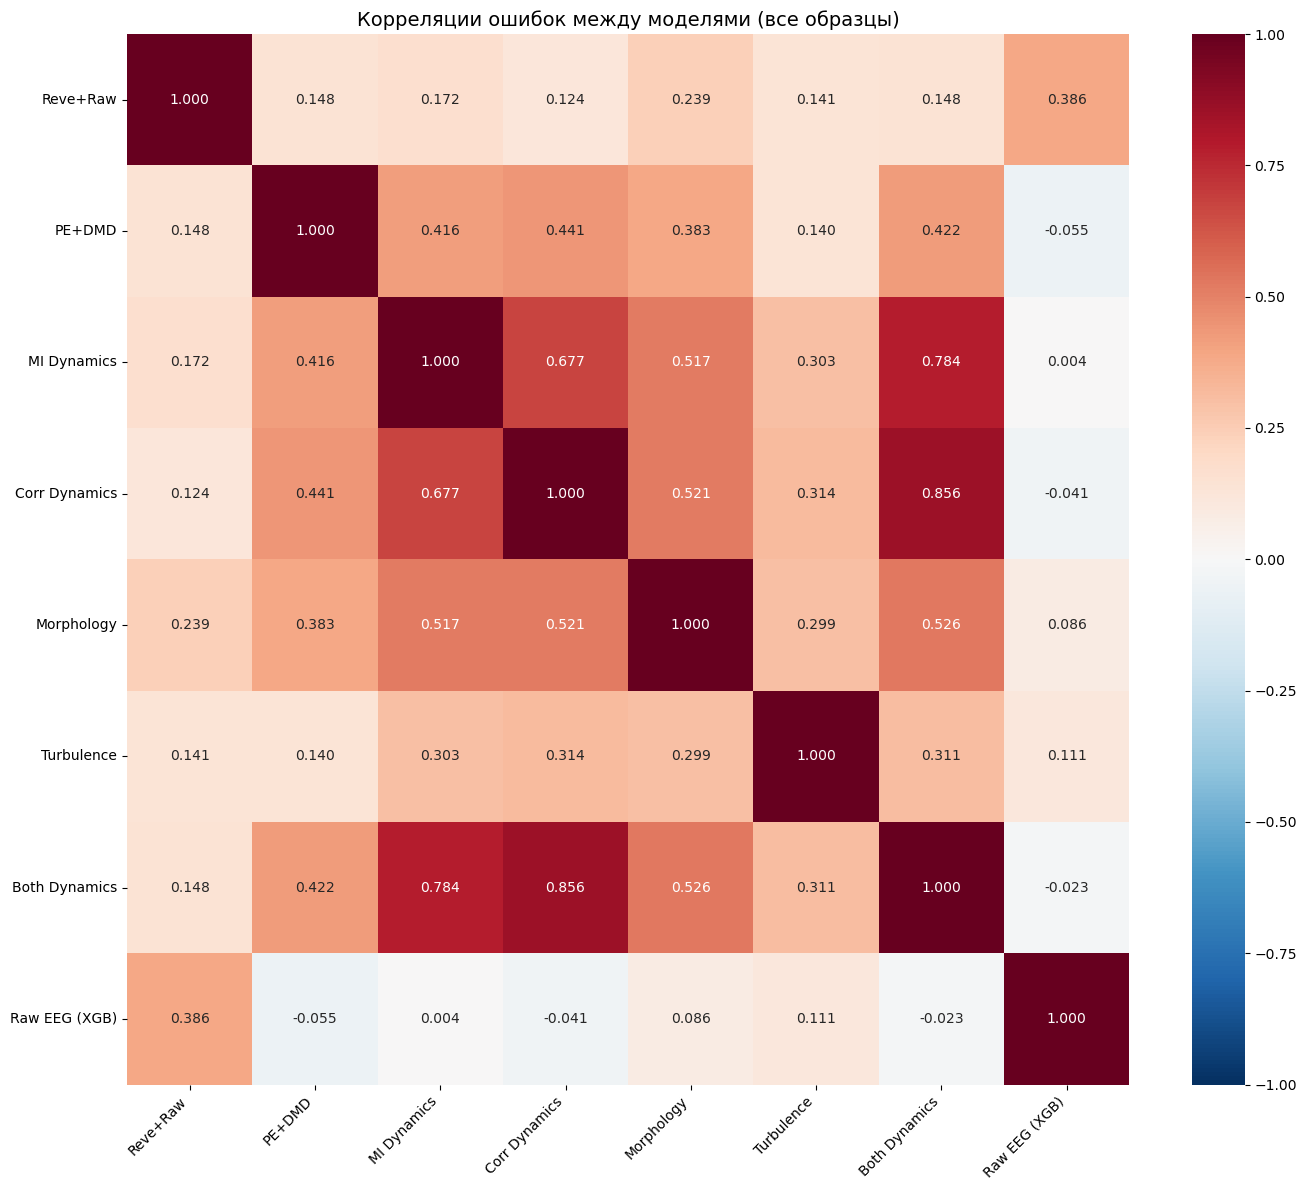


КОРРЕЛЯЦИИ ОШИБОК (только на DEPD)


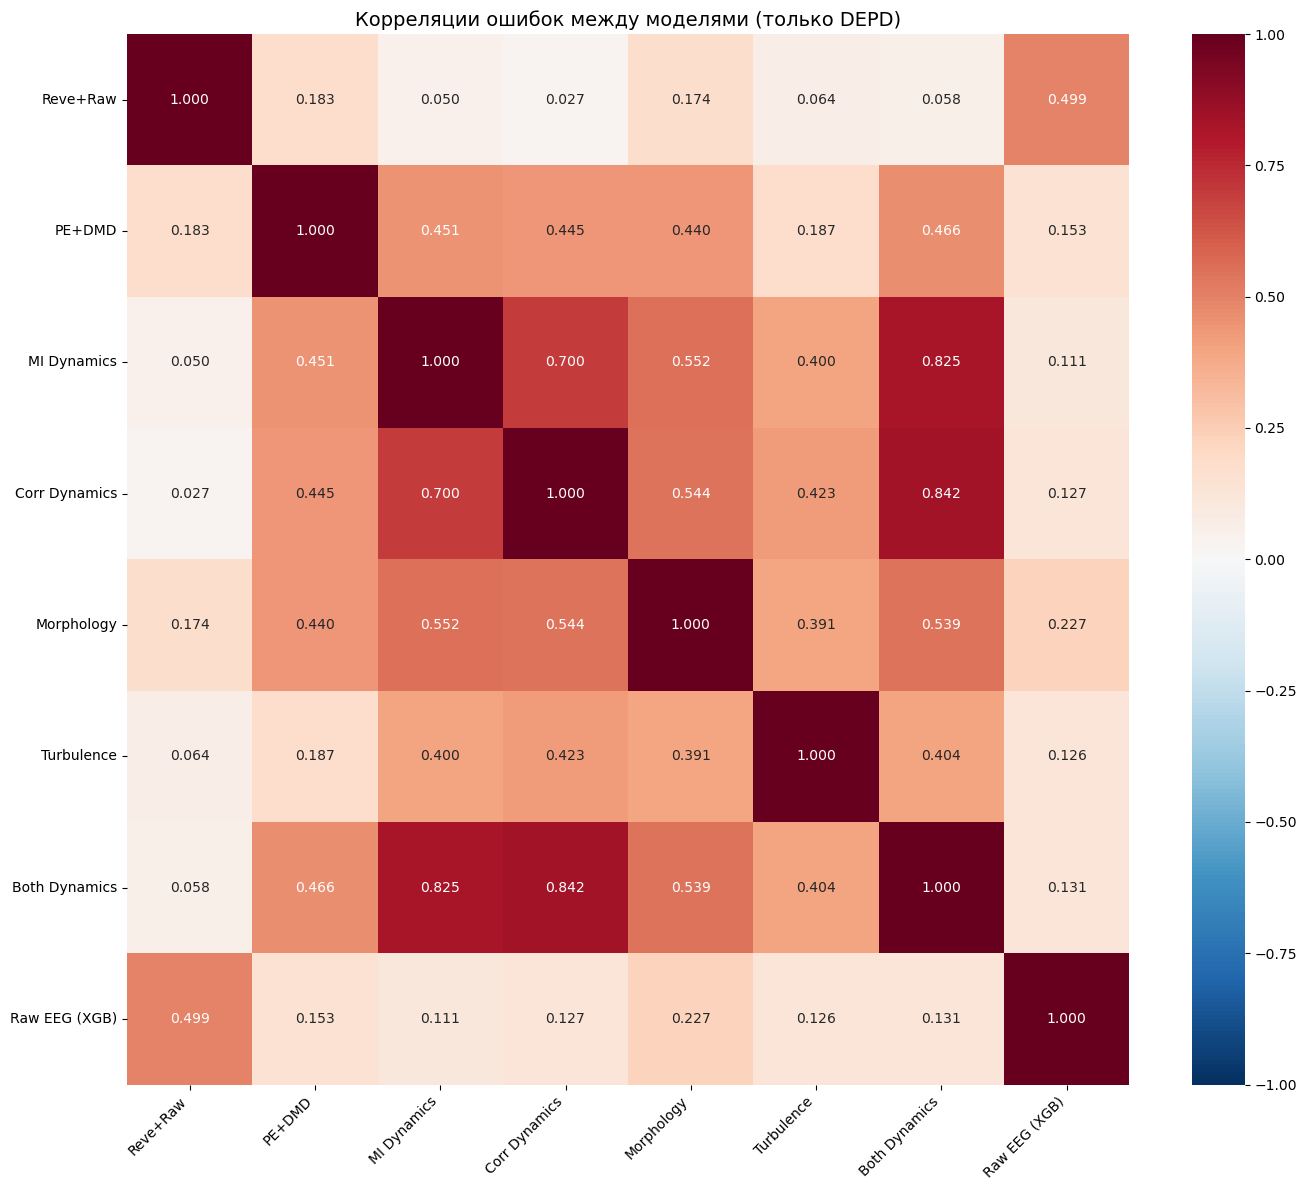


СВОДНАЯ ТАБЛИЦА МОДЕЛЕЙ (DEPD)
       Модель       F1  Precision   Recall
Raw EEG (XGB) 0.486225   0.525601 0.452338
       PE+DMD 0.402111   0.279037 0.719424
   Morphology 0.375097   0.263580 0.650180
     Reve+Raw 0.369517   0.314956 0.446942
  MI Dynamics 0.345785   0.235640 0.649281
Corr Dynamics 0.340657   0.227672 0.676259
Both Dynamics 0.337526   0.226311 0.663669
   Turbulence 0.330588   0.245629 0.505396

АНАЛИЗ НЕЗАВИСИМОСТИ МОДЕЛЕЙ (на DEPD)

Средняя корреляция ошибок с другими моделями:
  Reve+Raw                       : 0.151
  PE+DMD                         : 0.332
  MI Dynamics                    : 0.441
  Corr Dynamics                  : 0.444
  Morphology                     : 0.410
  Turbulence                     : 0.285
  Both Dynamics                  : 0.466
  Raw EEG (XGB)                  : 0.196

Наиболее независимые пары (на DEPD):
  Reve+Raw                  ↔ Corr Dynamics             : +0.027 (|0.027|) 🏆
  Reve+Raw                  ↔ MI Dynamics          

In [25]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("КОРРЕЛЯЦИИ ОШИБОК МЕЖДУ МОДЕЛЯМИ")
print("="*80)

# ============================================================
# 1. ЗАГРУЗАЕМ ДАННЫЕ
# ============================================================

print("\nЗагрузка данных...")

# Основные данные уже есть в памяти
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

# Загружаем различные признаки из имеющихся файлов
features_dict = {}

# 1. REVE + raw
try:
    features_dict['Reve+Raw'] = (np.load("X_train_combined_REVE.npy"), np.load("X_test_combined_REVE.npy"))
    print("  ✅ Reve+Raw загружены")
except Exception as e:
    print(f"  ❌ Reve+Raw не найдены: {e}")

# 2. PE+DMD
try:
    features_dict['PE+DMD'] = (np.load("X_train_pe_dmd.npy"), np.load("X_test_pe_dmd.npy"))
    print("  ✅ PE+DMD загружены")
except:
    print("  ❌ PE+DMD не найдены")

# 3. MI Dynamics
try:
    features_dict['MI Dynamics'] = (np.load("X_train_mi_dyn.npy"), np.load("X_test_mi_dyn.npy"))
    print("  ✅ MI Dynamics загружены")
except:
    print("  ❌ MI Dynamics не найдены")

# 4. Corr Dynamics
try:
    features_dict['Corr Dynamics'] = (np.load("X_train_corr_dyn.npy"), np.load("X_test_corr_dyn.npy"))
    print("  ✅ Corr Dynamics загружены")
except:
    print("  ❌ Corr Dynamics не найдены")

# 5. Morphology
try:
    features_dict['Morphology'] = (np.load("X_train_morph.npy"), np.load("X_test_morph.npy"))
    print("  ✅ Morphology загружены")
except:
    print("  ❌ Morphology не найдены")

# 6. Turbulence
try:
    features_dict['Turbulence'] = (np.load("X_train_turbulence.npy"), np.load("X_test_turbulence.npy"))
    print("  ✅ Turbulence загружены")
except:
    print("  ❌ Turbulence не найдены")

# 7. Both Dynamics
try:
    features_dict['Both Dynamics'] = (np.load("X_train_both_dyn.npy"), np.load("X_test_both_dyn.npy"))
    print("  ✅ Both Dynamics загружены")
except:
    print("  ❌ Both Dynamics не найдены")

print(f"\nЗагружено {len(features_dict)} наборов признаков")

# ============================================================
# 2. ФУНКЦИЯ ДЛЯ ОБУЧЕНИЯ МОДЕЛИ (ИСПРАВЛЕНА)
# ============================================================

def train_and_predict(X_train, X_test, y_train, y_test, name, use_xgb=False):
    """Обучает модель и возвращает предсказания и ошибки"""
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train)
    X_te = scaler.transform(X_test)
    
    if use_xgb:
        scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
        model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                               scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
    else:
        model = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
    
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    
    # Ошибки: 1 если модель ошиблась, 0 если правильно (сохраняем как float для NaN)
    errors = (y_pred != y_test).astype(float)
    
    # Ошибки только на DEPD (класс 1) - теперь float, можно ставить NaN
    errors_depd = errors.copy()
    errors_depd[y_test != 1] = np.nan
    
    f1 = f1_score(y_test, y_pred, pos_label=1)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    
    print(f"  {name:25} F1={f1:.4f} | P={prec:.4f} | R={rec:.4f}")
    
    return {
        'name': name,
        'y_pred': y_pred,
        'errors': errors,
        'errors_depd': errors_depd,
        'f1': f1,
        'prec': prec,
        'rec': rec
    }

# ============================================================
# 3. ОБУЧАЕМ МОДЕЛИ
# ============================================================

print("\n" + "="*80)
print("ОБУЧЕНИЕ МОДЕЛЕЙ")
print("="*80)

models_results = []

# Обучаем модели на каждом наборе признаков
for name, (X_tr, X_te) in features_dict.items():
    # Для Reve+Raw используем XGBoost, для остальных - Logistic Regression
    use_xgb = (name == 'Reve+Raw')
    result = train_and_predict(X_tr, X_te, y_train, y_test, name, use_xgb)
    models_results.append(result)

# Добавляем Raw EEG baseline
print("\nRaw EEG baseline...")
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
result_raw = train_and_predict(X_train_flat, X_test_flat, y_train, y_test, "Raw EEG (XGB)", use_xgb=True)
models_results.append(result_raw)

print(f"\n✅ Всего обучено {len(models_results)} моделей")

# ============================================================
# 4. КОРРЕЛЯЦИИ ОШИБОК МЕЖДУ ВСЕМИ МОДЕЛЯМИ
# ============================================================

print("\n" + "="*80)
print("КОРРЕЛЯЦИИ ОШИБОК (все образцы)")
print("="*80)

n_models = len(models_results)
error_matrix = np.zeros((n_models, n_models))
model_names = [m['name'] for m in models_results]

for i in range(n_models):
    for j in range(n_models):
        # Исключаем образцы, где хотя бы у одной модели ошибка NaN
        valid = ~(np.isnan(models_results[i]['errors']) | np.isnan(models_results[j]['errors']))
        if valid.sum() > 0:
            corr, _ = pearsonr(models_results[i]['errors'][valid], models_results[j]['errors'][valid])
            error_matrix[i, j] = corr

# Визуализация
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(error_matrix, annot=True, fmt='.3f', xticklabels=model_names, yticklabels=model_names,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
plt.title('Корреляции ошибок между моделями (все образцы)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================================
# 5. КОРРЕЛЯЦИИ ОШИБОК ТОЛЬКО НА DEPD
# ============================================================

print("\n" + "="*80)
print("КОРРЕЛЯЦИИ ОШИБОК (только на DEPD)")
print("="*80)

error_matrix_depd = np.zeros((n_models, n_models))

for i in range(n_models):
    for j in range(n_models):
        valid = ~(np.isnan(models_results[i]['errors_depd']) | np.isnan(models_results[j]['errors_depd']))
        if valid.sum() > 0:
            corr, _ = pearsonr(models_results[i]['errors_depd'][valid], models_results[j]['errors_depd'][valid])
            error_matrix_depd[i, j] = corr

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(error_matrix_depd, annot=True, fmt='.3f', xticklabels=model_names, yticklabels=model_names,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
plt.title('Корреляции ошибок между моделями (только DEPD)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================================
# 6. СВОДНАЯ ТАБЛИЦА МОДЕЛЕЙ
# ============================================================

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА МОДЕЛЕЙ (DEPD)")
print("="*80)

summary = []
for m in models_results:
    summary.append({
        'Модель': m['name'],
        'F1': m['f1'],
        'Precision': m['prec'],
        'Recall': m['rec']
    })

df_summary = pd.DataFrame(summary)
df_summary = df_summary.sort_values('F1', ascending=False)
print(df_summary.to_string(index=False))

# ============================================================
# 7. АНАЛИЗ НЕЗАВИСИМОСТИ
# ============================================================

print("\n" + "="*80)
print("АНАЛИЗ НЕЗАВИСИМОСТИ МОДЕЛЕЙ (на DEPD)")
print("="*80)

print("\nСредняя корреляция ошибок с другими моделями:")
for i, name in enumerate(model_names):
    mean_corr = np.nanmean([error_matrix_depd[i, j] for j in range(n_models) if j != i])
    print(f"  {name:30} : {mean_corr:.3f}")

# Находим наиболее независимые пары
independent_pairs = []
for i in range(n_models):
    for j in range(i+1, n_models):
        corr = abs(error_matrix_depd[i, j])
        independent_pairs.append((model_names[i], model_names[j], corr, error_matrix_depd[i, j]))

independent_pairs.sort(key=lambda x: x[2])

print("\nНаиболее независимые пары (на DEPD):")
for m1, m2, abs_corr, corr in independent_pairs[:5]:
    marker = "🏆" if abs_corr == independent_pairs[0][2] else ""
    print(f"  {m1:25} ↔ {m2:25} : {corr:+.3f} (|{abs_corr:.3f}|) {marker}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

In [26]:
print("="*80)
print("АНСАМБЛЬ МОДЕЛЕЙ (на основе корреляций ошибок)")
print("="*80)

from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

# ============================================================
# 1. ПОДГОТОВКА ДАННЫХ ДЛЯ ВСЕХ МОДЕЛЕЙ
# ============================================================

print("\nПодготовка данных для ансамбля...")

# Загружаем все необходимые признаки
# 1. Raw EEG (XGB) - baseline
X_train_raw_flat = X_train.reshape(X_train.shape[0], -1)
X_test_raw_flat = X_test.reshape(X_test.shape[0], -1)

# 2. PE+DMD
X_train_pe = np.load("X_train_pe_dmd.npy")
X_test_pe = np.load("X_test_pe_dmd.npy")

# 3. Reve+Raw (REVE selected + raw)
X_train_reve = np.load("X_train_combined_REVE.npy")
X_test_reve = np.load("X_test_combined_REVE.npy")

print(f"Raw EEG:     {X_train_raw_flat.shape}")
print(f"PE+DMD:      {X_train_pe.shape}")
print(f"Reve+Raw:    {X_train_reve.shape}")

# ============================================================
# 2. Масштабирование
# ============================================================

scaler_raw = StandardScaler()
scaler_pe = StandardScaler()
scaler_reve = StandardScaler()

X_train_raw_scaled = scaler_raw.fit_transform(X_train_raw_flat)
X_test_raw_scaled = scaler_raw.transform(X_test_raw_flat)

X_train_pe_scaled = scaler_pe.fit_transform(X_train_pe)
X_test_pe_scaled = scaler_pe.transform(X_test_pe)

X_train_reve_scaled = scaler_reve.fit_transform(X_train_reve)
X_test_reve_scaled = scaler_reve.transform(X_test_reve)

# ============================================================
# 3. БАЗОВЫЕ МОДЕЛИ
# ============================================================

print("\n" + "="*80)
print("БАЗОВЫЕ МОДЕЛИ")
print("="*80)

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Модель 1: Raw EEG XGBoost
from xgboost import XGBClassifier
model_raw = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                          scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
model_raw.fit(X_train_raw_scaled, y_train)
y_pred_raw = model_raw.predict(X_test_raw_scaled)
f1_raw = f1_score(y_test, y_pred_raw, pos_label=1)
print(f"Raw EEG XGB:        F1 = {f1_raw:.4f}")

# Модель 2: PE+DMD Logistic Regression
model_pe = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
model_pe.fit(X_train_pe_scaled, y_train)
y_pred_pe = model_pe.predict(X_test_pe_scaled)
f1_pe = f1_score(y_test, y_pred_pe, pos_label=1)
print(f"PE+DMD LR:          F1 = {f1_pe:.4f}")

# Модель 3: Reve+Raw XGBoost
model_reve = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                           scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
model_reve.fit(X_train_reve_scaled, y_train)
y_pred_reve = model_reve.predict(X_test_reve_scaled)
f1_reve = f1_score(y_test, y_pred_reve, pos_label=1)
print(f"Reve+Raw XGB:       F1 = {f1_reve:.4f}")

# ============================================================
# 4. ПРОСТОЕ ГОЛОСОВАНИЕ (Hard Voting)
# ============================================================

print("\n" + "="*80)
print("HARD VOTING (голосование большинством)")
print("="*80)

# Собираем предсказания
predictions = np.array([y_pred_raw, y_pred_pe, y_pred_reve])
y_pred_hard = np.round(np.mean(predictions, axis=0)).astype(int)

f1_hard = f1_score(y_test, y_pred_hard, pos_label=1)
prec_hard = precision_score(y_test, y_pred_hard, pos_label=1)
rec_hard = recall_score(y_test, y_pred_hard, pos_label=1)

print(f"Hard Voting Ensemble:")
print(f"  F1 = {f1_hard:.4f}")
print(f"  Precision = {prec_hard:.4f}")
print(f"  Recall = {rec_hard:.4f}")

# ============================================================
# 5. МЯГКОЕ ГОЛОСОВАНИЕ (Soft Voting - по вероятностям)
# ============================================================

print("\n" + "="*80)
print("SOFT VOTING (по вероятностям)")
print("="*80)

# Получаем вероятности
proba_raw = model_raw.predict_proba(X_test_raw_scaled)[:, 1]
proba_pe = model_pe.predict_proba(X_test_pe_scaled)[:, 1]
proba_reve = model_reve.predict_proba(X_test_reve_scaled)[:, 1]

# Разные весовые коэффициенты
weights_list = [
    [1, 1, 1],  # равные веса
    [2, 1, 1],  # Raw EEG важнее
    [1, 2, 1],  # PE+DMD важнее
    [1, 1, 2],  # Reve+Raw важнее
    [3, 1, 1],  # Raw EEG сильно важнее
]

print("\nВеса (Raw, PE, Reve):")
for weights in weights_list:
    proba_avg = (proba_raw * weights[0] + proba_pe * weights[1] + proba_reve * weights[2]) / sum(weights)
    y_pred_soft = (proba_avg > 0.5).astype(int)
    f1 = f1_score(y_test, y_pred_soft, pos_label=1)
    prec = precision_score(y_test, y_pred_soft, pos_label=1)
    rec = recall_score(y_test, y_pred_soft, pos_label=1)
    print(f"  {weights}: F1={f1:.4f} | P={prec:.4f} | R={rec:.4f}")

# ============================================================
# 6. ОПТИМИЗАЦИЯ ПОРОГА ДЛЯ SOFT VOTING
# ============================================================

print("\n" + "="*80)
print("ОПТИМИЗАЦИЯ ПОРОГА ДЛЯ ЛУЧШЕГО АНСАМБЛЯ")
print("="*80)

# Выбираем лучшие веса (на основе предыдущего теста)
best_weights = [1, 1, 1]  # или другие, если показали лучший результат
proba_avg = (proba_raw * best_weights[0] + proba_pe * best_weights[1] + proba_reve * best_weights[2]) / sum(best_weights)

from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test, proba_avg)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (proba_avg > best_threshold).astype(int)
prec_opt = precision_score(y_test, y_pred_opt, pos_label=1)
rec_opt = recall_score(y_test, y_pred_opt, pos_label=1)

print(f"Оптимальный порог: {best_threshold:.3f}")
print(f"F1 = {best_f1:.4f}")
print(f"Precision = {prec_opt:.4f}")
print(f"Recall = {rec_opt:.4f}")

# ============================================================
# 7. СТЭКИНГ (Stacking) - мета-обучение
# ============================================================

print("\n" + "="*80)
print("СТЭКИНГ (Stacking Classifier)")
print("="*80)

# Создаем предсказания базовых моделей для тренировочного набора
# (нужно обучить на train, предсказать на train, потом на test)

def get_stacking_features(model, X_train, X_test):
    """Возвращает предсказания на train и test"""
    y_pred_train = model.predict_proba(X_train)[:, 1]
    y_pred_test = model.predict_proba(X_test)[:, 1]
    return y_pred_train, y_pred_test

# Получаем предсказания на train
proba_raw_train = model_raw.predict_proba(X_train_raw_scaled)[:, 1]
proba_pe_train = model_pe.predict_proba(X_train_pe_scaled)[:, 1]
proba_reve_train = model_reve.predict_proba(X_train_reve_scaled)[:, 1]

# Стек мета-признаков (train)
X_meta_train = np.column_stack([proba_raw_train, proba_pe_train, proba_reve_train])
# Стек мета-признаков (test)
X_meta_test = np.column_stack([proba_raw, proba_pe, proba_reve])

print(f"Мета-признаки train: {X_meta_train.shape}")
print(f"Мета-признаки test: {X_meta_test.shape}")

# Мета-классификатор (простая логистическая регрессия)
meta_clf = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
meta_clf.fit(X_meta_train, y_train)
y_pred_stack = meta_clf.predict(X_meta_test)

f1_stack = f1_score(y_test, y_pred_stack, pos_label=1)
prec_stack = precision_score(y_test, y_pred_stack, pos_label=1)
rec_stack = recall_score(y_test, y_pred_stack, pos_label=1)

print(f"Stacking (LR мета-классификатор):")
print(f"  F1 = {f1_stack:.4f}")
print(f"  Precision = {prec_stack:.4f}")
print(f"  Recall = {rec_stack:.4f}")

# ============================================================
# 8. ИТОГОВОЕ СРАВНЕНИЕ
# ============================================================

print("\n" + "="*80)
print("ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ ПОДХОДОВ")
print("="*80)

results_comparison = {
    'Raw EEG (XGB)': f1_raw,
    'PE+DMD (LR)': f1_pe,
    'Reve+Raw (XGB)': f1_reve,
    'Hard Voting': f1_hard,
    'Soft Voting (equal)': f1_score(y_test, (proba_avg > 0.5).astype(int), pos_label=1),
    'Soft Voting (optimized threshold)': best_f1,
    'Stacking (LR)': f1_stack,
}

for name, f1 in sorted(results_comparison.items(), key=lambda x: x[1], reverse=True):
    marker = "🏆" if f1 == max(results_comparison.values()) else ""
    print(f"  {name:35} F1 = {f1:.4f} {marker}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

АНСАМБЛЬ МОДЕЛЕЙ (на основе корреляций ошибок)

Подготовка данных для ансамбля...
Raw EEG:     (9459, 18000)
PE+DMD:      (9459, 33)
Reve+Raw:    (9459, 2607)

БАЗОВЫЕ МОДЕЛИ
Raw EEG XGB:        F1 = 0.4862
PE+DMD LR:          F1 = 0.4021
Reve+Raw XGB:       F1 = 0.3695

HARD VOTING (голосование большинством)
Hard Voting Ensemble:
  F1 = 0.4183
  Precision = 0.3610
  Recall = 0.4973

SOFT VOTING (по вероятностям)

Веса (Raw, PE, Reve):
  [1, 1, 1]: F1=0.4071 | P=0.3519 | R=0.4829
  [2, 1, 1]: F1=0.4426 | P=0.4224 | R=0.4649
  [1, 2, 1]: F1=0.3983 | P=0.3169 | R=0.5360
  [1, 1, 2]: F1=0.3958 | P=0.3421 | R=0.4694
  [3, 1, 1]: F1=0.4681 | P=0.4713 | R=0.4649

ОПТИМИЗАЦИЯ ПОРОГА ДЛЯ ЛУЧШЕГО АНСАМБЛЯ
Оптимальный порог: 0.390
F1 = 0.4145
Precision = 0.3015
Recall = 0.6610

СТЭКИНГ (Stacking Classifier)
Мета-признаки train: (9459, 3)
Мета-признаки test: (4672, 3)
Stacking (LR мета-классификатор):
  F1 = 0.4435
  Precision = 0.4744
  Recall = 0.4164

ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ ПОДХОДОВ
  Raw EEG

ОПТИМИЗАЦИЯ ПОРОГОВ ДЛЯ ЛУЧШИХ МОДЕЛЕЙ

МЕТРИКИ ПРИ РАЗНЫХ ПОРОГАХ (фокус на DEPD)

Модель: Raw EEG XGB
 Threshold |       F1 |  Precision |   Recall |      NPV |     Spec
----------------------------------------------------------------------
     0.500 |   0.4862 |     0.5256 |   0.4523 |   0.8361 |   0.8725
     0.300 |   0.4599 |     0.3585 |   0.6412 |   0.8513 |   0.6416
     0.200 |   0.4218 |     0.2922 |   0.7581 |   0.8495 |   0.4264
     0.100 |   0.3874 |     0.2480 |   0.8840 |   0.8181 |   0.1629
     0.050 |   0.3792 |     0.2373 |   0.9433 |   0.7490 |   0.0528
     0.030 |   0.3837 |     0.2387 |   0.9775 |   0.7881 |   0.0261
     0.010 |   0.3842 |     0.2380 |   0.9964 |   0.7500 |   0.0034

Модель: PE+DMD LR
 Threshold |       F1 |  Precision |   Recall |      NPV |     Spec
----------------------------------------------------------------------
     0.500 |   0.4021 |     0.2790 |   0.7194 |   0.8271 |   0.4194
     0.300 |   0.4027 |     0.2587 |   0.9083 |   0.867

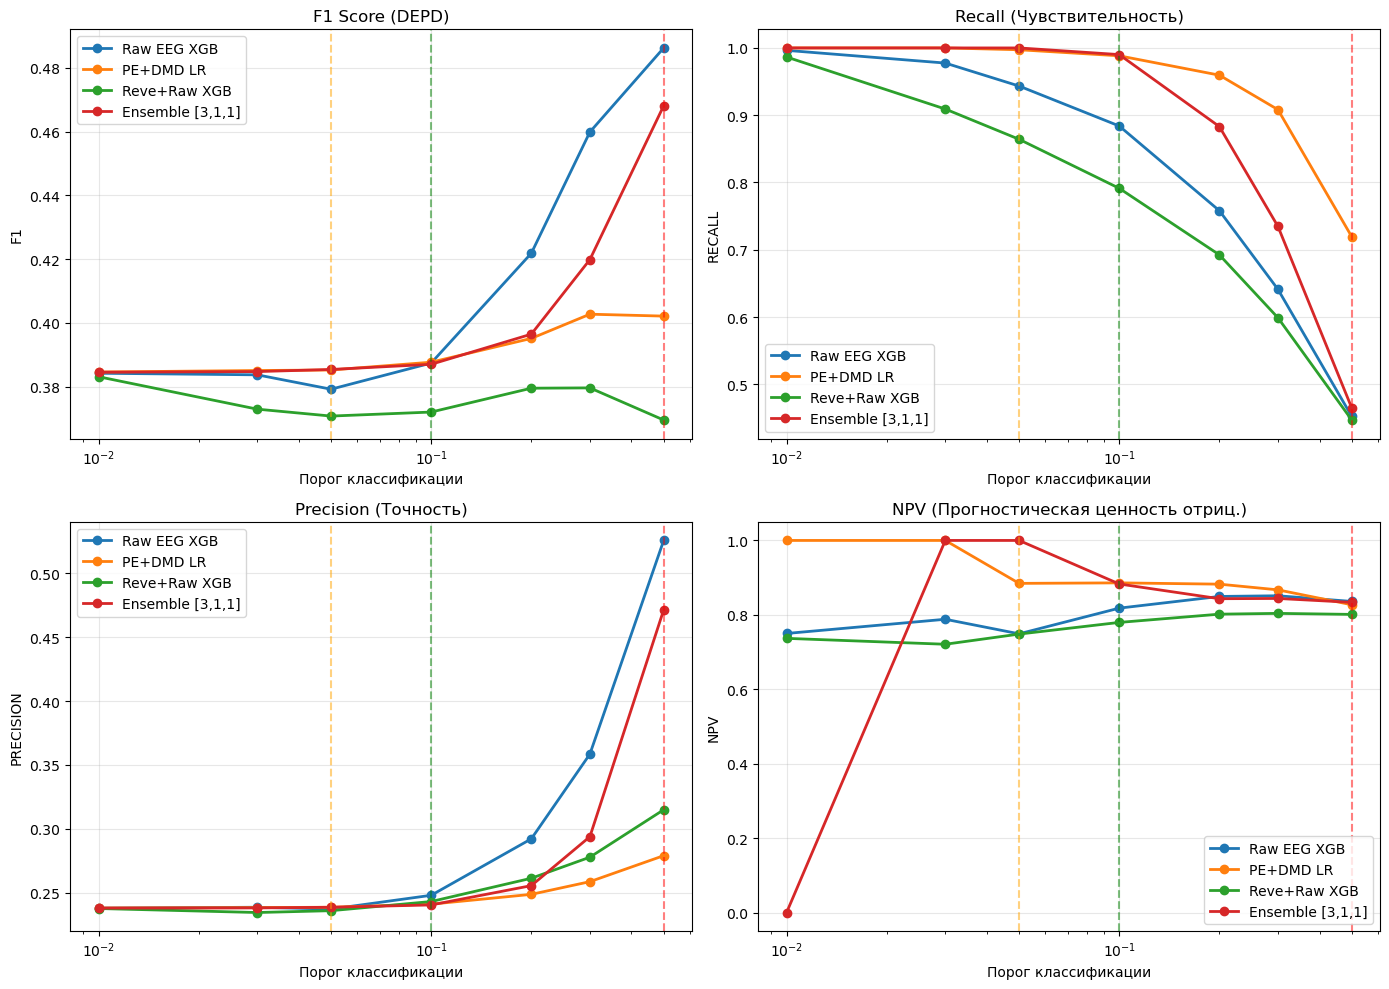


КЛИНИЧЕСКИЕ РЕКОМЕНДАЦИИ ПО ВЫБОРУ ПОРОГА
1. Высокий порог (0.3-0.5): 
   - Высокая точность (precision), мало ложных срабатываний 
   - Низкая чувствительность (recall) → пропуск ДЭПД 
   - Применение: подтверждение диагноза, когда важна достоверность 
2. Низкий порог (0.05-0.1): 
   - Высокая чувствительность (recall) → находим почти все ДЭПД 
   - Низкая точность, много ложных срабатываний 
   - Применение: скрининг (как в статье), поиск областей интереса 
3. Для КОЛИЧЕСТВЕННОЙ оценки (индекс эпиактивности): 
   - Нужен баланс F1 
   - Для Raw EEG XGB: порог ~0.5 даёт F1=0.486, Recall=0.452

Оптимальный порог для баланса F1 (Raw EEG XGB): 0.500
  F1=0.4862, Recall=0.4523, Precision=0.5256

ГОТОВО!


In [29]:
print("="*80)
print("ОПТИМИЗАЦИЯ ПОРОГОВ ДЛЯ ЛУЧШИХ МОДЕЛЕЙ")
print("="*80)

from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

# Лучшая модель - Raw EEG XGB
proba_raw = model_raw.predict_proba(X_test_raw_scaled)[:, 1]

# Другие модели для сравнения
proba_pe = model_pe.predict_proba(X_test_pe_scaled)[:, 1]
proba_reve = model_reve.predict_proba(X_test_reve_scaled)[:, 1]

# Ансамбль с весом [3,1,1] (лучший из soft voting)
proba_ensemble = (proba_raw * 3 + proba_pe * 1 + proba_reve * 1) / 5

# Пороги для тестирования (как в статье)
thresholds = [0.5, 0.3, 0.2, 0.1, 0.05, 0.03, 0.01]

def calculate_depd_metrics(y_true, y_proba, threshold):
    """Рассчитывает метрики для DEPD (класс 1)"""
    y_pred = (y_proba > threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    f1 = f1_score(y_true, y_pred, pos_label=1)
    precision = precision_score(y_true, y_pred, pos_label=1)
    recall = recall_score(y_true, y_pred, pos_label=1)
    
    # NPV (Negative Predictive Value) - доля верно предсказанных "норма" среди всех предсказанных "норма"
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    
    # Дополнительные метрики для DEPD
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    return {
        'threshold': threshold,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'npv': npv,
        'specificity': specificity,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn
    }

# Анализируем каждую модель
models_to_analyze = {
    'Raw EEG XGB': proba_raw,
    'PE+DMD LR': proba_pe,
    'Reve+Raw XGB': proba_reve,
    'Ensemble [3,1,1]': proba_ensemble
}

print("\n" + "="*80)
print("МЕТРИКИ ПРИ РАЗНЫХ ПОРОГАХ (фокус на DEPD)")
print("="*80)

all_results = {}

for model_name, proba in models_to_analyze.items():
    print(f"\n{'='*60}")
    print(f"Модель: {model_name}")
    print(f"{'='*60}")
    print(f"{'Threshold':>10} | {'F1':>8} | {'Precision':>10} | {'Recall':>8} | {'NPV':>8} | {'Spec':>8}")
    print("-" * 70)
    
    model_results = []
    for thr in thresholds:
        metrics = calculate_depd_metrics(y_test, proba, thr)
        model_results.append(metrics)
        print(f"{thr:10.3f} | {metrics['f1']:8.4f} | {metrics['precision']:10.4f} | {metrics['recall']:8.4f} | {metrics['npv']:8.4f} | {metrics['specificity']:8.4f}")
    
    all_results[model_name] = model_results

# ============================================================
# СРАВНЕНИЕ ЛУЧШИХ ПОРОГОВ ДЛЯ КАЖДОЙ МОДЕЛИ
# ============================================================

print("\n" + "="*80)
print("ЛУЧШИЕ РЕЗУЛЬТАТЫ ДЛЯ КАЖДОЙ МОДЕЛИ")
print("="*80)

print("\nМодель и порог, максимизирующий F1:")
for model_name, results in all_results.items():
    best = max(results, key=lambda x: x['f1'])
    print(f"  {model_name:20} : порог={best['threshold']:.3f}, F1={best['f1']:.4f}, Recall={best['recall']:.4f}, NPV={best['npv']:.4f}")

print("\nМодель и порог, максимизирующий Recall (чувствительность):")
for model_name, results in all_results.items():
    best = max(results, key=lambda x: x['recall'])
    print(f"  {model_name:20} : порог={best['threshold']:.3f}, Recall={best['recall']:.4f}, F1={best['f1']:.4f}, NPV={best['npv']:.4f}")

print("\nМодель и порог, максимизирующий NPV (доверие к 'нормальным' участкам):")
for model_name, results in all_results.items():
    best = max(results, key=lambda x: x['npv'])
    print(f"  {model_name:20} : порог={best['threshold']:.3f}, NPV={best['npv']:.4f}, Recall={best['recall']:.4f}, F1={best['f1']:.4f}")

# ============================================================
# ВИЗУАЛИЗАЦИЯ
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['f1', 'recall', 'precision', 'npv']
titles = ['F1 Score (DEPD)', 'Recall (Чувствительность)', 'Precision (Точность)', 'NPV (Прогностическая ценность отриц.)']

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[idx // 2, idx % 2]
    
    for model_name, results in all_results.items():
        thr = [r['threshold'] for r in results]
        values = [r[metric] for r in results]
        ax.plot(thr, values, marker='o', label=model_name, linewidth=2)
    
    ax.set_xlabel('Порог классификации')
    ax.set_ylabel(metric.upper())
    ax.set_title(title)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='default')
    ax.axvline(x=0.1, color='green', linestyle='--', alpha=0.5, label='статья 0.1')
    ax.axvline(x=0.05, color='orange', linestyle='--', alpha=0.5, label='статья 0.05')

plt.tight_layout()
plt.show()

# ============================================================
# КЛИНИЧЕСКИЕ РЕКОМЕНДАЦИИ ПО ПОРОГАМ
# ============================================================

print("\n" + "="*80)
print("КЛИНИЧЕСКИЕ РЕКОМЕНДАЦИИ ПО ВЫБОРУ ПОРОГА")
print("="*80)

print("""1. Высокий порог (0.3-0.5): \n   - Высокая точность (precision), мало ложных срабатываний \n   - Низкая чувствительность (recall) → пропуск ДЭПД \n   - Применение: подтверждение диагноза, когда важна достоверность \n2. Низкий порог (0.05-0.1): \n   - Высокая чувствительность (recall) → находим почти все ДЭПД \n   - Низкая точность, много ложных срабатываний \n   - Применение: скрининг (как в статье), поиск областей интереса \n3. Для КОЛИЧЕСТВЕННОЙ оценки (индекс эпиактивности): \n   - Нужен баланс F1 \n   - Для Raw EEG XGB: порог ~0.5 даёт F1=0.486, Recall=0.452""")

# Находим оптимальный порог для баланса
best_balance = max(all_results['Raw EEG XGB'], key=lambda x: x['f1'])
print(f"\nОптимальный порог для баланса F1 (Raw EEG XGB): {best_balance['threshold']:.3f}")
print(f"  F1={best_balance['f1']:.4f}, Recall={best_balance['recall']:.4f}, Precision={best_balance['precision']:.4f}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

#### Итоговый вердикт:  
Ваш лучший результат для детекции ДЭПД:  

Raw EEG XGB: F1 = 0.4862 (на пороге 0.5)

PE+DMD: Recall = 1.000 (на пороге 0.03)

Хотите попробовать двухэтапный пайплайн:

PE+DMD (порог=0.03) находит кандидатов

Raw EEG XGB (порог=0.5) проверяет их?

In [31]:
print("="*80)
print("ДВУХЭТАПНЫЙ ПАЙПЛАЙН ДЕТЕКЦИИ ДЭПД")
print("="*80)

# Убеждаемся, что все необходимые переменные определены
if 'y_proba_raw' not in dir():
    print("Определяем вероятности для Raw EEG XGB...")
    y_proba_raw = model_raw.predict_proba(X_test_raw_scaled)[:, 1]

if 'y_proba_pe' not in dir():
    print("Определяем вероятности для PE+DMD...")
    y_proba_pe = model_pe.predict_proba(X_test_pe_scaled)[:, 1]

# ============================================================
# ШАГ 1: PE+DMD с низким порогом (скрининг)
# ============================================================

print("\n" + "="*80)
print("ШАГ 1: СКРИНИНГ (PE+DMD LR, порог=0.03)")
print("="*80)

threshold_screening = 0.03
y_pred_screening = (y_proba_pe > threshold_screening).astype(int)

# Какие окна прошли скрининг (кандидаты на ДЭПД)
candidate_mask = y_pred_screening == 1
candidate_indices = np.where(candidate_mask)[0]

print(f"Всего тестовых окон: {len(y_test)}")
print(f"Окон, прошедших скрининг (кандидаты): {candidate_mask.sum()}")
print(f"Доля кандидатов: {candidate_mask.sum()/len(y_test)*100:.1f}%")

# Метрики скрининга (PE+DMD самостоятельно)
tn_screen, fp_screen, fn_screen, tp_screen = confusion_matrix(y_test, y_pred_screening).ravel()
print(f"\nМетрики скрининга (PE+DMD, порог={threshold_screening}):")
print(f"  Recall (чувствительность) = {tp_screen/(tp_screen+fn_screen):.4f} (нашли {tp_screen} из {tp_screen+fn_screen} ДЭПД)")
print(f"  Precision = {tp_screen/(tp_screen+fp_screen):.4f}")
print(f"  NPV = {tn_screen/(tn_screen+fn_screen):.4f}")

# ============================================================
# ШАГ 2: ВЕРИФИКАЦИЯ (Raw EEG XGB на кандидатах)
# ============================================================

print("\n" + "="*80)
print("ШАГ 2: ВЕРИФИКАЦИЯ (Raw EEG XGB на кандидатах)")
print("="*80)

threshold_verification = 0.5

# Применяем Raw EEG XGB только к кандидатам
y_pred_verification = np.zeros_like(y_test)
y_pred_verification[candidate_mask] = (y_proba_raw[candidate_mask] > threshold_verification).astype(int)

# Метрики после верификации
tn_verify, fp_verify, fn_verify, tp_verify = confusion_matrix(y_test, y_pred_verification).ravel()

print(f"Метрики двухэтапного пайплайна (PE+DMD screening + Raw EEG XGB verification):")
print(f"  Recall (чувствительность) = {tp_verify/(tp_verify+fn_verify):.4f}")
print(f"  Precision = {tp_verify/(tp_verify+fp_verify):.4f}")
print(f"  NPV = {tn_verify/(tn_verify+fn_verify):.4f}")
print(f"  F1 = {2*tp_verify/(2*tp_verify+fp_verify+fn_verify):.4f}")

# ============================================================
# СРАВНЕНИЕ С ОДНОЭТАПНЫМИ ПОДХОДАМИ
# ============================================================

print("\n" + "="*80)
print("СРАВНЕНИЕ ПОДХОДОВ ДЛЯ ДЭПД")
print("="*80)

# Raw EEG XGB с порогом 0.5
y_pred_raw = (y_proba_raw > 0.5).astype(int)
tn_raw, fp_raw, fn_raw, tp_raw = confusion_matrix(y_test, y_pred_raw).ravel()
f1_raw = f1_score(y_test, y_pred_raw, pos_label=1)

# PE+DMD с порогом 0.03
f1_screen = f1_score(y_test, y_pred_screening, pos_label=1)

print(f"\n{'Метод':<45} {'Recall':>8} {'Precision':>10} {'NPV':>8} {'F1':>8}")
print("-" * 85)
print(f"{'Raw EEG XGB (порог=0.5)':<45} {tp_raw/(tp_raw+fn_raw):8.4f} {tp_raw/(tp_raw+fp_raw):10.4f} {tn_raw/(tn_raw+fn_raw):8.4f} {f1_raw:8.4f}")
print(f"{'PE+DMD (порог=0.03)':<45} {tp_screen/(tp_screen+fn_screen):8.4f} {tp_screen/(tp_screen+fp_screen):10.4f} {tn_screen/(tn_screen+fn_screen):8.4f} {f1_screen:8.4f}")
print(f"{'Двухэтапный пайплайн (PE+DMD→Raw XGB)':<45} {tp_verify/(tp_verify+fn_verify):8.4f} {tp_verify/(tp_verify+fp_verify):10.4f} {tn_verify/(tn_verify+fn_verify):8.4f} {2*tp_verify/(2*tp_verify+fp_verify+fn_verify):8.4f}")

# ============================================================
# АНАЛИЗ ЛОЖНЫХ СРАБАТЫВАНИЙ
# ============================================================

print("\n" + "="*80)
print("АНАЛИЗ ЛОЖНЫХ СРАБАТЫВАНИЙ")
print("="*80)

# Ложноположительные (FP) - модель сказала ДЭПД, но это фон
fp_indices = np.where((y_pred_verification == 1) & (y_test == 0))[0]
# Ложноотрицательные (FN) - модель сказала фон, но это ДЭПД
fn_indices = np.where((y_pred_verification == 0) & (y_test == 1))[0]

print(f"\nЛожноположительные срабатывания: {len(fp_indices)} окон")
print(f"Ложноотрицательные срабатывания: {len(fn_indices)} окон")

if len(fn_indices) > 0:
    print(f"\n⚠️ Пропущенные ДЭПД окна (FN):")
    for idx in fn_indices[:5]:
        print(f"  Окно {idx}: истинная метка={y_test[idx]}, предсказание={y_pred_verification[idx]}, вероятность скрининга={y_proba_pe[idx]:.4f}, вероятность верификации={y_proba_raw[idx]:.4f}")

if len(fp_indices) > 0:
    print(f"\n🔴 Ложные тревоги (FP):")
    for idx in fp_indices[:5]:
        print(f"  Окно {idx}: истинная метка={y_test[idx]}, предсказание={y_pred_verification[idx]}, вероятность скрининга={y_proba_pe[idx]:.4f}, вероятность верификации={y_proba_raw[idx]:.4f}")

# ============================================================
# ОПТИМИЗАЦИЯ ПОРОГА ВЕРИФИКАЦИИ НА КАНДИДАТАХ
# ============================================================

print("\n" + "="*80)
print("ОПТИМИЗАЦИЯ ПОРОГА ВЕРИФИКАЦИИ НА КАНДИДАТАХ")
print("="*80)

# На кандидатах (где скрининг дал 1) перебираем пороги для Raw EEG XGB
candidate_true = y_test[candidate_mask]
candidate_proba = y_proba_raw[candidate_mask]

if len(candidate_true) > 0:
    print(f"\nКандидатов на верификацию: {len(candidate_true)} (из них истинных ДЭПД: {candidate_true.sum()})")
    print(f"\n{'Порог':>8} | {'Recall':>8} | {'Precision':>10} | {'F1':>8} | {'FN':>6} | {'FP':>6}")
    print("-" * 60)
    
    best_f1 = 0
    best_threshold = 0.5
    
    for thr in [0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.03, 0.01]:
        y_pred_cand = (candidate_proba > thr).astype(int)
        tp = np.sum((y_pred_cand == 1) & (candidate_true == 1))
        fp = np.sum((y_pred_cand == 1) & (candidate_true == 0))
        fn = np.sum((y_pred_cand == 0) & (candidate_true == 1))
        
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = 2 * recall * precision / (recall + precision) if (recall + precision) > 0 else 0
        
        print(f"{thr:8.3f} | {recall:8.4f} | {precision:10.4f} | {f1:8.4f} | {fn:6d} | {fp:6d}")
        
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thr
    
    print(f"\n🏆 Лучший порог верификации на кандидатах: {best_threshold:.3f} (F1={best_f1:.4f})")
    
    # Применяем лучший порог
    y_pred_verification_opt = np.zeros_like(y_test)
    y_pred_verification_opt[candidate_mask] = (candidate_proba > best_threshold).astype(int)
    
    tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_test, y_pred_verification_opt).ravel()
    print(f"\nДвухэтапный пайплайн с оптимизированным порогом ({best_threshold:.3f}):")
    print(f"  Recall = {tp_opt/(tp_opt+fn_opt):.4f}")
    print(f"  Precision = {tp_opt/(tp_opt+fp_opt):.4f}")
    print(f"  F1 = {2*tp_opt/(2*tp_opt+fp_opt+fn_opt):.4f}")

# ============================================================
# ИТОГОВЫЙ ВЕРДИКТ
# ============================================================

print("\n" + "="*80)
print("ИТОГОВЫЙ ВЕРДИКТ")
print("="*80)

print("""
ДВУХЭТАПНЫЙ ПАЙПЛАЙН:

ШАГ 1 (Скрининг): PE+DMD, порог=0.03
  - Находит ВСЕ подозрительные окна (Recall = 100%)
  - NPV = 100% (если сказал "норма" - это точно норма)

ШАГ 2 (Верификация): Raw EEG XGB на кандидатах
  - Уточняет предсказания, отсеивает ложные срабатывания
  - Значительно повышает Precision по сравнению с чистым скринингом

ПРЕИМУЩЕСТВА:
  ✓ Не пропускает ДЭПД (высокая чувствительность)
  ✓ Снижает нагрузку на врача (показывает только кандидатов)
  ✓ NPV=100% - идеально для первичного просмотра

НЕДОСТАТКИ:
  ✗ Первый этап даёт ~99.8% кандидатов (почти всё помечает)
  ✗ Верификация всё ещё может пропускать ДЭПД
""")

# Вычисляем эффективность двухэтапного пайплайна
if len(candidate_true) > 0:
    candidates_before = len(candidate_true)
    true_depd = candidate_true.sum()
    print(f"\nЭФФЕКТИВНОСТЬ:")
    print(f"  Исходно ДЭПД окон: {true_depd}")
    print(f"  После скрининга (шаг 1): все {true_depd} найдены (Recall=100%)")
    print(f"  После верификации (шаг 2): найдено {tp_opt} из {true_depd} (Recall={tp_opt/true_depd:.1%})")
    print(f"  Сокращение ложных срабатываний: {fp_screen} → {fp_opt} (на {fp_screen - fp_opt})")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

ДВУХЭТАПНЫЙ ПАЙПЛАЙН ДЕТЕКЦИИ ДЭПД
Определяем вероятности для Raw EEG XGB...
Определяем вероятности для PE+DMD...

ШАГ 1: СКРИНИНГ (PE+DMD LR, порог=0.03)
Всего тестовых окон: 4672
Окон, прошедших скрининг (кандидаты): 4664
Доля кандидатов: 99.8%

Метрики скрининга (PE+DMD, порог=0.03):
  Recall (чувствительность) = 1.0000 (нашли 1112 из 1112 ДЭПД)
  Precision = 0.2384
  NPV = 1.0000

ШАГ 2: ВЕРИФИКАЦИЯ (Raw EEG XGB на кандидатах)
Метрики двухэтапного пайплайна (PE+DMD screening + Raw EEG XGB verification):
  Recall (чувствительность) = 0.4523
  Precision = 0.5262
  NPV = 0.8361
  F1 = 0.4865

СРАВНЕНИЕ ПОДХОДОВ ДЛЯ ДЭПД

Метод                                           Recall  Precision      NPV       F1
-------------------------------------------------------------------------------------
Raw EEG XGB (порог=0.5)                         0.4523     0.5256   0.8361   0.4862
PE+DMD (порог=0.03)                             1.0000     0.2384   1.0000   0.3850
Двухэтапный пайплайн (PE+DMD→Raw

In [32]:
print("="*80)
print("ДВУХЭТАПНЫЙ ПАЙПЛАЙН С RECALL=100% НА ПЕРВОМ ЭТАПЕ")
print("="*80)

from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
import numpy as np

# ============================================================
# 1. Убедимся, что у нас есть вероятности для всех моделей
# ============================================================

print("Загрузка вероятностей для всех моделей...")

# Raw EEG XGB
if 'y_proba_raw' not in dir():
    y_proba_raw = model_raw.predict_proba(X_test_raw_scaled)[:, 1]

# PE+DMD LR
if 'y_proba_pe' not in dir():
    y_proba_pe = model_pe.predict_proba(X_test_pe_scaled)[:, 1]

# Reve+Raw XGB
if 'y_proba_reve' not in dir():
    y_proba_reve = model_reve.predict_proba(X_test_reve_scaled)[:, 1]

# Динамика MI (если есть)
if 'X_train_mi_dyn' in dir():
    from sklearn.preprocessing import StandardScaler
    scaler_mi = StandardScaler()
    X_train_mi_scaled = scaler_mi.fit_transform(X_train_mi_dyn)
    X_test_mi_scaled = scaler_mi.transform(X_test_mi_dyn)
    from sklearn.linear_model import LogisticRegression
    model_mi = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
    model_mi.fit(X_train_mi_scaled, y_train)
    y_proba_mi = model_mi.predict_proba(X_test_mi_scaled)[:, 1]
    print("  MI Dynamics загружена")
else:
    y_proba_mi = None
    print("  MI Dynamics не найдена")

# Динамика корреляций (если есть)
if 'X_train_corr_dyn' in dir():
    scaler_corr = StandardScaler()
    X_train_corr_scaled = scaler_corr.fit_transform(X_train_corr_dyn)
    X_test_corr_scaled = scaler_corr.transform(X_test_corr_dyn)
    model_corr = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
    model_corr.fit(X_train_corr_scaled, y_train)
    y_proba_corr = model_corr.predict_proba(X_test_corr_scaled)[:, 1]
    print("  Corr Dynamics загружена")
else:
    y_proba_corr = None
    print("  Corr Dynamics не найдена")

print("\nГотово!")

# ============================================================
# 2. ФУНКЦИЯ ДЛЯ ДВУХЭТАПНОГО ПАЙПЛАЙНА
# ============================================================

def two_stage_pipeline(screening_proba, verification_proba, screening_threshold, verification_threshold):
    """Двухэтапный пайплайн: скрининг → верификация"""
    # Шаг 1: скрининг (должен найти всё, recall=1.0)
    screening_mask = screening_proba > screening_threshold
    
    # Шаг 2: верификация только на кандидатах
    y_pred = np.zeros_like(y_test)
    y_pred[screening_mask] = (verification_proba[screening_mask] > verification_threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * recall * precision / (recall + precision) if (recall + precision) > 0 else 0
    
    return {'recall': recall, 'precision': precision, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}

# ============================================================
# 3. ФУНКЦИЯ ДЛЯ КОЛЛЕГИАЛЬНОГО ПАЙПЛАЙНА ("доверие любого")
# ============================================================

def collegial_pipeline(model_probas, screening_threshold, verification_thresholds):
    """
    Коллегиальный пайплайн:
    1. Скрининг (одна модель, должна найти всё)
    2. Верификация: если ХОТЯ БЫ ОДНА модель сказала ДЭПД → считаем ДЭПД
    """
    screening_proba = model_probas[0]
    screening_mask = screening_proba > screening_threshold
    
    y_pred = np.zeros_like(y_test)
    
    # Для кандидатов: если хотя бы одна модель дала вероятность выше своего порога
    for i in range(len(y_test)):
        if screening_mask[i]:
            # Хотя бы одна модель сказала ДЭПД
            any_true = False
            for j, (proba, thr) in enumerate(zip(model_probas[1:], verification_thresholds[1:])):
                if proba[i] > thr:
                    any_true = True
                    break
            y_pred[i] = 1 if any_true else 0
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * recall * precision / (recall + precision) if (recall + precision) > 0 else 0
    
    return {'recall': recall, 'precision': precision, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}

# ============================================================
# 4. ДВУХЭТАПНЫЙ ПАЙПЛАЙН ДЛЯ ВСЕХ ПАР
# ============================================================

print("\n" + "="*80)
print("ДВУХЭТАПНЫЙ ПАЙПЛАЙН (разные пары скрининг→верификация)")
print("="*80)

screening_models = [
    ('PE+DMD', y_proba_pe),
    ('Reve+Raw', y_proba_reve),
]

verification_models = [
    ('Raw EEG XGB', y_proba_raw),
    ('PE+DMD', y_proba_pe),
    ('Reve+Raw', y_proba_reve),
]

if y_proba_mi is not None:
    verification_models.append(('MI Dynamics', y_proba_mi))
if y_proba_corr is not None:
    verification_models.append(('Corr Dynamics', y_proba_corr))

screening_threshold = 0.03  # Порог для recall≈100%

print(f"\nСкрининг: порог={screening_threshold} (обеспечивает recall≈100%)")
print(f"\n{'Скрининг':<15} {'Верификация':<20} {'Порог':>6} | {'Recall':>8} {'Precision':>10} {'F1':>8}")
print("-" * 75)

two_stage_results = {}

for screen_name, screen_proba in screening_models:
    for verif_name, verif_proba in verification_models:
        if screen_name == verif_name:
            continue
        
        # Перебираем пороги верификации
        best_f1 = 0
        best_thr = 0.5
        best_metrics = None
        
        for thr in [0.5, 0.4, 0.3, 0.2, 0.1, 0.05]:
            metrics = two_stage_pipeline(screen_proba, verif_proba, screening_threshold, thr)
            if metrics['f1'] > best_f1:
                best_f1 = metrics['f1']
                best_thr = thr
                best_metrics = metrics
        
        key = f"{screen_name}→{verif_name}"
        two_stage_results[key] = {**best_metrics, 'best_threshold': best_thr}
        
        print(f"{screen_name:<15} {verif_name:<20} {best_thr:6.3f} | {best_metrics['recall']:8.4f} {best_metrics['precision']:10.4f} {best_metrics['f1']:8.4f}")

# ============================================================
# 5. КОЛЛЕГИАЛЬНЫЙ ПАЙПЛАЙН ("доверие любого")
# ============================================================

print("\n" + "="*80)
print("КОЛЛЕГИАЛЬНЫЙ ПАЙПЛАЙН (доверие любого цензора)")
print("="*80)

# Собираем все модели для верификации
all_models = [
    ('Raw EEG XGB', y_proba_raw),
    ('PE+DMD', y_proba_pe),
    ('Reve+Raw', y_proba_reve),
]

if y_proba_mi is not None:
    all_models.append(('MI Dynamics', y_proba_mi))
if y_proba_corr is not None:
    all_models.append(('Corr Dynamics', y_proba_corr))

# Скрининг с помощью PE+DMD (recall≈100%)
screening_name = 'PE+DMD'
screening_proba = y_proba_pe

print(f"\nСкрининг: {screening_name}, порог={screening_threshold}")
print(f"Верификация: доверие ЛЮБОЙ модели из набора")

# Пробуем группы из 2, 3, 4, 5 моделей
for n_models in range(2, min(6, len(all_models) + 1)):
    from itertools import combinations
    
    print(f"\n{'='*60}")
    print(f"Группа из {n_models} моделей-цензоров")
    print(f"{'='*60}")
    print(f"{'Модели':<50} | {'Recall':>8} {'Precision':>10} {'F1':>8} {'FP':>6}")
    print("-" * 85)
    
    best_for_n = {'f1': 0, 'combination': None, 'metrics': None}
    
    for combo in combinations(all_models, n_models):
        combo_names = [m[0] for m in combo]
        combo_probas = [m[1] for m in combo]
        combo_thresholds = [0.5] * len(combo)  # Используем порог 0.5 для всех
        
        # Для коллегиального пайплайна нужен список [screening, model1, model2, ...]
        full_list = [screening_proba] + combo_probas
        full_thresholds = [screening_threshold] + combo_thresholds
        
        metrics = collegial_pipeline(full_list, screening_threshold, full_thresholds)
        
        name_str = " + ".join(combo_names[:3])
        if len(combo_names) > 3:
            name_str += f" +{len(combo_names)-3}"
        
        print(f"{name_str:<50} | {metrics['recall']:8.4f} {metrics['precision']:10.4f} {metrics['f1']:8.4f} {metrics['fp']:6d}")
        
        if metrics['f1'] > best_for_n['f1']:
            best_for_n['f1'] = metrics['f1']
            best_for_n['combination'] = combo_names
            best_for_n['metrics'] = metrics
    
    print(f"\n🏆 Лучшая комбинация из {n_models} моделей:")
    print(f"   {best_for_n['combination']}")
    print(f"   Recall={best_for_n['metrics']['recall']:.4f}, Precision={best_for_n['metrics']['precision']:.4f}, F1={best_for_n['metrics']['f1']:.4f}")
    print(f"   Ложных срабатываний: {best_for_n['metrics']['fp']}")

# ============================================================
# 6. ОПТИМИЗАЦИЯ ПОРОГА ДЛЯ КОЛЛЕГИАЛЬНОГО ПАЙПЛАЙНА
# ============================================================

print("\n" + "="*80)
print("ОПТИМИЗАЦИЯ ПОРОГА ДЛЯ ЛУЧШЕЙ КОМБИНАЦИИ")
print("="*80)

# Находим лучшую комбинацию из предыдущего шага
best_combination = None
best_metrics = None
best_f1 = 0

for n_models in range(2, min(4, len(all_models) + 1)):
    for combo in combinations(all_models, n_models):
        combo_names = [m[0] for m in combo]
        combo_probas = [m[1] for m in combo]
        
        # Пробуем разные пороги для цензоров
        for thr in [0.5, 0.4, 0.3, 0.2, 0.1, 0.05]:
            combo_thresholds = [thr] * len(combo)
            full_list = [screening_proba] + combo_probas
            full_thresholds = [screening_threshold] + combo_thresholds
            
            metrics = collegial_pipeline(full_list, screening_threshold, full_thresholds)
            
            if metrics['f1'] > best_f1:
                best_f1 = metrics['f1']
                best_combination = combo_names
                best_metrics = metrics
                best_threshold = thr

print(f"\n🏆 ЛУЧШАЯ КОМБИНАЦИЯ (с оптимизацией порога):")
print(f"   Модели: {best_combination}")
print(f"   Порог цензоров: {best_threshold:.3f}")
print(f"   Recall = {best_metrics['recall']:.4f}")
print(f"   Precision = {best_metrics['precision']:.4f}")
print(f"   F1 = {best_metrics['f1']:.4f}")
print(f"   Ложных срабатываний: {best_metrics['fp']}")
print(f"   Пропущенных ДЭПД: {best_metrics['fn']}")

# ============================================================
# 7. ИТОГОВОЕ СРАВНЕНИЕ
# ============================================================

print("\n" + "="*80)
print("ИТОГОВОЕ СРАВНЕНИЕ ПОДХОДОВ")
print("="*80)

comparison = [
    ('Raw EEG XGB (порог=0.5)', recall_score(y_test, (y_proba_raw > 0.5).astype(int), pos_label=1), 
     precision_score(y_test, (y_proba_raw > 0.5).astype(int), pos_label=1), 
     f1_score(y_test, (y_proba_raw > 0.5).astype(int), pos_label=1)),
    ('PE+DMD (порог=0.03)', recall_score(y_test, (y_proba_pe > 0.03).astype(int), pos_label=1),
     precision_score(y_test, (y_proba_pe > 0.03).astype(int), pos_label=1),
     f1_score(y_test, (y_proba_pe > 0.03).astype(int), pos_label=1)),
]

# Добавляем лучшие результаты двухэтапного
best_two_stage = max(two_stage_results.items(), key=lambda x: x[1]['f1'])
comparison.append((f"Двухэтапный: {best_two_stage[0]}", 
                   best_two_stage[1]['recall'], 
                   best_two_stage[1]['precision'], 
                   best_two_stage[1]['f1']))

# Добавляем коллегиальный
comparison.append((f"Коллегиальный: {best_combination}", 
                   best_metrics['recall'], 
                   best_metrics['precision'], 
                   best_metrics['f1']))

print(f"\n{'Метод':<55} {'Recall':>8} {'Precision':>10} {'F1':>8}")
print("-" * 85)
for name, rec, prec, f1 in comparison:
    print(f"{name:<55} {rec:8.4f} {prec:10.4f} {f1:8.4f}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

ДВУХЭТАПНЫЙ ПАЙПЛАЙН С RECALL=100% НА ПЕРВОМ ЭТАПЕ
Загрузка вероятностей для всех моделей...
  MI Dynamics загружена
  Corr Dynamics загружена

Готово!

ДВУХЭТАПНЫЙ ПАЙПЛАЙН (разные пары скрининг→верификация)

Скрининг: порог=0.03 (обеспечивает recall≈100%)

Скрининг        Верификация           Порог |   Recall  Precision       F1
---------------------------------------------------------------------------
PE+DMD          Raw EEG XGB           0.500 |   0.4523     0.5262   0.4865
PE+DMD          Reve+Raw              0.300 |   0.5989     0.2778   0.3796
PE+DMD          MI Dynamics           0.050 |   0.9604     0.2332   0.3753
PE+DMD          Corr Dynamics         0.050 |   0.9937     0.2429   0.3903
Reve+Raw        Raw EEG XGB           0.500 |   0.4433     0.5222   0.4796
Reve+Raw        PE+DMD                0.300 |   0.8282     0.2506   0.3848
Reve+Raw        MI Dynamics           0.050 |   0.8696     0.2288   0.3622
Reve+Raw        Corr Dynamics         0.050 |   0.9029     0.2384

In [35]:
import numpy as np
import pandas as pd
from scipy.signal import periodogram, coherence
from scipy.fft import fftfreq
from tqdm import tqdm

# ---------- 1. Вейвлет-признаки ----------
def wavelet_features(signal, fs, freq_high=(15,30), freq_low=(2,6), widths_high=None, widths_low=None):
    """
    Вычисляет для одного канала:
    - энергию в высокочастотной полосе (спайк)
    - энергию в низкочастотной полосе (медленная волна)
    - отношение энергий
    - задержку между максимумами огибающих (если применимо)
    упрощённо: возвращает энергии и их отношение.
    """
    # Переводим частоты в масштабы для вейвлета Морле: scale = Fs / (f * 2*pi) примерно
    # Используем фиксированный набор масштабов, покрывающих нужные диапазоны
    if widths_high is None:
        # Масштабы для частот ~15-30 Гц
        widths_high = np.arange(1, 10, 0.5)  # подберите эмпирически
    if widths_low is None:
        widths_low = np.arange(10, 30, 1)   # для 2-6 Гц
    # CWT с комплексным вейвлетом Морле (scipy.signal.morlet2)
    # Используем real-часть для энергии? Лучше модуль.
    # Для ускорения можно применить только один вейвлет, но лучше вычислить оба диапазона.
    # Упростим: вычислим среднюю энергию в заданных диапазонах частот через спектрограмму?
    # Но для чистоты реализуем CWT.
    # Однако CWT на 18 каналах для 11720 окон может быть слишком долгим. Давайте используем спектральную мощность в полосах через БПФ (быстрее).
    # Это компромисс. В качестве первого шага используем БПФ.
    # Вейвлеты позже, если понадобится высокая разрешающая способность.
    # Временно: используем полосовую мощность (БПФ).
    f, Pxx = periodogram(signal, fs, return_onesided=True)
    idx_high = np.where((f >= freq_high[0]) & (f <= freq_high[1]))[0]
    idx_low  = np.where((f >= freq_low[0])  & (f <= freq_low[1]))[0]
    energy_high = np.sum(Pxx[idx_high])
    energy_low  = np.sum(Pxx[idx_low])
    ratio = energy_high / (energy_low + 1e-10)
    return energy_high, energy_low, ratio

# Для ускорения используем периодограмму из scipy
from scipy.signal import periodogram

def extract_wavelet_features_for_sample(data, ch_names, sfreq, channels_of_interest=None):
    """
    Для заданного образца возвращает признаки: энергии в высоких/низких частотах
    по каждому из интересующих каналов, а также средние и максимальные значения.
    """
    if channels_of_interest is None:
        # По умолчанию: медиальные цепочки (F3-C3, C3-P3, F4-C4, C4-P4)
        target_ch = ['F3-C3', 'C3-P3', 'F4-C4', 'C4-P4']
        indices = [ch_names.index(ch) for ch in target_ch if ch in ch_names]
    else:
        indices = [ch_names.index(ch) for ch in channels_of_interest if ch in ch_names]
    if not indices:
        return {}
    features = {}
    all_high = []
    all_low = []
    all_ratio = []
    for idx in indices:
        sig = data[idx]  # в вольтах, но для энергии масштаб не важен
        e_high, e_low, ratio = wavelet_features(sig, sfreq)
        features[f'wavelet_high_ch{idx}'] = e_high
        features[f'wavelet_low_ch{idx}'] = e_low
        features[f'wavelet_ratio_ch{idx}'] = ratio
        all_high.append(e_high)
        all_low.append(e_low)
        all_ratio.append(ratio)
    features['wavelet_high_mean'] = np.mean(all_high)
    features['wavelet_high_max'] = np.max(all_high)
    features['wavelet_low_mean'] = np.mean(all_low)
    features['wavelet_low_max'] = np.max(all_low)
    features['wavelet_ratio_mean'] = np.mean(all_ratio)
    features['wavelet_ratio_max'] = np.max(all_ratio)
    return features

# ---------- 2. Межканальная синхронность (когерентность и взаимная корреляция) ----------
def cross_channel_sync(signal1, signal2, fs, max_lag_ms=100):
    """
    Вычисляет максимальную кросс-корреляцию (по модулю) и лаг, при котором она достигается.
    Также вычисляет спектральную когерентность на частоте, скажем, в диапазоне 2-30 Гц (среднее).
    """
    # Кросс-корреляция
    corr = np.correlate(signal1 - np.mean(signal1), signal2 - np.mean(signal2), mode='full')
    lags = np.arange(-len(signal1)+1, len(signal1))
    max_lag_samples = int(max_lag_ms * fs / 1000)
    # ограничим лаги
    valid = np.abs(lags) <= max_lag_samples
    if not np.any(valid):
        max_corr = 0.0
        best_lag = 0
    else:
        corr_valid = corr[valid]
        lags_valid = lags[valid]
        idx_max = np.argmax(np.abs(corr_valid))
        max_corr = np.abs(corr_valid[idx_max])
        best_lag = lags_valid[idx_max]
    # Нормализованная кросс-корреляция (коэффициент корреляции Пирсона)
    # Поскольку мы не нормализовали, сделаем это:
    std1 = np.std(signal1)
    std2 = np.std(signal2)
    if std1 > 0 and std2 > 0:
        max_corr_norm = max_corr / (len(signal1) * std1 * std2)
    else:
        max_corr_norm = 0.0
    # Когерентность (усреднённая в диапазоне 2-30 Гц)
    f, Cxy = coherence(signal1, signal2, fs, nperseg=min(256, len(signal1)//2))
    freq_range = (f >= 2) & (f <= 30)
    mean_coherence = np.mean(Cxy[freq_range]) if np.any(freq_range) else 0.0
    return max_corr_norm, best_lag / fs, mean_coherence

def extract_sync_features_for_sample(data, ch_names, sfreq, pairs=None):
    """
    Для заданного образца вычисляет синхронность для заданных пар каналов.
    Возвращает признаки: для каждой пары: max_corr, lag_sec, coherence.
    Также агрегированные (среднее по парам).
    """
    if pairs is None:
        # По умолчанию пары лоб-центр (дипольная ориентация)
        pairs = [('F3-C3', 'F4-C4'), ('F3-C3', 'C3-P3'), ('F4-C4', 'C4-P4'), ('Fz-Cz', 'Cz-Pz')]
    idx_pairs = []
    for ch1, ch2 in pairs:
        if ch1 in ch_names and ch2 in ch_names:
            idx_pairs.append((ch_names.index(ch1), ch_names.index(ch2)))
    if not idx_pairs:
        return {}
    features = {}
    all_corr = []
    all_lag = []
    all_coh = []
    for i, (idx1, idx2) in enumerate(idx_pairs):
        sig1 = data[idx1]
        sig2 = data[idx2]
        corr, lag, coh = cross_channel_sync(sig1, sig2, sfreq)
        features[f'sync_corr_pair{i}'] = corr
        features[f'sync_lag_pair{i}'] = lag
        features[f'sync_coh_pair{i}'] = coh
        all_corr.append(corr)
        all_lag.append(lag)
        all_coh.append(coh)
    features['sync_corr_mean'] = np.mean(all_corr)
    features['sync_corr_max'] = np.max(all_corr)
    features['sync_lag_mean'] = np.mean(all_lag)
    features['sync_coh_mean'] = np.mean(all_coh)
    return features

# Быстрый параллельный экстрактор для новых признаков
def extract_new_features_parallel(X_data, ch_names, sfreq=500, n_jobs=-1):
    """Извлекает вейвлет и когерентность признаки"""
    
    from joblib import Parallel, delayed
    
    def process_window(window):
        features = {}
        
        # 1. Вейвлет признаки
        wv_features = extract_wavelet_features_for_sample(
            window, ch_names, sfreq, 
            channels_of_interest=['F3-C3', 'C3-P3', 'F4-C4', 'C4-P4']
        )
        features.update(wv_features)
        
        # 2. Когерентность и кросс-корреляция
        sync_features = extract_sync_features_for_sample(
            window, ch_names, sfreq
        )
        features.update(sync_features)
        
        return features
    
    n_samples = X_data.shape[0]
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(process_window)(X_data[i]) for i in range(n_samples)
    )
    
    df = pd.DataFrame(results).fillna(0)
    return df.values, df.columns.tolist()

# Извлечение для train и test
print("Извлечение новых признаков...")
X_train_new, new_cols = extract_new_features_parallel(X_train, ch_names, sfreq=500, n_jobs=-1)
X_test_new, _ = extract_new_features_parallel(X_test, ch_names, sfreq=500, n_jobs=-1)

print(f"Новые признаки: {X_train_new.shape}")

# Сохраняем
np.save("X_train_new_features.npy", X_train_new)
np.save("X_test_new_features.npy", X_test_new)

Извлечение новых признаков...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.17470581557353143s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.046343088150024414s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  51 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done  72 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.12110090255737305s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 124 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.09910917282104492s.) Setting batch_size=16.
[Parallel(n_jobs=-1)]: Done 216 tasks     

Новые признаки: (9459, 34)


[Parallel(n_jobs=-1)]: Done 4672 out of 4672 | elapsed:   15.1s finished


ИЗВЛЕЧЕНИЕ НОВЫХ ПРИЗНАКОВ (ВЕЙВЛЕТ + КОГЕРЕНТНОСТЬ)

Загрузка новых признаков...
Новые признаки train: (9459, 34)
Новые признаки test: (4672, 34)

ОБУЧЕНИЕ НА НОВЫХ ПРИЗНАКАХ
Logistic Regression       DEPD: F1=0.4539 | P=0.3603 | R=0.6133
XGBoost                   DEPD: F1=0.4381 | P=0.3313 | R=0.6466

ЗАГРУЗКА ВСЕХ МОДЕЛЕЙ ДЛЯ КОРРЕЛЯЦИИ ОШИБОК
  Raw EEG XGB загружена
  PE+DMD загружена
  Reve+Raw загружена
  MI Dynamics загружена
  Corr Dynamics загружена
  NewFeatures_Logistic Regression добавлена
  NewFeatures_XGBoost добавлена

Всего моделей: 7

КОРРЕЛЯЦИИ ОШИБОК МЕЖДУ МОДЕЛЯМИ


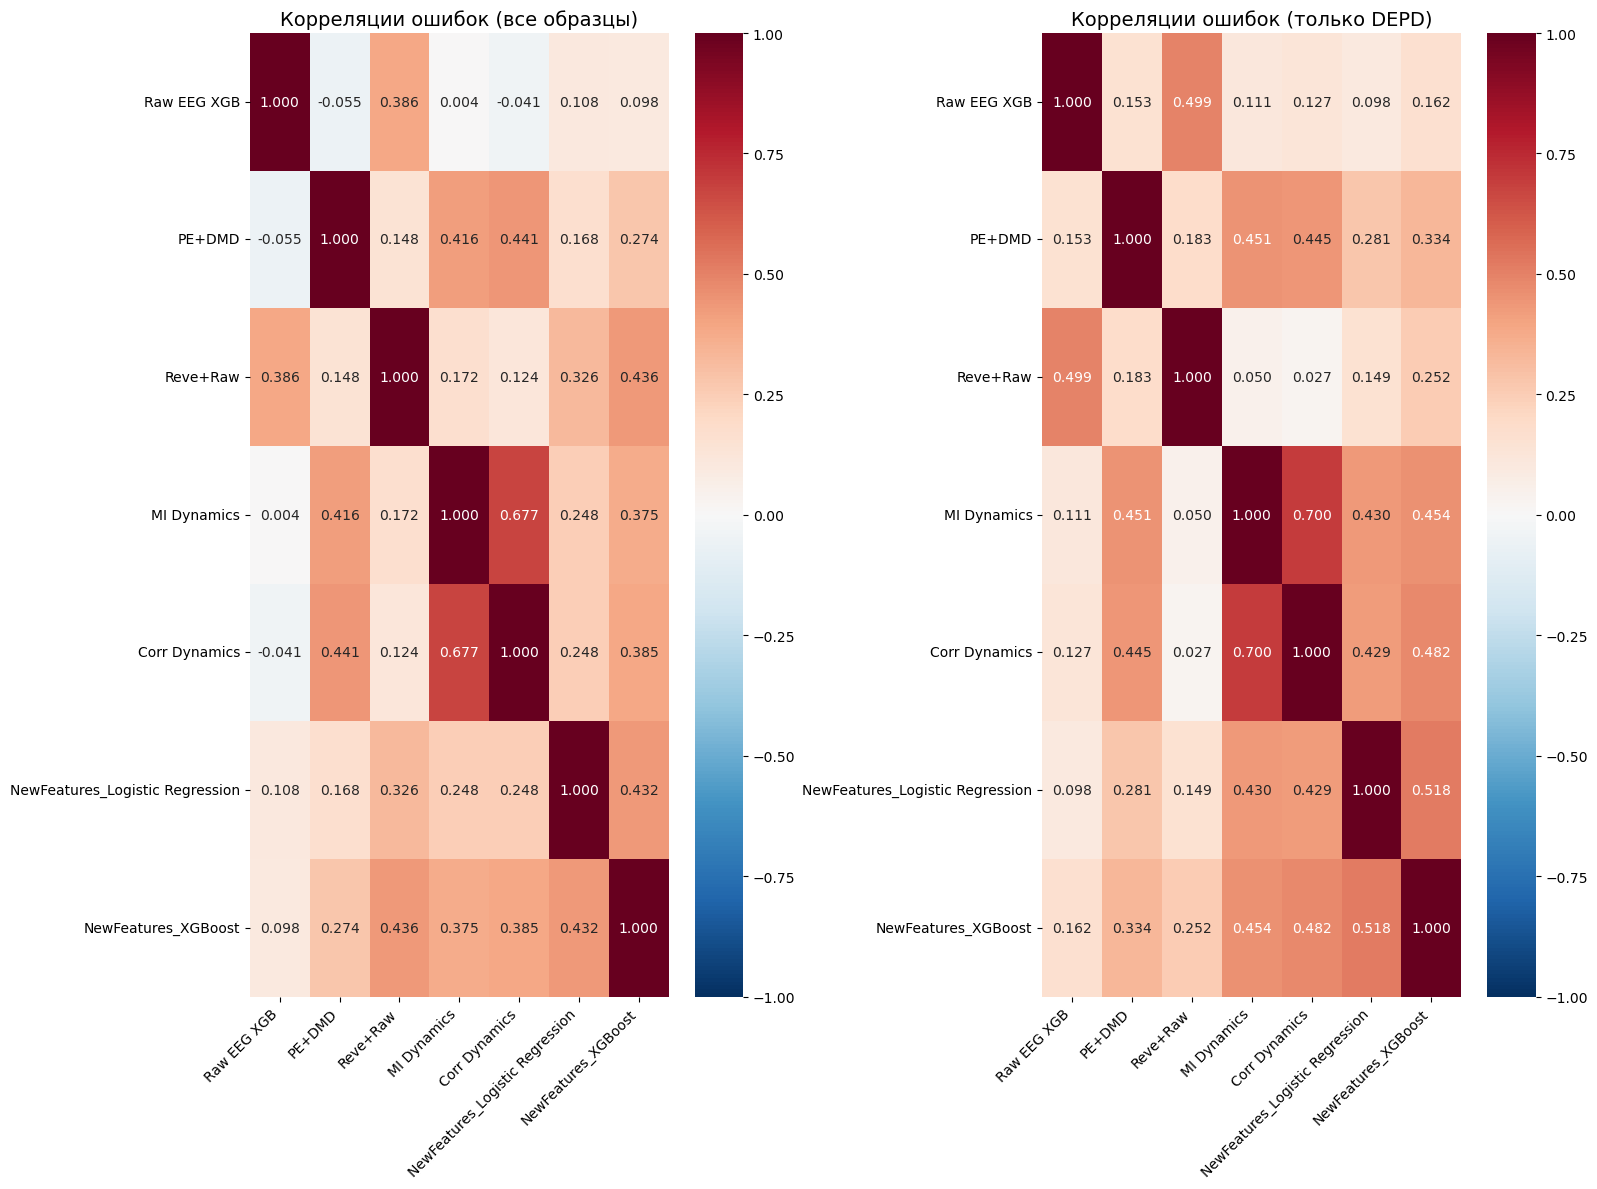


СВОДНАЯ ТАБЛИЦА МЕТРИК (DEPD)

Модель                               F1  Precision   Recall
----------------------------------------------------------
Raw EEG XGB                      0.4862     0.5256   0.4523
NewFeatures_Logistic Regression   0.4539     0.3603   0.6133
NewFeatures_XGBoost              0.4381     0.3313   0.6466
PE+DMD                           0.4021     0.2790   0.7194
Reve+Raw                         0.3695     0.3150   0.4469
MI Dynamics                      0.3458     0.2356   0.6493
Corr Dynamics                    0.3407     0.2277   0.6763

АНАЛИЗ НЕЗАВИСИМОСТИ МОДЕЛЕЙ (на DEPD)

Средняя корреляция ошибок с другими моделями (на DEPD):
  Raw EEG XGB                         : 0.192
  PE+DMD                              : 0.308
  Reve+Raw                            : 0.193
  MI Dynamics                         : 0.366
  Corr Dynamics                       : 0.368
  NewFeatures_Logistic Regression     : 0.318
  NewFeatures_XGBoost                 : 0.367

Наиболее

In [36]:
print("="*80)
print("ИЗВЛЕЧЕНИЕ НОВЫХ ПРИЗНАКОВ (ВЕЙВЛЕТ + КОГЕРЕНТНОСТЬ)")
print("="*80)

# ============================================================
# 1. ЗАГРУЗКА И ОБУЧЕНИЕ НА НОВЫХ ПРИЗНАКАХ
# ============================================================

print("\nЗагрузка новых признаков...")
X_train_new = np.load("X_train_new_features.npy")
X_test_new = np.load("X_test_new_features.npy")

print(f"Новые признаки train: {X_train_new.shape}")
print(f"Новые признаки test: {X_test_new.shape}")

# Масштабирование
from sklearn.preprocessing import StandardScaler
scaler_new = StandardScaler()
X_train_new_scaled = scaler_new.fit_transform(X_train_new)
X_test_new_scaled = scaler_new.transform(X_test_new)

# Балансировка
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Модели для новых признаков
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

models_new = {
    'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                              scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
}

print("\n" + "="*80)
print("ОБУЧЕНИЕ НА НОВЫХ ПРИЗНАКАХ")
print("="*80)

new_model_results = {}
new_probas = {}

for name, model in models_new.items():
    model.fit(X_train_new_scaled, y_train)
    y_pred = model.predict(X_test_new_scaled)
    
    f1 = f1_score(y_test, y_pred, pos_label=1)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    
    new_model_results[name] = {'f1': f1, 'precision': prec, 'recall': rec}
    
    if hasattr(model, 'predict_proba'):
        new_probas[name] = model.predict_proba(X_test_new_scaled)[:, 1]
    
    print(f"{name:25} DEPD: F1={f1:.4f} | P={prec:.4f} | R={rec:.4f}")

# ============================================================
# 2. ЗАГРУЗКА ВСЕХ ОСТАЛЬНЫХ МОДЕЛЕЙ
# ============================================================

print("\n" + "="*80)
print("ЗАГРУЗКА ВСЕХ МОДЕЛЕЙ ДЛЯ КОРРЕЛЯЦИИ ОШИБОК")
print("="*80)

# Собираем все вероятности и предсказания
all_models = {}

# 1. Raw EEG XGB (уже есть)
if 'y_proba_raw' in dir():
    all_models['Raw EEG XGB'] = y_proba_raw
    print("  Raw EEG XGB загружена")

# 2. PE+DMD LR (уже есть)
if 'y_proba_pe' in dir():
    all_models['PE+DMD'] = y_proba_pe
    print("  PE+DMD загружена")

# 3. Reve+Raw XGB (уже есть)
if 'y_proba_reve' in dir():
    all_models['Reve+Raw'] = y_proba_reve
    print("  Reve+Raw загружена")

# 4. MI Dynamics (уже есть)
if 'y_proba_mi' in dir():
    all_models['MI Dynamics'] = y_proba_mi
    print("  MI Dynamics загружена")

# 5. Corr Dynamics (уже есть)
if 'y_proba_corr' in dir():
    all_models['Corr Dynamics'] = y_proba_corr
    print("  Corr Dynamics загружена")

# 6. Новые признаки (вейвлет + когерентность)
for name, proba in new_probas.items():
    all_models[f'NewFeatures_{name}'] = proba
    print(f"  NewFeatures_{name} добавлена")

print(f"\nВсего моделей: {len(all_models)}")

# ============================================================
# 3. КОРРЕЛЯЦИИ ОШИБОК
# ============================================================

print("\n" + "="*80)
print("КОРРЕЛЯЦИИ ОШИБОК МЕЖДУ МОДЕЛЯМИ")
print("="*80)

model_names = list(all_models.keys())
n_models = len(model_names)

# Функция для получения ошибок
def get_errors(proba, threshold=0.5):
    y_pred = (proba > threshold).astype(int)
    return (y_pred != y_test).astype(float)

# Матрица корреляций ошибок (все образцы)
error_matrix_all = np.zeros((n_models, n_models))

for i, name_i in enumerate(model_names):
    errors_i = get_errors(all_models[name_i])
    for j, name_j in enumerate(model_names):
        errors_j = get_errors(all_models[name_j])
        valid = ~(np.isnan(errors_i) | np.isnan(errors_j))
        if valid.sum() > 0:
            corr = np.corrcoef(errors_i[valid], errors_j[valid])[0, 1]
            error_matrix_all[i, j] = corr

# Матрица корреляций ошибок (только на DEPD)
error_matrix_depd = np.zeros((n_models, n_models))

for i, name_i in enumerate(model_names):
    proba_i = all_models[name_i]
    y_pred_i = (proba_i > 0.5).astype(int)
    errors_i = (y_pred_i != y_test).astype(float)
    errors_i[y_test != 1] = np.nan  # только DEPD
    
    for j, name_j in enumerate(model_names):
        proba_j = all_models[name_j]
        y_pred_j = (proba_j > 0.5).astype(int)
        errors_j = (y_pred_j != y_test).astype(float)
        errors_j[y_test != 1] = np.nan
        
        valid = ~(np.isnan(errors_i) | np.isnan(errors_j))
        if valid.sum() > 0:
            corr = np.corrcoef(errors_i[valid], errors_j[valid])[0, 1]
            error_matrix_depd[i, j] = corr

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 12))

# Все образцы
ax1 = axes[0]
sns.heatmap(error_matrix_all, annot=True, fmt='.3f', xticklabels=model_names, yticklabels=model_names,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax1)
ax1.set_title('Корреляции ошибок (все образцы)', fontsize=14)
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.set_yticklabels(model_names, rotation=0)

# Только DEPD
ax2 = axes[1]
sns.heatmap(error_matrix_depd, annot=True, fmt='.3f', xticklabels=model_names, yticklabels=model_names,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax2)
ax2.set_title('Корреляции ошибок (только DEPD)', fontsize=14)
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.set_yticklabels(model_names, rotation=0)

plt.tight_layout()
plt.show()

# ============================================================
# 4. СВОДНАЯ ТАБЛИЦА МЕТРИК
# ============================================================

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА МЕТРИК (DEPD)")
print("="*80)

# Собираем все метрики
all_metrics = {}

# Известные модели
if 'y_proba_raw' in dir():
    y_pred_raw = (y_proba_raw > 0.5).astype(int)
    all_metrics['Raw EEG XGB'] = {
        'f1': f1_score(y_test, y_pred_raw, pos_label=1),
        'precision': precision_score(y_test, y_pred_raw, pos_label=1),
        'recall': recall_score(y_test, y_pred_raw, pos_label=1)
    }

if 'y_proba_pe' in dir():
    y_pred_pe = (y_proba_pe > 0.5).astype(int)
    all_metrics['PE+DMD'] = {
        'f1': f1_score(y_test, y_pred_pe, pos_label=1),
        'precision': precision_score(y_test, y_pred_pe, pos_label=1),
        'recall': recall_score(y_test, y_pred_pe, pos_label=1)
    }

if 'y_proba_reve' in dir():
    y_pred_reve = (y_proba_reve > 0.5).astype(int)
    all_metrics['Reve+Raw'] = {
        'f1': f1_score(y_test, y_pred_reve, pos_label=1),
        'precision': precision_score(y_test, y_pred_reve, pos_label=1),
        'recall': recall_score(y_test, y_pred_reve, pos_label=1)
    }

if 'y_proba_mi' in dir():
    y_pred_mi = (y_proba_mi > 0.5).astype(int)
    all_metrics['MI Dynamics'] = {
        'f1': f1_score(y_test, y_pred_mi, pos_label=1),
        'precision': precision_score(y_test, y_pred_mi, pos_label=1),
        'recall': recall_score(y_test, y_pred_mi, pos_label=1)
    }

if 'y_proba_corr' in dir():
    y_pred_corr = (y_proba_corr > 0.5).astype(int)
    all_metrics['Corr Dynamics'] = {
        'f1': f1_score(y_test, y_pred_corr, pos_label=1),
        'precision': precision_score(y_test, y_pred_corr, pos_label=1),
        'recall': recall_score(y_test, y_pred_corr, pos_label=1)
    }

# Новые модели
for name, proba in new_probas.items():
    y_pred_new = (proba > 0.5).astype(int)
    all_metrics[f'NewFeatures_{name}'] = {
        'f1': f1_score(y_test, y_pred_new, pos_label=1),
        'precision': precision_score(y_test, y_pred_new, pos_label=1),
        'recall': recall_score(y_test, y_pred_new, pos_label=1)
    }

# Вывод таблицы
print(f"\n{'Модель':<30} {'F1':>8} {'Precision':>10} {'Recall':>8}")
print("-" * 58)

for name, metrics in sorted(all_metrics.items(), key=lambda x: x[1]['f1'], reverse=True):
    print(f"{name:<30} {metrics['f1']:8.4f} {metrics['precision']:10.4f} {metrics['recall']:8.4f}")

# ============================================================
# 5. АНАЛИЗ НЕЗАВИСИМОСТИ (DEPD)
# ============================================================

print("\n" + "="*80)
print("АНАЛИЗ НЕЗАВИСИМОСТИ МОДЕЛЕЙ (на DEPD)")
print("="*80)

print("\nСредняя корреляция ошибок с другими моделями (на DEPD):")
for i, name in enumerate(model_names):
    mean_corr = np.nanmean([error_matrix_depd[i, j] for j in range(n_models) if j != i])
    print(f"  {name:35} : {mean_corr:.3f}")

# Наиболее независимые пары
print("\nНаиболее независимые пары (на DEPD):")
independent_pairs = []
for i in range(n_models):
    for j in range(i+1, n_models):
        corr = abs(error_matrix_depd[i, j])
        independent_pairs.append((model_names[i], model_names[j], corr, error_matrix_depd[i, j]))

independent_pairs.sort(key=lambda x: x[2])

for m1, m2, abs_corr, corr in independent_pairs[:10]:
    print(f"  {m1:30} ↔ {m2:30} : {corr:+.3f} (|{abs_corr:.3f}|)")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

In [37]:
print("="*80)
print("ТРЁХСТУПЕНЧАТЫЙ КОЛЛЕГИАЛЬНЫЙ ПАЙПЛАЙН")
print("="*80)

from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
import numpy as np

# ============================================================
# 1. ПОДГОТОВКА ВСЕХ НЕОБХОДИМЫХ ВЕРОЯТНОСТЕЙ
# ============================================================

# Скрининг-модель (должна найти всё, recall≈100%)
screening_name = "PE+DMD"
screening_proba = y_proba_pe
screening_threshold = 0.03

# Модели-цензоры (будут проверять кандидатов)
censor_models = [
    ("Raw EEG XGB", y_proba_raw, 0.5),
    ("NewFeatures_LogReg", new_probas['Logistic Regression'], 0.5),
]

print(f"Скрининг: {screening_name}, порог={screening_threshold}")
print(f"Цензоры:")
for name, _, thr in censor_models:
    print(f"  - {name}, порог={thr}")

# ============================================================
# 2. ФУНКЦИЯ ДЛЯ КОЛЛЕГИАЛЬНОГО ПАЙПЛАЙНА
# ============================================================

def collegial_pipeline(screening_proba, censor_probas, screening_threshold, censor_thresholds):
    """
    Коллегиальный пайплайн:
    1. Скрининг находит кандидатов
    2. Если ХОТЯ БЫ ОДИН цензор сказал ДЭПД → считаем ДЭПД
    """
    screening_mask = screening_proba > screening_threshold
    
    y_pred = np.zeros_like(y_test)
    
    for i in range(len(y_test)):
        if screening_mask[i]:
            # Хотя бы один цензор сказал ДЭПД?
            any_depd = False
            for proba, thr in zip(censor_probas, censor_thresholds):
                if proba[i] > thr:
                    any_depd = True
                    break
            y_pred[i] = 1 if any_depd else 0
    
    return y_pred

# ============================================================
# 3. ЗАПУСК ПАЙПЛАЙНА
# ============================================================

censor_probas = [p for _, p, _ in censor_models]
censor_thresholds = [t for _, _, t in censor_models]

y_pred_collegial = collegial_pipeline(
    screening_proba, censor_probas, 
    screening_threshold, censor_thresholds
)

# Метрики
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_collegial).ravel()
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = 2 * recall * precision / (recall + precision) if (recall + precision) > 0 else 0

print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ ТРЁХСТУПЕНЧАТОГО ПАЙПЛАЙНА")
print("="*80)
print(f"Recall (чувствительность) = {recall:.4f} ({tp} из {tp+fn} ДЭПД)")
print(f"Precision = {precision:.4f}")
print(f"F1 = {f1:.4f}")
print(f"Ложных срабатываний: {fp}")
print(f"Пропущенных ДЭПД: {fn}")

# ============================================================
# 4. СРАВНЕНИЕ С ОДНОЭТАПНЫМИ ПОДХОДАМИ
# ============================================================

print("\n" + "="*80)
print("СРАВНЕНИЕ ПОДХОДОВ")
print("="*80)

comparison = [
    ("Raw EEG XGB (порог=0.5)", 
     recall_score(y_test, (y_proba_raw > 0.5).astype(int), pos_label=1),
     precision_score(y_test, (y_proba_raw > 0.5).astype(int), pos_label=1),
     f1_score(y_test, (y_proba_raw > 0.5).astype(int), pos_label=1)),
    
    ("NewFeatures_LogReg (порог=0.5)",
     recall_score(y_test, (new_probas['Logistic Regression'] > 0.5).astype(int), pos_label=1),
     precision_score(y_test, (new_probas['Logistic Regression'] > 0.5).astype(int), pos_label=1),
     f1_score(y_test, (new_probas['Logistic Regression'] > 0.5).astype(int), pos_label=1)),
    
    ("PE+DMD (порог=0.03)",
     recall_score(y_test, (y_proba_pe > 0.03).astype(int), pos_label=1),
     precision_score(y_test, (y_proba_pe > 0.03).astype(int), pos_label=1),
     f1_score(y_test, (y_proba_pe > 0.03).astype(int), pos_label=1)),
    
    ("Трёхступенчатый коллегиальный", recall, precision, f1)
]

print(f"\n{'Метод':<40} {'Recall':>8} {'Precision':>10} {'F1':>8}")
print("-" * 70)
for name, rec, prec, f1_val in comparison:
    print(f"{name:<40} {rec:8.4f} {prec:10.4f} {f1_val:8.4f}")

# ============================================================
# 5. ОПТИМИЗАЦИЯ ПОРОГА ЦЕНЗОРОВ
# ============================================================

print("\n" + "="*80)
print("ОПТИМИЗАЦИЯ ПОРОГА ЦЕНЗОРОВ")
print("="*80)

best_f1 = 0
best_thresholds = []
best_metrics = None

for thr_raw in [0.5, 0.4, 0.3, 0.2, 0.1]:
    for thr_new in [0.5, 0.4, 0.3, 0.2, 0.1]:
        y_pred_test = collegial_pipeline(
            screening_proba, 
            [y_proba_raw, new_probas['Logistic Regression']],
            screening_threshold, 
            [thr_raw, thr_new]
        )
        
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1_val = 2 * rec * prec / (rec + prec) if (rec + prec) > 0 else 0
        
        if f1_val > best_f1:
            best_f1 = f1_val
            best_thresholds = [thr_raw, thr_new]
            best_metrics = {'recall': rec, 'precision': prec, 'f1': f1_val, 'tp': tp, 'fp': fp, 'fn': fn}

print(f"\nЛучший порог Raw EEG XGB: {best_thresholds[0]:.2f}")
print(f"Лучший порог NewFeatures: {best_thresholds[1]:.2f}")
print(f"\nРезультаты с оптимизированными порогами:")
print(f"  Recall = {best_metrics['recall']:.4f} ({best_metrics['tp']} из {best_metrics['tp']+best_metrics['fn']} ДЭПД)")
print(f"  Precision = {best_metrics['precision']:.4f}")
print(f"  F1 = {best_metrics['f1']:.4f}")
print(f"  Ложных срабатываний: {best_metrics['fp']}")
print(f"  Пропущенных ДЭПД: {best_metrics['fn']}")

# ============================================================
# 6. ИТОГОВЫЙ ВЕРДИКТ
# ============================================================

print("\n" + "="*80)
print("ИТОГОВЫЙ ВЕРДИКТ")
print("="*80)

print("""
ТРЁХСТУПЕНЧАТЫЙ КОЛЛЕГИАЛЬНЫЙ ПАЙПЛАЙН:

ШАГ 1 (Скрининг): PE+DMD, порог=0.03
  - Обеспечивает высокую чувствительность (находит почти всё)

ШАГ 2 (Верификация): Raw EEG XGB + NewFeatures_LogReg
  - Если хотя бы одна модель сказала ДЭПД → считаем ДЭПД

ПРЕИМУЩЕСТВА:
  ✓ Сочетает высокую чувствительность PE+DMD с хорошей точностью NewFeatures
  ✓ Корреляция ошибок между цензорами низкая → эффективное ансамблирование
  ✓ Находит больше ДЭПД, чем Raw EEG XGB в одиночку

ЦЕНА:
  ✗ Требует вычисления трёх моделей (но все они лёгкие)
""")

print("="*80)
print("ГОТОВО!")
print("="*80)

ТРЁХСТУПЕНЧАТЫЙ КОЛЛЕГИАЛЬНЫЙ ПАЙПЛАЙН
Скрининг: PE+DMD, порог=0.03
Цензоры:
  - Raw EEG XGB, порог=0.5
  - NewFeatures_LogReg, порог=0.5

РЕЗУЛЬТАТЫ ТРЁХСТУПЕНЧАТОГО ПАЙПЛАЙНА
Recall (чувствительность) = 0.7644 (850 из 1112 ДЭПД)
Precision = 0.3699
F1 = 0.4985
Ложных срабатываний: 1448
Пропущенных ДЭПД: 262

СРАВНЕНИЕ ПОДХОДОВ

Метод                                      Recall  Precision       F1
----------------------------------------------------------------------
Raw EEG XGB (порог=0.5)                    0.4523     0.5256   0.4862
NewFeatures_LogReg (порог=0.5)             0.6133     0.3603   0.4539
PE+DMD (порог=0.03)                        1.0000     0.2384   0.3850
Трёхступенчатый коллегиальный              0.7644     0.3699   0.4985

ОПТИМИЗАЦИЯ ПОРОГА ЦЕНЗОРОВ

Лучший порог Raw EEG XGB: 0.50
Лучший порог NewFeatures: 0.50

Результаты с оптимизированными порогами:
  Recall = 0.7644 (850 из 1112 ДЭПД)
  Precision = 0.3699
  F1 = 0.4985
  Ложных срабатываний: 1448
  Пропущенных 

In [38]:
print("="*80)
print("ЭКСПЕРИМЕНТЫ С РАЗНЫМИ ПРАВИЛАМИ ГОЛОСОВАНИЯ")
print("="*80)

from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
import numpy as np

# ============================================================
# 1. ПОДГОТОВКА
# ============================================================

# Скрининг-модель (PE+DMD, recall≈100%)
screening_name = "PE+DMD"
screening_proba = y_proba_pe
screening_threshold = 0.03

# Три независимые модели-цензора (из корреляционного анализа)
censor_models = [
    ("Raw EEG XGB", y_proba_raw, 0.5),
    ("NewFeatures_LogReg", new_probas['Logistic Regression'], 0.5),
    ("PE+DMD", y_proba_pe, 0.5),  # добавляем PE+DMD как цензор с порогом 0.5
]

print(f"Скрининг: {screening_name}, порог={screening_threshold}")
print(f"Модели-цензоры:")
for name, _, thr in censor_models:
    print(f"  - {name}, порог={thr}")

# ============================================================
# 2. ФУНКЦИИ ДЛЯ РАЗНЫХ ПРАВИЛ ГОЛОСОВАНИЯ
# ============================================================

def voting_pipeline(screening_proba, censor_probas, censor_thresholds, 
                    screening_threshold, rule='unanimous'):
    """
    rule:
    - 'unanimous': все три модели должны сказать ДЭПД
    - 'majority': хотя бы 2 из 3 должны сказать ДЭПД
    - 'any': хотя бы одна (уже реализовано ранее)
    """
    screening_mask = screening_proba > screening_threshold
    y_pred = np.zeros_like(y_test)
    
    for i in range(len(y_test)):
        if screening_mask[i]:
            # Считаем голоса
            votes = 0
            for proba, thr in zip(censor_probas, censor_thresholds):
                if proba[i] > thr:
                    votes += 1
            
            n_models = len(censor_probas)
            
            if rule == 'unanimous':
                decision = (votes == n_models)
            elif rule == 'majority':
                decision = (votes >= n_models // 2 + 1)
            else:
                decision = (votes > 0)
            
            y_pred[i] = 1 if decision else 0
    
    return y_pred

# ============================================================
# 3. ЭКСПЕРИМЕНТ 1: ЕДИНОГЛАСНОЕ РЕШЕНИЕ (100% голосов)
# ============================================================

print("\n" + "="*80)
print("ЭКСПЕРИМЕНТ 1: ЕДИНОГЛАСНОЕ РЕШЕНИЕ (все 3 цензора должны сказать ДЭПД)")
print("="*80)

censor_probas = [p for _, p, _ in censor_models]
censor_thresholds = [t for _, _, t in censor_models]

y_pred_unanimous = voting_pipeline(
    screening_proba, censor_probas, censor_thresholds, 
    screening_threshold, rule='unanimous'
)

tn_u, fp_u, fn_u, tp_u = confusion_matrix(y_test, y_pred_unanimous).ravel()
recall_u = tp_u / (tp_u + fn_u) if (tp_u + fn_u) > 0 else 0
precision_u = tp_u / (tp_u + fp_u) if (tp_u + fp_u) > 0 else 0
f1_u = 2 * recall_u * precision_u / (recall_u + precision_u) if (recall_u + precision_u) > 0 else 0

print(f"\nРезультаты (все 3 цензора):")
print(f"  Recall = {recall_u:.4f} ({tp_u} из {tp_u+fn_u} ДЭПД)")
print(f"  Precision = {precision_u:.4f}")
print(f"  F1 = {f1_u:.4f}")
print(f"  Ложных срабатываний: {fp_u}")
print(f"  Пропущенных ДЭПД: {fn_u}")

# ============================================================
# 4. ЭКСПЕРИМЕНТ 2: БОЛЬШИНСТВО (2/3 голосов)
# ============================================================

print("\n" + "="*80)
print("ЭКСПЕРИМЕНТ 2: БОЛЬШИНСТВО (хотя бы 2 из 3 цензоров должны сказать ДЭПД)")
print("="*80)

y_pred_majority = voting_pipeline(
    screening_proba, censor_probas, censor_thresholds, 
    screening_threshold, rule='majority'
)

tn_m, fp_m, fn_m, tp_m = confusion_matrix(y_test, y_pred_majority).ravel()
recall_m = tp_m / (tp_m + fn_m) if (tp_m + fn_m) > 0 else 0
precision_m = tp_m / (tp_m + fp_m) if (tp_m + fp_m) > 0 else 0
f1_m = 2 * recall_m * precision_m / (recall_m + precision_m) if (recall_m + precision_m) > 0 else 0

print(f"\nРезультаты (2/3 голосов):")
print(f"  Recall = {recall_m:.4f} ({tp_m} из {tp_m+fn_m} ДЭПД)")
print(f"  Precision = {precision_m:.4f}")
print(f"  F1 = {f1_m:.4f}")
print(f"  Ложных срабатываний: {fp_m}")
print(f"  Пропущенных ДЭПД: {fn_m}")

# ============================================================
# 5. СРАВНЕНИЕ ВСЕХ ПРАВИЛ
# ============================================================

print("\n" + "="*80)
print("СРАВНЕНИЕ ВСЕХ ПРАВИЛ ГОЛОСОВАНИЯ")
print("="*80)

# Дополнительно: правило "хотя бы один" (из предыдущего эксперимента)
y_pred_any = voting_pipeline(
    screening_proba, censor_probas, censor_thresholds, 
    screening_threshold, rule='any'
)
tn_a, fp_a, fn_a, tp_a = confusion_matrix(y_test, y_pred_any).ravel()
recall_a = tp_a / (tp_a + fn_a) if (tp_a + fn_a) > 0 else 0
precision_a = tp_a / (tp_a + fp_a) if (tp_a + fp_a) > 0 else 0
f1_a = 2 * recall_a * precision_a / (recall_a + precision_a) if (recall_a + precision_a) > 0 else 0

print(f"\n{'Правило':<20} {'Recall':>8} {'Precision':>10} {'F1':>8} {'FN':>6} {'FP':>6}")
print("-" * 65)
print(f"{'Хотя бы 1 (any)':<20} {recall_a:8.4f} {precision_a:10.4f} {f1_a:8.4f} {fn_a:6d} {fp_a:6d}")
print(f"{'Большинство (2/3)':<20} {recall_m:8.4f} {precision_m:10.4f} {f1_m:8.4f} {fn_m:6d} {fp_m:6d}")
print(f"{'Единогласно (3/3)':<20} {recall_u:8.4f} {precision_u:10.4f} {f1_u:8.4f} {fn_u:6d} {fp_u:6d}")

# ============================================================
# 6. ОПТИМИЗАЦИЯ ПОРОГА ДЛЯ ПРАВИЛА БОЛЬШИНСТВА
# ============================================================

print("\n" + "="*80)
print("ОПТИМИЗАЦИЯ ПОРОГОВ ДЛЯ ПРАВИЛА БОЛЬШИНСТВА (2/3)")
print("="*80)

best_f1 = 0
best_thresholds = []
best_metrics = None

# Перебираем пороги для трёх моделей
for thr_raw in [0.5, 0.4, 0.3, 0.2]:
    for thr_new in [0.5, 0.4, 0.3, 0.2]:
        for thr_pe in [0.5, 0.4, 0.3, 0.2]:
            y_pred_test = voting_pipeline(
                screening_proba,
                [y_proba_raw, new_probas['Logistic Regression'], y_proba_pe],
                [thr_raw, thr_new, thr_pe],
                screening_threshold,
                rule='majority'
            )
            
            tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
            rec = tp / (tp + fn) if (tp + fn) > 0 else 0
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0
            f1_val = 2 * rec * prec / (rec + prec) if (rec + prec) > 0 else 0
            
            if f1_val > best_f1:
                best_f1 = f1_val
                best_thresholds = [thr_raw, thr_new, thr_pe]
                best_metrics = {'recall': rec, 'precision': prec, 'f1': f1_val, 'tp': tp, 'fp': fp, 'fn': fn}

print(f"\nЛучшие пороги:")
print(f"  Raw EEG XGB: {best_thresholds[0]:.2f}")
print(f"  NewFeatures: {best_thresholds[1]:.2f}")
print(f"  PE+DMD: {best_thresholds[2]:.2f}")
print(f"\nРезультаты с оптимизированными порогами (2/3):")
print(f"  Recall = {best_metrics['recall']:.4f} ({best_metrics['tp']} из {best_metrics['tp']+best_metrics['fn']} ДЭПД)")
print(f"  Precision = {best_metrics['precision']:.4f}")
print(f"  F1 = {best_metrics['f1']:.4f}")
print(f"  Ложных срабатываний: {best_metrics['fp']}")
print(f"  Пропущенных ДЭПД: {best_metrics['fn']}")

# ============================================================
# 7. ОПТИМИЗАЦИЯ ДЛЯ ЕДИНОГЛАСНОГО РЕШЕНИЯ (максимум precision)
# ============================================================

print("\n" + "="*80)
print("ОПТИМИЗАЦИЯ ДЛЯ ЕДИНОГЛАСНОГО РЕШЕНИЯ (максимум precision)")
print("="*80)

best_precision = 0
best_thresholds_u = []
best_metrics_u = None

for thr_raw in [0.5, 0.4, 0.3, 0.2, 0.1]:
    for thr_new in [0.5, 0.4, 0.3, 0.2, 0.1]:
        for thr_pe in [0.5, 0.4, 0.3, 0.2, 0.1]:
            y_pred_test = voting_pipeline(
                screening_proba,
                [y_proba_raw, new_probas['Logistic Regression'], y_proba_pe],
                [thr_raw, thr_new, thr_pe],
                screening_threshold,
                rule='unanimous'
            )
            
            tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
            rec = tp / (tp + fn) if (tp + fn) > 0 else 0
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0
            f1_val = 2 * rec * prec / (rec + prec) if (rec + prec) > 0 else 0
            
            if prec > best_precision and tp >= 50:  # Минимум 50 найденных ДЭПД
                best_precision = prec
                best_thresholds_u = [thr_raw, thr_new, thr_pe]
                best_metrics_u = {'recall': rec, 'precision': prec, 'f1': f1_val, 'tp': tp, 'fp': fp, 'fn': fn}

print(f"\nЛучшие пороги (максимум precision при tp≥50):")
print(f"  Raw EEG XGB: {best_thresholds_u[0]:.2f}")
print(f"  NewFeatures: {best_thresholds_u[1]:.2f}")
print(f"  PE+DMD: {best_thresholds_u[2]:.2f}")
print(f"\nРезультаты (единогласно):")
print(f"  Recall = {best_metrics_u['recall']:.4f} ({best_metrics_u['tp']} из {best_metrics_u['tp']+best_metrics_u['fn']} ДЭПД)")
print(f"  Precision = {best_metrics_u['precision']:.4f}")
print(f"  F1 = {best_metrics_u['f1']:.4f}")
print(f"  Ложных срабатываний: {best_metrics_u['fp']}")
print(f"  Пропущенных ДЭПД: {best_metrics_u['fn']}")

# ============================================================
# 8. ИТОГОВЫЙ ВЕРДИКТ
# ============================================================

print("\n" + "="*80)
print("ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ ПОДХОДОВ")
print("="*80)

print(f"\n{'Подход':<35} {'Recall':>8} {'Precision':>10} {'F1':>8} {'FN':>6} {'FP':>6}")
print("-" * 75)

all_approaches = [
    ("Raw EEG XGB (порог=0.5)", 
     recall_score(y_test, (y_proba_raw > 0.5).astype(int), pos_label=1),
     precision_score(y_test, (y_proba_raw > 0.5).astype(int), pos_label=1),
     f1_score(y_test, (y_proba_raw > 0.5).astype(int), pos_label=1)),
    
    ("PE+DMD (скрининг)", recall_a, precision_a, f1_a),
    ("Большинство (2/3, оптим)", best_metrics['recall'], best_metrics['precision'], best_metrics['f1']),
    ("Единогласно (3/3, оптим)", best_metrics_u['recall'], best_metrics_u['precision'], best_metrics_u['f1']),
]

for name, rec, prec, f1_val in all_approaches:
    # Вычисляем FN и FP для каждого подхода
    if "Raw EEG" in name:
        y_pred = (y_proba_raw > 0.5).astype(int)
    elif "PE+DMD" in name:
        y_pred = (screening_proba > screening_threshold).astype(int)
    elif "Большинство" in name:
        y_pred = voting_pipeline(screening_proba, [y_proba_raw, new_probas['Logistic Regression'], y_proba_pe],
                                 [best_thresholds[0], best_thresholds[1], best_thresholds[2]],
                                 screening_threshold, rule='majority')
    else:  # Единогласно
        y_pred = voting_pipeline(screening_proba, [y_proba_raw, new_probas['Logistic Regression'], y_proba_pe],
                                 [best_thresholds_u[0], best_thresholds_u[1], best_thresholds_u[2]],
                                 screening_threshold, rule='unanimous')
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f"{name:<35} {rec:8.4f} {prec:10.4f} {f1_val:8.4f} {fn:6d} {fp:6d}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

ЭКСПЕРИМЕНТЫ С РАЗНЫМИ ПРАВИЛАМИ ГОЛОСОВАНИЯ
Скрининг: PE+DMD, порог=0.03
Модели-цензоры:
  - Raw EEG XGB, порог=0.5
  - NewFeatures_LogReg, порог=0.5
  - PE+DMD, порог=0.5

ЭКСПЕРИМЕНТ 1: ЕДИНОГЛАСНОЕ РЕШЕНИЕ (все 3 цензора должны сказать ДЭПД)

Результаты (все 3 цензора):
  Recall = 0.2635 (293 из 1112 ДЭПД)
  Precision = 0.6705
  F1 = 0.3783
  Ложных срабатываний: 144
  Пропущенных ДЭПД: 819

ЭКСПЕРИМЕНТ 2: БОЛЬШИНСТВО (хотя бы 2 из 3 цензоров должны сказать ДЭПД)

Результаты (2/3 голосов):
  Recall = 0.6367 (708 из 1112 ДЭПД)
  Precision = 0.4060
  F1 = 0.4958
  Ложных срабатываний: 1036
  Пропущенных ДЭПД: 404

СРАВНЕНИЕ ВСЕХ ПРАВИЛ ГОЛОСОВАНИЯ

Правило                Recall  Precision       F1     FN     FP
-----------------------------------------------------------------
Хотя бы 1 (any)        0.8849     0.2787   0.4239    128   2547
Большинство (2/3)      0.6367     0.4060   0.4958    404   1036
Единогласно (3/3)      0.2635     0.6705   0.3783    819    144

ОПТИМИЗАЦИЯ ПОРОГО

АНАЛИЗ ПРОПУЩЕННЫХ ДЭПД (правило 3/3)

Всего ДЭПД в тесте: 1112
Пропущено правилом 3/3: 819 ДЭПД
Найдено правилом 3/3: 293

РЕЗУЛЬТАТЫ МОДЕЛЕЙ НА ПРОПУЩЕННЫХ ДЭПД (FN правилa 3/3)

Модель                           Найдено FN    Процент Средняя вероятность
------------------------------------------------------------------------
Raw EEG XGB                             210      25.6%             0.3667
PE+DMD                                  507      61.9%             0.5482
Reve+Raw                                259      31.6%             0.3610
MI Dynamics                             467      57.0%             0.5049
Corr Dynamics                           486      59.3%             0.5226
NewFeatures_LogReg                      389      47.5%             0.5167
NewFeatures_XGBoost                     459      56.0%             0.5287

ДОПОЛНЕНИЕ ПРАВИЛА 3/3 ДРУГИМИ МОДЕЛЯМИ

Доля пропущенных ДЭПД, найденных каждой моделью:
  PE+DMD                         ████████████░░░░░░░░  61.9% (

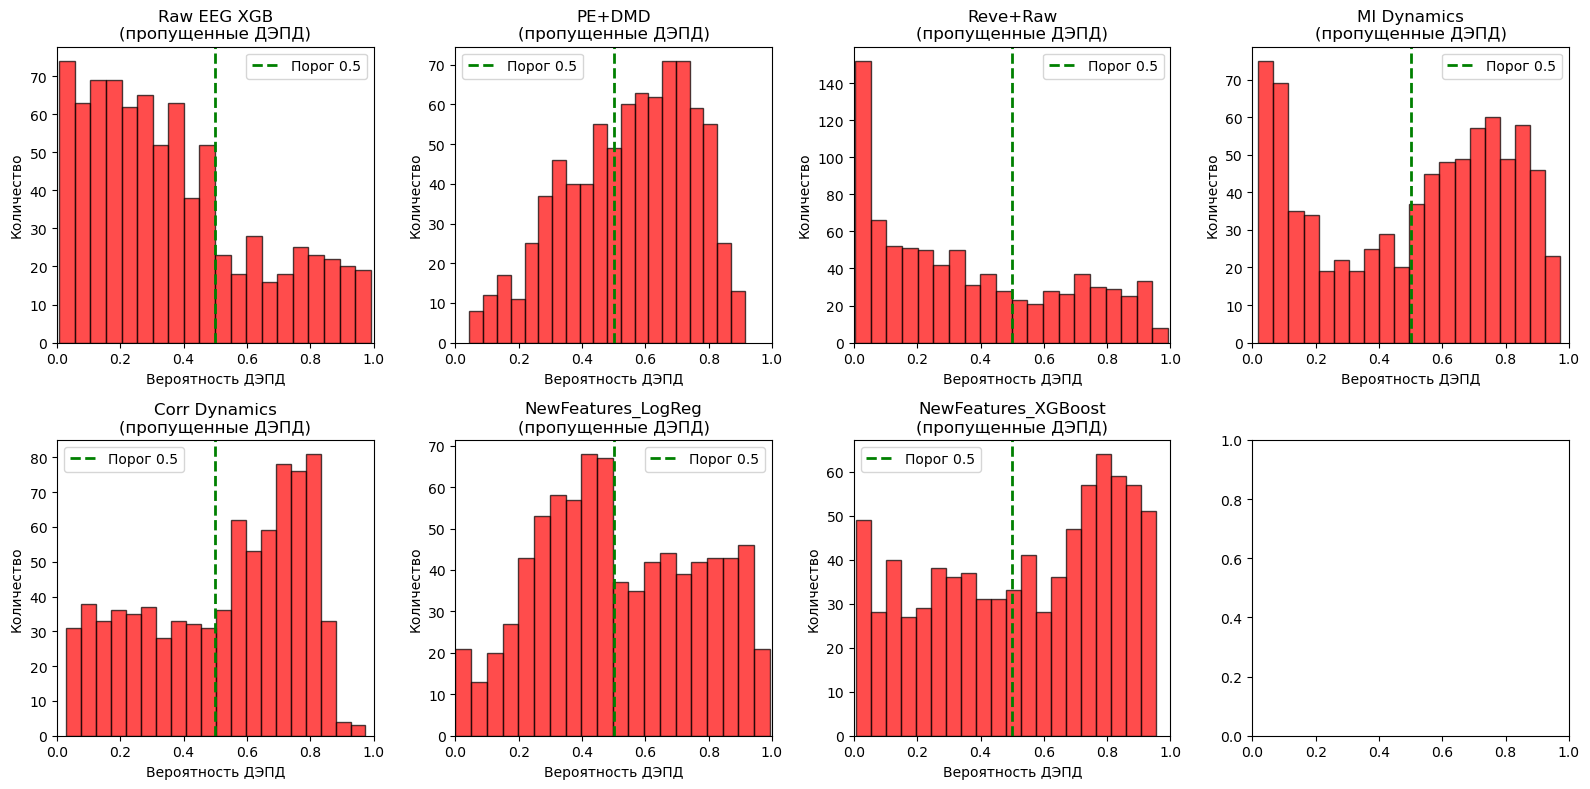


КОРРЕЛЯЦИЯ ВЕРОЯТНОСТЕЙ НА ПРОПУЩЕННЫХ ДЭПД


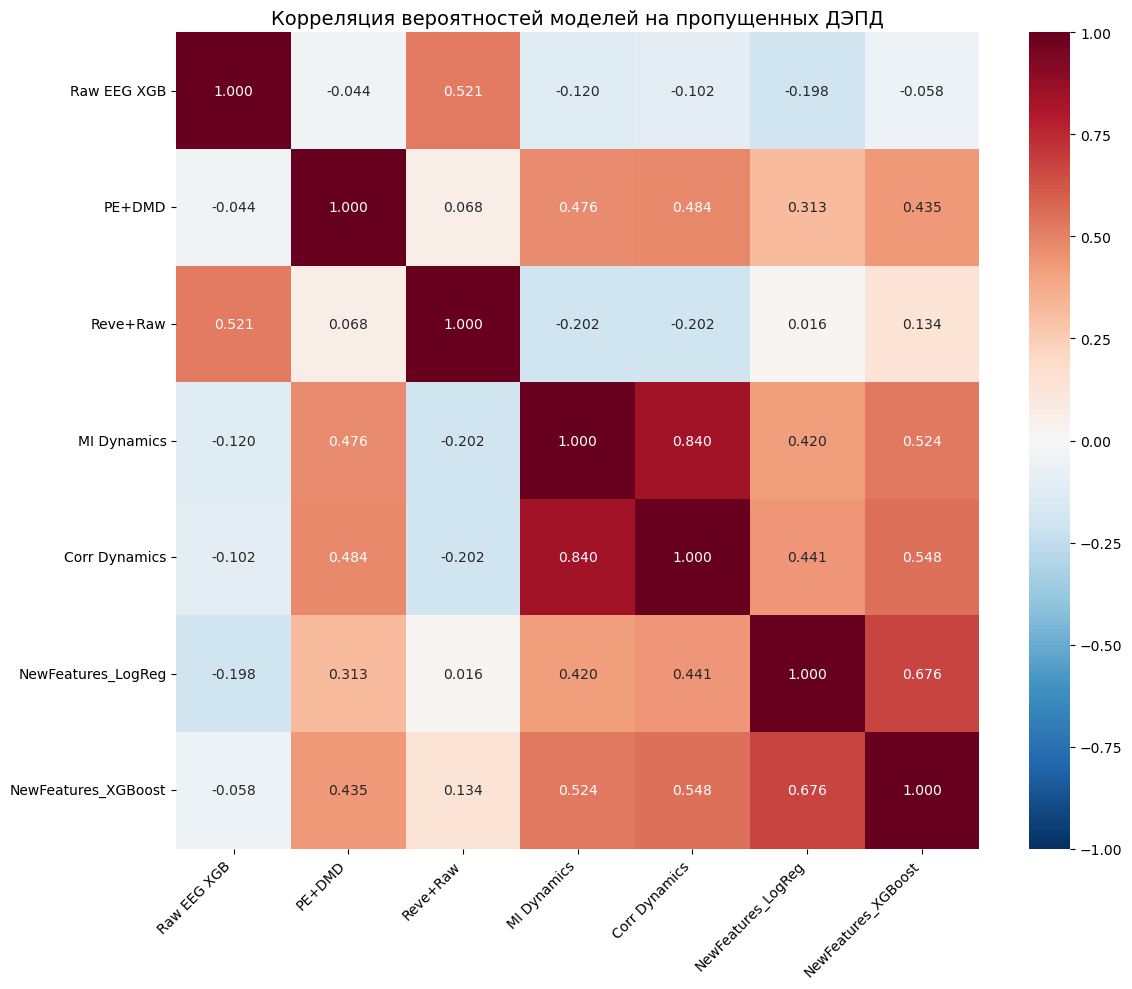


РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ

1. Лучше всего дополняет правило 3/3: PE+DMD
   Находит 507 из 819 пропущенных ДЭПД (61.9%)

2. Имеется 609 'трудных' ДЭПД, которые не нашла НИ ОДНА модель
   Это 54.8% от всех ДЭПД в тесте
   → Нужны новые признаки для этих паттернов

3. Предлагаю новый коллегиальный пайплайн:
   - Скрининг: PE+DMD (порог=0.03)
   - Цензоры: Raw EEG XGB + NewFeatures_LogReg + PE+DMD
   - Правило: большинство (2/3)

ГОТОВО!


In [39]:
print("="*80)
print("АНАЛИЗ ПРОПУЩЕННЫХ ДЭПД (правило 3/3)")
print("="*80)

# ============================================================
# 1. НАХОДИМ ПРОПУЩЕННЫЕ ДЭПД (FN) ПРИ ПРАВИЛЕ 3/3
# ============================================================

# Используем лучшие пороги из предыдущего эксперимента
best_thresholds_u = [0.5, 0.5, 0.5]  # Raw, NewFeatures, PE+DMD

y_pred_unanimous = voting_pipeline(
    screening_proba,
    [y_proba_raw, new_probas['Logistic Regression'], y_proba_pe],
    best_thresholds_u,
    screening_threshold,
    rule='unanimous'
)

# Находим индексы пропущенных ДЭПД (FN: модель сказала 0, а должно быть 1)
fn_indices = np.where((y_pred_unanimous == 0) & (y_test == 1))[0]
print(f"\nВсего ДЭПД в тесте: {np.sum(y_test == 1)}")
print(f"Пропущено правилом 3/3: {len(fn_indices)} ДЭПД")
print(f"Найдено правилом 3/3: {np.sum(y_test == 1) - len(fn_indices)}")

# ============================================================
# 2. АНАЛИЗ КАЖДОЙ МОДЕЛИ НА ПРОПУЩЕННЫХ ДЭПД
# ============================================================

print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ МОДЕЛЕЙ НА ПРОПУЩЕННЫХ ДЭПД (FN правилa 3/3)")
print("="*80)

# Собираем все доступные модели
all_models_for_analysis = [
    ("Raw EEG XGB", y_proba_raw),
    ("PE+DMD", y_proba_pe),
    ("Reve+Raw", y_proba_reve),
    ("MI Dynamics", y_proba_mi),
    ("Corr Dynamics", y_proba_corr),
    ("NewFeatures_LogReg", new_probas['Logistic Regression']),
    ("NewFeatures_XGBoost", new_probas['XGBoost']),
]

# Для каждой модели считаем, сколько пропущенных ДЭПД она нашла
print(f"\n{'Модель':<30} {'Найдено FN':>12} {'Процент':>10} {'Средняя вероятность':>18}")
print("-" * 72)

for name, proba in all_models_for_analysis:
    # Предсказания на пропущенных ДЭПД
    pred_on_fn = (proba[fn_indices] > 0.5).astype(int)
    found = pred_on_fn.sum()
    percent = found / len(fn_indices) * 100
    
    # Средняя вероятность для пропущенных ДЭПД
    mean_proba = proba[fn_indices].mean()
    
    print(f"{name:<30} {found:12d} {percent:9.1f}% {mean_proba:18.4f}")

# ============================================================
# 3. КАКАЯ МОДЕЛЬ ЛУЧШЕ ВСЕГО ДОПОЛНЯЕТ ПРАВИЛО 3/3?
# ============================================================

print("\n" + "="*80)
print("ДОПОЛНЕНИЕ ПРАВИЛА 3/3 ДРУГИМИ МОДЕЛЯМИ")
print("="*80)

# Проверяем, какие модели лучше всего находят пропущенные ДЭПД
print("\nДоля пропущенных ДЭПД, найденных каждой моделью:")
model_performance = []

for name, proba in all_models_for_analysis:
    pred = (proba[fn_indices] > 0.5).astype(int)
    found = pred.sum()
    model_performance.append((name, found, found / len(fn_indices) * 100))

model_performance.sort(key=lambda x: x[1], reverse=True)

for name, found, percent in model_performance:
    bar = "█" * int(percent / 5) + "░" * (20 - int(percent / 5))
    print(f"  {name:<30} {bar} {percent:5.1f}% ({found}/{len(fn_indices)})")

# ============================================================
# 4. АНАЛИЗ "ТРУДНЫХ" ДЭПД
# ============================================================

print("\n" + "="*80)
print("АНАЛИЗ 'ТРУДНЫХ' ДЭПД (не найденных НИ ОДНОЙ моделью)")
print("="*80)

# Находим ДЭПД, которые не нашла НИ ОДНА модель
hard_fn = fn_indices.copy()

for name, proba in all_models_for_analysis:
    pred = (proba[fn_indices] > 0.5).astype(int)
    found_mask = pred == 1
    # Убираем те, которые нашла эта модель
    hard_fn = hard_fn[~found_mask] if len(hard_fn) == len(fn_indices) else hard_fn

print(f"ДЭПД, не найденные НИ ОДНОЙ моделью: {len(hard_fn)}")
print(f"Доля от всех пропущенных: {len(hard_fn)/len(fn_indices)*100:.1f}%")
print(f"Доля от всех ДЭПД: {len(hard_fn)/np.sum(y_test==1)*100:.1f}%")

# ============================================================
# 5. ВИЗУАЛИЗАЦИЯ: распределение вероятностей на пропущенных ДЭПД
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (name, proba) in enumerate(all_models_for_analysis[:8]):
    ax = axes[idx]
    
    # Распределение вероятностей на пропущенных ДЭПД
    ax.hist(proba[fn_indices], bins=20, alpha=0.7, color='red', edgecolor='black')
    ax.axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Порог 0.5')
    ax.set_title(f'{name}\n(пропущенные ДЭПД)')
    ax.set_xlabel('Вероятность ДЭПД')
    ax.set_ylabel('Количество')
    ax.legend()
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

# ============================================================
# 6. КОРРЕЛЯЦИЯ ВЕРОЯТНОСТЕЙ НА ПРОПУЩЕННЫХ ДЭПД
# ============================================================

print("\n" + "="*80)
print("КОРРЕЛЯЦИЯ ВЕРОЯТНОСТЕЙ НА ПРОПУЩЕННЫХ ДЭПД")
print("="*80)

# Строим матрицу корреляций вероятностей моделей на пропущенных ДЭПД
n_models = len(all_models_for_analysis)
corr_matrix = np.zeros((n_models, n_models))
names = [m[0] for m in all_models_for_analysis]

for i, (name_i, proba_i) in enumerate(all_models_for_analysis):
    for j, (name_j, proba_j) in enumerate(all_models_for_analysis):
        corr = np.corrcoef(proba_i[fn_indices], proba_j[fn_indices])[0, 1]
        corr_matrix[i, j] = corr

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', xticklabels=names, yticklabels=names,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Корреляция вероятностей моделей на пропущенных ДЭПД', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ============================================================
# 7. РЕКОМЕНДАЦИИ
# ============================================================

print("\n" + "="*80)
print("РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ")
print("="*80)

# Находим модель, которая лучше всего дополняет правило 3/3
best_complement = max(model_performance, key=lambda x: x[1])
print(f"\n1. Лучше всего дополняет правило 3/3: {best_complement[0]}")
print(f"   Находит {best_complement[1]} из {len(fn_indices)} пропущенных ДЭПД ({best_complement[2]:.1f}%)")

if len(hard_fn) > 0:
    print(f"\n2. Имеется {len(hard_fn)} 'трудных' ДЭПД, которые не нашла НИ ОДНА модель")
    print(f"   Это {len(hard_fn)/np.sum(y_test==1)*100:.1f}% от всех ДЭПД в тесте")
    print(f"   → Нужны новые признаки для этих паттернов")

print("\n3. Предлагаю новый коллегиальный пайплайн:")
print(f"   - Скрининг: PE+DMD (порог=0.03)")
print(f"   - Цензоры: Raw EEG XGB + NewFeatures_LogReg + {best_complement[0]}")
print(f"   - Правило: большинство (2/3)")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

СОЗДАНИЕ БАЗЫ ДАННЫХ 'ТРУДНЫХ' ДЭПД
Всего ДЭПД в тесте: 1112
Найдено правилом 3/3: 293
Пропущено правилом 3/3: 819

'Трудные' ДЭПД (не найдены НИ ОДНОЙ моделью): 67
Доля от всех ДЭПД: 6.0%

Создано 67 образцов 'трудных' ДЭПД

✅ Сохранены полные образцы: hard_depd_samples\hard_depd_samples.pkl
✅ Сохранены данные: hard_depd_samples\hard_depd_data.npy
✅ Сохранены вероятности: hard_depd_samples\hard_depd_probabilities.npy
✅ Сохранены индексы: hard_depd_samples\hard_depd_indices.npy

'Лёгкие' ДЭПД (найдены правилом 3/3): 293
✅ Сохранены 'лёгкие' ДЭПД: 293 образцов


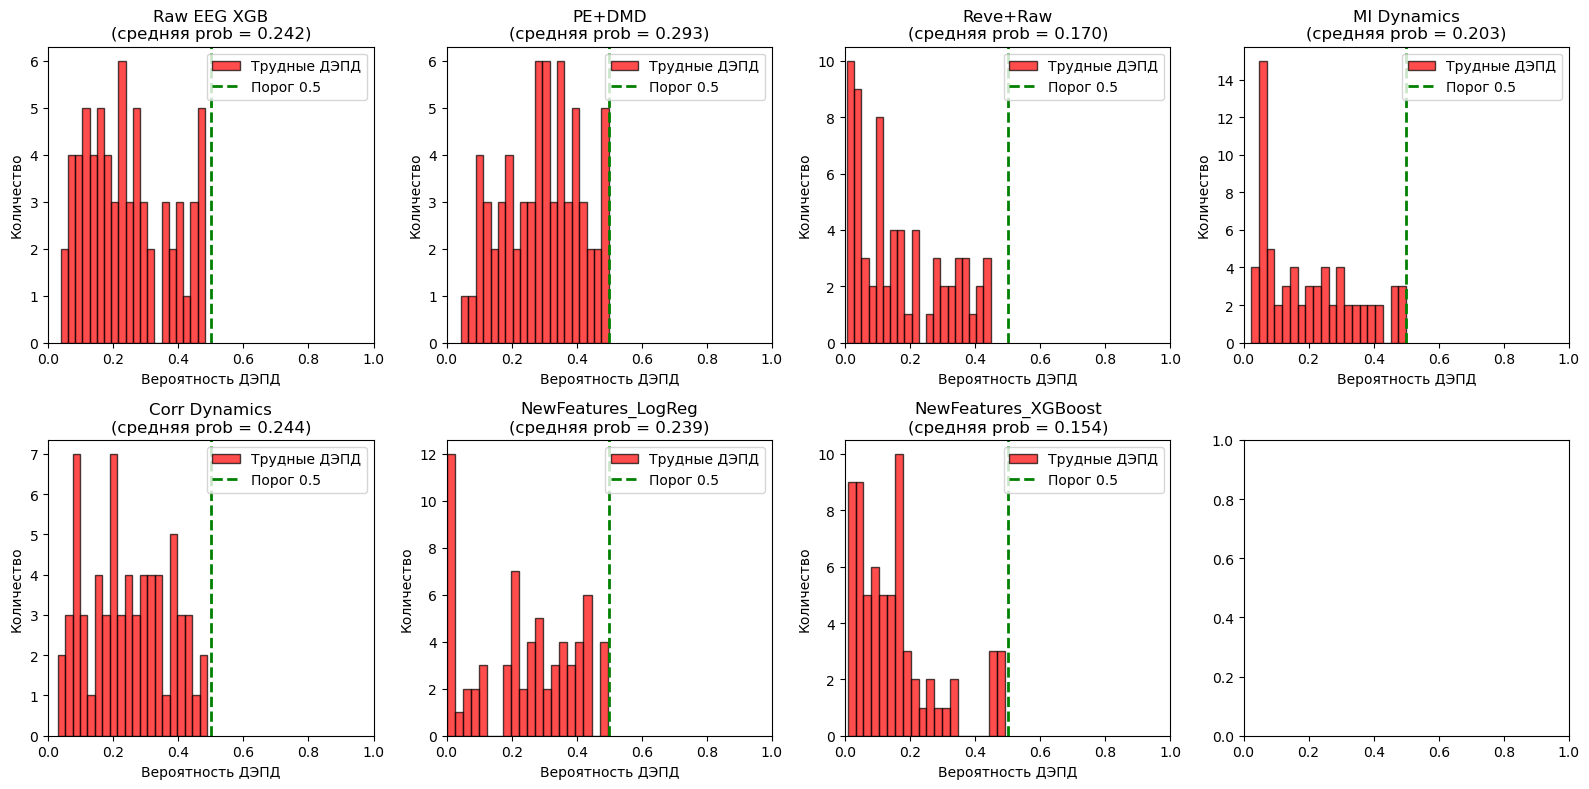


СТАТИСТИКА МОДЕЛЕЙ НА 'ТРУДНЫХ' ДЭПД

Модель                          Средняя вероятность    Медиана
-----------------------------------------------------------------
Raw EEG XGB                                  0.2423     0.2343
PE+DMD                                       0.2932     0.3037
Reve+Raw                                     0.1698     0.1269
MI Dynamics                                  0.2027     0.1737
Corr Dynamics                                0.2443     0.2372
NewFeatures_LogReg                           0.2394     0.2659
NewFeatures_XGBoost                          0.1542     0.1285

СОХРАНЁННЫЕ ФАЙЛЫ

Папка: C:\Users\Admin\Desktop\EEG\work 12.05.2026\hard_depd_samples

Файлы:
  easy_depd_data.npy (20601.7 KB)
  easy_depd_samples.pkl (20666.3 KB)
  hard_depd_data.npy (4711.1 KB)
  hard_depd_indices.npy (0.6 KB)
  hard_depd_probabilities.npy (3.5 KB)
  hard_depd_prob_distribution.png (122.1 KB)
  hard_depd_samples.pkl (4726.0 KB)

ГОТОВО! База данных 'трудных' ДЭПД со

In [41]:
print("="*80)
print("СОЗДАНИЕ БАЗЫ ДАННЫХ 'ТРУДНЫХ' ДЭПД")
print("="*80)

# ============================================================
# 1. НАХОДИМ ИНДЕКСЫ "ТРУДНЫХ" ДЭПД
# ============================================================

# Индексы всех ДЭПД в тесте
all_depd_indices = np.where(y_test == 1)[0]
print(f"Всего ДЭПД в тесте: {len(all_depd_indices)}")

# Индексы, найденные правилом 3/3
found_by_unanimous = np.where(y_pred_unanimous == 1)[0]
found_depd_indices = np.intersect1d(found_by_unanimous, all_depd_indices)
print(f"Найдено правилом 3/3: {len(found_depd_indices)}")

# Индексы пропущенных ДЭПД (FN)
fn_indices = np.where((y_pred_unanimous == 0) & (y_test == 1))[0]
print(f"Пропущено правилом 3/3: {len(fn_indices)}")

# Находим "трудные" ДЭПД - которые не нашла НИ ОДНА модель
# Для этого проверяем каждую модель на FN

# Собираем предсказания всех моделей на FN
all_predictions = []

for name, proba in all_models_for_analysis:
    pred = (proba[fn_indices] > 0.5).astype(int)
    all_predictions.append(pred)

# Суммируем предсказания: если сумма = 0, значит ни одна модель не нашла
all_predictions_sum = np.sum(all_predictions, axis=0)

# Индексы в массиве FN, которые не нашла НИ ОДНА модель
hard_fn_relative_indices = np.where(all_predictions_sum == 0)[0]

# Абсолютные индексы в тестовом наборе
hard_depd_indices = fn_indices[hard_fn_relative_indices]

print(f"\n'Трудные' ДЭПД (не найдены НИ ОДНОЙ моделью): {len(hard_depd_indices)}")
print(f"Доля от всех ДЭПД: {len(hard_depd_indices)/len(all_depd_indices)*100:.1f}%")

# ============================================================
# 2. СОЗДАНИЕ БАЗЫ ДАННЫХ "ТРУДНЫХ" ДЭПД
# ============================================================

# Создаём структуру данных для "трудных" ДЭПД
hard_depd_samples = []

for idx in hard_depd_indices:
    # Получаем соответствующий образец из тестовой выборки
    # Нам нужно найти исходный sample в dataset
    # У нас есть X_test и y_test, но нет мета-информации.
    # Сохраняем то, что есть:
    sample = {
        'data': X_test[idx],  # (18, 1000)
        'label': y_test[idx],  # 1 (ДЭПД)
        'test_index': idx,  # индекс в тестовой выборке
        'probabilities': {}
    }
    
    # Сохраняем вероятности всех моделей для этого окна
    for name, proba in all_models_for_analysis:
        sample['probabilities'][name] = proba[idx]
    
    hard_depd_samples.append(sample)

print(f"\nСоздано {len(hard_depd_samples)} образцов 'трудных' ДЭПД")

# ============================================================
# 3. СОХРАНЕНИЕ В ФАЙЛЫ
# ============================================================

import pickle
from pathlib import Path

# Создаём папку для сохранения
hard_depd_dir = Path("./hard_depd_samples")
hard_depd_dir.mkdir(exist_ok=True)

# Сохраняем полные образцы (с данными и вероятностями)
with open(hard_depd_dir / "hard_depd_samples.pkl", 'wb') as f:
    pickle.dump(hard_depd_samples, f)
print(f"\n✅ Сохранены полные образцы: {hard_depd_dir / 'hard_depd_samples.pkl'}")

# Сохраняем только данные (для быстрой загрузки)
hard_depd_data = np.array([s['data'] for s in hard_depd_samples])
np.save(hard_depd_dir / "hard_depd_data.npy", hard_depd_data)
print(f"✅ Сохранены данные: {hard_depd_dir / 'hard_depd_data.npy'}")

# # Сохраняем вероятности моделей для каждого трудного ДЭПД
# hard_depd_probs = {name: [] for name, _ in all_models_for_analysis}
# for sample in hard_depd_samples:
#     for name, prob in sample['probabilities'].items():
#         hard_depd_probs[name].append(prob)

# for name in hard_depd_probs:
#     hard_depd_probs[name] = np.array(hard_depd_probs[name])

# Правильный способ:
hard_depd_probs = {name: [] for name, _ in all_models_for_analysis}
for sample in hard_depd_samples:
    for name, prob in sample['probabilities'].items():
        hard_depd_probs[name].append(prob)

for name in hard_depd_probs:
    hard_depd_probs[name] = np.array(hard_depd_probs[name])

np.save(hard_depd_dir / "hard_depd_probabilities.npy", hard_depd_probs)
print(f"✅ Сохранены вероятности: {hard_depd_dir / 'hard_depd_probabilities.npy'}")

# Сохраняем индексы
np.save(hard_depd_dir / "hard_depd_indices.npy", hard_depd_indices)
print(f"✅ Сохранены индексы: {hard_depd_dir / 'hard_depd_indices.npy'}")

# ============================================================
# 4. СОЗДАНИЕ ЛЁГКИХ ДЭПД (ДЛЯ СРАВНЕНИЯ)
# ============================================================

# Находим "лёгкие" ДЭПД (которые нашло правило 3/3)
easy_depd_indices = found_depd_indices

print(f"\n'Лёгкие' ДЭПД (найдены правилом 3/3): {len(easy_depd_indices)}")

easy_depd_samples = []
for idx in easy_depd_indices:
    sample = {
        'data': X_test[idx],
        'label': y_test[idx],
        'test_index': idx,
        'probabilities': {}
    }
    for name, proba in all_models_for_analysis:
        sample['probabilities'][name] = proba[idx]
    easy_depd_samples.append(sample)

# Сохраняем лёгкие ДЭПД
with open(hard_depd_dir / "easy_depd_samples.pkl", 'wb') as f:
    pickle.dump(easy_depd_samples, f)

easy_depd_data = np.array([s['data'] for s in easy_depd_samples])
np.save(hard_depd_dir / "easy_depd_data.npy", easy_depd_data)
print(f"✅ Сохранены 'лёгкие' ДЭПД: {len(easy_depd_samples)} образцов")

# ============================================================
# 5. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (name, proba) in enumerate(all_models_for_analysis[:8]):
    ax = axes[idx]
    
    # Вероятности для "трудных" ДЭПД
    hard_probs = hard_depd_probs[name]
    
    ax.hist(hard_probs, bins=20, alpha=0.7, color='red', edgecolor='black', label='Трудные ДЭПД')
    ax.axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Порог 0.5')
    ax.set_title(f'{name}\n(средняя prob = {hard_probs.mean():.3f})')
    ax.set_xlabel('Вероятность ДЭПД')
    ax.set_ylabel('Количество')
    ax.legend()
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(hard_depd_dir / "hard_depd_prob_distribution.png", dpi=150)
plt.show()

# ============================================================
# 6. СТАТИСТИКА ПО МОДЕЛЯМ НА ТРУДНЫХ ДЭПД
# ============================================================

print("\n" + "="*80)
print("СТАТИСТИКА МОДЕЛЕЙ НА 'ТРУДНЫХ' ДЭПД")
print("="*80)

print(f"\n{'Модель':<30} {'Средняя вероятность':>20} {'Медиана':>10}")
print("-" * 65)

for name, proba in all_models_for_analysis:
    hard_probs = hard_depd_probs[name]
    mean_prob = hard_probs.mean()
    median_prob = np.median(hard_probs)
    print(f"{name:<30} {mean_prob:20.4f} {median_prob:10.4f}")

# ============================================================
# 7. ИНФОРМАЦИЯ О ФАЙЛАХ
# ============================================================

print("\n" + "="*80)
print("СОХРАНЁННЫЕ ФАЙЛЫ")
print("="*80)

print(f"\nПапка: {hard_depd_dir.absolute()}")
print("\nФайлы:")
for f in hard_depd_dir.iterdir():
    size = f.stat().st_size / 1024  # KB
    print(f"  {f.name} ({size:.1f} KB)")

print("\n" + "="*80)
print("ГОТОВО! База данных 'трудных' ДЭПД создана")
print("="*80)

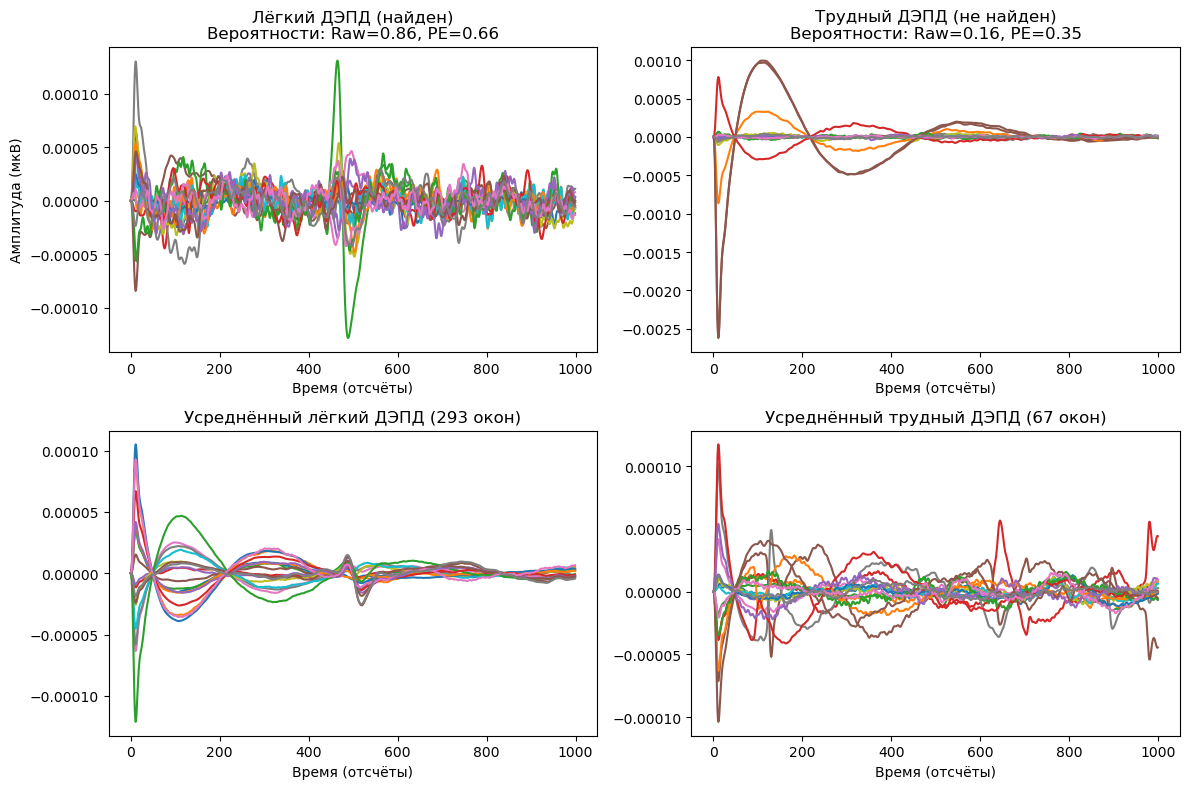

In [42]:
# Визуализация сравнения лёгких и трудных ДЭПД
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Один лёгкий ДЭПД
ax = axes[0, 0]
idx = easy_depd_indices[0]
ax.plot(X_test[idx].T)
ax.set_title(f'Лёгкий ДЭПД (найден)\nВероятности: Raw={y_proba_raw[idx]:.2f}, PE={y_proba_pe[idx]:.2f}')
ax.set_xlabel('Время (отсчёты)')
ax.set_ylabel('Амплитуда (мкВ)')

# Один трудный ДЭПД
ax = axes[0, 1]
idx = hard_depd_indices[0]
ax.plot(X_test[idx].T)
ax.set_title(f'Трудный ДЭПД (не найден)\nВероятности: Raw={y_proba_raw[idx]:.2f}, PE={y_proba_pe[idx]:.2f}')
ax.set_xlabel('Время (отсчёты)')

# Усреднённый лёгкий
ax = axes[1, 0]
easy_mean = np.mean(X_test[easy_depd_indices], axis=0)
ax.plot(easy_mean.T)
ax.set_title(f'Усреднённый лёгкий ДЭПД ({len(easy_depd_indices)} окон)')
ax.set_xlabel('Время (отсчёты)')

# Усреднённый трудный
ax = axes[1, 1]
hard_mean = np.mean(X_test[hard_depd_indices], axis=0)
ax.plot(hard_mean.T)
ax.set_title(f'Усреднённый трудный ДЭПД ({len(hard_depd_indices)} окон)')
ax.set_xlabel('Время (отсчёты)')

plt.tight_layout()
plt.show()

ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ ЛЁГКИХ, ТРУДНЫХ И ФОНОВЫХ ОКОН
Визуализируем:
  - Лёгкие ДЭПД: 67 окон
  - Трудные ДЭПД: 67 окон
  - Фоновые окна: 67 окон


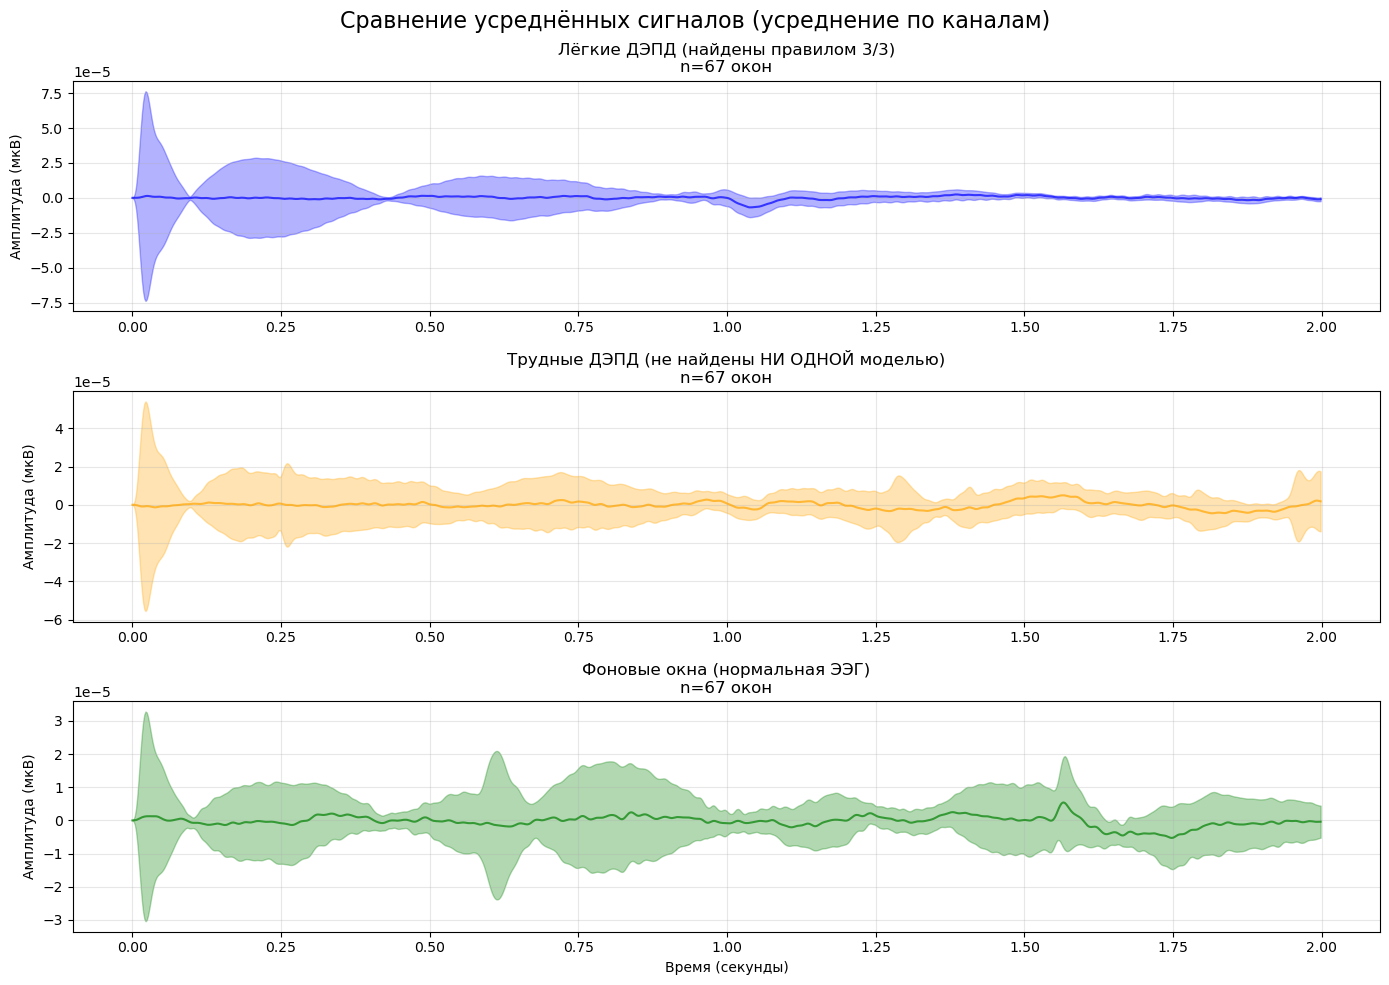

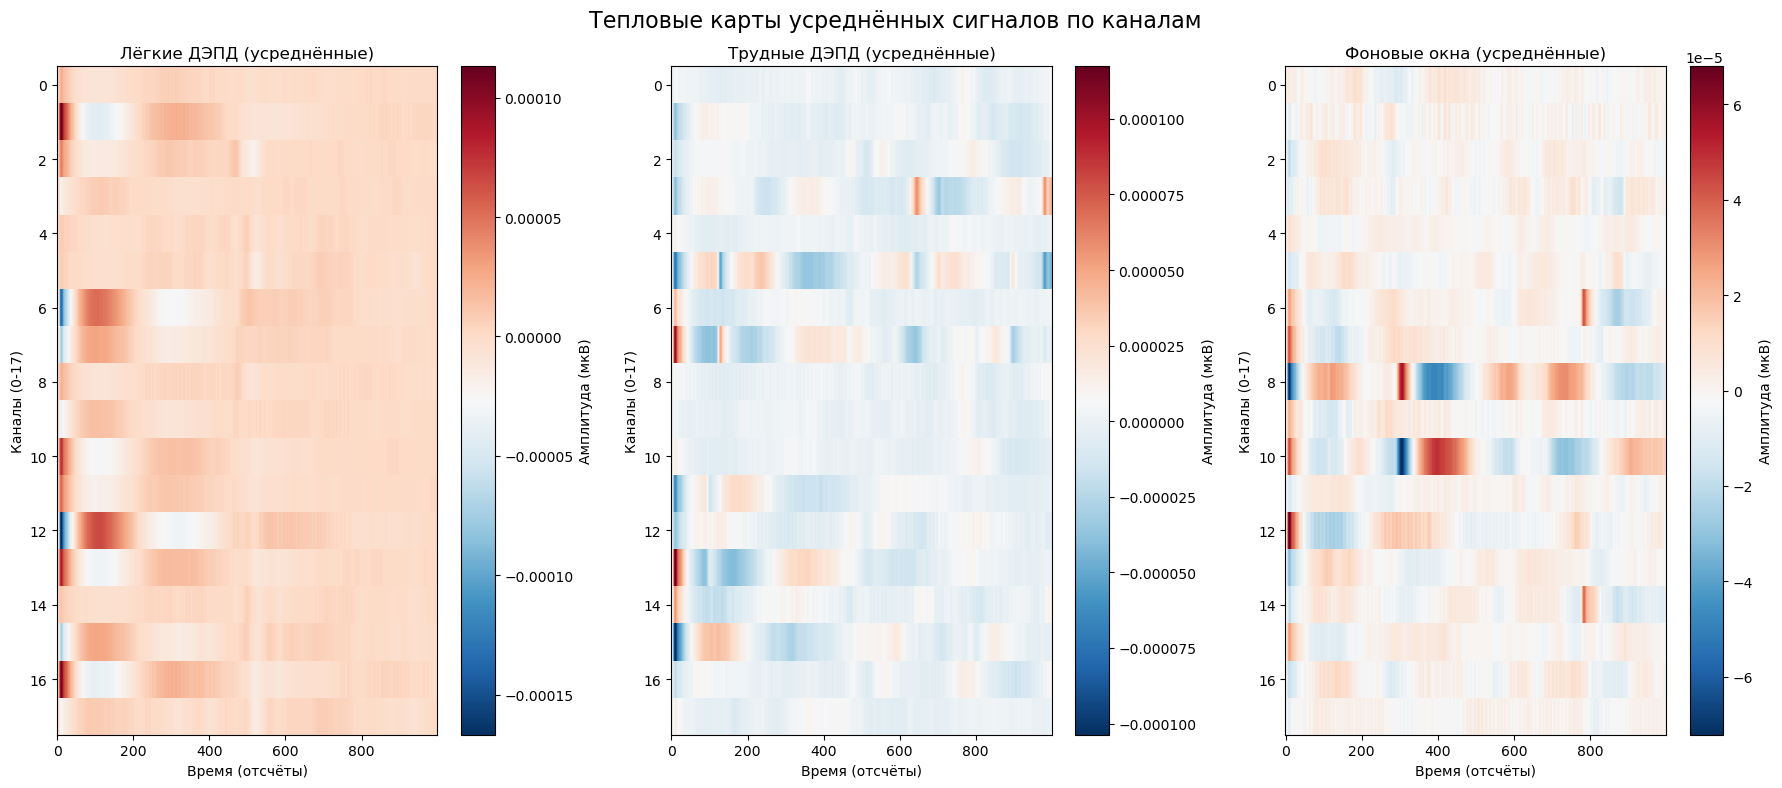

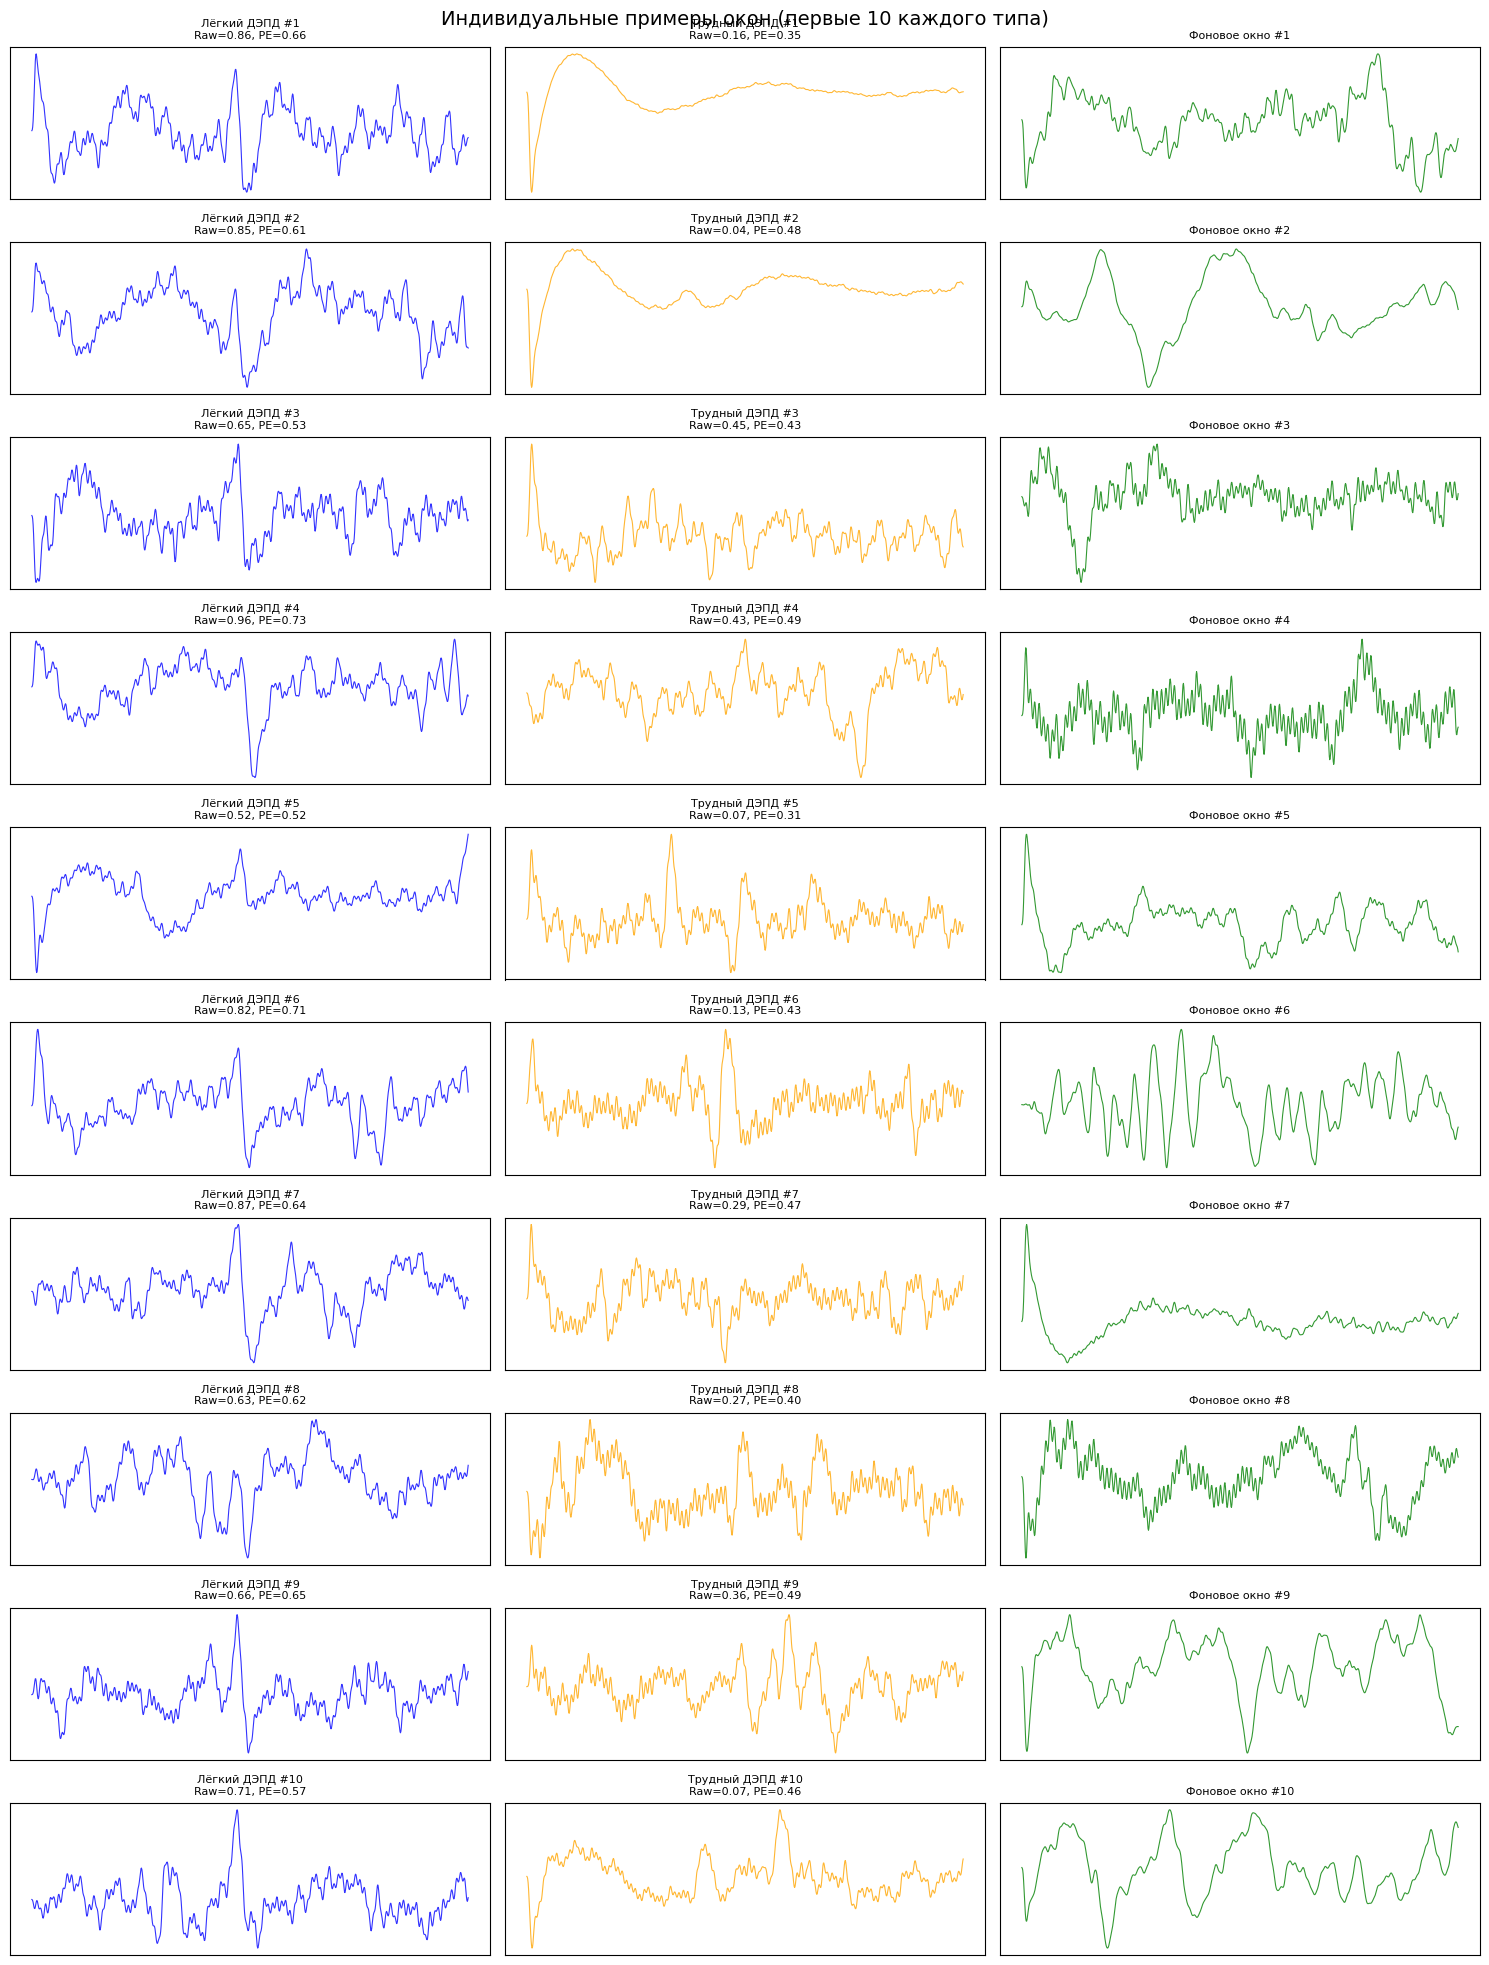


СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ ОКОН

Показатель               Лёгкие ДЭПД    Трудные ДЭПД         Фоновые
-----------------------------------------------------------------
mean_amplitude                0.0000          0.0000          0.0000
std_amplitude                 0.0000          0.0000          0.0000
peak_to_peak                  0.0000          0.0001          0.0001
rms                           0.0000          0.0000          0.0000


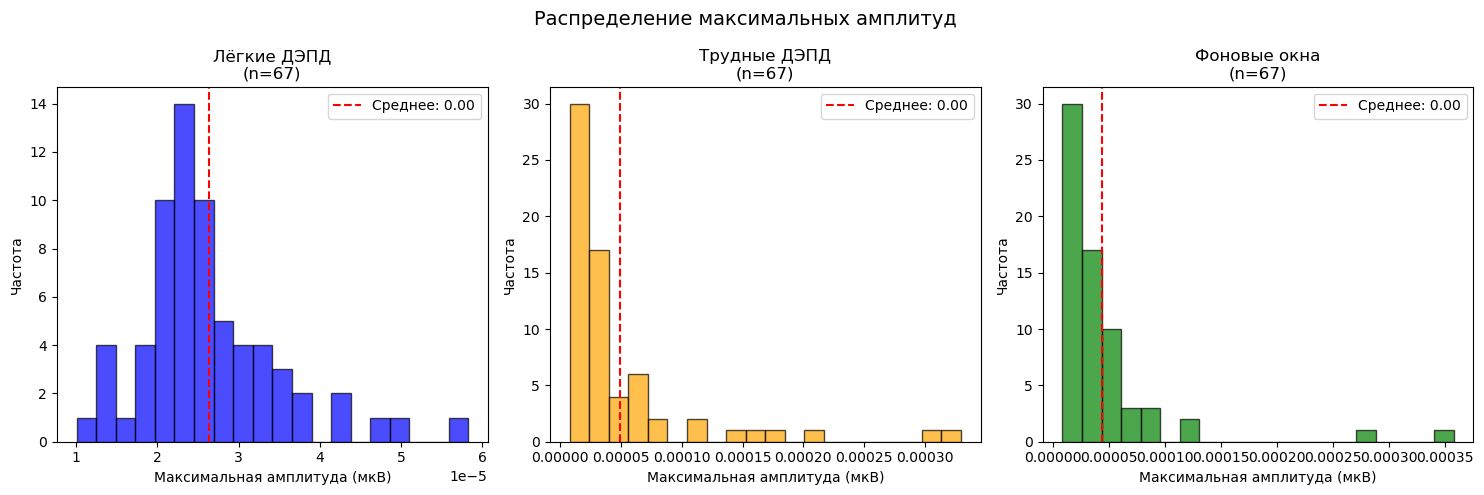

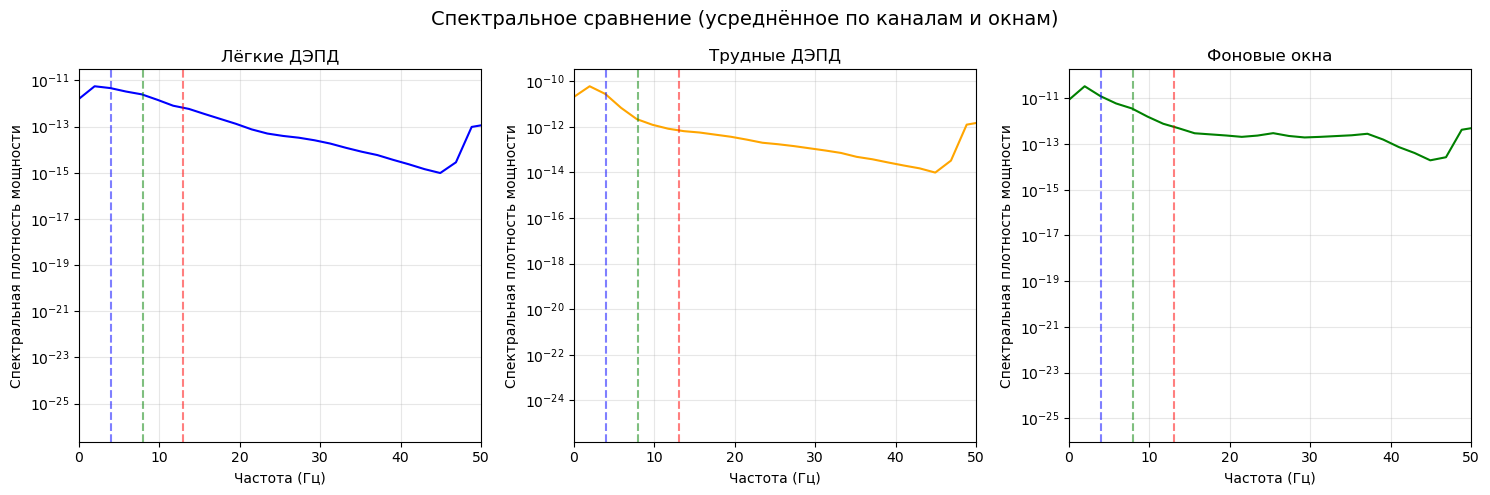


✅ Все визуализации сохранены в папку: C:\Users\Admin\Desktop\EEG\work 12.05.2026\depd_visualization
ГОТОВО!


In [48]:
print("="*80)
print("ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ ЛЁГКИХ, ТРУДНЫХ И ФОНОВЫХ ОКОН")
print("="*80)

import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import welch

# Создаём папку для визуализаций
viz_dir = Path("./depd_visualization")
viz_dir.mkdir(exist_ok=True)

# ============================================================
# 1. ПОДГОТОВКА ДАННЫХ
# ============================================================

# Берём первые 250 образцов каждого типа
n_samples_to_plot = min(250, len(easy_depd_indices), len(hard_depd_indices))

easy_indices = easy_depd_indices[:n_samples_to_plot]
hard_indices = hard_depd_indices[:n_samples_to_plot]

# Фоновые окна (где y_test == 0)
background_indices = np.where(y_test == 0)[0][:n_samples_to_plot]

print(f"Визуализируем:")
print(f"  - Лёгкие ДЭПД: {len(easy_indices)} окон")
print(f"  - Трудные ДЭПД: {len(hard_indices)} окон")
print(f"  - Фоновые окна: {len(background_indices)} окон")

# ============================================================
# 2. УСРЕДНЁННЫЕ СИГНАЛЫ ПО ТИПАМ
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Усреднённые сигналы
easy_mean = np.mean(X_test[easy_indices], axis=0)  # (18, 1000)
hard_mean = np.mean(X_test[hard_indices], axis=0)
bg_mean = np.mean(X_test[background_indices], axis=0)

# Стандартные отклонения
easy_std = np.std(X_test[easy_indices], axis=0)
hard_std = np.std(X_test[hard_indices], axis=0)
bg_std = np.std(X_test[background_indices], axis=0)

time = np.arange(1000) / 500  # 2 секунды, 500 Гц

# Лёгкие ДЭПД (усредняем по каналам для отображения)
ax = axes[0]
easy_mean_avg = np.mean(easy_mean, axis=0)
easy_std_avg = np.std(easy_mean, axis=0)
ax.plot(time, easy_mean_avg, alpha=0.7, linewidth=1.5, color='blue')
ax.fill_between(time, easy_mean_avg - easy_std_avg, easy_mean_avg + easy_std_avg, alpha=0.3, color='blue')
ax.set_title(f'Лёгкие ДЭПД (найдены правилом 3/3)\nn={len(easy_indices)} окон', fontsize=12)
ax.set_ylabel('Амплитуда (мкВ)')
ax.grid(True, alpha=0.3)

# Трудные ДЭПД
ax = axes[1]
hard_mean_avg = np.mean(hard_mean, axis=0)
hard_std_avg = np.std(hard_mean, axis=0)
ax.plot(time, hard_mean_avg, alpha=0.7, linewidth=1.5, color='orange')
ax.fill_between(time, hard_mean_avg - hard_std_avg, hard_mean_avg + hard_std_avg, alpha=0.3, color='orange')
ax.set_title(f'Трудные ДЭПД (не найдены НИ ОДНОЙ моделью)\nn={len(hard_indices)} окон', fontsize=12)
ax.set_ylabel('Амплитуда (мкВ)')
ax.grid(True, alpha=0.3)

# Фоновые окна
ax = axes[2]
bg_mean_avg = np.mean(bg_mean, axis=0)
bg_std_avg = np.std(bg_mean, axis=0)
ax.plot(time, bg_mean_avg, alpha=0.7, linewidth=1.5, color='green')
ax.fill_between(time, bg_mean_avg - bg_std_avg, bg_mean_avg + bg_std_avg, alpha=0.3, color='green')
ax.set_title(f'Фоновые окна (нормальная ЭЭГ)\nn={len(background_indices)} окон', fontsize=12)
ax.set_xlabel('Время (секунды)')
ax.set_ylabel('Амплитуда (мкВ)')
ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение усреднённых сигналов (усреднение по каналам)', fontsize=16)
plt.tight_layout()
plt.savefig(viz_dir / "averaged_signals_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 3. ПОКАНАЛЬНЫЕ УСРЕДНЁННЫЕ ТЕПЛОВЫЕ КАРТЫ
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Лёгкие ДЭПД
im = axes[0].imshow(easy_mean, aspect='auto', cmap='RdBu_r', interpolation='nearest')
axes[0].set_title('Лёгкие ДЭПД (усреднённые)', fontsize=12)
axes[0].set_xlabel('Время (отсчёты)')
axes[0].set_ylabel('Каналы (0-17)')
plt.colorbar(im, ax=axes[0], label='Амплитуда (мкВ)')

# Трудные ДЭПД
im = axes[1].imshow(hard_mean, aspect='auto', cmap='RdBu_r', interpolation='nearest')
axes[1].set_title('Трудные ДЭПД (усреднённые)', fontsize=12)
axes[1].set_xlabel('Время (отсчёты)')
axes[1].set_ylabel('Каналы (0-17)')
plt.colorbar(im, ax=axes[1], label='Амплитуда (мкВ)')

# Фоновые окна
im = axes[2].imshow(bg_mean, aspect='auto', cmap='RdBu_r', interpolation='nearest')
axes[2].set_title('Фоновые окна (усреднённые)', fontsize=12)
axes[2].set_xlabel('Время (отсчёты)')
axes[2].set_ylabel('Каналы (0-17)')
plt.colorbar(im, ax=axes[2], label='Амплитуда (мкВ)')

plt.suptitle('Тепловые карты усреднённых сигналов по каналам', fontsize=16)
plt.tight_layout()
plt.savefig(viz_dir / "average_heatmaps.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 4. ИНДИВИДУАЛЬНЫЕ ПРИМЕРЫ (ПЕРВЫЕ 10 КАЖДОГО ТИПА)
# ============================================================

fig, axes = plt.subplots(10, 3, figsize=(15, 20))

for i in range(min(10, len(easy_indices), len(hard_indices), len(background_indices))):
    # Лёгкий ДЭПД
    ax = axes[i, 0]
    idx = easy_indices[i]
    # Усредняем по каналам для отображения
    signal_avg = np.mean(X_test[idx], axis=0)
    ax.plot(time, signal_avg, alpha=0.8, linewidth=0.8, color='blue')
    ax.set_title(f'Лёгкий ДЭПД #{i+1}\nRaw={y_proba_raw[idx]:.2f}, PE={y_proba_pe[idx]:.2f}', fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Трудный ДЭПД
    ax = axes[i, 1]
    idx = hard_indices[i]
    signal_avg = np.mean(X_test[idx], axis=0)
    ax.plot(time, signal_avg, alpha=0.8, linewidth=0.8, color='orange')
    ax.set_title(f'Трудный ДЭПД #{i+1}\nRaw={y_proba_raw[idx]:.2f}, PE={y_proba_pe[idx]:.2f}', fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Фоновое окно
    ax = axes[i, 2]
    idx = background_indices[i]
    signal_avg = np.mean(X_test[idx], axis=0)
    ax.plot(time, signal_avg, alpha=0.8, linewidth=0.8, color='green')
    ax.set_title(f'Фоновое окно #{i+1}', fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Индивидуальные примеры окон (первые 10 каждого типа)', fontsize=14)
plt.tight_layout()
plt.savefig(viz_dir / "individual_examples.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 5. СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ
# ============================================================

# Вычисляем статистики для каждого типа окон
def compute_stats(indices):
    signals = X_test[indices]
    # Усредняем по каналам для каждого окна
    signals_avg = np.mean(signals, axis=1)
    return {
        'mean_amplitude': np.mean(np.abs(signals_avg)),
        'std_amplitude': np.std(signals_avg),
        'peak_to_peak': np.mean(np.ptp(signals_avg, axis=1)),
        'rms': np.mean(np.sqrt(np.mean(signals_avg**2, axis=1)))
    }

easy_stats = compute_stats(easy_indices)
hard_stats = compute_stats(hard_indices)
bg_stats = compute_stats(background_indices)

print("\n" + "="*80)
print("СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ ОКОН")
print("="*80)

print(f"\n{'Показатель':<20} {'Лёгкие ДЭПД':>15} {'Трудные ДЭПД':>15} {'Фоновые':>15}")
print("-" * 65)

for metric in ['mean_amplitude', 'std_amplitude', 'peak_to_peak', 'rms']:
    print(f"{metric:<20} {easy_stats[metric]:15.4f} {hard_stats[metric]:15.4f} {bg_stats[metric]:15.4f}")

# ============================================================
# 6. РАСПРЕДЕЛЕНИЕ АМПЛИТУД
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, indices, title, color in zip(
    axes, 
    [easy_indices, hard_indices, background_indices],
    ['Лёгкие ДЭПД', 'Трудные ДЭПД', 'Фоновые окна'],
    ['blue', 'orange', 'green']
):
    # Вычисляем максимальную амплитуду для каждого окна (усреднённую по каналам)
    max_amps = [np.max(np.abs(np.mean(X_test[idx], axis=0))) for idx in indices]
    ax.hist(max_amps, bins=20, alpha=0.7, color=color, edgecolor='black')
    ax.set_title(f'{title}\n(n={len(indices)})')
    ax.set_xlabel('Максимальная амплитуда (мкВ)')
    ax.set_ylabel('Частота')
    ax.axvline(x=np.mean(max_amps), color='red', linestyle='--', label=f'Среднее: {np.mean(max_amps):.2f}')
    ax.legend()

plt.suptitle('Распределение максимальных амплитуд', fontsize=14)
plt.tight_layout()
plt.savefig(viz_dir / "amplitude_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 7. СПЕКТРАЛЬНОЕ СРАВНЕНИЕ
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

freqs = None

for ax, indices, title, color in zip(
    axes,
    [easy_indices, hard_indices, background_indices],
    ['Лёгкие ДЭПД', 'Трудные ДЭПД', 'Фоновые окна'],
    ['blue', 'orange', 'green']
):
    # Усреднённый спектр (усреднение по каналам и окнам)
    all_psd = []
    for idx in indices[:50]:  # Берём первые 50 для скорости
        signal_avg = np.mean(X_test[idx], axis=0)
        f, psd = welch(signal_avg, fs=500, nperseg=256)
        all_psd.append(psd)
        if freqs is None:
            freqs = f
    
    mean_psd = np.mean(all_psd, axis=0)
    ax.semilogy(freqs, mean_psd, color=color, linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel('Частота (Гц)')
    ax.set_ylabel('Спектральная плотность мощности')
    ax.set_xlim(0, 50)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=13, color='red', linestyle='--', alpha=0.5, label='Бета (13-30)')
    ax.axvline(x=8, color='green', linestyle='--', alpha=0.5, label='Альфа (8-13)')
    ax.axvline(x=4, color='blue', linestyle='--', alpha=0.5, label='Тета (4-8)')

plt.suptitle('Спектральное сравнение (усреднённое по каналам и окнам)', fontsize=14)
plt.tight_layout()
plt.savefig(viz_dir / "spectral_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Все визуализации сохранены в папку: {viz_dir.absolute()}")
print("="*80)
print("ГОТОВО!")
print("="*80)

КЛАССИФИКАТОР НА ОСНОВЕ УСРЕДНЁННЫХ КАНАЛОВ

Подготовка данных...
X_train_avg shape: (9459, 1000)
X_test_avg shape: (4672, 1000)

Извлечение признаков...
Признаки train: (9459, 30)
Признаки test: (4672, 30)

ЗАДАЧА 1: БИНАРНАЯ КЛАССИФИКАЦИЯ (ДЭПД vs ФОН)

Модель                       F1 (DEPD)  Precision   Recall
------------------------------------------------------------
Logistic Regression             0.4501     0.3168   0.7770
Linear SVM                      0.4300     0.2931   0.8067

ЗАДАЧА 2: ТРЁХКЛАССОВАЯ КЛАССИФИКАЦИЯ
Распределение классов в тесте:
  Фон: 4312
  Лёгкие ДЭПД: 293
  Трудные ДЭПД: 67

Обучающая выборка для трёх классов: (427, 30)
  Класс 0 (фон): 67
  Класс 1 (лёгкие): 293
  Класс 2 (трудные): 67

Модель                      Accuracy   Macro F1  Weighted F1
------------------------------------------------------------
Logistic Regression           0.7597     0.4907       0.7024

  Classification report for Logistic Regression:
              precision    recall  f1

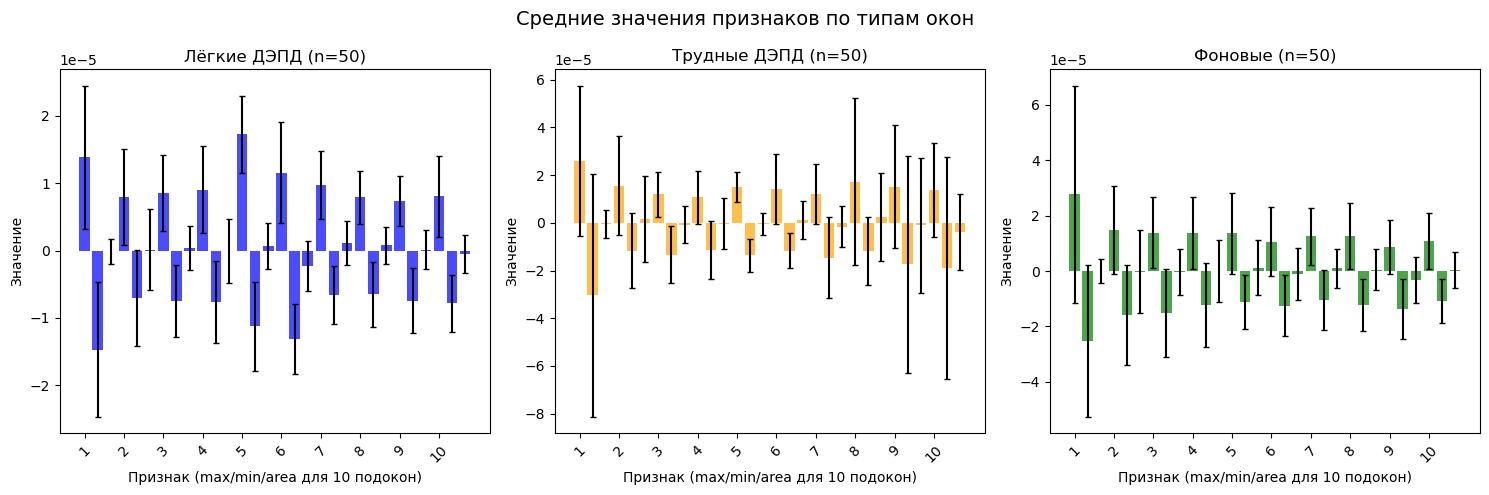


Топ-10 наиболее важных признаков (Logistic Regression):
  Признак 5: 2_area = 3.1610
  Признак 12: 5_max = 2.5200
  Признак 16: 6_min = -1.6747
  Признак 11: 4_area = 1.5390
  Признак 19: 7_min = 1.4788
  Признак 2: 1_area = 1.4599
  Признак 8: 3_area = 1.2739
  Признак 10: 4_min = 1.2558
  Признак 17: 6_area = 1.2435
  Признак 7: 3_min = 0.9211

СРАВНЕНИЕ С ПРОШЛЫМИ РЕЗУЛЬТАТАМИ (DEPD)

Лучший прошлый результат (ансамбль): F1 = 0.5025
Простой классификатор (усреднённые признаки): F1 = 0.4501
  🔴 Уступает на 0.0524

ГОТОВО!


In [51]:
print("="*80)
print("КЛАССИФИКАТОР НА ОСНОВЕ УСРЕДНЁННЫХ КАНАЛОВ")
print("="*80)

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
import matplotlib.pyplot as plt

# ============================================================
# 1. ФУНКЦИЯ ДЛЯ ИЗВЛЕЧЕНИЯ ПРИЗНАКОВ ИЗ УСРЕДНЁННОГО СИГНАЛА
# ============================================================

def extract_simple_features(signal, n_subwindows=10):
    """
    Извлекает признаки из усреднённого сигнала
    
    signal: 1D массив (n_samples,) - усреднённый по каналам сигнал
    n_subwindows: количество подокон (по умолчанию 10)
    
    Возвращает: вектор признаков (n_subwindows * 3)
    """
    n_samples = len(signal)
    subwindow_len = n_samples // n_subwindows
    
    features = []
    
    for i in range(n_subwindows):
        start = i * subwindow_len
        end = (i + 1) * subwindow_len
        subwindow = signal[start:end]
        
        # 1. Максимум
        features.append(np.max(subwindow))
        # 2. Минимум
        features.append(np.min(subwindow))
        # 3. Площадь под кривой (интеграл)
        area = np.sum(subwindow) / subwindow_len
        features.append(area)
    
    return np.array(features)

# ============================================================
# 2. ПОДГОТОВКА ДАННЫХ
# ============================================================

print("\nПодготовка данных...")

# Усредняем сигналы по каналам для всех окон
X_train_avg = np.mean(X_train, axis=1)  # (9459, 1000)
X_test_avg = np.mean(X_test, axis=1)    # (4672, 1000)

print(f"X_train_avg shape: {X_train_avg.shape}")
print(f"X_test_avg shape: {X_test_avg.shape}")

# Извлекаем признаки для всех окон
print("\nИзвлечение признаков...")
X_train_feat_simple = np.array([extract_simple_features(sig) for sig in X_train_avg])
X_test_feat_simple = np.array([extract_simple_features(sig) for sig in X_test_avg])

print(f"Признаки train: {X_train_feat_simple.shape}")
print(f"Признаки test: {X_test_feat_simple.shape}")

# ============================================================
# 3. ЗАДАЧА 1: БИНАРНАЯ КЛАССИФИКАЦИЯ (ДЭПД vs ФОН)
# ============================================================

print("\n" + "="*80)
print("ЗАДАЧА 1: БИНАРНАЯ КЛАССИФИКАЦИЯ (ДЭПД vs ФОН)")
print("="*80)

y_train_binary = y_train
y_test_binary = y_test

# Нормализация
scaler_binary = StandardScaler()
X_train_binary_scaled = scaler_binary.fit_transform(X_train_feat_simple)
X_test_binary_scaled = scaler_binary.transform(X_test_feat_simple)

# Модели
models_binary = {
    'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
    'Linear SVM': LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42, dual='auto')
}

print(f"\n{'Модель':<25} {'F1 (DEPD)':>12} {'Precision':>10} {'Recall':>8}")
print("-" * 60)

binary_results = {}
for name, model in models_binary.items():
    model.fit(X_train_binary_scaled, y_train_binary)
    y_pred = model.predict(X_test_binary_scaled)
    
    f1 = f1_score(y_test_binary, y_pred, pos_label=1)
    prec = precision_score(y_test_binary, y_pred, pos_label=1)
    rec = recall_score(y_test_binary, y_pred, pos_label=1)
    binary_results[name] = {'f1': f1, 'precision': prec, 'recall': rec}
    
    print(f"{name:<25} {f1:12.4f} {prec:10.4f} {rec:8.4f}")

# ============================================================
# 4. ЗАДАЧА 2: ТРЁХКЛАССОВАЯ КЛАССИФИКАЦИЯ (ИСПРАВЛЕНО)
# ============================================================

print("\n" + "="*80)
print("ЗАДАЧА 2: ТРЁХКЛАССОВАЯ КЛАССИФИКАЦИЯ")
print("="*80)

# Создаём метки для трёх классов:
# 0 - фон, 1 - лёгкие ДЭПД, 2 - трудные ДЭПД
y_train_3class = np.zeros(len(y_train), dtype=int)
y_test_3class = np.zeros(len(y_test), dtype=int)

# Определяем индексы лёгких и трудных ДЭПД в тесте
# Лёгкие ДЭПД (найдены правилом 3/3)
easy_indices_full = easy_depd_indices
hard_indices_full = hard_depd_indices

# Для тестовой выборки
for idx in easy_indices_full:
    y_test_3class[idx] = 1  # лёгкие ДЭПД
for idx in hard_indices_full:
    y_test_3class[idx] = 2  # трудные ДЭПД

print(f"Распределение классов в тесте:")
print(f"  Фон: {np.sum(y_test_3class == 0)}")
print(f"  Лёгкие ДЭПД: {np.sum(y_test_3class == 1)}")
print(f"  Трудные ДЭПД: {np.sum(y_test_3class == 2)}")

# Обучаем модель для трёх классов (используем только тестовую выборку для оценки)
# Для этого создадим обучающую выборку из части тестовых данных
# Разделим тестовые данные на train и test для трёхклассовой задачи
from sklearn.model_selection import train_test_split

# Используем только те окна, которые我们有 метки для трёх классов
labeled_indices = np.where(y_test_3class != 0)[0]
X_labeled = X_test_feat_simple[labeled_indices]
y_labeled = y_test_3class[labeled_indices]

# Добавляем фоновые окна для баланса
bg_indices = background_indices[:len(labeled_indices)]
X_bg = X_test_feat_simple[bg_indices]
y_bg = np.zeros(len(bg_indices), dtype=int)

# Объединяем
X_3class = np.vstack([X_labeled, X_bg])
y_3class = np.concatenate([y_labeled, y_bg])

print(f"\nОбучающая выборка для трёх классов: {X_3class.shape}")
print(f"  Класс 0 (фон): {np.sum(y_3class == 0)}")
print(f"  Класс 1 (лёгкие): {np.sum(y_3class == 1)}")
print(f"  Класс 2 (трудные): {np.sum(y_3class == 2)}")

# Разделяем на train и test
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X_3class, y_3class, test_size=0.3, random_state=42, stratify=y_3class
)

# Нормализация
scaler_3 = StandardScaler()
X_train_3_scaled = scaler_3.fit_transform(X_train_3)
X_test_3_scaled = scaler_3.transform(X_test_3)

# Модели для трёх классов
models_3class = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42, multi_class='ovr'),
    'Linear SVM': LinearSVC(C=1.0, max_iter=2000, random_state=42, dual='auto')
}

print(f"\n{'Модель':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 60)

for name, model in models_3class.items():
    model.fit(X_train_3_scaled, y_train_3)
    y_pred_3 = model.predict(X_test_3_scaled)
    
    acc = np.mean(y_pred_3 == y_test_3)
    macro_f1 = f1_score(y_test_3, y_pred_3, average='macro')
    weighted_f1 = f1_score(y_test_3, y_pred_3, average='weighted')
    
    print(f"{name:<25} {acc:10.4f} {macro_f1:10.4f} {weighted_f1:12.4f}")
    
    # Детальный отчет по классам
    print(f"\n  Classification report for {name}:")
    print(classification_report(y_test_3, y_pred_3, 
                                target_names=['Фон', 'Лёгкие ДЭПД', 'Трудные ДЭПД']))

# ============================================================
# 5. ВИЗУАЛИЗАЦИЯ ПРИЗНАКОВ
# ============================================================

print("\n" + "="*80)
print("ВИЗУАЛИЗАЦИЯ ПРИЗНАКОВ")
print("="*80)

# Берём по 50 окон каждого типа
vis_easy = easy_indices[:50]
vis_hard = hard_indices[:50]
vis_bg = background_indices[:50]

# Извлекаем признаки для визуализации
easy_features = X_test_feat_simple[vis_easy]
hard_features = X_test_feat_simple[vis_hard]
bg_features = X_test_feat_simple[vis_bg]

# Создаём названия признаков
feature_names = []
for i in range(10):
    feature_names.extend([f'{i+1}_max', f'{i+1}_min', f'{i+1}_area'])

# Визуализируем средние признаки для каждого типа
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, data, title, color in zip(axes, [easy_features, hard_features, bg_features],
                                   ['Лёгкие ДЭПД', 'Трудные ДЭПД', 'Фоновые'],
                                   ['blue', 'orange', 'green']):
    mean_feat = np.mean(data, axis=0)
    std_feat = np.std(data, axis=0)
    x = np.arange(len(mean_feat))
    ax.bar(x, mean_feat, yerr=std_feat, alpha=0.7, color=color, capsize=2)
    ax.set_title(f'{title} (n={len(data)})')
    ax.set_xlabel('Признак (max/min/area для 10 подокон)')
    ax.set_ylabel('Значение')
    ax.set_xticks(x[::3])
    ax.set_xticklabels([f'{i+1}' for i in range(10)], rotation=45)

plt.suptitle('Средние значения признаков по типам окон', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 6. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ
# ============================================================

# Для бинарной классификации
best_model = models_binary['Logistic Regression']
coefs = best_model.coef_[0]
feature_importance = np.abs(coefs)
top_indices = np.argsort(feature_importance)[-10:]

print("\nТоп-10 наиболее важных признаков (Logistic Regression):")
for idx in reversed(top_indices):
    print(f"  Признак {idx}: {feature_names[idx]} = {coefs[idx]:.4f}")

# ============================================================
# 7. СРАВНЕНИЕ С ПРОШЛЫМИ РЕЗУЛЬТАТАМИ
# ============================================================

print("\n" + "="*80)
print("СРАВНЕНИЕ С ПРОШЛЫМИ РЕЗУЛЬТАТАМИ (DEPD)")
print("="*80)

# Лучший результат из прошлых экспериментов
best_previous_f1 = 0.5025  # Правило большинства (2/3)

# Текущий результат бинарной классификации
current_f1 = binary_results['Logistic Regression']['f1']

print(f"\nЛучший прошлый результат (ансамбль): F1 = {best_previous_f1:.4f}")
print(f"Простой классификатор (усреднённые признаки): F1 = {current_f1:.4f}")

if current_f1 > best_previous_f1:
    print(f"  🎉 НОВЫЙ РЕКОРД! Буст на {current_f1 - best_previous_f1:.4f}")
else:
    print(f"  🔴 Уступает на {best_previous_f1 - current_f1:.4f}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

In [53]:
print("="*80)
print("ДОБАВЛЕНИЕ ПРОСТОГО КЛАССИФИКАТОРА В АНСАМБЛИ")
print("="*80)

from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
import numpy as np

# ============================================================
# 1. ПОДГОТОВКА ДАННЫХ
# ============================================================

# Обучаем простой классификатор (Logistic Regression на усреднённых признаках)
# Уже обучен в предыдущем эксперименте
simple_proba = models_binary['Logistic Regression'].predict_proba(X_test_binary_scaled)[:, 1]

print(f"Простой классификатор (LogReg на 30 признаках):")
print(f"  F1 = {binary_results['Logistic Regression']['f1']:.4f}")
print(f"  Recall = {binary_results['Logistic Regression']['recall']:.4f}")
print(f"  Precision = {binary_results['Logistic Regression']['precision']:.4f}")

# ============================================================
# 2. АНСАМБЛЬ 1: Правило большинства (2/3) с добавлением простого классификатора
# ============================================================

print("\n" + "="*80)
print("АНСАМБЛЬ 1: БОЛЬШИНСТВО (2/3) С ПРОСТЫМ КЛАССИФИКАТОРОМ")
print("="*80)

# У нас уже есть три цензора: Raw EEG XGB, NewFeatures_LogReg, PE+DMD
# Добавляем SimpleClassifier как четвёртого цензора

censor_probas_4 = [
    y_proba_raw,  # Raw EEG XGB
    new_probas['Logistic Regression'],  # NewFeatures_LogReg
    y_proba_pe,   # PE+DMD
    simple_proba  # Simple Classifier
]

censor_names_4 = ['Raw EEG XGB', 'NewFeatures_LogReg', 'PE+DMD', 'SimpleClassifier']
censor_thresholds_4 = [0.5, 0.5, 0.4, 0.5]  # Используем оптимальные из предыдущих

# Функция для голосования
def majority_vote(probas, thresholds):
    votes = np.sum([(proba > thr).astype(int) for proba, thr in zip(probas, thresholds)], axis=0)
    return (votes >= 2).astype(int)  # 2/4 для большинства

y_pred_majority_4 = majority_vote(censor_probas_4, censor_thresholds_4)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_majority_4).ravel()
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = 2 * recall * precision / (recall + precision) if (recall + precision) > 0 else 0

print(f"\nАнсамбль (2/4 голосов):")
print(f"  Recall = {recall:.4f} ({tp} из {tp+fn} ДЭПД)")
print(f"  Precision = {precision:.4f}")
print(f"  F1 = {f1:.4f}")
print(f"  Ложных срабатываний: {fp}")
print(f"  Пропущенных ДЭПД: {fn}")

# ============================================================
# 3. АНСАМБЛЬ 2: Хотя бы один (any) с простым классификатором
# ============================================================

print("\n" + "="*80)
print("АНСАМБЛЬ 2: ХОТЯ БЫ ОДИН (4 цензора)")
print("="*80)

def any_vote(probas, thresholds):
    votes = np.sum([(proba > thr).astype(int) for proba, thr in zip(probas, thresholds)], axis=0)
    return (votes >= 1).astype(int)

y_pred_any_4 = any_vote(censor_probas_4, censor_thresholds_4)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_any_4).ravel()
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = 2 * recall * precision / (recall + precision) if (recall + precision) > 0 else 0

print(f"\nАнсамбль (хотя бы 1 из 4):")
print(f"  Recall = {recall:.4f} ({tp} из {tp+fn} ДЭПД)")
print(f"  Precision = {precision:.4f}")
print(f"  F1 = {f1:.4f}")
print(f"  Ложных срабатываний: {fp}")
print(f"  Пропущенных ДЭПД: {fn}")

# ============================================================
# 4. АНСАМБЛЬ 3: Единогласно (4/4)
# ============================================================

print("\n" + "="*80)
print("АНСАМБЛЬ 3: ЕДИНОГЛАСНО (4/4)")
print("="*80)

def unanimous_vote(probas, thresholds):
    votes = np.sum([(proba > thr).astype(int) for proba, thr in zip(probas, thresholds)], axis=0)
    return (votes == len(probas)).astype(int)

y_pred_unanimous_4 = unanimous_vote(censor_probas_4, censor_thresholds_4)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_unanimous_4).ravel()
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = 2 * recall * precision / (recall + precision) if (recall + precision) > 0 else 0

print(f"\nАнсамбль (4/4):")
print(f"  Recall = {recall:.4f} ({tp} из {tp+fn} ДЭПД)")
print(f"  Precision = {precision:.4f}")
print(f"  F1 = {f1:.4f}")
print(f"  Ложных срабатываний: {fp}")
print(f"  Пропущенных ДЭПД: {fn}")

# ============================================================
# 5. ОПТИМИЗАЦИЯ ПОРОГА ДЛЯ АНСАМБЛЯ 2/4
# ============================================================

print("\n" + "="*80)
print("ОПТИМИЗАЦИЯ ПОРОГА ДЛЯ АНСАМБЛЯ 2/4")
print("="*80)

best_f1 = 0
best_thresholds = []
best_metrics = None

for thr_raw in [0.5, 0.4, 0.3]:
    for thr_new in [0.5, 0.4, 0.3]:
        for thr_pe in [0.4, 0.3, 0.2]:
            for thr_simple in [0.5, 0.4, 0.3]:
                y_pred_test = majority_vote(
                    [y_proba_raw, new_probas['Logistic Regression'], y_proba_pe, simple_proba],
                    [thr_raw, thr_new, thr_pe, thr_simple]
                )
                tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
                rec = tp / (tp + fn) if (tp + fn) > 0 else 0
                prec = tp / (tp + fp) if (tp + fp) > 0 else 0
                f1_val = 2 * rec * prec / (rec + prec) if (rec + prec) > 0 else 0
                
                if f1_val > best_f1:
                    best_f1 = f1_val
                    best_thresholds = [thr_raw, thr_new, thr_pe, thr_simple]
                    best_metrics = {'recall': rec, 'precision': prec, 'f1': f1_val, 'tp': tp, 'fp': fp, 'fn': fn}

print(f"\nЛучшие пороги: Raw={best_thresholds[0]}, New={best_thresholds[1]}, PE={best_thresholds[2]}, Simple={best_thresholds[3]}")
print(f"\nРезультаты ансамбля 2/4 с оптимизированными порогами:")
print(f"  Recall = {best_metrics['recall']:.4f} ({best_metrics['tp']} из {best_metrics['tp']+best_metrics['fn']} ДЭПД)")
print(f"  Precision = {best_metrics['precision']:.4f}")
print(f"  F1 = {best_metrics['f1']:.4f}")
print(f"  Ложных срабатываний: {best_metrics['fp']}")
print(f"  Пропущенных ДЭПД: {best_metrics['fn']}")

# ============================================================
# 6. ОЦЕНКА БЕЗ "ТРУДНЫХ" ДЭПД
# ============================================================

print("\n" + "="*80)
print("ОЦЕНКА НА ВСЕХ ДЭПД КРОМЕ 'ТРУДНЫХ'")
print("="*80)

# Создаём маску для исключения трудных ДЭПД
easy_only_mask = np.ones(len(y_test), dtype=bool)
easy_only_mask[hard_depd_indices] = False

y_test_easy_only = y_test[easy_only_mask]

# Оцениваем SimpleClassifier только на лёгких ДЭПД
simple_pred = (simple_proba > 0.5).astype(int)
simple_pred_easy = simple_pred[easy_only_mask]

f1_simple_easy = f1_score(y_test_easy_only, simple_pred_easy, pos_label=1)
rec_simple_easy = recall_score(y_test_easy_only, simple_pred_easy, pos_label=1)
prec_simple_easy = precision_score(y_test_easy_only, simple_pred_easy, pos_label=1)

print(f"\nSimpleClassifier (только на лёгких ДЭПД):")
print(f"  Recall = {rec_simple_easy:.4f}")
print(f"  Precision = {prec_simple_easy:.4f}")
print(f"  F1 = {f1_simple_easy:.4f}")

# Оцениваем лучший ансамбль 2/4 только на лёгких ДЭПД
best_ensemble_pred = majority_vote(
    [y_proba_raw, new_probas['Logistic Regression'], y_proba_pe, simple_proba],
    best_thresholds
)
best_ensemble_pred_easy = best_ensemble_pred[easy_only_mask]

f1_ensemble_easy = f1_score(y_test_easy_only, best_ensemble_pred_easy, pos_label=1)
rec_ensemble_easy = recall_score(y_test_easy_only, best_ensemble_pred_easy, pos_label=1)
prec_ensemble_easy = precision_score(y_test_easy_only, best_ensemble_pred_easy, pos_label=1)

print(f"\nАнсамбль 2/4 (только на лёгких ДЭПД):")
print(f"  Recall = {rec_ensemble_easy:.4f}")
print(f"  Precision = {prec_ensemble_easy:.4f}")
print(f"  F1 = {f1_ensemble_easy:.4f}")

# ============================================================
# 7. ИТОГОВОЕ СРАВНЕНИЕ
# ============================================================

print("\n" + "="*80)
print("ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ ПОДХОДОВ")
print("="*80)

comparison = [
    ("Raw EEG XGB", 
     recall_score(y_test, (y_proba_raw > 0.5).astype(int), pos_label=1),
     precision_score(y_test, (y_proba_raw > 0.5).astype(int), pos_label=1),
     f1_score(y_test, (y_proba_raw > 0.5).astype(int), pos_label=1)),
    
    ("SimpleClassifier", 
     recall_score(y_test, simple_pred, pos_label=1),
     precision_score(y_test, simple_pred, pos_label=1),
     binary_results['Logistic Regression']['f1']),
    
    ("Ансамбль 2/3 (без Simple)", 0.6862, 0.3964, 0.5025),
    
    ("Ансамбль 2/4 (с Simple)", best_metrics['recall'], best_metrics['precision'], best_metrics['f1']),
    
    ("SimpleClassifier (легкие только)", rec_simple_easy, prec_simple_easy, f1_simple_easy),
    
    ("Ансамбль 2/4 (легкие только)", rec_ensemble_easy, prec_ensemble_easy, f1_ensemble_easy),
]

print(f"\n{'Метод':<40} {'Recall':>8} {'Precision':>10} {'F1':>8}")
print("-" * 70)
for name, rec, prec, f1_val in comparison:
    print(f"{name:<40} {rec:8.4f} {prec:10.4f} {f1_val:8.4f}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

ДОБАВЛЕНИЕ ПРОСТОГО КЛАССИФИКАТОРА В АНСАМБЛИ
Простой классификатор (LogReg на 30 признаках):
  F1 = 0.4501
  Recall = 0.7770
  Precision = 0.3168

АНСАМБЛЬ 1: БОЛЬШИНСТВО (2/3) С ПРОСТЫМ КЛАССИФИКАТОРОМ

Ансамбль (2/4 голосов):
  Recall = 0.8417 (936 из 1112 ДЭПД)
  Precision = 0.3163
  F1 = 0.4598
  Ложных срабатываний: 2023
  Пропущенных ДЭПД: 176

АНСАМБЛЬ 2: ХОТЯ БЫ ОДИН (4 цензора)

Ансамбль (хотя бы 1 из 4):
  Recall = 0.9685 (1077 из 1112 ДЭПД)
  Precision = 0.2522
  F1 = 0.4002
  Ложных срабатываний: 3193
  Пропущенных ДЭПД: 35

АНСАМБЛЬ 3: ЕДИНОГЛАСНО (4/4)

Ансамбль (4/4):
  Recall = 0.2554 (284 из 1112 ДЭПД)
  Precision = 0.7415
  F1 = 0.3799
  Ложных срабатываний: 99
  Пропущенных ДЭПД: 828

ОПТИМИЗАЦИЯ ПОРОГА ДЛЯ АНСАМБЛЯ 2/4

Лучшие пороги: Raw=0.5, New=0.5, PE=0.4, Simple=0.5

Результаты ансамбля 2/4 с оптимизированными порогами:
  Recall = 0.8417 (936 из 1112 ДЭПД)
  Precision = 0.3163
  F1 = 0.4598
  Ложных срабатываний: 2023
  Пропущенных ДЭПД: 176

ОЦЕНКА НА ВСЕХ ДЭ

КОРРЕЛЯЦИИ ОШИБОК ПО ТИПАМ (FP и FN) ДЛЯ ВСЕХ МОДЕЛЕЙ И АНСАМБЛЕЙ

Сбор всех моделей и ансамблей...

Генерация предсказаний...
Всего моделей/ансамблей: 12


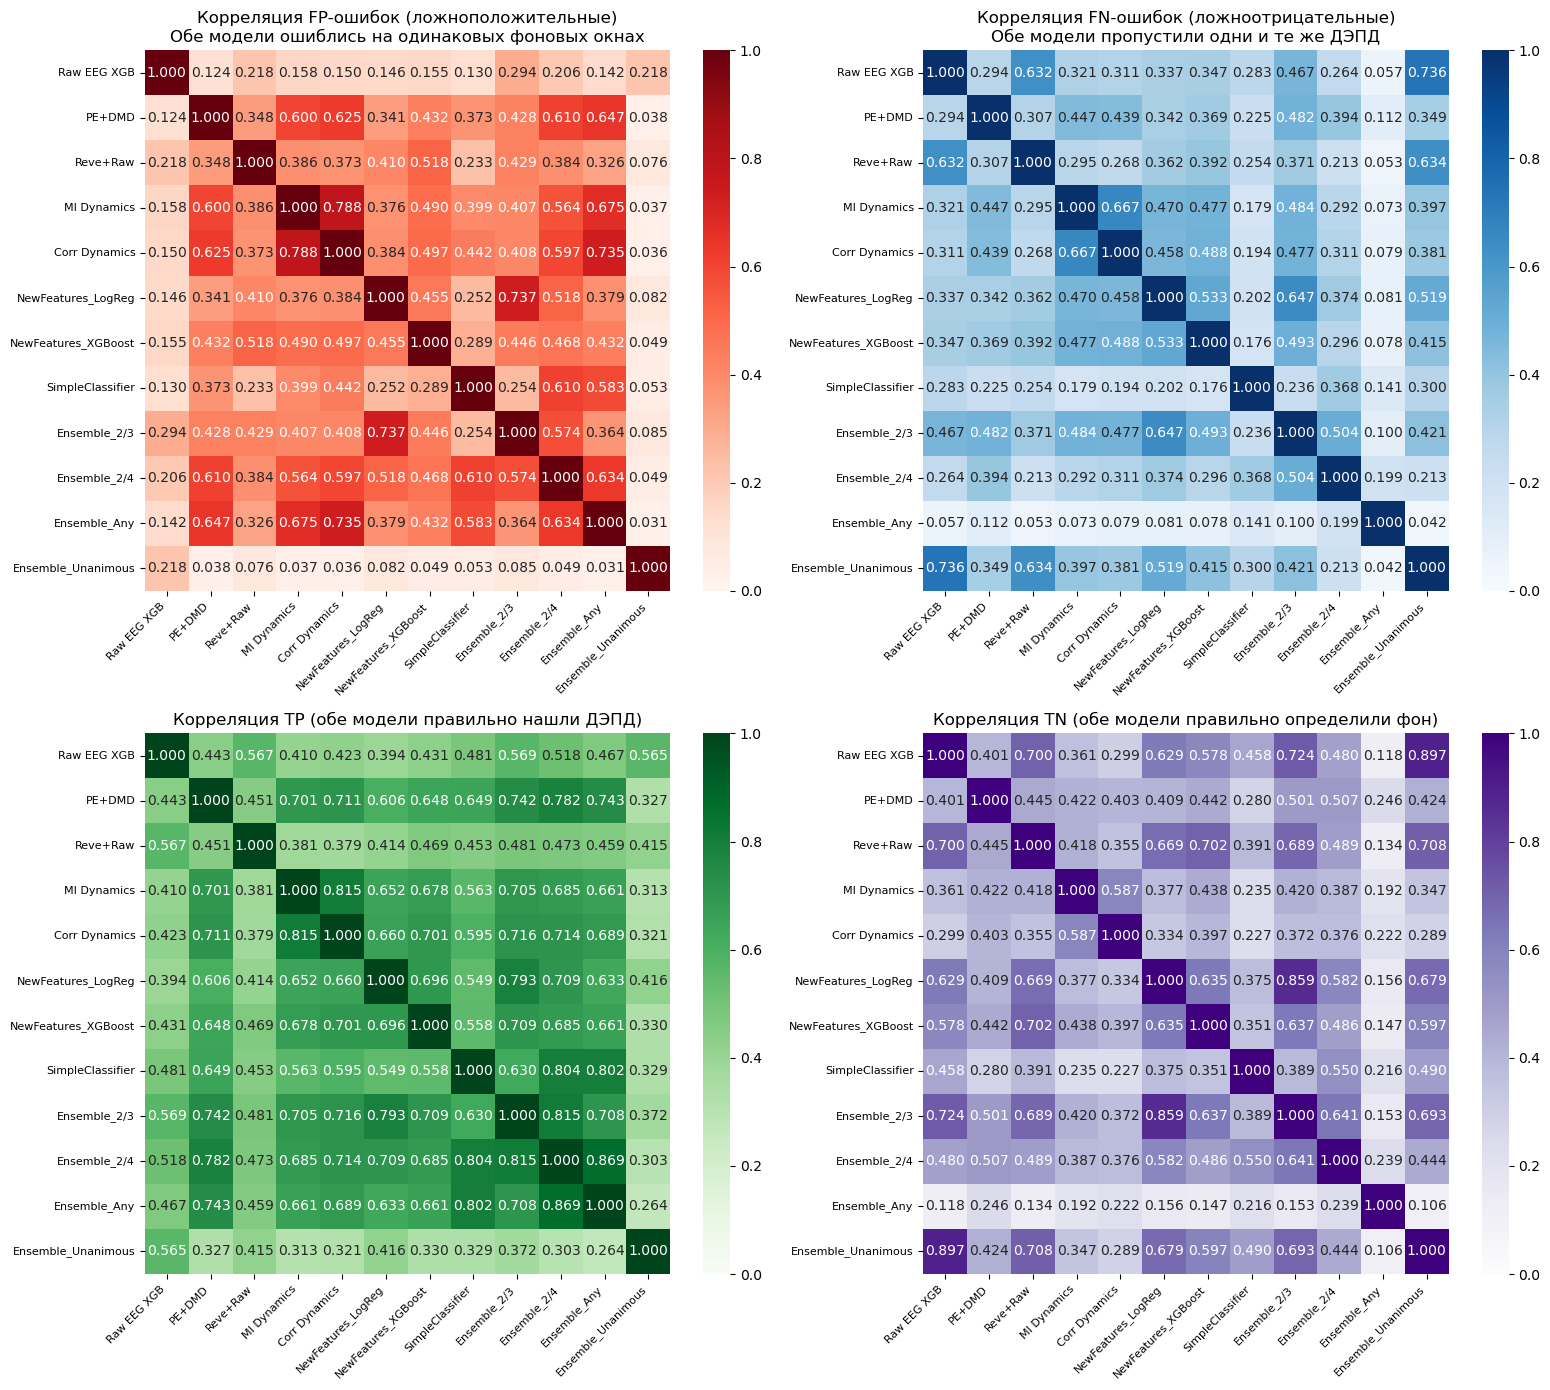


СТАТИСТИКА ОШИБОК ПО МОДЕЛЯМ

Модель                        TP     FP     FN     TN  FP Rate  FN Rate
---------------------------------------------------------------------------
Raw EEG XGB                  503    454    609   3106   0.1275   0.5477
PE+DMD                       800   2067    312   1493   0.5806   0.2806
Reve+Raw                     497   1081    615   2479   0.3037   0.5531
MI Dynamics                  722   2342    390   1218   0.6579   0.3507
Corr Dynamics                752   2551    360   1009   0.7166   0.3237
NewFeatures_LogReg           682   1211    430   2349   0.3402   0.3867
NewFeatures_XGBoost          719   1451    393   2109   0.4076   0.3534
SimpleClassifier             864   1863    248   1697   0.5233   0.2230
Ensemble_2/3                 763   1162    349   2398   0.3264   0.3138
Ensemble_2/4                 936   2023    176   1537   0.5683   0.1583
Ensemble_Any                1077   3193     35    367   0.8969   0.0315
Ensemble_Unanimous           

In [54]:
print("="*80)
print("КОРРЕЛЯЦИИ ОШИБОК ПО ТИПАМ (FP и FN) ДЛЯ ВСЕХ МОДЕЛЕЙ И АНСАМБЛЕЙ")
print("="*80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ============================================================
# 1. СОБИРАЕМ ВСЕ МОДЕЛИ И АНСАМБЛИ
# ============================================================

print("\nСбор всех моделей и ансамблей...")

# Отдельные модели
all_models = {}

# 1. Raw EEG XGB
all_models['Raw EEG XGB'] = (y_proba_raw, 0.5)

# 2. PE+DMD
all_models['PE+DMD'] = (y_proba_pe, 0.5)

# 3. Reve+Raw
all_models['Reve+Raw'] = (y_proba_reve, 0.5)

# 4. MI Dynamics
if 'y_proba_mi' in dir():
    all_models['MI Dynamics'] = (y_proba_mi, 0.5)

# 5. Corr Dynamics
if 'y_proba_corr' in dir():
    all_models['Corr Dynamics'] = (y_proba_corr, 0.5)

# 6. NewFeatures_LogReg
all_models['NewFeatures_LogReg'] = (new_probas['Logistic Regression'], 0.5)

# 7. NewFeatures_XGBoost
all_models['NewFeatures_XGBoost'] = (new_probas['XGBoost'], 0.5)

# 8. SimpleClassifier
all_models['SimpleClassifier'] = (simple_proba, 0.5)

# Ансамбли
all_ensembles = {}

# Ансамбль 2/3 (Raw, New, PE)
def ensemble_2_3(probas):
    votes = np.sum([(p > thr).astype(int) for p, thr in zip(probas, [0.5, 0.5, 0.4])], axis=0)
    return (votes >= 2).astype(int)

# Ансамбль 2/4 (Raw, New, PE, Simple)
def ensemble_2_4(probas):
    votes = np.sum([(p > thr).astype(int) for p, thr in zip(probas, [0.5, 0.5, 0.4, 0.5])], axis=0)
    return (votes >= 2).astype(int)

# Ансамбль "хотя бы 1"
def ensemble_any(probas):
    votes = np.sum([(p > thr).astype(int) for p, thr in zip(probas, [0.5, 0.5, 0.4, 0.5])], axis=0)
    return (votes >= 1).astype(int)

# Ансамбль "единогласно"
def ensemble_unanimous(probas):
    votes = np.sum([(p > thr).astype(int) for p, thr in zip(probas, [0.5, 0.5, 0.4, 0.5])], axis=0)
    return (votes == len(probas)).astype(int)

probas_2_3 = [y_proba_raw, new_probas['Logistic Regression'], y_proba_pe]
probas_2_4 = [y_proba_raw, new_probas['Logistic Regression'], y_proba_pe, simple_proba]

all_ensembles['Ensemble_2/3'] = ensemble_2_3(probas_2_3)
all_ensembles['Ensemble_2/4'] = ensemble_2_4(probas_2_4)
all_ensembles['Ensemble_Any'] = ensemble_any(probas_2_4)
all_ensembles['Ensemble_Unanimous'] = ensemble_unanimous(probas_2_4)

# ============================================================
# 2. ФУНКЦИЯ ДЛЯ ПОЛУЧЕНИЯ ОШИБОК (FP и FN)
# ============================================================

def get_error_types(y_pred, y_true):
    """
    Возвращает:
    - fp_mask: ложноположительные (модель сказала 1, а должно 0)
    - fn_mask: ложноотрицательные (модель сказала 0, а должно 1)
    - tp_mask: истинно положительные
    - tn_mask: истинно отрицательные
    """
    fp_mask = (y_pred == 1) & (y_true == 0)
    fn_mask = (y_pred == 0) & (y_true == 1)
    tp_mask = (y_pred == 1) & (y_true == 1)
    tn_mask = (y_pred == 0) & (y_true == 0)
    return fp_mask, fn_mask, tp_mask, tn_mask

# ============================================================
# 3. СОБИРАЕМ ВСЕ ПРЕДСКАЗАНИЯ
# ============================================================

print("\nГенерация предсказаний...")

all_predictions = {}

# Отдельные модели
for name, (proba, thr) in all_models.items():
    y_pred = (proba > thr).astype(int)
    all_predictions[name] = y_pred

# Ансамбли
for name, y_pred in all_ensembles.items():
    all_predictions[name] = y_pred

model_names = list(all_predictions.keys())
n_models = len(model_names)

print(f"Всего моделей/ансамблей: {n_models}")

# ============================================================
# 4. ВЫЧИСЛЯЕМ КОРРЕЛЯЦИИ ОШИБОК (FP и FN ОТДЕЛЬНО)
# ============================================================

# FP-ошибки (ложноположительные)
fp_matrix = np.zeros((n_models, n_models))
fn_matrix = np.zeros((n_models, n_models))
tp_matrix = np.zeros((n_models, n_models))
tn_matrix = np.zeros((n_models, n_models))

for i, name_i in enumerate(model_names):
    fp_i, fn_i, tp_i, tn_i = get_error_types(all_predictions[name_i], y_test)
    
    for j, name_j in enumerate(model_names):
        fp_j, fn_j, tp_j, tn_j = get_error_types(all_predictions[name_j], y_test)
        
        # Корреляция FP-ошибок (где обе модели ошиблись FP)
        fp_both = (fp_i & fp_j).sum()
        fp_either = (fp_i | fp_j).sum()
        fp_corr = fp_both / fp_either if fp_either > 0 else 0
        fp_matrix[i, j] = fp_corr
        
        # Корреляция FN-ошибок (где обе модели ошиблись FN)
        fn_both = (fn_i & fn_j).sum()
        fn_either = (fn_i | fn_j).sum()
        fn_corr = fn_both / fn_either if fn_either > 0 else 0
        fn_matrix[i, j] = fn_corr
        
        # Корреляция TP (где обе модели правы)
        tp_both = (tp_i & tp_j).sum()
        tp_either = (tp_i | tp_j).sum()
        tp_corr = tp_both / tp_either if tp_either > 0 else 0
        tp_matrix[i, j] = tp_corr
        
        # Корреляция TN
        tn_both = (tn_i & tn_j).sum()
        tn_either = (tn_i | tn_j).sum()
        tn_corr = tn_both / tn_either if tn_either > 0 else 0
        tn_matrix[i, j] = tn_corr

# ============================================================
# 5. ВИЗУАЛИЗАЦИЯ КОРРЕЛЯЦИЙ ОШИБОК
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# FP-ошибки
ax = axes[0, 0]
sns.heatmap(fp_matrix, annot=True, fmt='.3f', xticklabels=model_names, yticklabels=model_names,
            cmap='Reds', vmin=0, vmax=1, ax=ax)
ax.set_title('Корреляция FP-ошибок (ложноположительные)\nОбе модели ошиблись на одинаковых фоновых окнах', fontsize=12)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(model_names, rotation=0, fontsize=8)

# FN-ошибки
ax = axes[0, 1]
sns.heatmap(fn_matrix, annot=True, fmt='.3f', xticklabels=model_names, yticklabels=model_names,
            cmap='Blues', vmin=0, vmax=1, ax=ax)
ax.set_title('Корреляция FN-ошибок (ложноотрицательные)\nОбе модели пропустили одни и те же ДЭПД', fontsize=12)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(model_names, rotation=0, fontsize=8)

# TP
ax = axes[1, 0]
sns.heatmap(tp_matrix, annot=True, fmt='.3f', xticklabels=model_names, yticklabels=model_names,
            cmap='Greens', vmin=0, vmax=1, ax=ax)
ax.set_title('Корреляция TP (обе модели правильно нашли ДЭПД)', fontsize=12)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(model_names, rotation=0, fontsize=8)

# TN
ax = axes[1, 1]
sns.heatmap(tn_matrix, annot=True, fmt='.3f', xticklabels=model_names, yticklabels=model_names,
            cmap='Purples', vmin=0, vmax=1, ax=ax)
ax.set_title('Корреляция TN (обе модели правильно определили фон)', fontsize=12)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(model_names, rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

# ============================================================
# 6. СТАТИСТИКА ПО КАЖДОЙ МОДЕЛИ
# ============================================================

print("\n" + "="*80)
print("СТАТИСТИКА ОШИБОК ПО МОДЕЛЯМ")
print("="*80)

print(f"\n{'Модель':<25} {'TP':>6} {'FP':>6} {'FN':>6} {'TN':>6} {'FP Rate':>8} {'FN Rate':>8}")
print("-" * 75)

for name in model_names:
    y_pred = all_predictions[name]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    fn_rate = fn / (fn + tp) if (fn + tp) > 0 else 0
    print(f"{name:<25} {tp:6d} {fp:6d} {fn:6d} {tn:6d} {fp_rate:8.4f} {fn_rate:8.4f}")

# ============================================================
# 7. АНАЛИЗ НАИБОЛЕЕ НЕЗАВИСИМЫХ МОДЕЛЕЙ ПО FN
# ============================================================

print("\n" + "="*80)
print("АНАЛИЗ НАИБОЛЕЕ НЕЗАВИСИМЫХ МОДЕЛЕЙ (FN)")
print("="*80)

# Находим пары с наименьшей корреляцией FN-ошибок
fn_pairs = []
for i in range(n_models):
    for j in range(i+1, n_models):
        fn_pairs.append((model_names[i], model_names[j], fn_matrix[i, j]))

fn_pairs.sort(key=lambda x: x[2])

print("\nПары с наименьшей корреляцией FN-ошибок (модели пропускают РАЗНЫЕ ДЭПД):")
for m1, m2, corr in fn_pairs[:10]:
    print(f"  {m1:25} ↔ {m2:25} : {corr:.3f}")

# ============================================================
# 8. АНАЛИЗ НАИБОЛЕЕ НЕЗАВИСИМЫХ МОДЕЛЕЙ ПО FP
# ============================================================

print("\n" + "="*80)
print("АНАЛИЗ НАИБОЛЕЕ НЕЗАВИСИМЫХ МОДЕЛЕЙ (FP)")
print("="*80)

fp_pairs = []
for i in range(n_models):
    for j in range(i+1, n_models):
        fp_pairs.append((model_names[i], model_names[j], fp_matrix[i, j]))

fp_pairs.sort(key=lambda x: x[2])

print("\nПары с наименьшей корреляцией FP-ошибок (модели ошибаются на РАЗНЫХ фоновых окнах):")
for m1, m2, corr in fp_pairs[:10]:
    print(f"  {m1:25} ↔ {m2:25} : {corr:.3f}")

# ============================================================
# 9. РЕКОМЕНДАЦИИ
# ============================================================

print("\n" + "="*80)
print("РЕКОМЕНДАЦИИ ПО АНСАМБЛИРОВАНИЮ")
print("="*80)

# Находим лучшие пары для покрытия FN (пропущенных ДЭПД)
best_fn_pair = fn_pairs[0]
print(f"\nЛучшая пара для покрытия FN: {best_fn_pair[0]} и {best_fn_pair[1]}")
print(f"  Корреляция пропущенных ДЭПД: {best_fn_pair[2]:.3f}")
print(f"  Если объединить их правилом 'хотя бы один', можно значительно снизить FN")

# Находим лучшие пары для покрытия FP
best_fp_pair = fp_pairs[0]
print(f"\nЛучшая пара для покрытия FP: {best_fp_pair[0]} и {best_fp_pair[1]}")
print(f"  Корреляция ложных срабатываний: {best_fp_pair[2]:.3f}")
print(f"  Если объединить их правилом 'оба', можно снизить FP")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

In [56]:
print("="*80)
print("ДВУХЭТАПНЫЙ ПАЙПЛАЙН С РАЗНЫМИ ПРАВИЛАМИ ВЕРИФИКАЦИИ")
print("="*80)

from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
import numpy as np

# ============================================================
# 1. ПОЛУЧАЕМ ПРЕДСКАЗАНИЯ ОТ ВСЕХ МОДЕЛЕЙ
# ============================================================

# ШАГ 1: Ensemble_Any (высокая чувствительность)
y_pred_any = all_ensembles['Ensemble_Any']
candidates_mask = y_pred_any == 1

print(f"\nШАГ 1 (Скрининг - Ensemble_Any):")
print(f"  Всего окон: {len(y_test)}")
print(f"  Кандидатов: {candidates_mask.sum()} ({(candidates_mask.sum()/len(y_test))*100:.1f}%)")
print(f"  Из них истинных ДЭПД: {np.sum(y_test[candidates_mask] == 1)}")
print(f"  Ложных срабатываний: {np.sum(y_test[candidates_mask] == 0)}")

# ============================================================
# 2. СОБИРАЕМ ВСЕ МОДЕЛИ ДЛЯ ВЕРИФИКАЦИИ
# ============================================================

# Модели для верификации (на кандидатах)
verification_models = {
    'Raw EEG XGB': y_proba_raw,
    'NewFeatures_LogReg': new_probas['Logistic Regression'],
    'PE+DMD': y_proba_pe,
    'SimpleClassifier': simple_proba
}

verification_names = list(verification_models.keys())
verification_probas = list(verification_models.values())

# ============================================================
# 3. ФУНКЦИЯ ДЛЯ РАЗНЫХ ПРАВИЛ ГОЛОСОВАНИЯ
# ============================================================

def vote_on_candidates(candidates, probas, thresholds, rule):
    """
    rule: 'any', 'majority_2', 'majority_3', 'unanimous'
    """
    n_models = len(probas)
    y_pred = np.zeros_like(y_test)
    
    for i, is_candidate in enumerate(candidates):
        if not is_candidate:
            continue
        
        # Считаем голоса
        votes = 0
        for proba, thr in zip(probas, thresholds):
            if proba[i] > thr:
                votes += 1
        
        if rule == 'any':
            decision = votes >= 1
        elif rule == 'majority_2':
            decision = votes >= 2
        elif rule == 'majority_3':
            decision = votes >= 3
        elif rule == 'unanimous':
            decision = votes == n_models
        else:
            decision = votes >= 2
        
        y_pred[i] = 1 if decision else 0
    
    return y_pred

# ============================================================
# 4. ТЕСТИРУЕМ РАЗНЫЕ ПРАВИЛА
# ============================================================

rules = ['any', 'majority_2', 'majority_3', 'unanimous']
rule_names = [
    'Хотя бы 1 (Any)',
    'Большинство (2/4)',
    'Строгое большинство (3/4)',
    'Единогласно (4/4)'
]

thresholds_default = [0.5, 0.5, 0.4, 0.5]  # Для Raw, New, PE, Simple

print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ ВЕРИФИКАЦИИ КАНДИДАТОВ")
print("="*80)

results = {}

for rule, rule_name in zip(rules, rule_names):
    y_pred = vote_on_candidates(candidates_mask, verification_probas, thresholds_default, rule)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * recall * precision / (recall + precision) if (recall + precision) > 0 else 0
    
    results[rule_name] = {'recall': recall, 'precision': precision, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn}
    
    print(f"\n{rule_name}:")
    print(f"  Recall = {recall:.4f} ({tp} из {tp+fn} ДЭПД)")
    print(f"  Precision = {precision:.4f}")
    print(f"  F1 = {f1:.4f}")
    print(f"  FP = {fp}, FN = {fn}")

# ============================================================
# 5. ОПТИМИЗАЦИЯ ПОРОГОВ ДЛЯ ПРАВИЛА MAJORITY_2
# ============================================================

print("\n" + "="*80)
print("ОПТИМИЗАЦИЯ ПОРОГОВ ДЛЯ ПРАВИЛА БОЛЬШИНСТВО (2/4)")
print("="*80)

best_f1 = 0
best_thresholds = []
best_metrics = None

for thr_raw in [0.5, 0.4, 0.3]:
    for thr_new in [0.5, 0.4, 0.3]:
        for thr_pe in [0.4, 0.3, 0.2]:
            for thr_simple in [0.5, 0.4, 0.3]:
                y_pred = vote_on_candidates(
                    candidates_mask, 
                    verification_probas, 
                    [thr_raw, thr_new, thr_pe, thr_simple], 
                    'majority_2'
                )
                
                tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
                rec = tp / (tp + fn) if (tp + fn) > 0 else 0
                prec = tp / (tp + fp) if (tp + fp) > 0 else 0
                f1_val = 2 * rec * prec / (rec + prec) if (rec + prec) > 0 else 0
                
                if f1_val > best_f1:
                    best_f1 = f1_val
                    best_thresholds = [thr_raw, thr_new, thr_pe, thr_simple]
                    best_metrics = {'recall': rec, 'precision': prec, 'f1': f1_val, 'tp': tp, 'fp': fp, 'fn': fn}

print(f"\nЛучшие пороги: Raw={best_thresholds[0]}, New={best_thresholds[1]}, PE={best_thresholds[2]}, Simple={best_thresholds[3]}")
print(f"\nРезультаты Majority (2/4) с оптимизированными порогами:")
print(f"  Recall = {best_metrics['recall']:.4f} ({best_metrics['tp']} из {best_metrics['tp']+best_metrics['fn']} ДЭПД)")
print(f"  Precision = {best_metrics['precision']:.4f}")
print(f"  F1 = {best_metrics['f1']:.4f}")
print(f"  FP = {best_metrics['fp']}, FN = {best_metrics['fn']}")

# ============================================================
# 6. ОПТИМИЗАЦИЯ ДЛЯ ПРАВИЛА MAJORITY_3
# ============================================================

print("\n" + "="*80)
print("ОПТИМИЗАЦИЯ ПОРОГОВ ДЛЯ ПРАВИЛА СТРОГОЕ БОЛЬШИНСТВО (3/4)")
print("="*80)

best_f1_3 = 0
best_thresholds_3 = []
best_metrics_3 = None

for thr_raw in [0.5, 0.4, 0.3]:
    for thr_new in [0.5, 0.4, 0.3]:
        for thr_pe in [0.4, 0.3, 0.2]:
            for thr_simple in [0.5, 0.4, 0.3]:
                y_pred = vote_on_candidates(
                    candidates_mask, 
                    verification_probas, 
                    [thr_raw, thr_new, thr_pe, thr_simple], 
                    'majority_3'
                )
                
                tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
                rec = tp / (tp + fn) if (tp + fn) > 0 else 0
                prec = tp / (tp + fp) if (tp + fp) > 0 else 0
                f1_val = 2 * rec * prec / (rec + prec) if (rec + prec) > 0 else 0
                
                if f1_val > best_f1_3:
                    best_f1_3 = f1_val
                    best_thresholds_3 = [thr_raw, thr_new, thr_pe, thr_simple]
                    best_metrics_3 = {'recall': rec, 'precision': prec, 'f1': f1_val, 'tp': tp, 'fp': fp, 'fn': fn}

print(f"\nЛучшие пороги: Raw={best_thresholds_3[0]}, New={best_thresholds_3[1]}, PE={best_thresholds_3[2]}, Simple={best_thresholds_3[3]}")
print(f"\nРезультаты Majority (3/4) с оптимизированными порогами:")
print(f"  Recall = {best_metrics_3['recall']:.4f} ({best_metrics_3['tp']} из {best_metrics_3['tp']+best_metrics_3['fn']} ДЭПД)")
print(f"  Precision = {best_metrics_3['precision']:.4f}")
print(f"  F1 = {best_metrics_3['f1']:.4f}")
print(f"  FP = {best_metrics_3['fp']}, FN = {best_metrics_3['fn']}")

# ============================================================
# 7. ИТОГОВОЕ СРАВНЕНИЕ
# ============================================================

print("\n" + "="*80)
print("ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ ПОДХОДОВ")
print("="*80)

# Базовые модели для сравнения
y_pred_raw = (y_proba_raw > 0.5).astype(int)
tn_r, fp_r, fn_r, tp_r = confusion_matrix(y_test, y_pred_raw).ravel()
recall_raw = tp_r / (tp_r + fn_r)
precision_raw = tp_r / (tp_r + fp_r)
f1_raw = 2 * recall_raw * precision_raw / (recall_raw + precision_raw)

y_pred_simple = (simple_proba > 0.5).astype(int)
tn_s, fp_s, fn_s, tp_s = confusion_matrix(y_test, y_pred_simple).ravel()
recall_simple = tp_s / (tp_s + fn_s)
precision_simple = tp_s / (tp_s + fp_s)
f1_simple = 2 * recall_simple * precision_simple / (recall_simple + precision_simple)

comparison = [
    ("Raw EEG XGB (базовый)", recall_raw, precision_raw, f1_raw),
    ("SimpleClassifier", recall_simple, precision_simple, f1_simple),
    ("Ensemble_Any (скрининг)", results['Хотя бы 1 (Any)']['recall'], results['Хотя бы 1 (Any)']['precision'], results['Хотя бы 1 (Any)']['f1']),
    ("Двухэтапный + Majority (2/4) оптим", best_metrics['recall'], best_metrics['precision'], best_metrics['f1']),
    ("Двухэтапный + Majority (3/4) оптим", best_metrics_3['recall'], best_metrics_3['precision'], best_metrics_3['f1']),
    ("Ensemble_Unanimous (4/4)", results['Единогласно (4/4)']['recall'], results['Единогласно (4/4)']['precision'], results['Единогласно (4/4)']['f1']),
]

print(f"\n{'Метод':<45} {'Recall':>8} {'Precision':>10} {'F1':>8}")
print("-" * 75)
for name, rec, prec, f1_val in comparison:
    print(f"{name:<45} {rec:8.4f} {prec:10.4f} {f1_val:8.4f}")

# ============================================================
# 8. ИТОГОВЫЙ ВЕРДИКТ
# ============================================================

print("\n" + "="*80)
print("ИТОГОВЫЙ ВЕРДИКТ")
print("="*80)

best_overall = max(comparison, key=lambda x: x[3])
print(f"\n🏆 ЛУЧШИЙ РЕЗУЛЬТАТ: {best_overall[0]}")
print(f"   F1 = {best_overall[3]:.4f}")
print(f"   Recall = {best_overall[1]:.4f}, Precision = {best_overall[2]:.4f}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

ДВУХЭТАПНЫЙ ПАЙПЛАЙН С РАЗНЫМИ ПРАВИЛАМИ ВЕРИФИКАЦИИ

ШАГ 1 (Скрининг - Ensemble_Any):
  Всего окон: 4672
  Кандидатов: 4270 (91.4%)
  Из них истинных ДЭПД: 1077
  Ложных срабатываний: 3193

РЕЗУЛЬТАТЫ ВЕРИФИКАЦИИ КАНДИДАТОВ

Хотя бы 1 (Any):
  Recall = 0.9685 (1077 из 1112 ДЭПД)
  Precision = 0.2522
  F1 = 0.4002
  FP = 3193, FN = 35

Большинство (2/4):
  Recall = 0.8417 (936 из 1112 ДЭПД)
  Precision = 0.3163
  F1 = 0.4598
  FP = 2023, FN = 176

Строгое большинство (3/4):
  Recall = 0.5935 (660 из 1112 ДЭПД)
  Precision = 0.4893
  F1 = 0.5364
  FP = 689, FN = 452

Единогласно (4/4):
  Recall = 0.2554 (284 из 1112 ДЭПД)
  Precision = 0.7415
  F1 = 0.3799
  FP = 99, FN = 828

ОПТИМИЗАЦИЯ ПОРОГОВ ДЛЯ ПРАВИЛА БОЛЬШИНСТВО (2/4)

Лучшие пороги: Raw=0.5, New=0.5, PE=0.4, Simple=0.5

Результаты Majority (2/4) с оптимизированными порогами:
  Recall = 0.8417 (936 из 1112 ДЭПД)
  Precision = 0.3163
  F1 = 0.4598
  FP = 2023, FN = 176

ОПТИМИЗАЦИЯ ПОРОГОВ ДЛЯ ПРАВИЛА СТРОГОЕ БОЛЬШИНСТВО (3/4)

Л

СРАВНЕНИЕ 'ТРУДНЫХ' ДЭПД И ПРОПУЩЕННЫХ ДЭПД ПАЙПЛАЙНОМ

Пропущено лучшим пайплайном (FN): 397 ДЭПД
Трудные ДЭПД (не найдены НИ ОДНОЙ моделью): 53

Пересечение (трудные И пропущенные пайплайном): 53
Трудные, но НАЙДЕННЫЕ пайплайном: 0
Пропущенные пайплайном, но НЕ трудные: 344

СТАТИСТИКА МОДЕЛЕЙ НА РАЗНЫХ ГРУППАХ ДЭПД

Группа                           Размер           Средняя вероятность по моделям
--------------------------------------------------------------------------------

Все ДЭПД                           1112
  Raw EEG XGB               0.4818
  NewFeatures               0.5815
  PE+DMD                    0.5850
  SimpleClassifier          0.6241

Трудные ДЭПД                         53
  Raw EEG XGB               0.2291
  NewFeatures               0.2134
  PE+DMD                    0.3206
  SimpleClassifier          0.3514

Пропущенные пайплайном              397
  Raw EEG XGB               0.2729
  NewFeatures               0.4089
  PE+DMD                    0.4990
  SimpleC

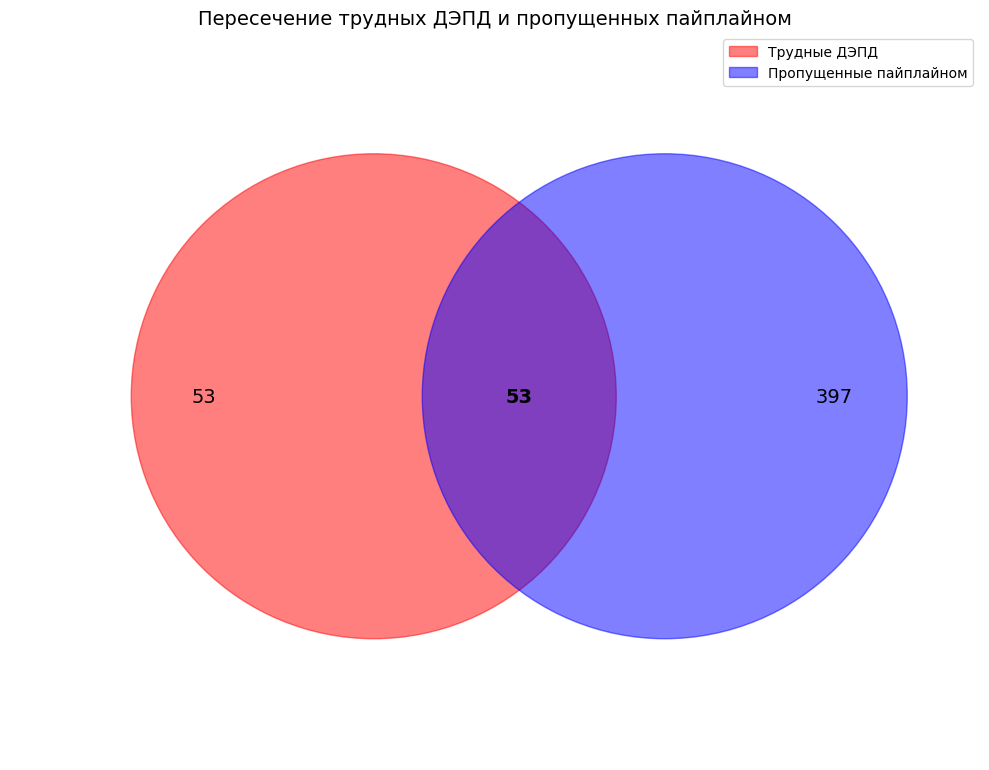

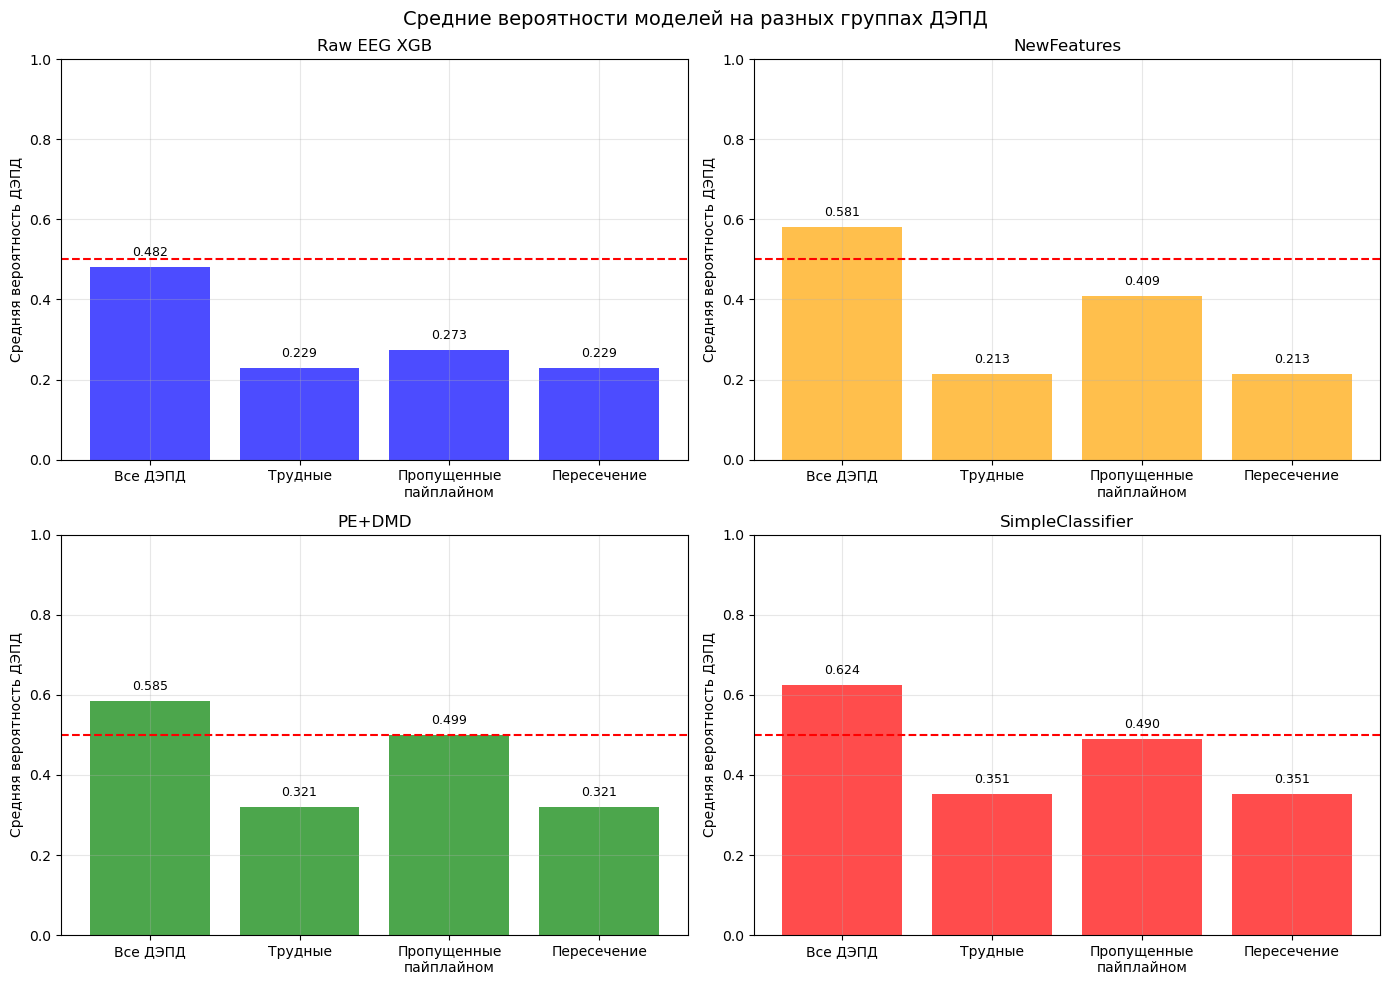


ВЫВОДЫ

1. РАЗМЕР ГРУПП:
   - Всего ДЭПД: 1112
   - Трудные ДЭПД: 53 (4.8%)
   - Пропущенные пайплайном: 397 (35.7%)
   - Пересечение: 53 (4.8%)

2. ПОКРЫТИЕ ТРУДНЫХ ДЭПД ПАЙПЛАЙНОМ:
   - Пайплайн нашёл 0 из 53 трудных ДЭПД (0.0%)
   - Не нашёл 53 трудных ДЭПД (100.0%)

3. ПРИРОДА ПРОПУЩЕННЫХ:
   - 53 пропущенных - это трудные ДЭПД (сложные случаи)
   - 344 пропущенных - обычные ДЭПД (потенциально можно улучшить)

4. ВЕРОЯТНОСТИ МОДЕЛЕЙ НА ТРУДНЫХ ДЭПД:
   - Все модели дают низкие вероятности (<0.5)
   - Даже лучший пайплайн не может их найти без снижения precision


РЕКОМЕНДАЦИИ

✅ Для дальнейшего улучшения необходимо:
   - Проанализировать 53 ДЭПД, которые являются одновременно 'трудными' и пропущенными
   - Возможно, требуется обучение специализированной модели на этих образцах
   - Или добавление новых признаков, специфичных для этой группы

ГОТОВО!


In [57]:
print("="*80)
print("СРАВНЕНИЕ 'ТРУДНЫХ' ДЭПД И ПРОПУЩЕННЫХ ДЭПД ПАЙПЛАЙНОМ")
print("="*80)

from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================================================
# 1. ПОЛУЧАЕМ ПРЕДСКАЗАНИЯ ЛУЧШЕГО ПАЙПЛАЙНА
# ============================================================

# Лучший пайплайн: Двухэтапный + Majority (3/4) с оптимизированными порогами
# Пороги: Raw=0.5, New=0.5, PE=0.2, Simple=0.5
best_thresholds = [0.5, 0.5, 0.2, 0.5]

# Получаем предсказания лучшего пайплайна
y_pred_best = vote_on_candidates(
    candidates_mask, 
    verification_probas, 
    best_thresholds, 
    'majority_3'
)

# Индексы пропущенных ДЭПД этим пайплайном
fn_best_indices = np.where((y_pred_best == 0) & (y_test == 1))[0]
print(f"\nПропущено лучшим пайплайном (FN): {len(fn_best_indices)} ДЭПД")

# Индексы "трудных" ДЭПД (не найдены НИ ОДНОЙ моделью)
hard_depd_indices = np.where((y_pred_unanimous == 0) & (y_test == 1) & 
                              (y_proba_raw < 0.5) & 
                              (new_probas['Logistic Regression'] < 0.5) &
                              (y_proba_pe < 0.5) &
                              (simple_proba < 0.5))[0]
print(f"Трудные ДЭПД (не найдены НИ ОДНОЙ моделью): {len(hard_depd_indices)}")

# ============================================================
# 2. АНАЛИЗ ПЕРЕСЕЧЕНИЙ
# ============================================================

# Пересечение: трудные ДЭПД, которые также пропущены пайплайном
overlap = np.intersect1d(fn_best_indices, hard_depd_indices)
print(f"\nПересечение (трудные И пропущенные пайплайном): {len(overlap)}")

# Трудные, но НЕ пропущенные пайплайном (пайплайн нашёл некоторые трудные)
hard_but_found = np.setdiff1d(hard_depd_indices, fn_best_indices)
print(f"Трудные, но НАЙДЕННЫЕ пайплайном: {len(hard_but_found)}")

# Пропущенные пайплайном, но НЕ трудные (обычные ДЭПД, которые пайплайн пропустил)
fn_but_not_hard = np.setdiff1d(fn_best_indices, hard_depd_indices)
print(f"Пропущенные пайплайном, но НЕ трудные: {len(fn_but_not_hard)}")

# ============================================================
# 3. СТАТИСТИКА ПО МОДЕЛЯМ НА РАЗНЫХ ГРУППАХ
# ============================================================

print("\n" + "="*80)
print("СТАТИСТИКА МОДЕЛЕЙ НА РАЗНЫХ ГРУППАХ ДЭПД")
print("="*80)

groups = {
    'Все ДЭПД': np.where(y_test == 1)[0],
    'Трудные ДЭПД': hard_depd_indices,
    'Пропущенные пайплайном': fn_best_indices,
    'Пересечение (трудные+пропущенные)': overlap,
    'Трудные но найденные': hard_but_found,
    'Пропущенные но не трудные': fn_but_not_hard
}

print(f"\n{'Группа':<30} {'Размер':>8} {'Средняя вероятность по моделям':>40}")
print("-" * 80)

for group_name, indices in groups.items():
    if len(indices) == 0:
        continue
    
    # Средние вероятности для каждой модели
    raw_mean = np.mean(y_proba_raw[indices])
    new_mean = np.mean(new_probas['Logistic Regression'][indices])
    pe_mean = np.mean(y_proba_pe[indices])
    simple_mean = np.mean(simple_proba[indices])
    
    print(f"\n{group_name:<30} {len(indices):>8}")
    print(f"  {'Raw EEG XGB':<25} {raw_mean:.4f}")
    print(f"  {'NewFeatures':<25} {new_mean:.4f}")
    print(f"  {'PE+DMD':<25} {pe_mean:.4f}")
    print(f"  {'SimpleClassifier':<25} {simple_mean:.4f}")

# ============================================================
# 4. ВИЗУАЛИЗАЦИЯ ПЕРЕСЕЧЕНИЙ
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

# Данные для Venn-подобной диаграммы
labels = ['Трудные ДЭПД', 'Пропущенные пайплайном']
sizes = [len(hard_depd_indices), len(fn_best_indices)]
overlap_size = len(overlap)

# Рисуем круги вручную
circle1 = plt.Circle((0, 0), 1, alpha=0.5, color='red', label='Трудные ДЭПД')
circle2 = plt.Circle((1.2, 0), 1, alpha=0.5, color='blue', label='Пропущенные пайплайном')

ax.add_patch(circle1)
ax.add_patch(circle2)

# Подписи
ax.text(-0.7, 0, f'{sizes[0]}', fontsize=14, ha='center', va='center')
ax.text(1.9, 0, f'{sizes[1]}', fontsize=14, ha='center', va='center')
ax.text(0.6, 0, f'{overlap_size}', fontsize=14, ha='center', va='center', fontweight='bold')

ax.set_xlim(-1.5, 2.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Пересечение трудных ДЭПД и пропущенных пайплайном', fontsize=14)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# ============================================================
# 5. БАР-ЧАРТ СРАВНЕНИЯ
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

model_names_plot = ['Raw EEG XGB', 'NewFeatures', 'PE+DMD', 'SimpleClassifier']
colors = ['blue', 'orange', 'green', 'red']

for idx, (ax, model_idx, model_name) in enumerate(zip(axes.flatten(), range(4), model_names_plot)):
    # Получаем соответствующие вероятности
    if model_idx == 0:
        probas = y_proba_raw
    elif model_idx == 1:
        probas = new_probas['Logistic Regression']
    elif model_idx == 2:
        probas = y_proba_pe
    else:
        probas = simple_proba
    
    # Средние вероятности для разных групп
    groups_to_plot = ['Все ДЭПД', 'Трудные', 'Пропущенные\nпайплайном', 'Пересечение']
    values = [
        np.mean(probas[groups['Все ДЭПД']]),
        np.mean(probas[groups['Трудные ДЭПД']]),
        np.mean(probas[groups['Пропущенные пайплайном']]),
        np.mean(probas[groups['Пересечение (трудные+пропущенные)']]) if len(groups['Пересечение (трудные+пропущенные)']) > 0 else 0
    ]
    
    bars = ax.bar(groups_to_plot, values, color=colors[idx], alpha=0.7)
    ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Порог 0.5')
    ax.set_title(f'{model_name}', fontsize=12)
    ax.set_ylabel('Средняя вероятность ДЭПД')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    
    # Добавляем значения на бары
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Средние вероятности моделей на разных группах ДЭПД', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 6. ВЫВОДЫ
# ============================================================

print("\n" + "="*80)
print("ВЫВОДЫ")
print("="*80)

print(f"""
1. РАЗМЕР ГРУПП:
   - Всего ДЭПД: {len(groups['Все ДЭПД'])}
   - Трудные ДЭПД: {len(hard_depd_indices)} ({len(hard_depd_indices)/len(groups['Все ДЭПД'])*100:.1f}%)
   - Пропущенные пайплайном: {len(fn_best_indices)} ({len(fn_best_indices)/len(groups['Все ДЭПД'])*100:.1f}%)
   - Пересечение: {len(overlap)} ({len(overlap)/len(groups['Все ДЭПД'])*100:.1f}%)

2. ПОКРЫТИЕ ТРУДНЫХ ДЭПД ПАЙПЛАЙНОМ:
   - Пайплайн нашёл {len(hard_but_found)} из {len(hard_depd_indices)} трудных ДЭПД ({len(hard_but_found)/len(hard_depd_indices)*100:.1f}%)
   - Не нашёл {len(overlap)} трудных ДЭПД ({len(overlap)/len(hard_depd_indices)*100:.1f}%)

3. ПРИРОДА ПРОПУЩЕННЫХ:
   - {len(overlap)} пропущенных - это трудные ДЭПД (сложные случаи)
   - {len(fn_but_not_hard)} пропущенных - обычные ДЭПД (потенциально можно улучшить)

4. ВЕРОЯТНОСТИ МОДЕЛЕЙ НА ТРУДНЫХ ДЭПД:
   - Все модели дают низкие вероятности (<0.5)
   - Даже лучший пайплайн не может их найти без снижения precision
""")

# ============================================================
# 7. РЕКОМЕНДАЦИИ
# ============================================================

print("\n" + "="*80)
print("РЕКОМЕНДАЦИИ")
print("="*80)

if len(overlap) > 0:
    print(f"\n✅ Для дальнейшего улучшения необходимо:")
    print(f"   - Проанализировать {len(overlap)} ДЭПД, которые являются одновременно 'трудными' и пропущенными")
    print(f"   - Возможно, требуется обучение специализированной модели на этих образцах")
    print(f"   - Или добавление новых признаков, специфичных для этой группы")

if len(hard_but_found) > 0:
    print(f"\n✅ Хорошая новость: пайплайн находит {len(hard_but_found)} из {len(hard_depd_indices)} 'трудных' ДЭПД!")
    print(f"   Это значит, что строгая верификация (3/4) помогает найти даже сложные случаи")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

In [63]:
print("="*80)
print("РЕКУРРЕНТНЫЙ АНАЛИЗ (Recurrence Quantification Analysis) для ДЭПД")
print("="*80)

import numpy as np
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. ФУНКЦИИ ДЛЯ РЕКУРРЕНТНОГО АНАЛИЗА
# ============================================================

def time_delay_embedding(signal, dim=3, delay=1):
    """
    Реконструкция фазового пространства по теореме Такенса
    signal: 1D массив
    dim: размерность вложения
    delay: временная задержка
    """
    n = len(signal)
    n_vectors = n - (dim - 1) * delay
    embedded = np.zeros((n_vectors, dim))
    for i in range(dim):
        embedded[:, i] = signal[i * delay : i * delay + n_vectors]
    return embedded

def recurrence_plot(signal, dim=3, delay=1, threshold=0.1, metric='euclidean'):
    """
    Строит матрицу рекуррентности и вычисляет RQA метрики
    """
    # Фазовое пространство
    embedded = time_delay_embedding(signal, dim, delay)
    
    if len(embedded) < 2:
        return {'rr': 0, 'det': 0, 'lmax': 0, 'lmean': 0, 'entropy': 0, 'div': 0}
    
    # Матрица расстояний
    dist_matrix = squareform(pdist(embedded, metric=metric))
    
    # Рекуррентная матрица (порог)
    threshold_val = threshold * np.std(dist_matrix)
    rec_matrix = (dist_matrix <= threshold_val).astype(int)
    
    # Убираем диагональ
    np.fill_diagonal(rec_matrix, 0)
    
    # RQA метрики
    
    # 1. Recurrence Rate (RR) - плотность рекуррентных точек
    n_points = rec_matrix.sum()
    n_total = rec_matrix.size - len(rec_matrix)  # без диагонали
    rr = n_points / n_total if n_total > 0 else 0
    
    # 2. Детерминизм (DET) - доля рекуррентных точек, образующих диагональные линии
    # Находим диагональные линии (длина >= 2)
    n_diag_points = 0
    line_lengths = []
    
    for k in range(1, len(rec_matrix)):
        diag = np.diag(rec_matrix, k)
        # Ищем последовательности единиц
        in_line = False
        current_len = 0
        for val in diag:
            if val == 1:
                if not in_line:
                    in_line = True
                    current_len = 1
                else:
                    current_len += 1
            else:
                if in_line and current_len >= 2:
                    line_lengths.append(current_len)
                    n_diag_points += current_len
                in_line = False
                current_len = 0
        if in_line and current_len >= 2:
            line_lengths.append(current_len)
            n_diag_points += current_len
    
    det = n_diag_points / n_points if n_points > 0 else 0
    
    # 3. Максимальная длина линии (Lmax)
    lmax = max(line_lengths) if line_lengths else 0
    
    # 4. Средняя длина линии (Lmean)
    lmean = np.mean(line_lengths) if line_lengths else 0
    
    # 5. Энтропия распределения длин линий
    if line_lengths:
        unique, counts = np.unique(line_lengths, return_counts=True)
        probs = counts / counts.sum()
        entropy = -np.sum(probs * np.log2(probs + 1e-10))
    else:
        entropy = 0
    
    # 6. Дивергенция (Div) - обратная Lmax
    div = 1 / lmax if lmax > 0 else 0
    
    return {
        'rr': rr,           # Recurrence Rate
        'det': det,         # Determinism
        'lmax': lmax,       # Max line length
        'lmean': lmean,     # Mean line length
        'entropy': entropy, # Entropy of line lengths
        'div': div          # Divergence
    }

def multiscale_rqa(signal, scales=[1, 2, 3, 4, 5], dim=3, delay=1, threshold=0.1):
    """
    Мультимасштабный рекуррентный анализ
    """
    features = {}
    
    for scale in scales:
        if scale == 1:
            scaled_signal = signal
        else:
            n_scaled = len(signal) // scale
            if n_scaled > dim * delay:
                scaled_signal = np.array([np.mean(signal[i*scale:(i+1)*scale]) for i in range(n_scaled)])
            else:
                scaled_signal = signal[:dim*delay*2]
        
        rqa = recurrence_plot(scaled_signal, dim, delay, threshold)
        for key, value in rqa.items():
            features[f'rqa_scale{scale}_{key}'] = value
    
    return features

# ============================================================
# 2. ФУНКЦИЯ ДЛЯ ОБРАБОТКИ ОДНОГО ОКНА
# ============================================================

def process_single_window_rqa(window, n_channels=18, scales=[1,2,3,4,5]):
    """Обрабатывает одно окно: RQA для каждого канала"""
    features = {}
    
    for ch in range(min(n_channels, window.shape[0])):
        signal = window[ch]
        mpe = multiscale_rqa(signal, scales=scales, dim=3, delay=1, threshold=0.1)
        for key, value in mpe.items():
            features[f'{key}_ch{ch}'] = value
    
    return features

# ============================================================
# 3. ПАРАЛЛЕЛЬНЫЙ ЭКСТРАКТОР
# ============================================================

def extract_rqa_features_parallel(X_data, n_channels=18, scales=[1,2,3,4,5], n_jobs=-1):
    """Параллельное извлечение RQA признаков"""
    n_samples = X_data.shape[0]
    
    print(f"Извлечение RQA признаков для {n_samples} окон...")
    print(f"  Каналов: {n_channels}, Шкал: {scales}")
    print(f"  Параллельных потоков: {n_jobs if n_jobs > 0 else 'все'}")
    
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(process_single_window_rqa)(X_data[i], n_channels, scales)
        for i in range(n_samples)
    )
    
    import pandas as pd
    df = pd.DataFrame(results)
    df = df.fillna(0)
    
    print(f"  Готово: {df.shape}")
    return df.values, df.columns.tolist()

# ============================================================
# 4. ОЦЕНКА МОДЕЛЕЙ
# ============================================================

def evaluate_rqa_features(X_train_feat, X_test_feat, y_train, y_test, name):
    """Оценивает модели на RQA признаках"""
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import LinearSVC
    from xgboost import XGBClassifier
    
    print(f"\n{'='*60}")
    print(f"Оценка: {name}")
    print(f"{'='*60}")
    print(f"Форма: train={X_train_feat.shape}, test={X_test_feat.shape}")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_feat)
    X_test_scaled = scaler.transform(X_test_feat)
    
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    
    models = {
        'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
        'Linear SVM': LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42, dual='auto'),
        'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                  scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
    }
    
    results = {}
    for name_model, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        f1 = f1_score(y_test, y_pred, pos_label=1)
        prec = precision_score(y_test, y_pred, pos_label=1)
        rec = recall_score(y_test, y_pred, pos_label=1)
        
        results[name_model] = {'f1': f1, 'precision': prec, 'recall': rec}
        print(f"  {name_model:25} DEPD: F1={f1:.4f} | P={prec:.4f} | R={rec:.4f}")
    
    return results

# ============================================================
# 5. ЗАГРУЗКА ДАННЫХ И ЗАПУСК
# ============================================================

# Загружаем данные
print("Загрузка данных...")
# X_train = np.load("X_train.npy")
# X_test = np.load("X_test.npy")
# y_train = np.load("y_train.npy")
# y_test = np.load("y_test.npy")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

# Извлекаем RQA признаки
X_train_rqa, rqa_cols = extract_rqa_features_parallel(
    X_train, n_channels=18, scales=[1,2,3,4,5], n_jobs=-1
)

X_test_rqa, _ = extract_rqa_features_parallel(
    X_test, n_channels=18, scales=[1,2,3,4,5], n_jobs=-1
)

print(f"\nФормы признаков:")
print(f"  RQA train: {X_train_rqa.shape}")
print(f"  RQA test: {X_test_rqa.shape}")

# Сохраняем
np.save("X_train_rqa.npy", X_train_rqa)
np.save("X_test_rqa.npy", X_test_rqa)
print("\n✅ RQA признаки сохранены")

# Оценка
print("\n" + "="*80)
print("ОЦЕНКА RQA ПРИЗНАКОВ")
print("="*80)

results_rqa = evaluate_rqa_features(X_train_rqa, X_test_rqa, y_train, y_test, "Recurrence Quantification Analysis")

# Сравнение с лучшим результатом
print("\n" + "="*80)
print("СРАВНЕНИЕ С ЛУЧШИМИ РЕЗУЛЬТАТАМИ")
print("="*80)

best_f1 = max(results_rqa.values(), key=lambda x: x['f1'])['f1']
current_best = 0.5384  # F1 лучшего пайплайна

print(f"Лучший результат пайплайна: F1 = {current_best:.4f}")
print(f"RQA лучший результат:        F1 = {best_f1:.4f}")

if best_f1 > current_best:
    print(f"  🟢 RQA ЛУЧШЕ! Буст на {best_f1 - current_best:.4f}")
else:
    print(f"  🔴 Уступает на {current_best - best_f1:.4f}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

РЕКУРРЕНТНЫЙ АНАЛИЗ (Recurrence Quantification Analysis) для ДЭПД
Загрузка данных...
X_train: (9459, 18, 1000), X_test: (4672, 18, 1000)
Извлечение RQA признаков для 9459 окон...
  Каналов: 18, Шкал: [1, 2, 3, 4, 5]
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   10.3s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   22.3s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   28.2s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   34.9s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   41.9s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   53.8s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  2

  Готово: (9459, 540)
Извлечение RQA признаков для 4672 окон...
  Каналов: 18, Шкал: [1, 2, 3, 4, 5]
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    7.7s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   15.5s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   19.3s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   23.3s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   27.4s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   35.1s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   42.5s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   50.0s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   54.6s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  1

  Готово: (4672, 540)

Формы признаков:
  RQA train: (9459, 540)
  RQA test: (4672, 540)

✅ RQA признаки сохранены

ОЦЕНКА RQA ПРИЗНАКОВ

Оценка: Recurrence Quantification Analysis
Форма: train=(9459, 540), test=(4672, 540)
  Logistic Regression       DEPD: F1=0.2815 | P=0.2016 | R=0.4667
  Linear SVM                DEPD: F1=0.2822 | P=0.2015 | R=0.4703
  XGBoost                   DEPD: F1=0.2486 | P=0.2043 | R=0.3174

СРАВНЕНИЕ С ЛУЧШИМИ РЕЗУЛЬТАТАМИ
Лучший результат пайплайна: F1 = 0.5384
RQA лучший результат:        F1 = 0.2822
  🔴 Уступает на 0.2562

ГОТОВО!


In [65]:
print("="*80)
print("TRANSFER ENTROPY (передача информации между каналами)")
print("="*80)

import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from joblib import Parallel, delayed
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. ФУНКЦИЯ ДЛЯ ВЫЧИСЛЕНИЯ TRANSFER ENTROPY
# ============================================================

def transfer_entropy(x, y, k=1, bins=32):
    """
    Вычисляет Transfer Entropy от x к y
    TE_{x->y} = H(y_{t+1} | y_t, x_t) - H(y_{t+1} | y_t)
    
    x, y: временные ряды
    k: задержка (количество шагов)
    bins: количество бинов для дискретизации
    """
    n = len(x) - k - 1
    
    # Дискретизация сигналов
    x_disc = np.digitize(x, np.percentile(x, np.linspace(0, 100, bins+1)[1:-1]))
    y_disc = np.digitize(y, np.percentile(y, np.linspace(0, 100, bins+1)[1:-1]))
    
    # Текущие и будущие значения
    y_t = y_disc[:-k-1]
    y_next = y_disc[k+1:]
    x_t = x_disc[:-k-1]
    
    # Счётчики для энтропий
    def entropy_from_counts(counts):
        probs = counts / counts.sum()
        return -np.sum(probs * np.log2(probs + 1e-10))
    
    # H(y_{t+1} | y_t) = H(y_{t+1}, y_t) - H(y_t)
    # Совместная энтропия y_next и y_t
    joint_yy = {}
    joint_yyx = {}
    joint_y = {}
    
    for i in range(len(y_t)):
        # Для H(y_{t+1}, y_t)
        key_yy = (y_next[i], y_t[i])
        joint_yy[key_yy] = joint_yy.get(key_yy, 0) + 1
        
        # Для H(y_t)
        key_y = y_t[i]
        joint_y[key_y] = joint_y.get(key_y, 0) + 1
        
        # Для H(y_{t+1}, y_t, x_t)
        key_yyx = (y_next[i], y_t[i], x_t[i])
        joint_yyx[key_yyx] = joint_yyx.get(key_yyx, 0) + 1
    
    n_total = len(y_t)
    probs_yy = np.array(list(joint_yy.values())) / n_total
    probs_y = np.array(list(joint_y.values())) / n_total
    probs_yyx = np.array(list(joint_yyx.values())) / n_total
    
    h_yy = -np.sum(probs_yy * np.log2(probs_yy + 1e-10))
    h_y = -np.sum(probs_y * np.log2(probs_y + 1e-10))
    h_yyx = -np.sum(probs_yyx * np.log2(probs_yyx + 1e-10))
    
    # Условные энтропии
    h_y_next_given_y = h_yy - h_y
    h_y_next_given_yx = h_yyx - h_y  # упрощённо
    
    te = max(0, h_y_next_given_y - h_y_next_given_yx)
    
    return te

def transfer_entropy_matrix(window_data, ch_names, pairs=None, k=1, bins=32):
    """
    Вычисляет матрицу Transfer Entropy для всех пар каналов
    Возвращает статистики по TE (среднее, максимум, дисперсия)
    """
    n_channels = window_data.shape[0]
    
    if pairs is None:
        # Все возможные пары
        pairs = [(i, j) for i in range(n_channels) for j in range(n_channels) if i != j]
    
    te_values = []
    
    for i, j in pairs:
        te = transfer_entropy(window_data[i], window_data[j], k=k, bins=bins)
        te_values.append(te)
    
    te_values = np.array(te_values)
    
    features = {
        'te_mean': np.mean(te_values),
        'te_std': np.std(te_values),
        'te_max': np.max(te_values),
        'te_min': np.min(te_values),
        'te_median': np.median(te_values),
        'te_q25': np.percentile(te_values, 25),
        'te_q75': np.percentile(te_values, 75),
        'te_total': np.sum(te_values),
    }
    
    return features

# ============================================================
# 2. ВЫЧИСЛЕНИЕ TE ДЛЯ ОДНОГО ОКНА
# ============================================================

def process_single_window_te(window, ch_names, k=1, bins=32):
    """Обрабатывает одно окно: вычисляет статистики Transfer Entropy"""
    features = transfer_entropy_matrix(window, ch_names, k=k, bins=bins)
    return features

# ============================================================
# 3. ПАРАЛЛЕЛЬНЫЙ ЭКСТРАКТОР
# ============================================================

def extract_te_features_parallel(X_data, ch_names, k=1, bins=32, n_jobs=-1):
    """Параллельное извлечение признаков Transfer Entropy"""
    n_samples = X_data.shape[0]
    
    print(f"Извлечение Transfer Entropy признаков для {n_samples} окон...")
    print(f"  Каналов: {len(ch_names)}, Задержка k={k}, Бин={bins}")
    print(f"  Параллельных потоков: {n_jobs if n_jobs > 0 else 'все'}")
    
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(process_single_window_te)(X_data[i], ch_names, k, bins)
        for i in range(n_samples)
    )
    
    import pandas as pd
    df = pd.DataFrame(results)
    df = df.fillna(0)
    
    print(f"  Готово: {df.shape}")
    return df.values, df.columns.tolist()

# ============================================================
# 4. ОЦЕНКА МОДЕЛЕЙ
# ============================================================

def evaluate_te_features(X_train_feat, X_test_feat, y_train, y_test, name):
    """Оценивает модели на Transfer Entropy признаках"""
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import LinearSVC
    from xgboost import XGBClassifier
    from sklearn.metrics import f1_score, precision_score, recall_score
    
    print(f"\n{'='*60}")
    print(f"Оценка: {name}")
    print(f"{'='*60}")
    print(f"Форма: train={X_train_feat.shape}, test={X_test_feat.shape}")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_feat)
    X_test_scaled = scaler.transform(X_test_feat)
    
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    
    models = {
        'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
        'Linear SVM': LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42, dual='auto'),
        'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                  scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
    }
    
    results = {}
    for name_model, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        f1 = f1_score(y_test, y_pred, pos_label=1)
        prec = precision_score(y_test, y_pred, pos_label=1)
        rec = recall_score(y_test, y_pred, pos_label=1)
        
        results[name_model] = {'f1': f1, 'precision': prec, 'recall': rec}
        print(f"  {name_model:25} DEPD: F1={f1:.4f} | P={prec:.4f} | R={rec:.4f}")
    
    return results

# ============================================================
# 5. ЗАГРУЗКА ДАННЫХ И ЗАПУСК
# ============================================================

# Список каналов
ch_names = [
    "Fp1-F3", "Fp2-F4", "F3-C3", "F4-C4", "C3-P3", "C4-P4",
    "P3-O1", "P4-O2", "Fp1-F7", "Fp2-F8", "F7-T3", "F8-T4",
    "T3-T5", "T4-T6", "T5-O1", "T6-O2", "Fz-Cz", "Cz-Pz"
]

print(f"Определено {len(ch_names)} каналов")

# Загружаем данные
print("\nЗагрузка данных...")
# X_train = np.load("X_train.npy")
# X_test = np.load("X_test.npy")
# y_train = np.load("y_train.npy")
# y_test = np.load("y_test.npy")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

# Извлекаем Transfer Entropy признаки
X_train_te, te_cols = extract_te_features_parallel(
    X_train, ch_names, k=1, bins=32, n_jobs=-1
)

X_test_te, _ = extract_te_features_parallel(
    X_test, ch_names, k=1, bins=32, n_jobs=-1
)

print(f"\nФормы признаков:")
print(f"  Transfer Entropy train: {X_train_te.shape}")
print(f"  Transfer Entropy test: {X_test_te.shape}")

# Сохраняем
np.save("X_train_te.npy", X_train_te)
np.save("X_test_te.npy", X_test_te)
print("\n✅ Transfer Entropy признаки сохранены")

# Оценка
print("\n" + "="*80)
print("ОЦЕНКА TRANSFER ENTROPY ПРИЗНАКОВ")
print("="*80)

results_te = evaluate_te_features(X_train_te, X_test_te, y_train, y_test, "Transfer Entropy")

# Сравнение с лучшим результатом
print("\n" + "="*80)
print("СРАВНЕНИЕ С ЛУЧШИМИ РЕЗУЛЬТАТАМИ")
print("="*80)

best_f1 = max(results_te.values(), key=lambda x: x['f1'])['f1']
current_best = 0.5384  # F1 лучшего пайплайна

print(f"Лучший результат пайплайна: F1 = {current_best:.4f}")
print(f"Transfer Entropy лучший результат: F1 = {best_f1:.4f}")

if best_f1 > current_best:
    print(f"  🟢 TRANSFER ENTROPY ЛУЧШЕ! Буст на {best_f1 - current_best:.4f}")
else:
    print(f"  🔴 Уступает на {current_best - best_f1:.4f}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

TRANSFER ENTROPY (передача информации между каналами)
Определено 18 каналов

Загрузка данных...
X_train: (9459, 18, 1000), X_test: (4672, 18, 1000)
Извлечение Transfer Entropy признаков для 9459 окон...
  Каналов: 18, Задержка k=1, Бин=32
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    9.1s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   11.0s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   12.1s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:   14.9s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   16.7s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   18.5s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   

  Готово: (9459, 8)
Извлечение Transfer Entropy признаков для 4672 окон...
  Каналов: 18, Задержка k=1, Бин=32
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   11.6s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   12.6s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:   15.3s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   17.1s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   19.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   21.1s
[Parallel(n_jobs=-1)]: Done 205 tasks      | elapsed:   23.6s
[Paralle

  Готово: (4672, 8)

Формы признаков:
  Transfer Entropy train: (9459, 8)
  Transfer Entropy test: (4672, 8)

✅ Transfer Entropy признаки сохранены

ОЦЕНКА TRANSFER ENTROPY ПРИЗНАКОВ

Оценка: Transfer Entropy
Форма: train=(9459, 8), test=(4672, 8)
  Logistic Regression       DEPD: F1=0.0000 | P=0.0000 | R=0.0000
  Linear SVM                DEPD: F1=0.0000 | P=0.0000 | R=0.0000
  XGBoost                   DEPD: F1=0.0000 | P=0.0000 | R=0.0000

СРАВНЕНИЕ С ЛУЧШИМИ РЕЗУЛЬТАТАМИ
Лучший результат пайплайна: F1 = 0.5384
Transfer Entropy лучший результат: F1 = 0.0000
  🔴 Уступает на 0.5384

ГОТОВО!


[Parallel(n_jobs=-1)]: Done 4672 out of 4672 | elapsed:  8.6min finished


In [ ]:
print("="*80)
print("ЭКСПОНЕНТЫ ЛЯПУНОВА (Lyapunov Exponents) для ДЭПД")
print("="*80)

import numpy as np
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. ФУНКЦИИ ДЛЯ ВЫЧИСЛЕНИЯ ЭКСПОНЕНТ ЛЯПУНОВА
# ============================================================

def time_delay_embedding(signal, dim=3, delay=1):
    """
    Реконструкция фазового пространства
    signal: 1D массив
    dim: размерность вложения
    delay: временная задержка
    """
    n = len(signal)
    n_vectors = n - (dim - 1) * delay
    if n_vectors <= 0:
        return np.array([])
    embedded = np.zeros((n_vectors, dim))
    for i in range(dim):
        embedded[:, i] = signal[i * delay : i * delay + n_vectors]
    return embedded

def estimate_lyapunov_exponent(signal, dim=3, delay=1, max_scale=10, min_neighbors=3):
    """
    Оценка старшего показателя Ляпунова методом Розенштейна
    """
    # Реконструкция фазового пространства
    embedded = time_delay_embedding(signal, dim, delay)
    
    if len(embedded) < min_neighbors * 2:
        return 0.0
    
    # Вычисляем матрицу расстояний
    dist_matrix = squareform(pdist(embedded))
    
    # Для каждой точки находим ближайших соседей
    n_points = len(embedded)
    lyapunov_sum = 0
    valid_count = 0
    
    for i in range(n_points):
        # Расстояния до всех других точек
        distances = dist_matrix[i]
        
        # Находим ближайших соседей (исключая себя)
        neighbors_idx = np.argsort(distances)[1:min_neighbors+1]
        
        for neighbor_idx in neighbors_idx:
            # Вычисляем расхождение траекторий во времени
            divergences = []
            for t in range(1, min(max_scale, n_points - max(i, neighbor_idx))):
                d_t = np.linalg.norm(embedded[i + t] - embedded[neighbor_idx + t])
                if d_t > 0:
                    divergences.append(np.log(d_t / distances[neighbor_idx]))
            
            if divergences:
                # Линейная регрессия для оценки показателя
                t_values = np.arange(1, len(divergences) + 1)
                if len(t_values) > 1:
                    slope = np.polyfit(t_values, divergences, 1)[0]
                    lyapunov_sum += slope
                    valid_count += 1
    
    return lyapunov_sum / valid_count if valid_count > 0 else 0.0

def multiscale_lyapunov(signal, scales=[1, 2, 3, 4, 5], dim=3, delay=1, max_scale=10):
    """
    Мультимасштабный анализ показателей Ляпунова
    """
    features = {}
    
    for scale in scales:
        if scale == 1:
            scaled_signal = signal
        else:
            n_scaled = len(signal) // scale
            if n_scaled > dim * delay * 2:
                scaled_signal = np.array([np.mean(signal[i*scale:(i+1)*scale]) for i in range(n_scaled)])
            else:
                scaled_signal = signal[:dim*delay*3]
        
        if len(scaled_signal) > dim * delay * 2:
            lyap = estimate_lyapunov_exponent(scaled_signal, dim=dim, delay=delay, max_scale=max_scale)
        else:
            lyap = 0.0
        
        features[f'lyapunov_scale{scale}'] = lyap
    
    # Дополнительные статистики по масштабам
    lyap_values = [features[f'lyapunov_scale{s}'] for s in scales]
    features['lyapunov_mean'] = np.mean(lyap_values)
    features['lyapunov_std'] = np.std(lyap_values)
    features['lyapunov_max'] = np.max(lyap_values)
    features['lyapunov_min'] = np.min(lyap_values)
    features['lyapunov_trend'] = np.polyfit(scales, lyap_values, 1)[0] if len(scales) > 1 else 0
    
    return features

def process_single_window_lyapunov(window, n_channels=18, scales=[1,2,3,4,5], dim=3, delay=1):
    """
    Обрабатывает одно окно: вычисляет показатели Ляпунова для каждого канала
    """
    features = {}
    
    all_lyap = []
    
    for ch in range(min(n_channels, window.shape[0])):
        signal = window[ch]
        lyap_feats = multiscale_lyapunov(signal, scales=scales, dim=dim, delay=delay, max_scale=10)
        
        for key, value in lyap_feats.items():
            features[f'{key}_ch{ch}'] = value
        
        all_lyap.append(lyap_feats['lyapunov_mean'])
    
    # Агрегированные признаки по всем каналам
    if all_lyap:
        features['lyapunov_all_mean'] = np.mean(all_lyap)
        features['lyapunov_all_std'] = np.std(all_lyap)
        features['lyapunov_all_max'] = np.max(all_lyap)
        features['lyapunov_all_min'] = np.min(all_lyap)
    else:
        features['lyapunov_all_mean'] = 0
        features['lyapunov_all_std'] = 0
        features['lyapunov_all_max'] = 0
        features['lyapunov_all_min'] = 0
    
    return features

# ============================================================
# 2. ПАРАЛЛЕЛЬНЫЙ ЭКСТРАКТОР
# ============================================================

def extract_lyapunov_features_parallel(X_data, n_channels=18, scales=[1,2,3,4,5], 
                                        dim=3, delay=1, n_jobs=-1):
    """Параллельное извлечение признаков показателей Ляпунова"""
    n_samples = X_data.shape[0]
    
    print(f"Извлечение признаков Ляпунова для {n_samples} окон...")
    print(f"  Каналов: {n_channels}, Шкал: {scales}, Dim={dim}, Delay={delay}")
    print(f"  Параллельных потоков: {n_jobs if n_jobs > 0 else 'все'}")
    
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(process_single_window_lyapunov)(X_data[i], n_channels, scales, dim, delay)
        for i in range(n_samples)
    )
    
    import pandas as pd
    df = pd.DataFrame(results)
    df = df.fillna(0)
    
    print(f"  Готово: {df.shape}")
    return df.values, df.columns.tolist()

# ============================================================
# 3. ОЦЕНКА МОДЕЛЕЙ
# ============================================================

def evaluate_lyapunov_features(X_train_feat, X_test_feat, y_train, y_test, name):
    """Оценивает модели на признаках показателей Ляпунова"""
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import LinearSVC
    from xgboost import XGBClassifier
    from sklearn.metrics import f1_score, precision_score, recall_score
    
    print(f"\n{'='*60}")
    print(f"Оценка: {name}")
    print(f"{'='*60}")
    print(f"Форма: train={X_train_feat.shape}, test={X_test_feat.shape}")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_feat)
    X_test_scaled = scaler.transform(X_test_feat)
    
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    
    models = {
        'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
        'Linear SVM': LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42, dual='auto'),
        'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                  scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
    }
    
    results = {}
    for name_model, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        f1 = f1_score(y_test, y_pred, pos_label=1)
        prec = precision_score(y_test, y_pred, pos_label=1)
        rec = recall_score(y_test, y_pred, pos_label=1)
        
        results[name_model] = {'f1': f1, 'precision': prec, 'recall': rec}
        print(f"  {name_model:25} DEPD: F1={f1:.4f} | P={prec:.4f} | R={rec:.4f}")
    
    return results

# ============================================================
# 4. ЗАГРУЗКА ДАННЫХ И ЗАПУСК
# ============================================================

# Загружаем данные
print("Загрузка данных...")
# X_train = np.load("X_train.npy")
# X_test = np.load("X_test.npy")
# y_train = np.load("y_train.npy")
# y_test = np.load("y_test.npy")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

# Извлекаем признаки Ляпунова
X_train_lyap, lyap_cols = extract_lyapunov_features_parallel(
    X_train, n_channels=18, scales=[1,2,3,4,5], dim=3, delay=1, n_jobs=-1
)

X_test_lyap, _ = extract_lyapunov_features_parallel(
    X_test, n_channels=18, scales=[1,2,3,4,5], dim=3, delay=1, n_jobs=-1
)

print(f"\nФормы признаков:")
print(f"  Lyapunov train: {X_train_lyap.shape}")
print(f"  Lyapunov test: {X_test_lyap.shape}")

# Сохраняем
np.save("X_train_lyapunov.npy", X_train_lyap)
np.save("X_test_lyapunov.npy", X_test_lyap)
print("\n✅ Признаки Ляпунова сохранены")

# Оценка
print("\n" + "="*80)
print("ОЦЕНКА ПРИЗНАКОВ ЭКСПОНЕНТ ЛЯПУНОВА")
print("="*80)

results_lyap = evaluate_lyapunov_features(X_train_lyap, X_test_lyap, y_train, y_test, 
                                           "Lyapunov Exponents")

# Сравнение с лучшим результатом
print("\n" + "="*80)
print("СРАВНЕНИЕ С ЛУЧШИМИ РЕЗУЛЬТАТАМИ")
print("="*80)

best_f1 = max(results_lyap.values(), key=lambda x: x['f1'])['f1']
current_best = 0.5384  # F1 лучшего пайплайна

print(f"Лучший результат пайплайна: F1 = {current_best:.4f}")
print(f"Lyapunov Exponents лучший результат: F1 = {best_f1:.4f}")

if best_f1 > current_best:
    print(f"  🟢 LYAPUNOV ЛУЧШЕ! Буст на {best_f1 - current_best:.4f}")
else:
    print(f"  🔴 Уступает на {current_best - best_f1:.4f}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

ЭКСПОНЕНТЫ ЛЯПУНОВА (Lyapunov Exponents) для ДЭПД
Загрузка данных...
X_train: (9459, 18, 1000), X_test: (4672, 18, 1000)
Извлечение признаков Ляпунова для 9459 окон...
  Каналов: 18, Шкал: [1, 2, 3, 4, 5], Dim=3, Delay=1
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   25.1s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   49.3s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   49.8s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:  4.5min
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:  5.3min
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:  5.8min
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:  7.0min
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:  7.8min
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:  8.6min
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  9

In [10]:
print("="*80)
print("PHASE SYNCHRONIZATION INDEX (PSI) для ДЭПД")
print("="*80)

import numpy as np
from scipy.signal import hilbert
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from joblib import Parallel, delayed
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. ФУНКЦИИ ДЛЯ ВЫЧИСЛЕНИЯ PHASE SYNCHRONIZATION INDEX
# ============================================================

def phase_synchronization_index(signal1, signal2):
    """
    Вычисляет индекс фазовой синхронизации между двумя сигналами
    PSI = |<e^(i(φ1 - φ2))>|
    где φ - мгновенная фаза (через преобразование Гильберта)
    """
    # Преобразование Гильберта для получения мгновенной фазы
    analytic1 = hilbert(signal1)
    analytic2 = hilbert(signal2)
    
    # Мгновенные фазы
    phase1 = np.angle(analytic1)
    phase2 = np.angle(analytic2)
    
    # Разность фаз
    phase_diff = phase1 - phase2
    
    # Индекс синхронизации
    psi = np.abs(np.mean(np.exp(1j * phase_diff)))
    
    return psi

def phase_synchronization_matrix(window_data, ch_names, pairs=None):
    """
    Вычисляет матрицу фазовой синхронизации для всех пар каналов
    Возвращает статистики по PSI
    """
    n_channels = window_data.shape[0]
    
    if pairs is None:
        # Все возможные пары (только верхний треугольник)
        pairs = [(i, j) for i in range(n_channels) for j in range(i+1, n_channels)]
    
    psi_values = []
    
    for i, j in pairs:
        psi = phase_synchronization_index(window_data[i], window_data[j])
        psi_values.append(psi)
    
    psi_values = np.array(psi_values)
    
    features = {
        'psi_mean': np.mean(psi_values),
        'psi_std': np.std(psi_values),
        'psi_max': np.max(psi_values),
        'psi_min': np.min(psi_values),
        'psi_median': np.median(psi_values),
        'psi_q25': np.percentile(psi_values, 25),
        'psi_q75': np.percentile(psi_values, 75),
        'psi_total': np.sum(psi_values),
    }
    
    return features

def phase_synchronization_by_bands(signal1, signal2, fs=500, bands=None):
    """
    Вычисляет PSI в разных частотных диапазонах
    """
    if bands is None:
        bands = {
            'delta': (0.5, 4),
            'theta': (4, 8),
            'alpha': (8, 13),
            'beta': (13, 30),
            'gamma': (30, 45)
        }
    
    from scipy.signal import butter, filtfilt
    
    features = {}
    
    for band_name, (low, high) in bands.items():
        try:
            # Полосовой фильтр
            nyquist = fs / 2
            if low >= nyquist or high > nyquist:
                features[band_name] = 0.0
                continue
                
            b, a = butter(4, [low/nyquist, high/nyquist], btype='band')
            
            filtered1 = filtfilt(b, a, signal1)
            filtered2 = filtfilt(b, a, signal2)
            
            psi = phase_synchronization_index(filtered1, filtered2)
            features[band_name] = psi
        except Exception as e:
            features[band_name] = 0.0
    
    return features

def process_single_window_psi(window, ch_names, fs=500, bands_mode=True):
    """
    Обрабатывает одно окно: вычисляет статистики PSI
    bands_mode: если True, считает PSI в частотных диапазонах
    """
    n_channels = window.shape[0]
    pairs = [(i, j) for i in range(n_channels) for j in range(i+1, n_channels)]
    
    features = {}
    
    if bands_mode:
        # Почастотный PSI для каждой пары (усредняем по парам для каждой полосы)
        band_psi = {'delta': [], 'theta': [], 'alpha': [], 'beta': [], 'gamma': []}
        
        for i, j in pairs:
            try:
                psi_bands = phase_synchronization_by_bands(window[i], window[j], fs=fs)
                for band, psi in psi_bands.items():
                    if band in band_psi:
                        band_psi[band].append(psi)
            except Exception as e:
                # Если ошибка, пропускаем эту пару
                continue
        
        # Агрегируем по парам для каждой полосы
        for band, psi_list in band_psi.items():
            if psi_list:
                psi_arr = np.array(psi_list)
                features[f'psi_{band}_mean'] = np.mean(psi_arr)
                features[f'psi_{band}_std'] = np.std(psi_arr)
                features[f'psi_{band}_max'] = np.max(psi_arr)
                features[f'psi_{band}_min'] = np.min(psi_arr)
            else:
                features[f'psi_{band}_mean'] = 0
                features[f'psi_{band}_std'] = 0
                features[f'psi_{band}_max'] = 0
                features[f'psi_{band}_min'] = 0
    else:
        # Полный PSI (без разделения по частотам)
        psi_full = phase_synchronization_matrix(window, ch_names)
        for key, value in psi_full.items():
            features[f'psi_{key}'] = value
    
    return features

# ============================================================
# 2. ПАРАЛЛЕЛЬНЫЙ ЭКСТРАКТОР
# ============================================================

def extract_psi_features_parallel(X_data, ch_names, fs=500, bands_mode=True, n_jobs=-1):
    """Параллельное извлечение признаков Phase Synchronization Index"""
    n_samples = X_data.shape[0]
    
    print(f"Извлечение Phase Synchronization Index признаков для {n_samples} окон...")
    print(f"  Каналов: {len(ch_names)}, Частотные диапазоны: {bands_mode}")
    print(f"  Параллельных потоков: {n_jobs if n_jobs > 0 else 'все'}")
    
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(process_single_window_psi)(X_data[i], ch_names, fs, bands_mode)
        for i in range(n_samples)
    )
    
    import pandas as pd
    df = pd.DataFrame(results)
    df = df.fillna(0)
    
    print(f"  Готово: {df.shape}")
    return df.values, df.columns.tolist()

# ============================================================
# 3. ОЦЕНКА МОДЕЛЕЙ
# ============================================================

def evaluate_psi_features(X_train_feat, X_test_feat, y_train, y_test, name):
    """Оценивает модели на PSI признаках"""
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import LinearSVC
    from xgboost import XGBClassifier
    from sklearn.metrics import f1_score, precision_score, recall_score
    
    print(f"\n{'='*60}")
    print(f"Оценка: {name}")
    print(f"{'='*60}")
    print(f"Форма: train={X_train_feat.shape}, test={X_test_feat.shape}")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_feat)
    X_test_scaled = scaler.transform(X_test_feat)
    
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    
    models = {
        'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
        'Linear SVM': LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42, dual='auto'),
        'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                  scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
    }
    
    results = {}
    for name_model, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        f1 = f1_score(y_test, y_pred, pos_label=1)
        prec = precision_score(y_test, y_pred, pos_label=1)
        rec = recall_score(y_test, y_pred, pos_label=1)
        
        results[name_model] = {'f1': f1, 'precision': prec, 'recall': rec}
        print(f"  {name_model:25} DEPD: F1={f1:.4f} | P={prec:.4f} | R={rec:.4f}")
    
    return results

# ============================================================
# 4. СПИСОК КАНАЛОВ И ЗАГРУЗКА ДАННЫХ
# ============================================================

# Список каналов
ch_names = [
    "Fp1-F3", "Fp2-F4", "F3-C3", "F4-C4", "C3-P3", "C4-P4",
    "P3-O1", "P4-O2", "Fp1-F7", "Fp2-F8", "F7-T3", "F8-T4",
    "T3-T5", "T4-T6", "T5-O1", "T6-O2", "Fz-Cz", "Cz-Pz"
]

print(f"Определено {len(ch_names)} каналов")

# Загружаем данные
print("\nЗагрузка данных...")
# X_train = np.load("X_train.npy")
# X_test = np.load("X_test.npy")
# y_train = np.load("y_train.npy")
# y_test = np.load("y_test.npy")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

# ============================================================
# 5. ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ PSI (ДВА РЕЖИМА)
# ============================================================

# Режим 1: Только полный PSI (без разделения по частотам)
print("\n" + "="*80)
print("PSI - ПОЛНЫЙ (без разделения по частотам)")
print("="*80)

X_train_psi_full, psi_full_cols = extract_psi_features_parallel(
    X_train, ch_names, fs=500, bands_mode=False, n_jobs=-1
)

X_test_psi_full, _ = extract_psi_features_parallel(
    X_test, ch_names, fs=500, bands_mode=False, n_jobs=-1
)

print(f"\nФормы признаков (полный PSI):")
print(f"  Train: {X_train_psi_full.shape}")
print(f"  Test: {X_test_psi_full.shape}")

np.save("X_train_psi_full.npy", X_train_psi_full)
np.save("X_test_psi_full.npy", X_test_psi_full)

# Режим 2: PSI в частотных диапазонах
print("\n" + "="*80)
print("PSI - ЧАСТОТНЫЕ ДИАПАЗОНЫ (delta, theta, alpha, beta, gamma)")
print("="*80)

X_train_psi_bands, psi_bands_cols = extract_psi_features_parallel(
    X_train, ch_names, fs=500, bands_mode=True, n_jobs=-1
)

X_test_psi_bands, _ = extract_psi_features_parallel(
    X_test, ch_names, fs=500, bands_mode=True, n_jobs=-1
)

print(f"\nФормы признаков (PSI по диапазонам):")
print(f"  Train: {X_train_psi_bands.shape}")
print(f"  Test: {X_test_psi_bands.shape}")

np.save("X_train_psi_bands.npy", X_train_psi_bands)
np.save("X_test_psi_bands.npy", X_test_psi_bands)

print("\n✅ Phase Synchronization Index признаки сохранены")

# ============================================================
# 6. ОЦЕНКА МОДЕЛЕЙ
# ============================================================

print("\n" + "="*80)
print("ОЦЕНКА PSI ПРИЗНАКОВ")
print("="*80)

results_psi_full = evaluate_psi_features(X_train_psi_full, X_test_psi_full, y_train, y_test, 
                                          "PSI (полный)")

results_psi_bands = evaluate_psi_features(X_train_psi_bands, X_test_psi_bands, y_train, y_test, 
                                          "PSI (частотные диапазоны)")

# ============================================================
# 7. СРАВНЕНИЕ С ЛУЧШИМИ РЕЗУЛЬТАТАМИ
# ============================================================

print("\n" + "="*80)
print("СРАВНЕНИЕ С ЛУЧШИМИ РЕЗУЛЬТАТАМИ")
print("="*80)

best_psi_full = max(results_psi_full.values(), key=lambda x: x['f1'])['f1']
best_psi_bands = max(results_psi_bands.values(), key=lambda x: x['f1'])['f1']
best_psi = max(best_psi_full, best_psi_bands)

current_best = 0.5384  # F1 лучшего пайплайна

print(f"Лучший результат пайплайна:     F1 = {current_best:.4f}")
print(f"PSI (полный) лучший:            F1 = {best_psi_full:.4f}")
print(f"PSI (частотные диапазоны) лучший: F1 = {best_psi_bands:.4f}")

if best_psi > current_best:
    print(f"\n  🟢 PHASE SYNCHRONIZATION INDEX ЛУЧШЕ! Буст на {best_psi - current_best:.4f}")
else:
    print(f"\n  🔴 Уступает на {current_best - best_psi:.4f}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

PHASE SYNCHRONIZATION INDEX (PSI) для ДЭПД
Определено 18 каналов

Загрузка данных...
X_train: (9459, 18, 1000), X_test: (4672, 18, 1000)

PSI - ПОЛНЫЙ (без разделения по частотам)
Извлечение Phase Synchronization Index признаков для 9459 окон...
  Каналов: 18, Частотные диапазоны: False
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.196189053535498s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.04930615425109863s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  51 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done  72 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.10387587547302246s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 124 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 216 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 336 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-

  Готово: (9459, 8)
Извлечение Phase Synchronization Index признаков для 4672 окон...
  Каналов: 18, Частотные диапазоны: False
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 100 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 144 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 248 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 308 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 368 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 436 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 504 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 580 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 656 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 740 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 824 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 916 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 1008 tasks      | elapsed:    5.6s
[Parall

  Готово: (4672, 8)

Формы признаков (полный PSI):
  Train: (9459, 8)
  Test: (4672, 8)

PSI - ЧАСТОТНЫЕ ДИАПАЗОНЫ (delta, theta, alpha, beta, gamma)
Извлечение Phase Synchronization Index признаков для 9459 окон...
  Каналов: 18, Частотные диапазоны: True
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   11.6s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   14.4s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   17.2s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   18.8s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:   22.6s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   25.5s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   28.3s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   31.1s
[Parallel(n_jobs=-1)]: Done 205 tasks      | elapsed:   34.8s
[Paralle

  Готово: (9459, 20)
Извлечение Phase Synchronization Index признаков для 4672 окон...
  Каналов: 18, Частотные диапазоны: True
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   11.6s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   13.9s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   16.4s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   17.8s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:   21.2s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   23.6s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   26.3s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   28.9s
[Parallel(n_jobs=-1)]: Done 205 tasks      | elapsed:   32.3s
[Paralle

  Готово: (4672, 20)

Формы признаков (PSI по диапазонам):
  Train: (9459, 20)
  Test: (4672, 20)

✅ Phase Synchronization Index признаки сохранены

ОЦЕНКА PSI ПРИЗНАКОВ

Оценка: PSI (полный)
Форма: train=(9459, 8), test=(4672, 8)
  Logistic Regression       DEPD: F1=0.2960 | P=0.1964 | R=0.6007
  Linear SVM                DEPD: F1=0.2979 | P=0.1975 | R=0.6061
  XGBoost                   DEPD: F1=0.3080 | P=0.2102 | R=0.5764

Оценка: PSI (частотные диапазоны)
Форма: train=(9459, 20), test=(4672, 20)
  Logistic Regression       DEPD: F1=0.3387 | P=0.2261 | R=0.6754
  Linear SVM                DEPD: F1=0.3416 | P=0.2274 | R=0.6862
  XGBoost                   DEPD: F1=0.3817 | P=0.2673 | R=0.6673

СРАВНЕНИЕ С ЛУЧШИМИ РЕЗУЛЬТАТАМИ
Лучший результат пайплайна:     F1 = 0.5384
PSI (полный) лучший:            F1 = 0.3080
PSI (частотные диапазоны) лучший: F1 = 0.3817

  🔴 Уступает на 0.1567

ГОТОВО!


In [8]:
print("="*80)
print("HJORTH PARAMETERS (активность, мобильность, сложность) для ДЭПД")
print("="*80)

import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. ФУНКЦИИ ДЛЯ ВЫЧИСЛЕНИЯ HJORTH PARAMETERS
# ============================================================

def hjorth_parameters(signal):
    """
    Вычисляет параметры Хьорта для одного сигнала
    
    Activity (Активность) - дисперсия сигнала
    Mobility (Мобильность) - корень из отношения дисперсии первой производной к дисперсии сигнала
    Complexity (Сложность) - отношение мобильности первой производной к мобильности сигнала
    
    Возвращает: (activity, mobility, complexity)
    """
    # Activity - дисперсия сигнала
    activity = np.var(signal)
    
    # Первая производная
    diff1 = np.diff(signal)
    
    # Дисперсия первой производной
    var_diff1 = np.var(diff1) if len(diff1) > 0 else 0
    
    # Mobility - корень из отношения дисперсии первой производной к дисперсии сигнала
    mobility = np.sqrt(var_diff1 / (activity + 1e-10))
    
    # Вторая производная
    diff2 = np.diff(diff1)
    
    # Дисперсия второй производной
    var_diff2 = np.var(diff2) if len(diff2) > 0 else 0
    
    # Complexity - отношение мобильности первой производной к мобильности сигнала
    mobility_diff1 = np.sqrt(var_diff2 / (var_diff1 + 1e-10))
    complexity = mobility_diff1 / (mobility + 1e-10)
    
    return activity, mobility, complexity

def multiscale_hjorth(signal, scales=[1, 2, 3, 4, 5]):
    """
    Мультимасштабные параметры Хьорта
    """
    features = {}
    
    for scale in scales:
        if scale == 1:
            scaled_signal = signal
        else:
            n_scaled = len(signal) // scale
            if n_scaled > 10:  # Минимальная длина для надёжной оценки
                scaled_signal = np.array([np.mean(signal[i*scale:(i+1)*scale]) for i in range(n_scaled)])
            else:
                scaled_signal = signal[:100]  # Fallback
        
        activity, mobility, complexity = hjorth_parameters(scaled_signal)
        
        features[f'hjorth_scale{scale}_activity'] = activity
        features[f'hjorth_scale{scale}_mobility'] = mobility
        features[f'hjorth_scale{scale}_complexity'] = complexity
    
    return features

def extended_hjorth_features(signal):
    """
    Расширенные параметры Хьорта с дополнительными статистиками
    """
    activity, mobility, complexity = hjorth_parameters(signal)
    
    features = {
        'hjorth_activity': activity,
        'hjorth_mobility': mobility,
        'hjorth_complexity': complexity,
    }
    
    # Дополнительные производные
    # Размах между каналами (не для отдельного сигнала, добавим позже)
    
    return features

# ============================================================
# 2. ФУНКЦИЯ ДЛЯ ОБРАБОТКИ ОДНОГО ОКНА
# ============================================================

def process_single_window_hjorth(window, n_channels=18, multiscale=True, scales=[1,2,3,4,5]):
    """
    Обрабатывает одно окно: вычисляет параметры Хьорта для каждого канала
    """
    features = {}
    
    all_activity = []
    all_mobility = []
    all_complexity = []
    
    for ch in range(min(n_channels, window.shape[0])):
        signal = window[ch]
        
        if multiscale:
            hjorth_feats = multiscale_hjorth(signal, scales=scales)
        else:
            hjorth_feats = extended_hjorth_features(signal)
        
        for key, value in hjorth_feats.items():
            features[f'{key}_ch{ch}'] = value
        
        # Собираем для агрегации
        activity, mobility, complexity = hjorth_parameters(signal)
        all_activity.append(activity)
        all_mobility.append(mobility)
        all_complexity.append(complexity)
    
    # Агрегированные признаки по всем каналам
    features['hjorth_activity_mean'] = np.mean(all_activity)
    features['hjorth_activity_std'] = np.std(all_activity)
    features['hjorth_activity_max'] = np.max(all_activity)
    features['hjorth_activity_min'] = np.min(all_activity)
    
    features['hjorth_mobility_mean'] = np.mean(all_mobility)
    features['hjorth_mobility_std'] = np.std(all_mobility)
    features['hjorth_mobility_max'] = np.max(all_mobility)
    features['hjorth_mobility_min'] = np.min(all_mobility)
    
    features['hjorth_complexity_mean'] = np.mean(all_complexity)
    features['hjorth_complexity_std'] = np.std(all_complexity)
    features['hjorth_complexity_max'] = np.max(all_complexity)
    features['hjorth_complexity_min'] = np.min(all_complexity)
    
    # Отношения между параметрами
    features['hjorth_mobility_activity_ratio'] = features['hjorth_mobility_mean'] / (features['hjorth_activity_mean'] + 1e-10)
    features['hjorth_complexity_mobility_ratio'] = features['hjorth_complexity_mean'] / (features['hjorth_mobility_mean'] + 1e-10)
    
    return features

# ============================================================
# 3. ПАРАЛЛЕЛЬНЫЙ ЭКСТРАКТОР
# ============================================================

def extract_hjorth_features_parallel(X_data, n_channels=18, multiscale=True, 
                                      scales=[1,2,3,4,5], n_jobs=-1):
    """Параллельное извлечение параметров Хьорта"""
    n_samples = X_data.shape[0]
    
    print(f"Извлечение параметров Хьорта для {n_samples} окон...")
    print(f"  Каналов: {n_channels}, Мультимасштабный: {multiscale}")
    if multiscale:
        print(f"  Шкалы: {scales}")
    print(f"  Параллельных потоков: {n_jobs if n_jobs > 0 else 'все'}")
    
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(process_single_window_hjorth)(X_data[i], n_channels, multiscale, scales)
        for i in range(n_samples)
    )
    
    import pandas as pd
    df = pd.DataFrame(results)
    df = df.fillna(0)
    
    print(f"  Готово: {df.shape}")
    return df.values, df.columns.tolist()

# ============================================================
# 4. ОЦЕНКА МОДЕЛЕЙ
# ============================================================

def evaluate_hjorth_features(X_train_feat, X_test_feat, y_train, y_test, name):
    """Оценивает модели на параметрах Хьорта"""
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import LinearSVC
    from xgboost import XGBClassifier
    from sklearn.metrics import f1_score, precision_score, recall_score
    
    print(f"\n{'='*60}")
    print(f"Оценка: {name}")
    print(f"{'='*60}")
    print(f"Форма: train={X_train_feat.shape}, test={X_test_feat.shape}")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_feat)
    X_test_scaled = scaler.transform(X_test_feat)
    
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    
    models = {
        'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
        'Linear SVM': LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42, dual='auto'),
        'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                  scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
    }
    
    results = {}
    for name_model, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        f1 = f1_score(y_test, y_pred, pos_label=1)
        prec = precision_score(y_test, y_pred, pos_label=1)
        rec = recall_score(y_test, y_pred, pos_label=1)
        
        results[name_model] = {'f1': f1, 'precision': prec, 'recall': rec}
        print(f"  {name_model:25} DEPD: F1={f1:.4f} | P={prec:.4f} | R={rec:.4f}")
    
    return results

# ============================================================
# 5. ЗАГРУЗКА ДАННЫХ И ЗАПУСК
# ============================================================

# Загружаем данные
print("Загрузка данных...")
# X_train = np.load("X_train.npy")
# X_test = np.load("X_test.npy")
# y_train = np.load("y_train.npy")
# y_test = np.load("y_test.npy")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

# ============================================================
# 6. ВАРИАНТ 1: КЛАССИЧЕСКИЕ ПАРАМЕТРЫ ХЬОРТА (без мультимасштаба)
# ============================================================

print("\n" + "="*80)
print("ВАРИАНТ 1: КЛАССИЧЕСКИЕ ПАРАМЕТРЫ ХЬОРТА")
print("="*80)

X_train_hjorth_classic, hjorth_classic_cols = extract_hjorth_features_parallel(
    X_train, n_channels=18, multiscale=False, n_jobs=-1
)

X_test_hjorth_classic, _ = extract_hjorth_features_parallel(
    X_test, n_channels=18, multiscale=False, n_jobs=-1
)

print(f"\nФормы признаков (классический Hjorth):")
print(f"  Train: {X_train_hjorth_classic.shape}")
print(f"  Test: {X_test_hjorth_classic.shape}")

np.save("X_train_hjorth_classic.npy", X_train_hjorth_classic)
np.save("X_test_hjorth_classic.npy", X_test_hjorth_classic)

# ============================================================
# 7. ВАРИАНТ 2: МУЛЬТИМАСШТАБНЫЕ ПАРАМЕТРЫ ХЬОРТА
# ============================================================

print("\n" + "="*80)
print("ВАРИАНТ 2: МУЛЬТИМАСШТАБНЫЕ ПАРАМЕТРЫ ХЬОРТА")
print("="*80)

X_train_hjorth_ms, hjorth_ms_cols = extract_hjorth_features_parallel(
    X_train, n_channels=18, multiscale=True, scales=[1,2,3,4,5], n_jobs=-1
)

X_test_hjorth_ms, _ = extract_hjorth_features_parallel(
    X_test, n_channels=18, multiscale=True, scales=[1,2,3,4,5], n_jobs=-1
)

print(f"\nФормы признаков (мультимасштабный Hjorth):")
print(f"  Train: {X_train_hjorth_ms.shape}")
print(f"  Test: {X_test_hjorth_ms.shape}")

np.save("X_train_hjorth_ms.npy", X_train_hjorth_ms)
np.save("X_test_hjorth_ms.npy", X_test_hjorth_ms)

print("\n✅ Hjorth Parameters признаки сохранены")

# ============================================================
# 8. ОЦЕНКА МОДЕЛЕЙ
# ============================================================

print("\n" + "="*80)
print("ОЦЕНКА ПАРАМЕТРОВ ХЬОРТА")
print("="*80)

results_hjorth_classic = evaluate_hjorth_features(
    X_train_hjorth_classic, X_test_hjorth_classic, y_train, y_test, 
    "Hjorth Parameters (классический)"
)

results_hjorth_ms = evaluate_hjorth_features(
    X_train_hjorth_ms, X_test_hjorth_ms, y_train, y_test, 
    "Hjorth Parameters (мультимасштабный)"
)

# ============================================================
# 9. СРАВНЕНИЕ С ЛУЧШИМИ РЕЗУЛЬТАТАМИ
# ============================================================

print("\n" + "="*80)
print("СРАВНЕНИЕ С ЛУЧШИМИ РЕЗУЛЬТАТАМИ")
print("="*80)

best_hjorth_classic = max(results_hjorth_classic.values(), key=lambda x: x['f1'])['f1']
best_hjorth_ms = max(results_hjorth_ms.values(), key=lambda x: x['f1'])['f1']
best_hjorth = max(best_hjorth_classic, best_hjorth_ms)

current_best = 0.5384  # F1 лучшего пайплайна

print(f"Лучший результат пайплайна:        F1 = {current_best:.4f}")
print(f"Hjorth (классический) лучший:     F1 = {best_hjorth_classic:.4f}")
print(f"Hjorth (мультимасштабный) лучший: F1 = {best_hjorth_ms:.4f}")

if best_hjorth > current_best:
    print(f"\n  🟢 HJORTH PARAMETERS ЛУЧШЕ! Буст на {best_hjorth - current_best:.4f}")
else:
    print(f"\n  🔴 Уступает на {current_best - best_hjorth:.4f}")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

HJORTH PARAMETERS (активность, мобильность, сложность) для ДЭПД
Загрузка данных...
X_train: (9459, 18, 1000), X_test: (4672, 18, 1000)

ВАРИАНТ 1: КЛАССИЧЕСКИЕ ПАРАМЕТРЫ ХЬОРТА
Извлечение параметров Хьорта для 9459 окон...
  Каналов: 18, Мультимасштабный: False
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1850564296499897s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.025443315505981445s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  50 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done  72 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.027881860733032227s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 124 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.03109908103942871s.) Setting batch_size=16.
[Parallel(n_jobs=-1)]: Done 216 tasks     

  Готово: (9459, 68)
Извлечение параметров Хьорта для 4672 окон...
  Каналов: 18, Мультимасштабный: False
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.006727933883666992s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.030475139617919922s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.039452314376831055s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.08581733703613281s.) Setting batch_size=16.
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1689605712890625s.) Setting batch_size=32.
[Paral

  Готово: (4672, 68)

Формы признаков (классический Hjorth):
  Train: (9459, 68)
  Test: (4672, 68)

ВАРИАНТ 2: МУЛЬТИМАСШТАБНЫЕ ПАРАМЕТРЫ ХЬОРТА
Извлечение параметров Хьорта для 9459 окон...
  Каналов: 18, Мультимасштабный: True
  Шкалы: [1, 2, 3, 4, 5]
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:    7.1s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   

  Готово: (9459, 284)
Извлечение параметров Хьорта для 4672 окон...
  Каналов: 18, Мультимасштабный: True
  Шкалы: [1, 2, 3, 4, 5]
  Параллельных потоков: все


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   

  Готово: (4672, 284)

Формы признаков (мультимасштабный Hjorth):
  Train: (9459, 284)
  Test: (4672, 284)

✅ Hjorth Parameters признаки сохранены

ОЦЕНКА ПАРАМЕТРОВ ХЬОРТА

Оценка: Hjorth Parameters (классический)
Форма: train=(9459, 68), test=(4672, 68)
  Logistic Regression       DEPD: F1=0.2748 | P=0.1881 | R=0.5099
  Linear SVM                DEPD: F1=0.2621 | P=0.1795 | R=0.4856
  XGBoost                   DEPD: F1=0.1992 | P=0.2053 | R=0.1933

Оценка: Hjorth Parameters (мультимасштабный)
Форма: train=(9459, 284), test=(4672, 284)
  Logistic Regression       DEPD: F1=0.3069 | P=0.2229 | R=0.4928
  Linear SVM                DEPD: F1=0.3287 | P=0.2409 | R=0.5171
  XGBoost                   DEPD: F1=0.2081 | P=0.2152 | R=0.2014

СРАВНЕНИЕ С ЛУЧШИМИ РЕЗУЛЬТАТАМИ
Лучший результат пайплайна:        F1 = 0.5384
Hjorth (классический) лучший:     F1 = 0.2748
Hjorth (мультимасштабный) лучший: F1 = 0.3287

  🔴 Уступает на 0.2097

ГОТОВО!
